<a href="https://colab.research.google.com/github/LinaGarcia1/ProyectoGrado_MCIC-UD/blob/main/Codigos/Boyaca/Desarrollometodologico_Boyaca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MODELO DE PREDICCIÓN DE DESLIZAMIENTO DE TIERRA. CASO DE ESTUDIO BOYACA**

## **TRATAMIENTO DESLIZAMIENTOS BOYACA**

In [ ]:
!pip -q install geopandas pyogrio shapely pyproj rtree rasterio folium

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install geopandas
import geopandas as gpd
import pandas as pd


In [ ]:
RUTA_CATALOGO = '/content/drive/MyDrive/TESIS-BOYACA/Deslizamientos/DeslizamientosBoyacav1.shp'

In [ ]:
# Cargar el shapefile
gdfcatalogo = gpd.read_file(RUTA_CATALOGO)

# Ver primeras filas para confirmar el nombre de la columna de códigos
gdfcatalogo.head(3)

,Código_SI,Tipo_de_mo,Departamen,Municipio,Vereda,Subtipo_de,Instituci,Sitio,Latitud___,Longitud__,Altura__ms,Fecha_evt,Fecha_dil,geometry
0,64309,Deslizamiento,BOYACÁ,PISBA,MONIQUIRA,Deslizamiento traslacional planar,Servicio Geológico Colombiano,Corona,5.706464,-72.515457,1918,2005-12-15,2022-12-02,POINT (-72.51546 5.70646)
1,63787,Deslizamiento,BOYACÁ,PISBA,VILLA DE LEYVA,Deslizamiento traslacional,Servicio Geológico Colombiano,Corona,5.691038,-72.425647,1460,2005-12-15,2022-12-04,POINT (-72.42565 5.69104)
2,63879,Deslizamiento,BOYACÁ,PISBA,TOBACA,Deslizamiento traslacional,Servicio Geológico Colombiano,Corona,5.763515,-72.499453,1551,2005-12-15,2022-11-28,POINT (-72.49945 5.76352)


In [ ]:
# Contar cuántas veces aparece cada código
duplicados = gdfcatalogo.groupby("Código_SI").size().reset_index(name="Repeticiones")

# Filtrar solo los que tienen más de 1 repetición
duplicados = duplicados[duplicados["Repeticiones"] > 1]

# Mostrar resultados
duplicados


,Código_SI,Repeticiones
855,63563,2
923,63740,2
938,63770,2
944,63776,2
950,63785,2
...,...,...
1368,64720,2
1379,64758,2
1380,64759,2
1394,64777,2


In [ ]:
# Eliminar duplicados conservando el primer registro encontrado
gdf_unicos = gdfcatalogo.drop_duplicates(subset=["Código_SI"], keep="first")

# Verificar cuántos registros quedaron
print(f"Registros originales: {len(gdfcatalogo)}")
print(f"Registros después de eliminar duplicados: {len(gdf_unicos)}")


Registros originales: 1718
Registros después de eliminar duplicados: 1648


In [ ]:
# Agrupar por fecha del evento y geometría
duplicados_fecha_geom = (
    gdfcatalogo
    .groupby(["Fecha_evt", "geometry"])
    .agg(
        Repeticiones=("Código_SI", "size"),
        Codigos_distintos=("Código_SI", "nunique"),
        Lista_codigos=("Código_SI", lambda x: list(x))
    )
    .reset_index()
)

# Filtrar casos donde hay más de un código distinto
duplicados_fecha_geom = duplicados_fecha_geom[
    duplicados_fecha_geom["Codigos_distintos"] > 1
]

duplicados_fecha_geom

,Fecha_evt,geometry,Repeticiones,Codigos_distintos,Lista_codigos
73,2010-01-01,POINT (-72.22544 6.87564),3,3,"[49683, 46693, 46694]"
179,2015-02-21,POINT (-72.4214 6.67805),3,3,"[46190, 46192, 46191]"
1223,2017-04-07,POINT (-72.18134 6.8872),2,2,"[39562, 40448]"
1224,2017-04-18,POINT (-74.45268 5.95367),2,2,"[40470, 39581]"
1225,2017-04-25,POINT (-74.26855 5.59533),2,2,"[40495, 39597]"
1241,2017-07-21,POINT (-72.4214 6.67805),3,3,"[54165, 54166, 54167]"
1293,2020-06-18,POINT (-73.45856 5.53316),2,2,"[56497, 56496]"
1297,2020-07-06,POINT (-73.067 5.152),2,2,"[50601, 50413]"
1530,2023-04-07,POINT (-74.198 5.698),2,2,"[66472, 66338]"
1533,2023-04-17,POINT (-74.287 5.782),2,2,"[66492, 66347]"


In [ ]:
# Extraer las combinaciones fecha-geometría duplicadas
claves_duplicadas = duplicados_fecha_geom[["Fecha_evt", "geometry"]]

# Traer los registros completos
registros_duplicados = gdfcatalogo.merge(
    claves_duplicadas,
    on=["Fecha_evt", "geometry"],
    how="inner"
)

# Ordenar para revisión
registros_duplicados = registros_duplicados.sort_values(
    by=["Fecha_evt", "Código_SI"]
)

registros_duplicados.head(4)

,Código_SI,Tipo_de_mo,Departamen,Municipio,Vereda,Subtipo_de,Instituci,Sitio,Latitud___,Longitud__,Altura__ms,Fecha_evt,Fecha_dil,geometry
1,46693,Deslizamiento,BOYACÁ,CUBARÁ,CUBARÁ,Deslizamiento traslacional,Universidad de Pamplona,Centro del movimiento,6.875642,-72.225438,2610,2010-01-01,2020-07-13,POINT (-72.22544 6.87564)
2,46694,Deslizamiento,BOYACÁ,CUBARÁ,CUBARÁ,Deslizamiento traslacional,Universidad de Pamplona,Centro del movimiento,6.875642,-72.225438,1996,2010-01-01,2020-07-13,POINT (-72.22544 6.87564)
0,49683,Deslizamiento,BOYACÁ,CUBARÁ,CUBARÁ,Deslizamiento rotacional,Universidad de Pamplona,Centro del Movimiento,6.875642,-72.225438,0,2010-01-01,2020-07-19,POINT (-72.22544 6.87564)
3,46190,Deslizamiento,BOYACÁ,CHISCAS,CHISCAS,Deslizamiento traslacional,Universidad de Pamplona,Centro del movimiento,6.678052,-72.421400,2962,2015-02-21,2020-07-13,POINT (-72.4214 6.67805)


In [ ]:
# Dejar solo un registro por misma fecha y misma geometría
gdfcatalogo_limpio = gdfcatalogo.drop_duplicates(
    subset=["Fecha_evt", "geometry"],
    keep="first"
).copy()

# Ver resumen
print("Registros originales:", len(gdfcatalogo))
print("Registros finales:", len(gdfcatalogo_limpio))
print("Registros eliminados:", len(gdfcatalogo) - len(gdfcatalogo_limpio))

Registros originales: 1718
Registros finales: 1634
Registros eliminados: 84


In [ ]:
import os

salida = "/content/drive/MyDrive/TESIS-BOYACA/Deslizamientos/DeslizamientosBoyacadef.gpkg"

# Extract the directory path from the output file path
salida_dir = os.path.dirname(salida)

# Create the directory if it does not exist
os.makedirs(salida_dir, exist_ok=True)

gdfcatalogo_limpio.to_file(
    salida,
    layer="deslizamientos_boyaca",
    driver="GPKG"
)

## **Creación de tabla de fechas de acuerdo al dia del evento de deslizamiento de tierra**

In [ ]:
!pip -q install geopandas pyogrio shapely pyproj rtree rasterio folium

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install geopandas
import geopandas as gpd
import pandas as pd

In [ ]:
Ruta_fechaeventos= '/content/drive/MyDrive/TESIS-BOYACA/Deslizamientos/DeslizamientosBoyacadef.gpkg'

In [ ]:
gdf_eventos = gpd.read_file(Ruta_fechaeventos)
gdf_eventos.head()


,Código_SI,Tipo_de_mo,Departamen,Municipio,Vereda,Subtipo_de,Instituci,Sitio,Latitud___,Longitud__,Altura__ms,Fecha_evt,Fecha_dil,geometry
0,64309,Deslizamiento,BOYACÁ,PISBA,MONIQUIRA,Deslizamiento traslacional planar,Servicio Geológico Colombiano,Corona,5.706464,-72.515457,1918,2005-12-15,2022-12-02,POINT (-72.51546 5.70646)
1,63787,Deslizamiento,BOYACÁ,PISBA,VILLA DE LEYVA,Deslizamiento traslacional,Servicio Geológico Colombiano,Corona,5.691038,-72.425647,1460,2005-12-15,2022-12-04,POINT (-72.42565 5.69104)
2,63879,Deslizamiento,BOYACÁ,PISBA,TOBACA,Deslizamiento traslacional,Servicio Geológico Colombiano,Corona,5.763515,-72.499453,1551,2005-12-15,2022-11-28,POINT (-72.49945 5.76352)
3,64177,Deslizamiento,BOYACÁ,PISBA,MONQUIRA,Deslizamiento traslacional,Servicio Geológico Colombiano,Corona,5.804253,-72.404367,1791,2005-12-15,2022-11-25,POINT (-72.40437 5.80425)
4,64267,Deslizamiento,BOYACÁ,PISBA,JOTA,Deslizamiento traslacional,Servicio Geológico Colombiano,Corona,5.786254,-72.494345,1880,2005-12-15,2022-11-24,POINT (-72.49434 5.78625)


In [ ]:
dfeventos = gdf_eventos[
    ['Código_SI', 'Fecha_evt', 'Latitud___', 'Longitud__']
].copy()

dfeventos.head()

,Código_SI,Fecha_evt,Latitud___,Longitud__
0,64309,2005-12-15,5.706464,-72.515457
1,63787,2005-12-15,5.691038,-72.425647
2,63879,2005-12-15,5.763515,-72.499453
3,64177,2005-12-15,5.804253,-72.404367
4,64267,2005-12-15,5.786254,-72.494345


In [ ]:
dfeventos['Fecha_evt'] = pd.to_datetime(dfeventos['Fecha_evt'], errors='coerce')

# 5. Crear columnas con fechas relativas teniendo en cuenta las ventanas temporales
dfeventos['Fecha_t0_1d']   = dfeventos['Fecha_evt'] - pd.to_timedelta(1, unit='D')
dfeventos['Fecha_t0_3d']   = dfeventos['Fecha_evt'] - pd.to_timedelta(3, unit='D')
dfeventos['Fecha_t0_5d']   = dfeventos['Fecha_evt'] - pd.to_timedelta(5, unit='D')
dfeventos['Fecha_t0_7d']   = dfeventos['Fecha_evt'] - pd.to_timedelta(7, unit='D')
dfeventos['Fecha_t0_15d']  = dfeventos['Fecha_evt'] - pd.to_timedelta(15, unit='D')
dfeventos['Fecha_t0_30d']  = dfeventos['Fecha_evt'] - pd.to_timedelta(30, unit='D')
dfeventos['Fecha_t0_180d'] = dfeventos['Fecha_evt'] - pd.to_timedelta(180, unit='D')

In [ ]:
dfeventos.head()

,Código_SI,Fecha_evt,Latitud___,Longitud__,Fecha_t0_1d,Fecha_t0_3d,Fecha_t0_5d,Fecha_t0_7d,Fecha_t0_15d,Fecha_t0_30d,Fecha_t0_180d
0,64309,2005-12-15,5.706464,-72.515457,2005-12-14,2005-12-12,2005-12-10,2005-12-08,2005-11-30,2005-11-15,2005-06-18
1,63787,2005-12-15,5.691038,-72.425647,2005-12-14,2005-12-12,2005-12-10,2005-12-08,2005-11-30,2005-11-15,2005-06-18
2,63879,2005-12-15,5.763515,-72.499453,2005-12-14,2005-12-12,2005-12-10,2005-12-08,2005-11-30,2005-11-15,2005-06-18
3,64177,2005-12-15,5.804253,-72.404367,2005-12-14,2005-12-12,2005-12-10,2005-12-08,2005-11-30,2005-11-15,2005-06-18
4,64267,2005-12-15,5.786254,-72.494345,2005-12-14,2005-12-12,2005-12-10,2005-12-08,2005-11-30,2005-11-15,2005-06-18


In [ ]:
len(dfeventos)

1634

In [ ]:
import os

output_dir = '/content/drive/MyDrive/TESIS-BOYACA/Deslizamientos'
output_csv_path = os.path.join(output_dir, 'BoyacaFechadesl.csv')

# Save the DataFrame to a CSV file
dfeventos.to_csv(output_csv_path, index=False, encoding='utf-8')

print(f"DataFrame saved successfully to: {output_csv_path}")

DataFrame saved successfully to: /content/drive/MyDrive/TESIS-BOYACA/Deslizamientos/BoyacaFechadesl.csv


## **TRATAMIENTO PRECIPITACION**

In [ ]:
RUTA_SHAPE = '/content/drive/MyDrive/TESIS-BOYACA/Precipitacion/EstacionesIDEAM_Boyaca.shp'
RUTA_CSV   = '/content/drive/MyDrive/TESIS-BOYACA/Precipitacion/datos_precipitacion_Boyaca.csv'


In [ ]:
import geopandas as gpd
import pandas as pd

# Lee shapefile; geopandas detecta automáticamente el CRS
gdf = gpd.read_file(RUTA_SHAPE)


# Lee tabla de precipitaciones
df = pd.read_csv(RUTA_CSV)

In [ ]:
df.head(30)

,Fecha,Precipitacion,EstacionGrupo,EstacionID
0,1996-01-01 07:00:00,0.0,PTPM_CON,23110010
1,1996-01-02 07:00:00,0.0,PTPM_CON,23110010
2,1996-01-03 07:00:00,0.0,PTPM_CON,23110010
3,1996-01-04 07:00:00,0.0,PTPM_CON,23110010
4,1996-01-05 07:00:00,0.0,PTPM_CON,23110010
5,1996-01-06 07:00:00,0.0,PTPM_CON,23110010
6,1996-01-07 07:00:00,32.9,PTPM_CON,23110010
7,1996-01-08 07:00:00,0.0,PTPM_CON,23110010
8,1996-01-09 07:00:00,0.0,PTPM_CON,23110010
9,1996-01-10 07:00:00,0.0,PTPM_CON,23110010


In [ ]:
# Número de estaciones únicas por cada EstacionGrupo
conteo_estaciones = df.groupby('EstacionGrupo')['EstacionID'].nunique().reset_index()
conteo_estaciones.rename(columns={'EstacionID':'n_estaciones'}, inplace=True)

print(conteo_estaciones)

  EstacionGrupo  n_estaciones
0      PTPM_CON           187


In [ ]:
resumen = (
    df.groupby('EstacionGrupo')
      .agg(
          n_estaciones = ('EstacionID', 'nunique'),
          n_registros  = ('EstacionID', 'size'),
          fecha_min    = ('Fecha', 'min'),
          fecha_max    = ('Fecha', 'max')
      )
      .reset_index()
)

print(resumen)


  EstacionGrupo  n_estaciones  n_registros            fecha_min  \
0      PTPM_CON           187      2549760  1928-06-23 07:00:00   

             fecha_max  
0  2025-11-03 07:00:00  


In [ ]:
# Primeras filas de la tabla de atributos
gdf.head(3)

,Codigo,Nombre,Categoria,Tecnologia,Estado,Departamen,Municipio,Ubicación,Altitud,LONGITUD,LATITUD,Area_Opera,Corriente,Area_Hidro,Zona_Hidro,Subzona_hi,Entidad,Fecha_inst,Fecha_susp,geometry
0,23110010.0,PUERTO BOYACA [23110010],Pluviométrica,Convencional,Suspendida,Boyacá,Puerto Boyacá,"(5.95, -74.6)",350,-74.600000,5.950000,Area Operativa 01 - Antioquia-Chocó,None,Magdalena Cauca,Medio Magdalena,Directos al Magdalena Medio entre ríos Negro,INSTITUTO DE HIDROLOGIA METEOROLOGIA Y ESTUDIO...,1959-08-15,1974-06-15,POINT (-74.6 5.95)
1,23110030.0,PUERTO NINO [23110030],Pluviométrica,Convencional,Activa,Boyacá,Puerto Boyacá,"(5.937527778, -74.58846)",154,-74.588460,5.937528,Area Operativa 10 - Tolima,None,Magdalena Cauca,Medio Magdalena,Directos al Magdalena Medio entre ríos Negro,INSTITUTO DE HIDROLOGIA METEOROLOGIA Y ESTUDIO...,1974-08-15,NaT,POINT (-74.58846 5.93753)
2,23110040.0,TRIQUE EL [23110040],Pluviométrica,Convencional,Activa,Boyacá,Puerto Boyacá,"(5.880888889, -74.56834167)",179,-74.568342,5.880889,Area Operativa 10 - Tolima,None,Magdalena Cauca,Medio Magdalena,Directos al Magdalena Medio entre ríos Negro,INSTITUTO DE HIDROLOGIA METEOROLOGIA Y ESTUDIO...,1974-08-15,NaT,POINT (-74.56834 5.88089)


In [ ]:
# Columnas disponibles
gdf.columns

Index(['Codigo', 'Nombre', 'Categoria', 'Tecnologia', 'Estado', 'Departamen',
       'Municipio', 'Ubicación', 'Altitud', 'LONGITUD', 'LATITUD',
       'Area_Opera', 'Corriente', 'Area_Hidro', 'Zona_Hidro', 'Subzona_hi',
       'Entidad', 'Fecha_inst', 'Fecha_susp', 'geometry'],
      dtype='object')

In [ ]:
# Información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2549760 entries, 0 to 2549759
Data columns (total 4 columns):
 #   Column         Dtype  
---  ------         -----  
 0   Fecha          object 
 1   Precipitacion  float64
 2   EstacionGrupo  object 
 3   EstacionID     int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 77.8+ MB


In [ ]:
tipos_validos = ['PTPM_CON']  # Día Pluviométrico

# Dejar solo los tipos indicados (si tu CSV tiene más códigos)
df = df[df['EstacionGrupo'].isin(tipos_validos)].copy()

# Normalizar tipos (optimiza memoria y joins)
df['EstacionGrupo'] = df['EstacionGrupo'].astype('category')
df['EstacionID']   = df['EstacionID'].astype('category')

In [ ]:
df.head(5)

,Fecha,Precipitacion,EstacionGrupo,EstacionID
0,1996-01-01 07:00:00,0.0,PTPM_CON,23110010
1,1996-01-02 07:00:00,0.0,PTPM_CON,23110010
2,1996-01-03 07:00:00,0.0,PTPM_CON,23110010
3,1996-01-04 07:00:00,0.0,PTPM_CON,23110010
4,1996-01-05 07:00:00,0.0,PTPM_CON,23110010


In [ ]:
# Fecha mínima y máxima en tu DataFrame
print("Fecha mínima:", df['Fecha'].min())
print("Fecha máxima:", df['Fecha'].max())

Fecha mínima: 1928-06-23 07:00:00
Fecha máxima: 2025-11-03 07:00:00


In [ ]:
# 1. Asegura que Fecha sea datetime
df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')

# Select relevant columns from gdf and rename 'Codigo' to 'EstacionID'
gdf_subsetdias = gdf[['Codigo', 'Nombre', 'geometry']].rename(columns={'Codigo': 'EstacionID'})

# Merge df with the modified gdf subset
gjoindias = pd.merge(
    gdf_subsetdias,
    df,
    on='EstacionID',
    how='inner'
)


gjoindias = gjoindias[gjoindias['Fecha'] >= pd.Timestamp('2005-01-01')]
gjoindias = gjoindias[gjoindias['Fecha'] <= pd.Timestamp('2025-01-31')]


# Display the first few rows of the merged dataframe
display(gjoindias.head())

,EstacionID,Nombre,geometry,Fecha,Precipitacion,EstacionGrupo
10795,23110030.0,PUERTO NINO [23110030],POINT (-74.58846 5.93753),2005-01-01 07:00:00,0.0,PTPM_CON
10796,23110030.0,PUERTO NINO [23110030],POINT (-74.58846 5.93753),2005-01-02 07:00:00,0.0,PTPM_CON
10797,23110030.0,PUERTO NINO [23110030],POINT (-74.58846 5.93753),2005-01-03 07:00:00,0.0,PTPM_CON
10798,23110030.0,PUERTO NINO [23110030],POINT (-74.58846 5.93753),2005-01-04 07:00:00,0.0,PTPM_CON
10799,23110030.0,PUERTO NINO [23110030],POINT (-74.58846 5.93753),2005-01-05 07:00:00,0.8,PTPM_CON


In [ ]:
print("Fecha máxima en df:", gjoindias['Fecha'].max())
print("Fecha mínima en df:", gjoindias['Fecha'].min())

Fecha máxima en df: 2025-01-30 07:00:00
Fecha mínima en df: 2005-01-01 07:00:00


In [ ]:
import os

output_dir = '/content/drive/MyDrive/TESIS-BOYACA/Precipitacion'
output_csv_path = os.path.join(output_dir, 'gjoindias_Boyaca.csv')

# Save the DataFrame to a CSV file
gjoindias.to_csv(output_csv_path, index=False, encoding='utf-8')

print(f"DataFrame saved successfully to: {output_csv_path}")

DataFrame saved successfully to: /content/drive/MyDrive/TESIS-BOYACA/Precipitacion/gjoindias_Boyaca.csv


In [ ]:
import os

gpkg_path = os.path.join('/content/drive/MyDrive/TESIS-BOYACA/Precipitacion', 'precipitacion_diariaBoyaca.gpkg')

# Define the layer name
layer_name = 'precipitacion_diariaBoy'

gjoindias.to_file(
    gpkg_path, layer=layer_name, driver='GPKG')

###**FASE I: INTERPOLACÓN PRECIPITACIÓN KRIGING**

In [ ]:
# Conexión con Google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Dependencias (Colab)
!pip -q install geopandas pyogrio shapely pyproj rtree rasterio pykrige python-dateutil

import os, numpy as np, pandas as pd, geopandas as gpd
from datetime import timedelta
from dateutil.relativedelta import relativedelta

# === Rutas almacenamiento de eventos en Google drive
EVENTS_CSV     = '/content/drive/MyDrive/TESIS-BOYACA/Deslizamientos/BoyacaFechadesl.csv'
COL_ID_EVT     = "Codigo"
COL_FECHA_EVT  = "Fecha_evt"
COL_LON_EVT    = "Longitud__"
COL_LAT_EVT    = "Latitud___"
CRS_TRABAJO    = 9377

# Lista Ventanas Excluentes (dias antes del evento)
VENTANAS = [1, 3, 5, 7, 9, 15, 30, 180]

# Cargar eventos y proyectar de crs de WGS84 - Origen Nacional
df_evt = pd.read_csv(EVENTS_CSV, dtype={COL_ID_EVT:str})
df_evt[COL_FECHA_EVT] = pd.to_datetime(df_evt[COL_FECHA_EVT], errors="coerce")
gdf_evt = gpd.GeoDataFrame(df_evt, geometry=gpd.points_from_xy(df_evt[COL_LON_EVT], df_evt[COL_LAT_EVT], crs="EPSG:4326")).to_crs(CRS_TRABAJO)

# 1) Fechas de evento (t0) como date únicas
t0s = pd.to_datetime(gdf_evt[COL_FECHA_EVT], errors="coerce").dropna().dt.date.unique()

# 2) Profundidad máxima que necesitas antes del evento
W_MAX = max(VENTANAS)

# 3) Construir el set: t0 y los W_MAX días previos
fechas = set(t0s)
for t0 in t0s:
    for d in range(1, W_MAX + 1):
        fechas.add(t0 - timedelta(days=d))

# 4) Exportar ordenado
fechas_necesarias = pd.Series(sorted(fechas), name="fecha")
cal_csv = "/content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/calendario_fechas_necesarias.csv"
fechas_necesarias.to_csv(cal_csv, index=False)
print("Calendario de fechas guardado en:", cal_csv, "Nº fechas:", len(fechas_necesarias))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 27.4 MB/s eta 0:00:00
Calendario de fechas guardado en: /content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/calendario_fechas_necesarias.csv Nº fechas: 5758


In [ ]:
# ============================================
# 1) Imports librerias y definicion de rutas
# ===========================================
import os, numpy as np, pandas as pd, geopandas as gpd
from shapely.geometry import Point
from shapely.ops import unary_union
from pykrige.ok import OrdinaryKriging
import rasterio
from rasterio.transform import from_origin
from datetime import timedelta

# --- Rutas de insumos y resultados Google Drive
RUTA_ESTACIONES   = "/content/drive/MyDrive/TESIS-BOYACA/Precipitacion/gjoindias_Boyaca.csv"
RUTA_MASCARA      = "/content/drive/MyDrive/TESIS-BOYACA/Depto/Boyaca.shp"
CALENDARIO_CSV    = "/content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/calendario_fechas_necesarias.csv"
OUT_RASTERS_DIR   = "/content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/PrecipitacionesDiarias"



# --- Columnas en datos ---
COL_FECHA_EST = "Fecha"
COL_P_MM      = "Precipitacion"
COL_GEOM_WKT  = "geometry"    # WKT 'POINT(lon lat)' en gjoindias.csv

COL_ID_EVT     = "Codigo"
COL_FECHA_EVT  = "Fecha_evt"
COL_LON_EVT    = "Longitud__"
COL_LAT_EVT    = "Latitud___"
CRS_TRABAJO    = 9377
# --- Parámetros de kriging
CELL   = 500                 # tamaño de celda (m)
VARIO  = "spherical"            # 'spherical' | 'exponential' | 'gaussian'
NUGGET_FRACCION_DEL_SILL = 1e-5 # fracción del sill (bajo -> honra picos)
RANGE_ESCALA = 1.45             # factor sobre un rango sugerido
N_MIN_PTS = 6                   # mínimo de estaciones en el día
SKIP_IF_EXISTS = True           # reanudo: si existe el TIFF, no recalcula


In [ ]:
# ==============================
# 2) Carga de datos y rejilla
# ==============================
# Máscara
gdf_masc = gpd.read_file(RUTA_MASCARA).to_crs(CRS_TRABAJO)
mask_poly = unary_union(gdf_masc.geometry)

# Estaciones (desde WKT EPSG:4326 -> CRS_TRABAJO)
from shapely import wkt
df_est = pd.read_csv(RUTA_ESTACIONES)
df_est[COL_FECHA_EST] = pd.to_datetime(df_est[COL_FECHA_EST], errors="coerce")
df_est[COL_P_MM]      = pd.to_numeric(df_est[COL_P_MM], errors="coerce")
geom_est = gpd.GeoSeries.from_wkt(df_est[COL_GEOM_WKT])
gdf_est  = gpd.GeoDataFrame(df_est.drop(columns=[COL_GEOM_WKT]), geometry=geom_est, crs="EPSG:4326").to_crs(CRS_TRABAJO)
gdf_est  = gdf_est.dropna(subset=[COL_FECHA_EST, COL_P_MM])

# Rejilla limitada a la máscara (Y descendente => ráster no queda invertido)
minx, miny, maxx, maxy = gdf_masc.total_bounds
nx = int(np.floor((maxx - minx)/CELL))
ny = int(np.floor((maxy - miny)/CELL))
xs = minx + CELL/2.0 + CELL*np.arange(nx)       # izquierda -> derecha
ys = maxy - CELL/2.0 - CELL*np.arange(ny)       # ARRIBA -> ABAJO

grid_points, grid_idx = [], []
for iy, yy in enumerate(ys):
    for ix, xx in enumerate(xs):
        p = Point(xx, yy)
        if mask_poly.contains(p):
            grid_points.append(p)
            grid_idx.append((iy, ix))
pred_x = np.array([p.x for p in grid_points], dtype="float64")
pred_y = np.array([p.y for p in grid_points], dtype="float64")


In [ ]:
# ==============================
# 3) Cargar CALENDARIO de fechas
# ==============================
# Debe tener una columna 'fecha' (YYYY-MM-DD)
if not os.path.exists(CALENDARIO_CSV):
    VENTANAS = [1,3,5,7,9,15,30,180]

    df_evt = pd.read_csv(RUTA_EVENTOS, dtype={COL_ID_EVT:str})
    df_evt[COL_FECHA_EVT] = pd.to_datetime(df_evt[COL_FECHA_EVT], errors="coerce")
    fechas = set(df_evt[COL_FECHA_EVT].dropna().dt.date.unique())
    for t0 in df_evt[COL_FECHA_EVT].dropna().dt.date.values:
        for w in VENTANAS:
            for d in range(1, w+1):
                fechas.add(t0 - timedelta(days=d))
    cal = pd.DataFrame({"fecha": sorted(fechas)})
    cal.to_csv(CALENDARIO_CSV, index=False)
else:
    cal = pd.read_csv(CALENDARIO_CSV, parse_dates=["fecha"])

# Convertir a lista de date (sin componente hora)
fechas = cal["fecha"].dt.date.tolist()

# Filtrar fechas fuera del rango de estaciones para ahorrar intentos
fmin = gdf_est[COL_FECHA_EST].min().date()
fmax = gdf_est[COL_FECHA_EST].max().date()
fechas = [d for d in fechas if (fmin <= d <= fmax)]

len(fechas), fechas[:5], fechas[-5:]


(5758,
 [datetime.date(2005, 6, 18),
  datetime.date(2005, 6, 19),
  datetime.date(2005, 6, 20),
  datetime.date(2005, 6, 21),
  datetime.date(2005, 6, 22)],
 [datetime.date(2025, 1, 24),
  datetime.date(2025, 1, 25),
  datetime.date(2025, 1, 26),
  datetime.date(2025, 1, 27),
  datetime.date(2025, 1, 28)])

In [ ]:
# Eliminar duplicados espaciales (o “casi” duplicados) de estaciones para un día
def dedup_day_gdf(day_gdf, col_p, decimals=0):
    tmp = day_gdf.copy()
    tmp["x"] = tmp.geometry.x
    tmp["y"] = tmp.geometry.y
    tmp["xr"] = tmp["x"].round(decimals)
    tmp["yr"] = tmp["y"].round(decimals)
    g = tmp.groupby(["xr","yr"], as_index=False)[col_p].mean()
    x = g["xr"].to_numpy(float)
    y = g["yr"].to_numpy(float)
    z = g[col_p].to_numpy(float)
    return x, y, z

# Rango sugerido para el variograma que utiliza kriging = 3 × mediana de la distancia al 3er vecino más cercano
def suggest_range_xy(x, y):
    xy = np.c_[x, y]
    if xy.shape[0] < 4:
        return 20000.0
    D = np.sqrt(((xy[None,:,:]-xy[:,None,:])**2).sum(axis=2))
    D.sort(axis=1)
    d3 = np.median(D[:,3]) if D.shape[1] > 3 else np.median(D[:,-1])
    return float(3.0*d3)

# IDW (fallback) para no perder el día
def idw_predict(x, y, z, px, py, k=12, p=2.0):
    tree = cKDTree(np.c_[x,y])
    dists, idxs = tree.query(np.c_[px,py], k=min(k, len(x)))
    dists = np.atleast_2d(dists); idxs = np.atleast_2d(idxs)
    w = 1.0 / np.maximum(dists, 1e-6)**p
    num = (w * z[idxs]).sum(axis=1)
    den = w.sum(axis=1)
    return (num/den).astype("float32")

# Kriging con reintentos (sube nugget y rango si hay singularidad)
def krige_predict_safe(x, y, z, px, py, variogram_model, base_range, base_nugget, sill):
    if sill < 1e-6:
        return np.full(len(px), float(np.mean(z)), dtype="float32"), {"mode":"const"} #Sucede cuando la mayoria de estaciones reportan el mismo valor.

    nug_scales = [1, 2, 4, 8, 16]
    rng_scales = [1.0, 1.5, 2.0]
    # Se utilizan para que cuando el kriging falle por problemas númericos se vuelva a intertar con otros parametros en el variograma.


    for rs in rng_scales:
        for ns in nug_scales:
            vrng = max(base_range * rs, 1.0)
            vnug = max(base_nugget * ns, 1e-6 * max(sill, 1.0))
            vsill = max(sill, 1e-6)
            try:
                OK = OrdinaryKriging(
                    x, y, z,
                    variogram_model=variogram_model,
                    variogram_parameters={"sill": vsill, "range": vrng, "nugget": vnug},
                    enable_plotting=False
                )
                z_pred, _ = OK.execute("points", px, py)
                return np.asarray(z_pred, dtype="float32"), {"mode":"ok", "sill":vsill, "range":vrng, "nugget":vnug}
            except Exception:
                pass

    # Último recurso: IDW
    return idw_predict(x, y, z, px, py, k=min(12, len(x))), {"mode":"idw"}


In [ ]:
# ===================================================
# 4) Rango y kriging por fecha usando el calendario
# ===================================================
os.makedirs(OUT_RASTERS_DIR, exist_ok=True)
generados = omitidos = 0
log_rows = []  # Lista que permitira visualizar los parámetros usados por día

for fd in fechas:
    out_tif = os.path.join(OUT_RASTERS_DIR, f"precip_{fd}.tif")
    if SKIP_IF_EXISTS and os.path.exists(out_tif):
        generados += 1
        continue

    day = gdf_est[gdf_est[COL_FECHA_EST].dt.date == fd]
    if len(day) < N_MIN_PTS:
        omitidos += 1
        continue

    # --- Deduplicación por coordenada (evita singularidad) ---
    x, y, z = dedup_day_gdf(day, COL_P_MM, decimals=0)  # 0 ≈ 1 m
    if len(x) < 3:
        omitidos += 1
        continue

    # --- Variograma “ganador” con robustez ---
    sill   = float(np.var(z))
    rng0   = suggest_range_xy(x, y) * float(RANGE_ESCALA)
    nug0   = float(NUGGET_FRACCION_DEL_SILL) * max(sill, 1e-6)

    # --- Intenta Ordinary Kriging con los parámetros base; si SciPy lanza LinAlgError: singular matrix, reintenta subiendo
    # --- nugget y/o range.Si el día es muy plano (sill≈0), devuelve constante (modo "const"). Si todos los intentos fallan,
    # --- usa IDW (modo "idw").
    z_pred, info = krige_predict_safe(
        x, y, z,
        pred_x, pred_y,
        variogram_model=VARIO,
        base_range=rng0,
        base_nugget=nug0,
        sill=sill
    )
    z_pred[z_pred < 0] = 0.0

    # --- Ensamblar al grid (NaN fuera de la máscara) ---
    z_grid = np.full((ny, nx), np.nan, dtype="float32")
    for (iy, ix), v in zip(grid_idx, z_pred):
        z_grid[iy, ix] = v

    # --- Escribir GeoTIFF (orientación correcta) ---
    transform = from_origin(minx, maxy, CELL, CELL)
    with rasterio.open(
        out_tif, "w", driver="GTiff",
        height=ny, width=nx, count=1, dtype="float32",
        crs=gdf_masc.crs, transform=transform,
        nodata=np.nan, compress="DEFLATE"
    ) as dst:
        dst.write(z_grid, 1)

    # Configuración de salida de la lista log
    log_rows.append({
        "fecha": str(fd),
        "n_estaciones": int(len(day)),
        "n_unicas": int(len(x)),
        "sill": sill,
        "range_inicial": rng0,
        "nugget_inicial": nug0,
        "modo": info.get("mode")
    })

    generados += 1

print(f"Rásteres generados: {generados}  |  Días omitidos (pocas estaciones): {omitidos}")

if log_rows:
    df_log = pd.DataFrame(log_rows)
    df_log_path = os.path.join(OUT_RASTERS_DIR, "_log_parametros_por_dia.csv")
    df_log.to_csv(df_log_path, index=False)
    print("Log de parámetros guardado en:", df_log_path)


Rásteres generados: 5758  |  Días omitidos (pocas estaciones): 0
Log de parámetros guardado en: /content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/PrecipitacionesDiarias/_log_parametros_por_dia.csv


### **FASE II: ACUMULACIÓN DE PRECIPITACIONES**

In [ ]:
# Conexión con Google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Dependencias (Colab)
!pip -q install geopandas pyogrio shapely pyproj rtree rasterio pykrige python-dateutil

import os, numpy as np, pandas as pd, geopandas as gpd
from datetime import timedelta
from dateutil.relativedelta import relativedelta

# === Rutas almacenamiento de eventos en Google drive
EVENTS_CSV     = '/content/drive/MyDrive/TESIS-BOYACA/Deslizamientos/BoyacaFechadesl.csv'
COL_ID_EVT     = "Codigo"
COL_FECHA_EVT  = "Fecha_evt"
COL_LON_EVT    = "Longitud__"
COL_LAT_EVT    = "Latitud___"
CRS_TRABAJO    = 9377

# Lista Ventanas Excluentes (dias antes del evento)
VENTANAS = [1, 3, 5, 7, 9, 15, 30, 180]

# Cargar eventos y proyectar de crs de WGS84 - Origen Nacional
df_evt = pd.read_csv(EVENTS_CSV, dtype={COL_ID_EVT:str})
df_evt[COL_FECHA_EVT] = pd.to_datetime(df_evt[COL_FECHA_EVT], errors="coerce")
gdf_evt = gpd.GeoDataFrame(df_evt, geometry=gpd.points_from_xy(df_evt[COL_LON_EVT], df_evt[COL_LAT_EVT], crs="EPSG:4326")).to_crs(CRS_TRABAJO)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 15.7 MB/s eta 0:00:00


In [ ]:
# ==============================
# Setup (constantes, helpers y reanudación)
# ==============================

import os
import shutil
import numpy as np
import pandas as pd
import rasterio

from datetime import timedelta
from rasterio.transform import rowcol
from tqdm.auto import tqdm

# ==============================
# Rutas de entrada y salida
# ==============================

OUT_RASTERS_DIR = (
    OUT_RASTERS_DIR
    if "OUT_RASTERS_DIR" in globals()
    else "/content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/PrecipitacionesDiarias"
)

OUT_ACCUM_DIR = (
    OUT_ACCUM_DIR
    if "OUT_ACCUM_DIR" in globals()
    else "/content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/PrecipitacionesAcumuladas"
)

# Crear carpeta de salida, incluso si fue borrada previamente
os.makedirs(OUT_ACCUM_DIR, exist_ok=True)

# ==============================
# Columnas clave
# ==============================

ID_COL = "Código_SI"
DATE_COL = "Fecha_evt"

# ==============================
# Ventanas excluyentes y banderas
# ==============================

VENTANAS = [1, 3, 5, 7, 9, 15, 30, 180]

SAVE_RASTERS_ACCUM = True   # Guardar GeoTIFF acumulados por evento/ventana
SAVE_P0_RASTER = True       # Copiar GeoTIFF del día del evento a OUT_ACCUM_DIR
REUSE_EXISTING_ACC = True   # Si existe el acumulado TIFF, reutilizarlo
SKIP_IF_FILLED = True       # Si en el CSV ya están todos los valores de un evento, saltarlo

# ==============================
# Comprobaciones básicas sobre gdf_evt
# ==============================

gdf_evt.columns = gdf_evt.columns.str.strip()

assert ID_COL in gdf_evt.columns, f"Falta la columna {ID_COL} en gdf_evt"
assert DATE_COL in gdf_evt.columns, f"Falta la columna {DATE_COL} en gdf_evt"

if not np.issubdtype(gdf_evt[DATE_COL].dtype, np.datetime64):
    gdf_evt[DATE_COL] = pd.to_datetime(
        gdf_evt[DATE_COL],
        errors="coerce",
        dayfirst=True
    )

# Opcional: asegurar CRS consistente con los GeoTIFF
try:
    if gdf_evt.crs is not None:
        if "9377" not in str(gdf_evt.crs):
            gdf_evt = gdf_evt.to_crs(9377)
except Exception:
    pass

# ==============================
# Helpers de nombres, fechas y suma de ráster
# ==============================

def fname_daily(d):
    """
    Ruta del ráster diario para la fecha d.
    d debe ser tipo date.
    """
    return os.path.join(
        OUT_RASTERS_DIR,
        f"precip_{d:%Y-%m-%d}.tif"
    )


def dates_window_exclusive(t0d, w):
    """
    Devuelve las fechas de una ventana excluyente:
    [t0-1, t0-2, ..., t0-w]
    """
    return [
        t0d - timedelta(days=k)
        for k in range(1, w + 1)
    ]


def _open_first_existing(dates):
    """
    Abre el primer tif existente para tomar shape y metadatos base.
    """
    for d in dates:
        p = fname_daily(d)

        if os.path.exists(p):
            with rasterio.open(p) as src:
                arr = src.read(1).astype("float32")
                meta = src.meta.copy()

            return arr, meta

    return None, None


def sum_rasters(dates_list):
    """
    Suma rásteres diarios sobre la misma malla.
    Ignora nodata y NaN.
    """
    base_arr, base_meta = _open_first_existing(dates_list)

    if base_arr is None:
        return None, None

    H, W = base_arr.shape
    out = np.zeros((H, W), dtype="float32")

    for d in dates_list:
        p = fname_daily(d)

        if not os.path.exists(p):
            continue

        with rasterio.open(p) as src:
            A = src.read(1).astype("float32")

            if src.nodata is None:
                mask = ~np.isnan(A)
            else:
                mask = A != src.nodata

            out += np.where(mask, A, 0.0).astype("float32")

    return out, base_meta


def sample_array_at_xy(arr, meta, x, y):
    """
    Extrae el valor de arr en la coordenada x, y usando meta['transform'].
    """
    transform = meta["transform"]
    r, c = rowcol(transform, x, y)

    if (0 <= r < arr.shape[0]) and (0 <= c < arr.shape[1]):
        val = arr[r, c]

        if (meta.get("nodata") is not None) and (val == meta["nodata"]):
            return np.nan

        return float(val)

    return np.nan

# ==============================
# CSV de salida para reanudación
# ==============================

REQ_COLS = (
    ["P0_evento"] +
    [f"P{w}_excl" for w in VENTANAS] +
    [f"cov_P{w}_excl" for w in VENTANAS]
)

# Asegurar nuevamente que la carpeta exista
os.makedirs(OUT_ACCUM_DIR, exist_ok=True)

out_csv = os.path.join(
    OUT_ACCUM_DIR,
    "eventos_features_excluyentes2.csv"
)

try:
    if os.path.isfile(out_csv):
        df_prev = pd.read_csv(out_csv)

        if DATE_COL in df_prev.columns:
            df_prev[DATE_COL] = pd.to_datetime(
                df_prev[DATE_COL],
                errors="coerce"
            ).dt.date

        for c in [ID_COL, DATE_COL] + REQ_COLS:
            if c not in df_prev.columns:
                df_prev[c] = np.nan

    else:
        df_prev = pd.DataFrame(
            columns=[ID_COL, DATE_COL] + REQ_COLS
        )

except FileNotFoundError:
    # Si Google Drive aún no sincroniza bien o el archivo fue borrado
    df_prev = pd.DataFrame(
        columns=[ID_COL, DATE_COL] + REQ_COLS
    )


def get_prev_row(id_val, date_val):
    """
    Busca si el evento ya existe en el CSV de reanudación.
    """
    if df_prev.empty:
        return None

    m = (
        (df_prev[ID_COL] == id_val) &
        (df_prev[DATE_COL] == date_val)
    )

    if not m.any():
        return None

    return df_prev.loc[m].iloc[0].copy()


def row_is_complete(row):
    """
    Evalúa si una fila ya tiene todos los valores requeridos.
    """
    if row is None:
        return False

    vals = [row.get(c) for c in REQ_COLS]

    return np.all(pd.notna(vals))


def upsert_row(rec):
    """
    Inserta o actualiza una fila en df_prev.
    """
    global df_prev

    key_m = (
        (df_prev[ID_COL] == rec[ID_COL]) &
        (df_prev[DATE_COL] == rec[DATE_COL])
    )

    if key_m.any():
        idx = df_prev.index[key_m][0]

        for k, v in rec.items():
            if k in [ID_COL, DATE_COL]:
                continue

            if k not in df_prev.columns:
                df_prev[k] = np.nan

            if pd.isna(df_prev.at[idx, k]) and not pd.isna(v):
                df_prev.at[idx, k] = v

    else:
        for k in rec.keys():
            if k not in df_prev.columns:
                df_prev[k] = np.nan

        df_prev = pd.concat(
            [df_prev, pd.DataFrame([rec])],
            ignore_index=True
        )


def fname_accum(w, t0d, id_val):
    """
    Nombre del ráster acumulado por ventana, fecha y evento.
    """
    return os.path.join(
        OUT_ACCUM_DIR,
        f"accum_P{w}_excl_t0_{t0d}_{id_val}.tif"
    )

# ==============================
# Base única de eventos
# ==============================

gdf_base = (
    gdf_evt
    .dropna(subset=[DATE_COL])
    .drop_duplicates(subset=[ID_COL, DATE_COL])
    .sort_values(DATE_COL)
    .reset_index(drop=True)
)

print(f"Eventos únicos preparados: {len(gdf_base)}")

# ==============================
# Función de ejecución por partición
# ==============================

def run_partition(CHUNK_ID: int, TOTAL_CHUNKS: int = 5):
    """
    Ejecuta una partición del procesamiento.

    Para TOTAL_CHUNKS = 5, CHUNK_ID debe tomar valores:
    0, 1, 2, 3 o 4.
    """

    # Dividir índices, no el GeoDataFrame completo.
    # Esto evita el FutureWarning de GeoDataFrame.swapaxes.
    parts_idx = np.array_split(
        gdf_base.index.to_numpy(),
        TOTAL_CHUNKS
    )

    if not (0 <= CHUNK_ID < len(parts_idx)):
        raise ValueError(
            f"CHUNK_ID={CHUNK_ID} fuera de rango. "
            f"Debe estar entre 0 y {len(parts_idx) - 1}."
        )

    # Seleccionar la partición correspondiente
    gdf_run = gdf_base.loc[parts_idx[CHUNK_ID]].copy()

    print(
        f"Procesando partición {CHUNK_ID + 1}/{TOTAL_CHUNKS} "
        f"con {len(gdf_run)} eventos."
    )

    for _, ev in tqdm(
        gdf_run.iterrows(),
        total=len(gdf_run),
        desc=f"Eventos chunk {CHUNK_ID + 1}",
        unit="evt"
    ):

        if pd.isna(ev[DATE_COL]):
            continue

        t0d = ev[DATE_COL].date()
        idv = ev[ID_COL]

        if ev.geometry is None or ev.geometry.is_empty:
            continue

        xev, yev = ev.geometry.x, ev.geometry.y

        prev = get_prev_row(idv, t0d)

        if SKIP_IF_FILLED and row_is_complete(prev):
            continue

        rec = {
            ID_COL: idv,
            DATE_COL: t0d
        }

        if prev is not None:
            for c in REQ_COLS:
                rec[c] = prev.get(c, np.nan)

        # ==============================
        # P0_evento
        # ==============================

        if pd.isna(rec.get("P0_evento")):
            p0_path = fname_daily(t0d)

            if os.path.exists(p0_path):
                with rasterio.open(p0_path) as src:
                    rec["P0_evento"] = float(
                        list(src.sample([(xev, yev)]))[0][0]
                    )

                if SAVE_P0_RASTER:
                    out_p0 = os.path.join(
                        OUT_ACCUM_DIR,
                        f"P0_evento_t0_{t0d}_{idv}.tif"
                    )

                    if not os.path.exists(out_p0):
                        shutil.copyfile(p0_path, out_p0)

            else:
                rec["P0_evento"] = np.nan

        # ==============================
        # Ventanas excluyentes
        # ==============================

        for w in tqdm(
            VENTANAS,
            desc=f"Ventanas t0={t0d}",
            unit="win",
            leave=False
        ):

            col_val = f"P{w}_excl"
            col_cov = f"cov_P{w}_excl"

            if pd.notna(rec.get(col_val)) and pd.notna(rec.get(col_cov)):
                continue

            out_tif = fname_accum(w, t0d, idv)
            dias = dates_window_exclusive(t0d, w)

            if REUSE_EXISTING_ACC and os.path.exists(out_tif):
                with rasterio.open(out_tif) as src:
                    rec[col_val] = float(
                        list(src.sample([(xev, yev)]))[0][0]
                    )

                n_exist = sum(
                    1 for d in dias
                    if os.path.exists(fname_daily(d))
                )

                rec[col_cov] = n_exist / len(dias)

            else:
                s_arr, meta = sum_rasters(dias)

                if s_arr is None:
                    rec[col_val] = np.nan
                    rec[col_cov] = 0.0

                else:
                    if SAVE_RASTERS_ACCUM:
                        os.makedirs(OUT_ACCUM_DIR, exist_ok=True)

                        m = meta.copy()
                        m.update(
                            driver="GTiff",
                            compress="DEFLATE",
                            dtype="float32",
                            count=1
                        )

                        with rasterio.open(out_tif, "w", **m) as dst:
                            dst.write(s_arr, 1)

                    rec[col_val] = sample_array_at_xy(
                        s_arr,
                        meta,
                        xev,
                        yev
                    )

                    n_exist = sum(
                        1 for d in dias
                        if os.path.exists(fname_daily(d))
                    )

                    rec[col_cov] = n_exist / len(dias)

        # Insertar o actualizar registro
        upsert_row(rec)

        # Guardado progresivo para permitir reanudación
        os.makedirs(OUT_ACCUM_DIR, exist_ok=True)
        df_prev.to_csv(out_csv, index=False)

    print("Guardado de reanudación:", out_csv)

    try:
        from IPython.display import display
        display(df_prev.tail(5))
    except Exception:
        pass

Eventos únicos preparados: 1634


In [ ]:
# ==============================
# Ejecutar partición 1/5
# ==============================
run_partition(CHUNK_ID=0, TOTAL_CHUNKS=5)

Procesando partición 1/5 con 327 eventos.


Eventos chunk 1:   0%|          | 0/327 [00:00<?, ?evt/s]

Ventanas t0=2015-09-20:   0%|          | 0/8 [00:00<?, ?win/s]

Ventanas t0=2015-09-20:   0%|          | 0/8 [00:00<?, ?win/s]

Ventanas t0=2015-09-20:   0%|          | 0/8 [00:00<?, ?win/s]

...

Ventanas t0=2015-09-20:   0%|          | 0/8 [00:00<?, ?win/s]

Ventanas t0=2015-09-20:   0%|          | 0/8 [00:00<?, ?win/s]

Ventanas t0=2015-09-20:   0%|          | 0/8 [00:00<?, ?win/s]

Guardado de reanudación: /content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/PrecipitacionesAcumuladas/eventos_features_excluyentes2.csv


,Código_SI,Fecha_evt,P0_evento,P1_excl,P3_excl,P5_excl,P7_excl,P9_excl,P15_excl,P30_excl,P180_excl,cov_P1_excl,cov_P3_excl,cov_P5_excl,cov_P7_excl,cov_P9_excl,cov_P15_excl,cov_P30_excl,cov_P180_excl
322,61205,2015-09-20,3.767955,11.488752,28.560276,45.742966,55.941597,56.999592,94.969475,158.422562,1111.882935,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
323,61212,2015-09-20,3.762254,11.490588,28.572464,45.742020,55.962280,57.020725,94.995697,158.462372,1111.529053,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
324,61224,2015-09-20,2.967380,11.945991,30.735331,45.921440,59.611401,60.772350,98.775620,162.934204,1121.747192,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
325,61238,2015-09-20,3.774378,11.486684,28.546515,45.744003,55.919868,56.977386,94.913086,158.297150,1111.743896,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
326,61239,2015-09-20,3.774378,11.486684,28.546515,45.744003,55.919868,56.977386,94.907280,158.280289,1111.911133,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [ ]:
# ==============================
# Ejecutar partición 2/5
# ==============================
run_partition(CHUNK_ID=1, TOTAL_CHUNKS=5)

Procesando partición 2/5 con 327 eventos.


Eventos chunk 2:   0%|          | 0/327 [00:00<?, ?evt/s]

Guardado de reanudación: /content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/PrecipitacionesAcumuladas/eventos_features_excluyentes2.csv


,Código_SI,Fecha_evt,P0_evento,P1_excl,P3_excl,P5_excl,P7_excl,P9_excl,P15_excl,P30_excl,P180_excl,cov_P1_excl,cov_P3_excl,cov_P5_excl,cov_P7_excl,cov_P9_excl,cov_P15_excl,cov_P30_excl,cov_P180_excl
654,60710,2015-12-14,6.926449,1.060044,1.716225,2.647536,3.143030,8.317560,44.951530,112.743423,1290.554810,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
655,60716,2015-12-14,7.630391,0.784635,1.495727,2.267370,2.537170,7.689707,35.555756,100.801468,1107.255981,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
656,60718,2015-12-14,7.654453,0.787692,1.504806,2.284866,2.558032,7.697254,34.755993,99.882652,1088.784790,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
657,60730,2015-12-14,7.653750,0.786781,1.507375,2.294594,2.570300,7.711318,34.742184,99.891258,1087.263428,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
658,60753,2015-12-14,7.730868,0.799120,1.531123,2.336281,2.641595,7.738272,32.243599,96.986206,1030.474243,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [ ]:
# ==============================
# Ejecutar partición 3/5
# ==============================
run_partition(CHUNK_ID=2, TOTAL_CHUNKS=5)

Procesando partición 3/5 con 327 eventos.


Eventos chunk 3:   0%|          | 0/327 [00:00<?, ?evt/s]

Ventanas t0=2015-12-26:   0%|          | 0/8 [00:00<?, ?win/s]

Ventanas t0=2015-12-26:   0%|          | 0/8 [00:00<?, ?win/s]

Ventanas t0=2015-12-26:   0%|          | 0/8 [00:00<?, ?win/s]

...

Ventanas t0=2016-01-20:   0%|          | 0/8 [00:00<?, ?win/s]

Ventanas t0=2016-01-20:   0%|          | 0/8 [00:00<?, ?win/s]

Ventanas t0=2016-01-20:   0%|          | 0/8 [00:00<?, ?win/s]

Guardado de reanudación: /content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/PrecipitacionesAcumuladas/eventos_features_excluyentes2.csv


,Código_SI,Fecha_evt,P0_evento,P1_excl,P3_excl,P5_excl,P7_excl,P9_excl,P15_excl,P30_excl,P180_excl,cov_P1_excl,cov_P3_excl,cov_P5_excl,cov_P7_excl,cov_P9_excl,cov_P15_excl,cov_P30_excl,cov_P180_excl
976,63692,2016-01-20,0.035610,0.111994,0.111994,0.394190,0.407789,0.914144,6.258146,23.089020,925.128967,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
977,64492,2016-01-20,0.046340,0.096284,0.096284,0.370391,0.513330,1.223041,8.215180,24.186415,931.390869,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
978,63848,2016-01-20,0.036975,0.110101,0.110101,0.365576,0.365576,0.790331,5.795403,22.500154,959.680054,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
979,63835,2016-01-20,0.063423,0.120340,0.120340,0.431533,0.720655,1.318871,5.583314,26.264055,993.496216,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
980,63831,2016-01-20,0.068670,0.121007,0.121007,0.449698,0.735903,1.318102,6.357085,26.233191,919.419128,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [ ]:
# ==============================
# Ejecutar partición 4/5
# ==============================
run_partition(CHUNK_ID=3, TOTAL_CHUNKS=5)

Procesando partición 4/5 con 327 eventos.


Eventos chunk 4:   0%|          | 0/327 [00:00<?, ?evt/s]

Guardado de reanudación: /content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/PrecipitacionesAcumuladas/eventos_features_excluyentes2.csv


,Código_SI,Fecha_evt,P0_evento,P1_excl,P3_excl,P5_excl,P7_excl,P9_excl,P15_excl,P30_excl,P180_excl,cov_P1_excl,cov_P3_excl,cov_P5_excl,cov_P7_excl,cov_P9_excl,cov_P15_excl,cov_P30_excl,cov_P180_excl
1304,50946,2020-07-27,4.502753,6.854662,42.912525,63.264606,96.753838,120.575371,191.770248,310.459167,1178.978638,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1305,50944,2020-07-27,5.766552,7.727946,34.605183,48.905205,84.335693,110.342247,177.595001,295.055176,1263.358276,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1306,50945,2020-07-27,5.378182,7.457640,37.136124,53.368393,88.213181,113.270660,181.660248,299.212677,1237.346313,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1307,50935,2020-07-29,3.875870,0.534473,8.085999,11.665211,17.774464,23.261034,35.459763,54.626118,329.982086,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1308,53199,2020-08-01,0.524793,3.694878,10.592836,17.924431,28.901211,38.010841,54.077759,98.667877,591.861694,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [ ]:
# ==============================
# Ejecutar partición 5/5
# ==============================
run_partition(CHUNK_ID=4, TOTAL_CHUNKS=5)

Procesando partición 5/5 con 326 eventos.


Eventos chunk 5:   0%|          | 0/326 [00:00<?, ?evt/s]

Ventanas t0=2022-02-01:   0%|          | 0/8 [00:00<?, ?win/s]

Ventanas t0=2023-07-30:   0%|          | 0/8 [00:00<?, ?win/s]

Ventanas t0=2023-08-01:   0%|          | 0/8 [00:00<?, ?win/s]

...

Ventanas t0=2024-12-27:   0%|          | 0/8 [00:00<?, ?win/s]

Ventanas t0=2025-01-03:   0%|          | 0/8 [00:00<?, ?win/s]

Ventanas t0=2025-01-28:   0%|          | 0/8 [00:00<?, ?win/s]

Guardado de reanudación: /content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/PrecipitacionesAcumuladas/eventos_features_excluyentes2.csv


,Código_SI,Fecha_evt,P0_evento,P1_excl,P3_excl,P5_excl,P7_excl,P9_excl,P15_excl,P30_excl,P180_excl,cov_P1_excl,cov_P3_excl,cov_P5_excl,cov_P7_excl,cov_P9_excl,cov_P15_excl,cov_P30_excl,cov_P180_excl
1629,70285,2024-12-27,1.120303,41.462345,58.214630,62.817528,80.387680,98.658920,106.895401,169.752441,1096.334351,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1630,70275,2024-12-27,0.000000,9.902090,15.501661,19.930708,19.930708,19.930708,25.629974,31.535275,401.367432,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1631,70278,2024-12-27,0.765839,40.370701,56.621292,61.255253,78.277557,96.393135,104.309540,164.961349,1086.265015,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1632,70303,2025-01-03,0.294629,24.620316,30.982983,40.785534,72.213165,112.828781,158.201218,224.684128,1051.078857,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1633,70339,2025-01-28,0.509453,0.000000,0.745434,1.129928,1.296254,1.298562,1.335449,21.657951,356.640137,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


**Tratamiento de resultados**

In [ ]:
import pandas as pd
import numpy as np
import os

# Conexión con Google drive
from google.colab import drive
drive.mount('/content/drive')

# === RUTAS (ajuste) ===
CSVINTPRECIP = "/content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/PrecipitacionesAcumuladas/eventos_features_excluyentes2.csv"

# 1) Leer con separador ';', coma decimal y BOM seguro
read_kw = dict(sep=',', encoding='utf-8-sig', decimal=',', low_memory=False)
df1 = pd.read_csv(CSVINTPRECIP, **read_kw)

#
display(df1.head(5))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Código_SI,Fecha_evt,P0_evento,P1_excl,P3_excl,P5_excl,P7_excl,P9_excl,P15_excl,P30_excl,P180_excl,cov_P1_excl,cov_P3_excl,cov_P5_excl,cov_P7_excl,cov_P9_excl,cov_P15_excl,cov_P30_excl,cov_P180_excl
0,64309,2005-12-15,3.049957275390625,5.285103797912598,11.720083236694336,19.23454666137696,24.08182907104492,32.06389617919922,46.52658081054688,133.5399627685547,1295.1964111328125,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,63596,2005-12-15,3.142134189605713,6.540900707244873,13.671234130859377,22.952680587768555,28.65610885620117,36.770469665527344,53.733978271484375,125.38967895507812,1384.5770263671875,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,63604,2005-12-15,3.1207640171051025,6.529754638671875,13.645048141479492,23.05439186096192,28.7895450592041,37.00562286376953,53.90711212158203,125.56946563720705,1388.697998046875,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,63619,2005-12-15,3.142134189605713,6.540900707244873,13.671234130859377,22.952680587768555,28.65610885620117,36.770469665527344,53.733978271484375,125.38967895507812,1384.5770263671875,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,64397,2005-12-15,2.8531064987182617,4.650815486907959,9.873849868774414,19.576387405395508,24.371461868286133,34.20281219482422,45.80985641479492,117.3936996459961,1333.9539794921875,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [ ]:
df1.columns

Index(['Código_SI', 'Fecha_evt', 'P0_evento', 'P1_excl', 'P3_excl', 'P5_excl',
       'P7_excl', 'P9_excl', 'P15_excl', 'P30_excl', 'P180_excl',
       'cov_P1_excl', 'cov_P3_excl', 'cov_P5_excl', 'cov_P7_excl',
       'cov_P9_excl', 'cov_P15_excl', 'cov_P30_excl', 'cov_P180_excl'],
      dtype='object')

In [ ]:
ID_COL, DATE_COL = "Código_SI", "Fecha_evt"

# asegurar tipos limpios
before = len(df1)
df_nodup = df1.drop_duplicates(subset=[ID_COL, DATE_COL], keep="first").reset_index(drop=True)
after = len(df_nodup)

print(f"Duplicados removidos por [{ID_COL}, {DATE_COL}]: {before - after}")
print(f"Registros finales: {after}")

Duplicados removidos por [Código_SI, Fecha_evt]: 0
Registros finales: 1634


In [ ]:
OUT = "/content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/PrecipitacionesAcumuladas/eventos_features_excluyentes_definitivos.csv"
df_nodup.to_csv(OUT, index=False, encoding="utf-8")
print("Guardado:", OUT)


Guardado: /content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/PrecipitacionesAcumuladas/eventos_features_excluyentes_definitivos.csv


### **FASE III: Asignación de precipitaciones acumuladas a ubicación de deslizamientos de tierra**

In [ ]:
import os, numpy as np, pandas as pd, geopandas as gpd
# Conexión con Google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
rutaevtcsv="/content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/PrecipitacionesAcumuladas/eventos_features_excluyentes_definitivos.csv"
rutafechascsv= "/content/drive/MyDrive/TESIS-BOYACA/Deslizamientos/BoyacaFechadesl.csv"


In [ ]:
evt=pd.read_csv(rutaevtcsv)
fechas=pd.read_csv(rutafechascsv)


In [ ]:
display(evt)

,Código_SI,Fecha_evt,P0_evento,P1_excl,P3_excl,P5_excl,P7_excl,P9_excl,P15_excl,P30_excl,P180_excl,cov_P1_excl,cov_P3_excl,cov_P5_excl,cov_P7_excl,cov_P9_excl,cov_P15_excl,cov_P30_excl,cov_P180_excl
0,64309,2005-12-15,3.049957,5.285104,11.720083,19.234547,24.081829,32.063896,46.526581,133.539963,1295.196411,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,63596,2005-12-15,3.142134,6.540901,13.671234,22.952681,28.656109,36.770470,53.733978,125.389679,1384.577026,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,63604,2005-12-15,3.120764,6.529755,13.645048,23.054392,28.789545,37.005623,53.907112,125.569466,1388.697998,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,63619,2005-12-15,3.142134,6.540901,13.671234,22.952681,28.656109,36.770470,53.733978,125.389679,1384.577026,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,64397,2005-12-15,2.853106,4.650815,9.873850,19.576387,24.371462,34.202812,45.809856,117.393700,1333.953979,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1629,70285,2024-12-27,1.120303,41.462345,58.214630,62.817528,80.387680,98.658920,106.895401,169.752441,1096.334351,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1630,70275,2024-12-27,0.000000,9.902090,15.501661,19.930708,19.930708,19.930708,25.629974,31.535275,401.367432,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1631,70278,2024-12-27,0.765839,40.370701,56.621292,61.255253,78.277557,96.393135,104.309540,164.961349,1086.265015,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1632,70303,2025-01-03,0.294629,24.620316,30.982983,40.785534,72.213165,112.828781,158.201218,224.684128,1051.078857,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [ ]:
display(fechas)

,Código_SI,Fecha_evt,Latitud___,Longitud__,Fecha_t0_1d,Fecha_t0_3d,Fecha_t0_5d,Fecha_t0_7d,Fecha_t0_15d,Fecha_t0_30d,Fecha_t0_180d
0,64309,2005-12-15,5.706464,-72.515457,2005-12-14,2005-12-12,2005-12-10,2005-12-08,2005-11-30,2005-11-15,2005-06-18
1,63787,2005-12-15,5.691038,-72.425647,2005-12-14,2005-12-12,2005-12-10,2005-12-08,2005-11-30,2005-11-15,2005-06-18
2,63879,2005-12-15,5.763515,-72.499453,2005-12-14,2005-12-12,2005-12-10,2005-12-08,2005-11-30,2005-11-15,2005-06-18
3,64177,2005-12-15,5.804253,-72.404367,2005-12-14,2005-12-12,2005-12-10,2005-12-08,2005-11-30,2005-11-15,2005-06-18
4,64267,2005-12-15,5.786254,-72.494345,2005-12-14,2005-12-12,2005-12-10,2005-12-08,2005-11-30,2005-11-15,2005-06-18
...,...,...,...,...,...,...,...,...,...,...,...
1629,70276,2024-12-27,5.780700,-74.286000,2024-12-26,2024-12-24,2024-12-22,2024-12-20,2024-12-12,2024-11-27,2024-06-30
1630,70285,2024-12-27,5.780000,-74.293000,2024-12-26,2024-12-24,2024-12-22,2024-12-20,2024-12-12,2024-11-27,2024-06-30
1631,70278,2024-12-27,5.791000,-74.298000,2024-12-26,2024-12-24,2024-12-22,2024-12-20,2024-12-12,2024-11-27,2024-06-30
1632,70303,2025-01-03,5.791000,-74.298000,2025-01-02,2024-12-31,2024-12-29,2024-12-27,2024-12-19,2024-12-04,2024-07-07


In [ ]:
# 1) Normalizar claves en ambos DataFrames
CLAVES = ["Código_SI", "Fecha_evt"]

for df in (evt, fechas):
    # ID como texto limpio
    df["Código_SI"] = df["Código_SI"].astype(str).str.strip()
    # Fecha a datetime (formato AAAA-MM-DD). Si tu fecha NO está así, quita "format=..."
    df["Fecha_evt"] = (
        df["Fecha_evt"].astype(str).str.strip()
        .str.replace(r"[^\d\-]", "-", regex=True)        # homogeniza separadores
    )
    df["Fecha_evt"] = pd.to_datetime(df["Fecha_evt"], format="%Y-%m-%d", errors="coerce")

# 2) Diagnóstico básico
print("Tipos evt:\n",    evt[CLAVES].dtypes)
print("Tipos fechas:\n", fechas[CLAVES].dtypes)
print("NaT en evt:",    evt["Fecha_evt"].isna().sum())
print("NaT en fechas:", fechas["Fecha_evt"].isna().sum())

Tipos evt:
 Código_SI            object
Fecha_evt    datetime64[ns]
dtype: object
Tipos fechas:
 Código_SI            object
Fecha_evt    datetime64[ns]
dtype: object
NaT en evt: 0
NaT en fechas: 0


In [ ]:
# 3) Opcional: eliminar filas sin fecha válida y duplicados por clave
evt_ok    = evt.dropna(subset=["Fecha_evt"]).drop_duplicates(subset=CLAVES, keep="first")
fechas_ok = fechas.dropna(subset=["Fecha_evt"]).drop_duplicates(subset=CLAVES, keep="first")


In [ ]:

# 4) Merge (inner) y conteo
merged = evt_ok.merge(fechas_ok, on=CLAVES, how="inner", suffixes=("_evt", "_fechas"), indicator=True)
print("Filas unidas (inner):", len(merged))

# 5) (Opcional) Auditoría rápida con outer para ver si algo no cruza
outer = evt_ok.merge(fechas_ok, on=CLAVES, how="outer", indicator=True)
print(outer["_merge"].value_counts())

Filas unidas (inner): 1634
_merge
both          1634
left_only        0
right_only       0
Name: count, dtype: int64


In [ ]:
display(merged)

,Código_SI,Fecha_evt,P0_evento,P1_excl,P3_excl,P5_excl,P7_excl,P9_excl,P15_excl,P30_excl,...,Latitud___,Longitud__,Fecha_t0_1d,Fecha_t0_3d,Fecha_t0_5d,Fecha_t0_7d,Fecha_t0_15d,Fecha_t0_30d,Fecha_t0_180d,_merge
0,64309,2005-12-15,3.049957,5.285104,11.720083,19.234547,24.081829,32.063896,46.526581,133.539963,...,5.706464,-72.515457,2005-12-14,2005-12-12,2005-12-10,2005-12-08,2005-11-30,2005-11-15,2005-06-18,both
1,63596,2005-12-15,3.142134,6.540901,13.671234,22.952681,28.656109,36.770470,53.733978,125.389679,...,5.764409,-72.342045,2005-12-14,2005-12-12,2005-12-10,2005-12-08,2005-11-30,2005-11-15,2005-06-18,both
2,63604,2005-12-15,3.120764,6.529755,13.645048,23.054392,28.789545,37.005623,53.907112,125.569466,...,5.767432,-72.341700,2005-12-14,2005-12-12,2005-12-10,2005-12-08,2005-11-30,2005-11-15,2005-06-18,both
3,63619,2005-12-15,3.142134,6.540901,13.671234,22.952681,28.656109,36.770470,53.733978,125.389679,...,5.766206,-72.342025,2005-12-14,2005-12-12,2005-12-10,2005-12-08,2005-11-30,2005-11-15,2005-06-18,both
4,64397,2005-12-15,2.853106,4.650815,9.873850,19.576387,24.371462,34.202812,45.809856,117.393700,...,5.792519,-72.492846,2005-12-14,2005-12-12,2005-12-10,2005-12-08,2005-11-30,2005-11-15,2005-06-18,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1629,70285,2024-12-27,1.120303,41.462345,58.214630,62.817528,80.387680,98.658920,106.895401,169.752441,...,5.780000,-74.293000,2024-12-26,2024-12-24,2024-12-22,2024-12-20,2024-12-12,2024-11-27,2024-06-30,both
1630,70275,2024-12-27,0.000000,9.902090,15.501661,19.930708,19.930708,19.930708,25.629974,31.535275,...,5.576000,-73.509000,2024-12-26,2024-12-24,2024-12-22,2024-12-20,2024-12-12,2024-11-27,2024-06-30,both
1631,70278,2024-12-27,0.765839,40.370701,56.621292,61.255253,78.277557,96.393135,104.309540,164.961349,...,5.791000,-74.298000,2024-12-26,2024-12-24,2024-12-22,2024-12-20,2024-12-12,2024-11-27,2024-06-30,both
1632,70303,2025-01-03,0.294629,24.620316,30.982983,40.785534,72.213165,112.828781,158.201218,224.684128,...,5.791000,-74.298000,2025-01-02,2024-12-31,2024-12-29,2024-12-27,2024-12-19,2024-12-04,2024-07-07,both


In [ ]:
merged.columns

Index(['Código_SI', 'Fecha_evt', 'P0_evento', 'P1_excl', 'P3_excl', 'P5_excl',
       'P7_excl', 'P9_excl', 'P15_excl', 'P30_excl', 'P180_excl',
       'cov_P1_excl', 'cov_P3_excl', 'cov_P5_excl', 'cov_P7_excl',
       'cov_P9_excl', 'cov_P15_excl', 'cov_P30_excl', 'cov_P180_excl',
       'Latitud___', 'Longitud__', 'Fecha_t0_1d', 'Fecha_t0_3d', 'Fecha_t0_5d',
       'Fecha_t0_7d', 'Fecha_t0_15d', 'Fecha_t0_30d', 'Fecha_t0_180d',
       '_merge'],
      dtype='object')

In [ ]:
gdf = gpd.GeoDataFrame(
    merged,
    geometry=gpd.points_from_xy(merged["Longitud__"] , merged["Latitud___"]),
    crs="EPSG:4326"
)

In [ ]:
display(gdf)

,Código_SI,Fecha_evt,P0_evento,P1_excl,P3_excl,P5_excl,P7_excl,P9_excl,P15_excl,P30_excl,...,Longitud__,Fecha_t0_1d,Fecha_t0_3d,Fecha_t0_5d,Fecha_t0_7d,Fecha_t0_15d,Fecha_t0_30d,Fecha_t0_180d,_merge,geometry
0,64309,2005-12-15,3.049957,5.285104,11.720083,19.234547,24.081829,32.063896,46.526581,133.539963,...,-72.515457,2005-12-14,2005-12-12,2005-12-10,2005-12-08,2005-11-30,2005-11-15,2005-06-18,both,POINT (-72.51546 5.70646)
1,63596,2005-12-15,3.142134,6.540901,13.671234,22.952681,28.656109,36.770470,53.733978,125.389679,...,-72.342045,2005-12-14,2005-12-12,2005-12-10,2005-12-08,2005-11-30,2005-11-15,2005-06-18,both,POINT (-72.34204 5.76441)
2,63604,2005-12-15,3.120764,6.529755,13.645048,23.054392,28.789545,37.005623,53.907112,125.569466,...,-72.341700,2005-12-14,2005-12-12,2005-12-10,2005-12-08,2005-11-30,2005-11-15,2005-06-18,both,POINT (-72.3417 5.76743)
3,63619,2005-12-15,3.142134,6.540901,13.671234,22.952681,28.656109,36.770470,53.733978,125.389679,...,-72.342025,2005-12-14,2005-12-12,2005-12-10,2005-12-08,2005-11-30,2005-11-15,2005-06-18,both,POINT (-72.34202 5.76621)
4,64397,2005-12-15,2.853106,4.650815,9.873850,19.576387,24.371462,34.202812,45.809856,117.393700,...,-72.492846,2005-12-14,2005-12-12,2005-12-10,2005-12-08,2005-11-30,2005-11-15,2005-06-18,both,POINT (-72.49285 5.79252)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1629,70285,2024-12-27,1.120303,41.462345,58.214630,62.817528,80.387680,98.658920,106.895401,169.752441,...,-74.293000,2024-12-26,2024-12-24,2024-12-22,2024-12-20,2024-12-12,2024-11-27,2024-06-30,both,POINT (-74.293 5.78)
1630,70275,2024-12-27,0.000000,9.902090,15.501661,19.930708,19.930708,19.930708,25.629974,31.535275,...,-73.509000,2024-12-26,2024-12-24,2024-12-22,2024-12-20,2024-12-12,2024-11-27,2024-06-30,both,POINT (-73.509 5.576)
1631,70278,2024-12-27,0.765839,40.370701,56.621292,61.255253,78.277557,96.393135,104.309540,164.961349,...,-74.298000,2024-12-26,2024-12-24,2024-12-22,2024-12-20,2024-12-12,2024-11-27,2024-06-30,both,POINT (-74.298 5.791)
1632,70303,2025-01-03,0.294629,24.620316,30.982983,40.785534,72.213165,112.828781,158.201218,224.684128,...,-74.298000,2025-01-02,2024-12-31,2024-12-29,2024-12-27,2024-12-19,2024-12-04,2024-07-07,both,POINT (-74.298 5.791)


In [ ]:
print(gdf.columns.tolist())


['Código_SI', 'Fecha_evt', 'P0_evento', 'P1_excl', 'P3_excl', 'P5_excl', 'P7_excl', 'P9_excl', 'P15_excl', 'P30_excl', 'P180_excl', 'cov_P1_excl', 'cov_P3_excl', 'cov_P5_excl', 'cov_P7_excl', 'cov_P9_excl', 'cov_P15_excl', 'cov_P30_excl', 'cov_P180_excl', 'Latitud___', 'Longitud__', 'Fecha_t0_1d', 'Fecha_t0_3d', 'Fecha_t0_5d', 'Fecha_t0_7d', 'Fecha_t0_15d', 'Fecha_t0_30d', 'Fecha_t0_180d', '_merge', 'geometry']


In [ ]:
gdf = gdf.rename(columns={
    "Código_SI": "Código_SIMMA",
    "Fecha_evt": "Fecha_even"
})

In [ ]:
# 1) Lista exacta de columnas que quieres conservar (en ese orden)
cols_deseadas = [
    "Código_SIMMA", "Fecha_even", "P0_evento","P1_excl", "P3_excl", "P5_excl", "P7_excl",
    "P9_excl", "P15_excl", "P30_excl", "P180_excl", "Latitud___",
    "Longitud__", "Fecha_t0_1d", "Fecha_t0_3d", "Fecha_t0_5d",
    "Fecha_t0_7d", "Fecha_t0_15d", "Fecha_t0_30d", "Fecha_t0_180d",
    "geometry"
    ]

In [ ]:
print(gdf.columns.tolist())


['Código_SIMMA', 'Fecha_even', 'P0_evento', 'P1_excl', 'P3_excl', 'P5_excl', 'P7_excl', 'P9_excl', 'P15_excl', 'P30_excl', 'P180_excl', 'cov_P1_excl', 'cov_P3_excl', 'cov_P5_excl', 'cov_P7_excl', 'cov_P9_excl', 'cov_P15_excl', 'cov_P30_excl', 'cov_P180_excl', 'Latitud___', 'Longitud__', 'Fecha_t0_1d', 'Fecha_t0_3d', 'Fecha_t0_5d', 'Fecha_t0_7d', 'Fecha_t0_15d', 'Fecha_t0_30d', 'Fecha_t0_180d', '_merge', 'geometry']


In [ ]:
out_shp = "/content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/Eventos_Precipitaciones/evt_conprecip_Boyaca.shp"
gdf.to_file(out_shp, driver="ESRI Shapefile", encoding="UTF-8")
print("Guardado:", out_shp)

/tmp/ipykernel_3815/2201072158.py:2: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(out_shp, driver="ESRI Shapefile", encoding="UTF-8")
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'Código_SIMMA' to 'Código_SI'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Field Fecha_even created as String field, though DateTime requested.
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'cov_P1_excl' to 'cov_P1_exc'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'cov_P3_excl' to 'cov_P3_exc'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'cov_P5_excl' to 'cov_P5_exc'
  ogr_write(
/usr/local/lib/python3.12/dist-

Guardado: /content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/Eventos_Precipitaciones/evt_conprecip_Boyaca.shp


In [ ]:
gdf_sel = gdf[cols_deseadas].copy()


In [ ]:
display(gdf_sel)

,Código_SIMMA,Fecha_even,P0_evento,P1_excl,P3_excl,P5_excl,P7_excl,P9_excl,P15_excl,P30_excl,...,Latitud___,Longitud__,Fecha_t0_1d,Fecha_t0_3d,Fecha_t0_5d,Fecha_t0_7d,Fecha_t0_15d,Fecha_t0_30d,Fecha_t0_180d,geometry
0,64309,2005-12-15,3.049957,5.285104,11.720083,19.234547,24.081829,32.063896,46.526581,133.539963,...,5.706464,-72.515457,2005-12-14,2005-12-12,2005-12-10,2005-12-08,2005-11-30,2005-11-15,2005-06-18,POINT (-72.51546 5.70646)
1,63596,2005-12-15,3.142134,6.540901,13.671234,22.952681,28.656109,36.770470,53.733978,125.389679,...,5.764409,-72.342045,2005-12-14,2005-12-12,2005-12-10,2005-12-08,2005-11-30,2005-11-15,2005-06-18,POINT (-72.34204 5.76441)
2,63604,2005-12-15,3.120764,6.529755,13.645048,23.054392,28.789545,37.005623,53.907112,125.569466,...,5.767432,-72.341700,2005-12-14,2005-12-12,2005-12-10,2005-12-08,2005-11-30,2005-11-15,2005-06-18,POINT (-72.3417 5.76743)
3,63619,2005-12-15,3.142134,6.540901,13.671234,22.952681,28.656109,36.770470,53.733978,125.389679,...,5.766206,-72.342025,2005-12-14,2005-12-12,2005-12-10,2005-12-08,2005-11-30,2005-11-15,2005-06-18,POINT (-72.34202 5.76621)
4,64397,2005-12-15,2.853106,4.650815,9.873850,19.576387,24.371462,34.202812,45.809856,117.393700,...,5.792519,-72.492846,2005-12-14,2005-12-12,2005-12-10,2005-12-08,2005-11-30,2005-11-15,2005-06-18,POINT (-72.49285 5.79252)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1629,70285,2024-12-27,1.120303,41.462345,58.214630,62.817528,80.387680,98.658920,106.895401,169.752441,...,5.780000,-74.293000,2024-12-26,2024-12-24,2024-12-22,2024-12-20,2024-12-12,2024-11-27,2024-06-30,POINT (-74.293 5.78)
1630,70275,2024-12-27,0.000000,9.902090,15.501661,19.930708,19.930708,19.930708,25.629974,31.535275,...,5.576000,-73.509000,2024-12-26,2024-12-24,2024-12-22,2024-12-20,2024-12-12,2024-11-27,2024-06-30,POINT (-73.509 5.576)
1631,70278,2024-12-27,0.765839,40.370701,56.621292,61.255253,78.277557,96.393135,104.309540,164.961349,...,5.791000,-74.298000,2024-12-26,2024-12-24,2024-12-22,2024-12-20,2024-12-12,2024-11-27,2024-06-30,POINT (-74.298 5.791)
1632,70303,2025-01-03,0.294629,24.620316,30.982983,40.785534,72.213165,112.828781,158.201218,224.684128,...,5.791000,-74.298000,2025-01-02,2024-12-31,2024-12-29,2024-12-27,2024-12-19,2024-12-04,2024-07-07,POINT (-74.298 5.791)


In [ ]:
print(gdf_sel.columns.tolist())


['Código_SIMMA', 'Fecha_even', 'P0_evento', 'P1_excl', 'P3_excl', 'P5_excl', 'P7_excl', 'P9_excl', 'P15_excl', 'P30_excl', 'P180_excl', 'Latitud___', 'Longitud__', 'Fecha_t0_1d', 'Fecha_t0_3d', 'Fecha_t0_5d', 'Fecha_t0_7d', 'Fecha_t0_15d', 'Fecha_t0_30d', 'Fecha_t0_180d', 'geometry']


In [ ]:
# Exporta a GeoPackage (mantiene nombres largos y fechas)
gdf_sel.to_file("eventos.gpkg", layer="eventos", driver="GPKG")

In [ ]:
out_shp = "/content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/Eventos_Precipitaciones/evt_precifinalBoyaca.gpkg"
gdf_sel.to_file(out_shp,  layer="eventos", driver="GPKG")
print("Guardado:", out_shp)

Guardado: /content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/Eventos_Precipitaciones/evt_precifinalBoyaca.gpkg


## **Tratamiento de Humedad del suelo**


En este caso al igual que para el departamento de Cauca, se manejo una asociación trimestral del valor de la humedad por estación.

In [ ]:
import pandas as pd
!pip -q install geopandas pyogrio shapely pyproj rtree rasterio folium

from google.colab import drive
drive.mount('/content/drive')

# ============================================================
# 0. RUTAS A LOS ARCHIVOS CSV
# ============================================================
ruta_humedad_csv = '/content/drive/MyDrive/TESIS-BOYACA/Humedad/humedad_suelo_unificado.csv'
ruta_evt_csv      = '/content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/PrecipitacionesAcumuladas/eventos_features_excluyentes_definitivos.csv'

# ============================================================
# 1. CARGA DE DATOS
# ============================================================

# Humedad diaria - Asegurando que la fecha sea de tipo datatime
dfhumedadf = pd.read_csv(ruta_humedad_csv)
dfhumedadf['Fecha'] = pd.to_datetime(dfhumedadf['Fecha'], errors='coerce')

# Eventos de deslizamiento -  Asegurando que la fecha sea de tipo datatime
evt = pd.read_csv(ruta_evt_csv)
evt['Fecha_evt'] = pd.to_datetime(evt['Fecha_evt'], errors='coerce')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================================
# 2. DEFINIR AÑO Y TRIMESTRE EN EVENTOS
# ============================================================
# Extraccción de fechas por trimestres de eventos.
evt['Year'] = evt['Fecha_evt'].dt.year
evt['Trimestre'] = evt['Fecha_evt'].dt.quarter   # trimestre calendario

# Listado único de trimestres donde HAY eventos
trimestres_con_evento = (
    evt[['Year', 'Trimestre']]
    .dropna()
    .drop_duplicates()
    .sort_values(['Year', 'Trimestre'])
    .reset_index(drop=True)
)

trimestres_con_evento

,Year,Trimestre
0,2005,4
1,2007,1
2,2007,3
3,2008,2
4,2008,3
5,2010,1
6,2011,2
7,2011,3
8,2012,2
9,2012,3


In [ ]:
# ============================================================
# 3. HUMEDAD TRIMESTRAL POR ESTACIÓN
# ============================================================
#Extracción de trimestres en información que contiene humedad.
dfhumedadf['Year'] = dfhumedadf['Fecha'].dt.year
dfhumedadf['Trimestre'] = dfhumedadf['Fecha'].dt.quarter

hum_trimestral = (
    dfhumedadf
    .groupby(['EstacionID', 'Year', 'Trimestre'])['Valor']
    .mean()
    .reset_index()
    .rename(columns={'Valor': 'Humedad_trimestral'})
)

# Limitar la humedad al rango temporal de los eventos
max_year_evt = trimestres_con_evento['Year'].max()
max_q_evt    = trimestres_con_evento[trimestres_con_evento['Year'] == max_year_evt]['Trimestre'].max()

hum_trimestral = hum_trimestral[
    (hum_trimestral['Year'] < max_year_evt) |
    ((hum_trimestral['Year'] == max_year_evt) &
     (hum_trimestral['Trimestre'] <= max_q_evt))
].copy()


In [ ]:
hum_trimestral

,EstacionID,Year,Trimestre,Humedad_trimestral
0,16015130,2006,3,89.340000
1,16015130,2006,4,27.444118
2,16015130,2007,1,11.335366
3,16015130,2007,2,22.329070
4,16015130,2007,3,23.585714
...,...,...,...,...
1536,37015030,2024,1,NaN
1537,37015030,2024,2,35.876471
1538,37015030,2024,3,34.466304
1539,37015030,2024,4,35.251087


In [ ]:
# ============================================================
# 4. CONTAR ESTACIONES POR TRIMESTRE Y DEFINIR UMBRAL
# ============================================================
conteo_trimestre = (
    hum_trimestral
    .groupby(['Year', 'Trimestre'])['Humedad_trimestral']
    .apply(lambda x: x.notna().sum())   # solo estaciones con dato NO NaN
    .reset_index(name='N_estaciones')
)

UMBRAL_EST = 7   # umbral mínimo de estaciones con información viable por trimestres

trimestres_no_interpolables = conteo_trimestre[
    conteo_trimestre['N_estaciones'] < UMBRAL_EST
]

In [ ]:
trimestres_no_interpolables

,Year,Trimestre,N_estaciones
0,2005,1,3
75,2023,4,4
76,2024,1,5


Tener en cuenta que:

```
hum_trimestral: humedad media por estación–año–trimestre
trimestres_con_evento: lista de año–trimestre donde hubo deslizamientos
trimestres_no_interpolables: lista de año–trimestre con pocas estaciones (por debajo del umbral)

```
El siguiente código permite determinar los trimestres problemáticos donde se ocasionaron eventos de deslizamientos, pero el umbral de información de humedad es inferior a 7 estaciones con información valida; es decir donde no hay nan.
Si, sí hay trimestres críticos con eventos, entramos al else para calcular la climatología que hace referencia al promedio de humedad para ese trimestre a lo largo de todos los años disponible, es decir, el valor típico de humedad de esa estación en ese trimestre.

In [ ]:
# ============================================================
# 5.TRIMESTRES CRÍTICOS QUE TIENEN EVENTOS
# ============================================================
trimestres_con_evento = trimestres_con_evento.drop_duplicates(subset=['Year', 'Trimestre'])

trimestres_no_interpolables = (
    trimestres_no_interpolables
    .merge(trimestres_con_evento, on=['Year', 'Trimestre'], how='inner')
)

# Si no hay ninguno, hum_trimestral_final = hum_trimestral y se termina
if trimestres_no_interpolables.empty:
    hum_trimestral_final = hum_trimestral.copy()
else:
    clim_trimestral = (
        hum_trimestral
        .groupby(['EstacionID', 'Trimestre'])['Humedad_trimestral']
        .mean()
        .reset_index()
        .rename(columns={'Humedad_trimestral': 'Humedad_clim_trimestral'})
    )


In [ ]:
# ========================================================
# 6. MARCAR TRIMESTRES CRÍTICOS
# ========================================================
criticos = trimestres_no_interpolables[['Year', 'Trimestre']].drop_duplicates()
criticos['es_critico'] = True

hum_trimestral_flag = hum_trimestral.merge(
    criticos,
    on=['Year', 'Trimestre'],
    how='left'
)
hum_trimestral_flag['es_critico'] = hum_trimestral_flag['es_critico'].fillna(False)

# Separar buenos y críticos
base_ok = hum_trimestral_flag[~hum_trimestral_flag['es_critico']].copy()
base_critica = hum_trimestral_flag[hum_trimestral_flag['es_critico']].copy()

/tmp/ipykernel_9077/3781505316.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  hum_trimestral_flag['es_critico'] = hum_trimestral_flag['es_critico'].fillna(False)


In [ ]:
base_ok

,EstacionID,Year,Trimestre,Humedad_trimestral,es_critico
0,16015130,2006,3,89.340000,False
1,16015130,2006,4,27.444118,False
2,16015130,2007,1,11.335366,False
3,16015130,2007,2,22.329070,False
4,16015130,2007,3,23.585714,False
...,...,...,...,...,...
1478,37015030,2024,1,NaN,False
1479,37015030,2024,2,35.876471,False
1480,37015030,2024,3,34.466304,False
1481,37015030,2024,4,35.251087,False


In [ ]:
base_critica

,EstacionID,Year,Trimestre,Humedad_trimestral,es_critico
142,21206930,2023,4,NaN,True
222,21206950,2023,4,NaN,True
302,23065180,2023,4,NaN,True
382,23065190,2023,4,NaN,True
458,23105070,2023,4,48.690217,True
539,23125170,2023,4,NaN,True
607,24035360,2023,4,NaN,True
681,24035370,2023,4,NaN,True
761,24035390,2023,4,NaN,True
841,24035430,2023,4,NaN,True


In [ ]:
# ========================================================
# 7. REEMPLAZAR TRIMESTRES CRÍTICOS POR CLIMATOLOGÍA
# ========================================================
base_critica = base_critica.merge(
    clim_trimestral,
    on=['EstacionID', 'Trimestre'],
    how='left'
)

# Sustituir valor problemático por la climatología
base_critica['Humedad_trimestral'] = base_critica['Humedad_clim_trimestral']

# Asegurar mismas columnas que base_ok
base_critica = base_critica[base_ok.columns]

In [ ]:
base_critica

,EstacionID,Year,Trimestre,Humedad_trimestral,es_critico
0,21206930,2023,4,27.591704,True
1,21206950,2023,4,32.878494,True
2,23065180,2023,4,38.575843,True
3,23065190,2023,4,33.714112,True
4,23105070,2023,4,39.802903,True
5,23125170,2023,4,29.724111,True
6,24035360,2023,4,28.355421,True
7,24035370,2023,4,57.582245,True
8,24035390,2023,4,42.533960,True
9,24035430,2023,4,14.200517,True


In [ ]:
# ========================================================
# 9. UNIR TODO → SERIE TRIMESTRAL FINAL
# ========================================================
hum_trimestral_final = pd.concat(
        [base_ok, base_critica],
        ignore_index=True
    ).sort_values(['EstacionID', 'Year', 'Trimestre']).reset_index(drop=True)

# Eliminar filas donde Humedad_trimestral es NaN
hum_trimestral_final = hum_trimestral_final.dropna(subset=['Humedad_trimestral'])

# Revisar resultado
display(hum_trimestral_final.head(20))
print("Número de filas:", len(hum_trimestral_final))



,EstacionID,Year,Trimestre,Humedad_trimestral,es_critico
0,16015130,2006,3,89.340000,False
1,16015130,2006,4,27.444118,False
2,16015130,2007,1,11.335366,False
3,16015130,2007,2,22.329070,False
4,16015130,2007,3,23.585714,False
7,16015130,2008,2,26.556140,False
8,16015130,2008,3,34.520000,False
9,16015130,2008,4,35.370690,False
11,16015130,2009,2,31.300000,False
12,16015130,2009,3,32.682418,False


Número de filas: 1239


In [ ]:
hum_trimestral_final

,EstacionID,Year,Trimestre,Humedad_trimestral,es_critico
0,16015130,2006,3,89.340000,False
1,16015130,2006,4,27.444118,False
2,16015130,2007,1,11.335366,False
3,16015130,2007,2,22.329070,False
4,16015130,2007,3,23.585714,False
...,...,...,...,...,...
1477,37015030,2023,4,36.544878,True
1479,37015030,2024,2,35.876471,False
1480,37015030,2024,3,34.466304,False
1481,37015030,2024,4,35.251087,False


In [ ]:
# Ruta donde quieres guardar el archivo
ruta_csv = "/content/drive/MyDrive/TESIS-BOYACA/Humedad/hum_trimestral_final.csv"

# Exportar a CSV
hum_trimestral_final.to_csv(ruta_csv, index=False)

print("Archivo exportado a:", ruta_csv)

Archivo exportado a: /content/drive/MyDrive/TESIS-BOYACA/Humedad/hum_trimestral_final.csv


## **Tratamiento de Temperatura del suelo**


In [ ]:
import pandas as pd
!pip -q install geopandas pyogrio shapely pyproj rtree rasterio folium

from google.colab import drive
drive.mount('/content/drive')

# ============================================================
# 0. RUTAS A LOS ARCHIVOS CSV
# ============================================================
ruta_temperatura_csv = '/content/drive/MyDrive/TESIS-BOYACA/Temperatura/Temperatura_suelo_unificado.csv'
ruta_evt_csv = '/content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/PrecipitacionesAcumuladas/eventos_features_excluyentes_definitivos.csv'

# ============================================================
# 1. CARGA DE DATOS
# ============================================================

# Humedad diaria - Asegurando que la fecha sea de tipo datatime
dftemperaturaf = pd.read_csv(ruta_temperatura_csv)
dftemperaturaf['Fecha'] = pd.to_datetime(dftemperaturaf['Fecha'], errors='coerce')

# Eventos de deslizamiento -  Asegurando que la fecha sea de tipo datatime
evt = pd.read_csv(ruta_evt_csv)
evt['Fecha_evt'] = pd.to_datetime(evt['Fecha_evt'], errors='coerce')

Mounted at /content/drive


In [ ]:
# ============================================================
# 2. DEFINIR AÑO Y TRIMESTRE EN EVENTOS
# ============================================================
# Extraccción de fechas por trimestres de eventos.
evt['Year'] = evt['Fecha_evt'].dt.year
evt['Trimestre'] = evt['Fecha_evt'].dt.quarter   # trimestre calendario

# Listado único de trimestres donde HAY eventos
trimestres_con_evento = (
    evt[['Year', 'Trimestre']]
    .dropna()
    .drop_duplicates()
    .sort_values(['Year', 'Trimestre'])
    .reset_index(drop=True)
)

trimestres_con_evento

,Year,Trimestre
0,2005,4
1,2007,1
2,2007,3
3,2008,2
4,2008,3
5,2010,1
6,2011,2
7,2011,3
8,2012,2
9,2012,3


In [ ]:
# ============================================================
# 3. HUMEDAD TRIMESTRAL POR ESTACIÓN
# ============================================================
#Extracción de trimestres en información que contiene temperatura.
dftemperaturaf['Year'] = dftemperaturaf['Fecha'].dt.year
dftemperaturaf['Trimestre'] = dftemperaturaf['Fecha'].dt.quarter

tem_trimestral = (
    dftemperaturaf
    .groupby(['EstacionID', 'Year', 'Trimestre'])['Valor']
    .mean()
    .reset_index()
    .rename(columns={'Valor': 'Temperatura_trimestral'})
)

# Limitar la humedad al rango temporal de los eventos
max_year_evt = trimestres_con_evento['Year'].max()
max_q_evt    = trimestres_con_evento[trimestres_con_evento['Year'] == max_year_evt]['Trimestre'].max()

tem_trimestral = tem_trimestral[
    (tem_trimestral['Year'] < max_year_evt) |
    ((tem_trimestral['Year'] == max_year_evt) &
     (tem_trimestral['Trimestre'] <= max_q_evt))
].copy()


In [ ]:
# ============================================================
# 4. CONTAR ESTACIONES POR TRIMESTRE Y DEFINIR UMBRAL
# ============================================================
conteo_trimestretm = (
    tem_trimestral
    .groupby(['Year', 'Trimestre'])['Temperatura_trimestral']
    .apply(lambda x: x.notna().sum())   # solo estaciones con dato NO NaN
    .reset_index(name='N_estaciones')
)

UMBRAL_EST = 7   # umbral mínimo de estaciones con información viable por trimestres

trimestres_no_interpolables = conteo_trimestretm[
    conteo_trimestretm['N_estaciones'] < UMBRAL_EST
]

In [ ]:
trimestres_no_interpolables

,Year,Trimestre,N_estaciones
0,2005,1,1
1,2005,2,5
2,2005,3,6
3,2005,4,6
4,2006,1,6
5,2006,2,6
10,2007,3,6
74,2023,3,4
75,2023,4,2
76,2024,1,1


In [ ]:
# ============================================================
# 5.TRIMESTRES CRÍTICOS QUE TIENEN EVENTOS
# ============================================================
trimestres_con_evento = trimestres_con_evento.drop_duplicates(subset=['Year', 'Trimestre'])

trimestres_no_interpolables = (
    trimestres_no_interpolables
    .merge(trimestres_con_evento, on=['Year', 'Trimestre'], how='inner')
)

# Si no hay ninguno, hum_trimestral_final = hum_trimestral y se termina
if trimestres_no_interpolables.empty:
    hum_trimestral_final = tem_trimestral.copy()
else:
    clim_trimestral = (
        tem_trimestral
        .groupby(['EstacionID', 'Trimestre'])['Temperatura_trimestral']
        .mean()
        .reset_index()
        .rename(columns={'Temperatura_trimestral': 'Temp_clim_trimestral'})
    )


In [ ]:
# ========================================================
# 6. MARCAR TRIMESTRES CRÍTICOS
# ========================================================
criticostm = trimestres_no_interpolables[['Year', 'Trimestre']].drop_duplicates()
criticostm['es_critico'] = True

tem_trimestral_flag = tem_trimestral.merge(
    criticostm,
    on=['Year', 'Trimestre'],
    how='left'
)
tem_trimestral_flag['es_critico'] =tem_trimestral_flag['es_critico'].fillna(False)

# Separar buenos y críticos
base_oktm = tem_trimestral_flag[~tem_trimestral_flag['es_critico']].copy()
base_criticatm = tem_trimestral_flag[tem_trimestral_flag['es_critico']].copy()


/tmp/ipykernel_2463/3242056194.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  tem_trimestral_flag['es_critico'] =tem_trimestral_flag['es_critico'].fillna(False)


In [ ]:
base_oktm

,EstacionID,Year,Trimestre,Temperatura_trimestral,es_critico
0,21206930,2005,1,15.409091,False
1,21206930,2005,2,12.756627,False
2,21206930,2005,3,12.058824,False
4,21206930,2006,1,12.647619,False
5,21206930,2006,2,12.735165,False
...,...,...,...,...,...
790,37015030,2022,3,13.121348,False
791,37015030,2022,4,13.406024,False
792,37015030,2023,1,13.230769,False
793,37015030,2023,2,NaN,False


In [ ]:
base_criticatm

,EstacionID,Year,Trimestre,Temperatura_trimestral,es_critico
3,21206930,2005,4,11.653571,True
10,21206930,2007,3,11.840000,True
74,21206930,2023,3,NaN,True
75,21206930,2023,4,NaN,True
77,21206930,2024,2,NaN,True
...,...,...,...,...,...
795,37015030,2023,4,NaN,True
797,37015030,2024,2,13.926471,True
798,37015030,2024,3,13.856522,True
799,37015030,2024,4,13.758696,True


In [ ]:
# ========================================================
# 7. REEMPLAZAR TRIMESTRES CRÍTICOS POR CLIMATOLOGÍA
# ========================================================
base_criticatm = base_criticatm.merge(
    clim_trimestral,
    on=['EstacionID', 'Trimestre'],
    how='left'
)

# Sustituir valor problemático por la climatología
base_criticatm['Temperatura_trimestral'] = base_criticatm['Temp_clim_trimestral']

# Asegurar mismas columnas que base_ok
base_criticatm = base_criticatm[base_oktm.columns]

In [ ]:
base_criticatm

,EstacionID,Year,Trimestre,Temperatura_trimestral,es_critico
0,21206930,2005,4,14.255505,True
1,21206930,2007,3,12.932984,True
2,21206930,2023,3,12.932984,True
3,21206930,2023,4,14.255505,True
4,21206930,2024,2,14.527657,True
...,...,...,...,...,...
81,37015030,2023,4,13.431308,True
82,37015030,2024,2,13.518667,True
83,37015030,2024,3,12.884492,True
84,37015030,2024,4,13.431308,True


In [ ]:
# ========================================================
# 9. UNIR TODO → SERIE TRIMESTRAL FINAL
# ========================================================
temp_trimestral_final = pd.concat(
        [base_oktm, base_criticatm],
        ignore_index=True
    ).sort_values(['EstacionID', 'Year', 'Trimestre']).reset_index(drop=True)

# Eliminar filas donde Humedad_trimestral es NaN
temp_trimestral_final = temp_trimestral_final.dropna(subset=['Temperatura_trimestral'])

# Revisar resultado
display(temp_trimestral_final.head(20))
print("Número de filas:", len(temp_trimestral_final))


,EstacionID,Year,Trimestre,Temperatura_trimestral,es_critico
0,21206930,2005,1,15.409091,False
1,21206930,2005,2,12.756627,False
2,21206930,2005,3,12.058824,False
3,21206930,2005,4,14.255505,True
4,21206930,2006,1,12.647619,False
5,21206930,2006,2,12.735165,False
6,21206930,2006,3,11.745882,False
7,21206930,2006,4,13.002703,False
8,21206930,2007,1,14.224096,False
9,21206930,2007,2,12.840741,False


Número de filas: 747


In [ ]:
# Ruta donde quieres guardar el archivo
ruta_csv = "/content/drive/MyDrive/TESIS-BOYACA/Temperatura/temp_trimestral_final.csv"

# Exportar a CSV
temp_trimestral_final.to_csv(ruta_csv, index=False)

print("Archivo exportado a:", ruta_csv)

Archivo exportado a: /content/drive/MyDrive/TESIS-BOYACA/Temperatura/temp_trimestral_final.csv


##**INTERPOLACIONES TERRITORIALES**

###**Interpolación Humedad Trimestral**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ==========================================================
# 1) Instalación de librerías, rutas y parámetros generales
# ==========================================================
!pip -q install pykrige
import os, numpy as np, pandas as pd, geopandas as gpd
from shapely.geometry import Point
from shapely.ops import unary_union
from scipy.spatial import cKDTree
from pykrige.ok import OrdinaryKriging
import rasterio
from rasterio.transform import from_origin

# --- Rutas de trabajo máscara del depto de Cauca y carpeta de salida donde se
#     guardará las interpolaciones.

RUTA_MASCARA    = '/content/drive/MyDrive/TESIS-BOYACA/Depto/Boyaca.shp'
RUTA_SHAPEHUM   = '/content/drive/MyDrive/TESIS-BOYACA/Humedad/Humedad_Boyaca.shp'
RUTA_HUM_TR = '/content/drive/MyDrive/TESIS-BOYACA/Humedad/hum_trimestral_final.csv'
OUT_RASTERS_DIR = '/content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/HumedadTrimestral'

os.makedirs(OUT_RASTERS_DIR, exist_ok=True)

# --- CRS de trabajo Origen Único Nacional

CRS_TRABAJO = 9377

# --- Parámetros espaciales y de kriging ---
CELL   = 500          # tamaño de celda (m)
VARIO  = "spherical"  # 'spherical' | 'exponential' | 'gaussian'
NUGGET_FRACCION_DEL_SILL = 1e-5
RANGE_ESCALA = 1.45
N_MIN_PTS = 5         # mínimo de estaciones por trimestre
SKIP_IF_EXISTS = True # si el TIFF ya existe, no recalcula


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 22.0 MB/s eta 0:00:00


In [ ]:
# =====================
# 2) Máscara y rejilla
# =====================
gdf_masc = gpd.read_file(RUTA_MASCARA).to_crs(CRS_TRABAJO)
mask_poly = unary_union(gdf_masc.geometry)

minx, miny, maxx, maxy = gdf_masc.total_bounds #Límites del dpt.
nx = int(np.floor((maxx - minx)/CELL))
ny = int(np.floor((maxy - miny)/CELL)) #  Permite crear una especie de malla a través de puntos que se ajusta al territorio de acuerdo al
                                       #  tamaño de celda específicado para el procesamiento

xs = minx + CELL/2.0 + CELL*np.arange(nx)       # Crea las coordenadas de la malla
ys = maxy - CELL/2.0 - CELL*np.arange(ny)

grid_points, grid_idx = [], []             # Selecciona solo los puntos que caigan dentro del Cauca
for iy, yy in enumerate(ys):
    for ix, xx in enumerate(xs):
        p = Point(xx, yy)
        if mask_poly.contains(p):
            grid_points.append(p)
            grid_idx.append((iy, ix))

pred_x = np.array([p.x for p in grid_points], dtype="float64")      # Extrae las coordenadas X e Y para usarlas en el kriging
pred_y = np.array([p.y for p in grid_points], dtype="float64")


In [ ]:
# ============================================================
# 3) Funciones auxiliares (deduplicación, rango, IDW, kriging seguro)
# ============================================================
def dedup_trim_gdf(gdf, col_val, decimals=0):
    """Agrupa puntos casi coincidentes para evitar problemas numéricos."""
    tmp = gdf.copy()
    tmp["x"] = tmp.geometry.x
    tmp["y"] = tmp.geometry.y
    tmp["xr"] = tmp["x"].round(decimals)
    tmp["yr"] = tmp["y"].round(decimals)
    g = tmp.groupby(["xr", "yr"], as_index=False)[col_val].mean()
    x = g["xr"].to_numpy(float)
    y = g["yr"].to_numpy(float)
    z = g[col_val].to_numpy(float)
    return x, y, z

def suggest_range_xy(x, y):
    """Rango sugerido para el variograma a partir del 3er vecino más cercano."""
    xy = np.c_[x, y]
    if xy.shape[0] < 4:
        return 20000.0
    D = np.sqrt(((xy[None,:,:]-xy[:,None,:])**2).sum(axis=2))
    D.sort(axis=1)
    d3 = np.median(D[:,3]) if D.shape[1] > 3 else np.median(D[:,-1])
    return float(3.0 * d3)

def idw_predict(x, y, z, px, py, k=12, p=2.0):
    """IDW como respaldo en dado caso que kriging no funcione."""
    tree = cKDTree(np.c_[x,y])
    dists, idxs = tree.query(np.c_[px,py], k=min(k, len(x)))
    dists = np.atleast_2d(dists); idxs = np.atleast_2d(idxs)
    w = 1.0 / np.maximum(dists, 1e-6)**p
    num = (w * z[idxs]).sum(axis=1)
    den = w.sum(axis=1)
    return (num/den).astype("float32")

def krige_predict_safe(x, y, z, px, py, variogram_model, base_range, base_nugget, sill):
    """Kriging robusto con reintentos y fallback a IDW."""
    if sill < 1e-6:
        # Muy poca variabilidad: devuelve una constante (media)
        return np.full(len(px), float(np.mean(z)), dtype="float32"), {"mode":"const"}

    nug_scales = [1, 2, 4, 8, 16]
    rng_scales = [1.0, 1.5, 2.0]

    for rs in rng_scales:
        for ns in nug_scales:
            vrng = max(base_range * rs, 1.0)
            vnug = max(base_nugget * ns, 1e-6 * max(sill, 1.0))
            vsill = max(sill, 1e-6)
            try:
                OK = OrdinaryKriging(
                    x, y, z,
                    variogram_model=variogram_model,
                    variogram_parameters={"sill": vsill, "range": vrng, "nugget": vnug},
                    enable_plotting=False
                )
                z_pred, _ = OK.execute("points", px, py)
                return np.asarray(z_pred, dtype="float32"), {
                    "mode":"ok",
                    "sill":vsill,
                    "range":vrng,
                    "nugget":vnug
                }
            except Exception:
                pass

    # Si todo falla, usar IDW
        return idw_predict(x, y, z, px, py, k=min(12, len(x))), {"mode":"idw"}


In [ ]:
# ============================================================
# 4) Preparar datos de humedad con geometría
# ============================================================

gdf_esthum = gpd.read_file(RUTA_SHAPEHUM)

# Seleccionar columnar relevantes de las estaciones que proporcionan humedad del Suelo asi como renommbrar la columna 'CODIGO' a 'EstacionID'
gdf_subsetdias2 = gdf_esthum[['CODIGO', 'nombre', 'geometry']].rename(columns={'CODIGO': 'EstacionID'})

hum_trimestral_final= pd.read_csv(RUTA_HUM_TR)

# Convertir 'EstacionID' a string en ambos DataFrames para asegurar compatibilidad de tipos
gdf_subsetdias2['EstacionID'] = gdf_subsetdias2['EstacionID'].astype(str)
hum_trimestral_final['EstacionID'] = hum_trimestral_final['EstacionID'].astype(str)

# Unir humedad trimestral con geometría de estaciones
gdf_hum = hum_trimestral_final.merge(
    gdf_subsetdias2[['EstacionID', 'geometry']],
    on='EstacionID',
    how='inner'
)

gdf_hum = gpd.GeoDataFrame(gdf_hum, geometry='geometry', crs=gdf_subsetdias2.crs).to_crs(CRS_TRABAJO)

# Eliminar posibles NaN residuales
gdf_hum = gdf_hum.dropna(subset=['Humedad_trimestral'])

# Lista de trimestres existentes (Year, Trimestre)
trimestres_unicos = (
    gdf_hum[['Year', 'Trimestre']]
    .drop_duplicates()
    .sort_values(['Year', 'Trimestre'])
    .to_records(index=False)
)

print("Número de trimestres a interpolar:", len(trimestres_unicos))

Número de trimestres a interpolar: 81


In [ ]:
# ==========================================
# 5) Bucle de interpolación por trimestre
# ==========================================
log_rows = []  # Lista donde se guardan diccionarios con inforjmación de cada trimestre
generados = omitidos = 0 #Contador de raster generados

for year, trim in trimestres_unicos:
    print(f"\n=== Interpolando {year}-T{trim} ===")
    out_tif = os.path.join(OUT_RASTERS_DIR, f"humedad_{year}_T{trim}.tif")

    if SKIP_IF_EXISTS and os.path.exists(out_tif):
        print("  -> Ya existe, se omite (reanudar).")
        generados += 1
        continue

    # Filtrar estaciones de ese trimestre
    sub = gdf_hum[
        (gdf_hum['Year'] == year) &
        (gdf_hum['Trimestre'] == trim)
    ].dropna(subset=['Humedad_trimestral'])

    n_est = len(sub)
    print("  Estaciones con dato:", n_est)

    if n_est < N_MIN_PTS:
        print("  -> Muy pocas estaciones, se omite trimestre.")
        omitidos += 1
        continue

    # Deduplicación espacial
    x, y, z = dedup_trim_gdf(sub, 'Humedad_trimestral', decimals=0)
    if len(x) < 3:
        print("  -> Menos de 3 puntos tras deduplicar, se omite.")
        omitidos += 1
        continue

    # Parámetros de variograma
    sill = float(np.var(z))
    rng0 = suggest_range_xy(x, y) * float(RANGE_ESCALA)
    nug0 = float(NUGGET_FRACCION_DEL_SILL) * max(sill, 1e-6)

    # Kriging seguro (con fallback a IDW si falla)
    z_pred, info = krige_predict_safe(
        x, y, z,
        pred_x, pred_y,
        variogram_model=VARIO,
        base_range=rng0,
        base_nugget=nug0,
        sill=sill
    )

    z_pred[z_pred < 0] = 0.0

    # Ensamblar al grid
    z_grid = np.full((ny, nx), np.nan, dtype="float32")
    for (iy, ix), v in zip(grid_idx, z_pred):
        z_grid[iy, ix] = v

    # Escribir GeoTIFF
    transform = from_origin(minx, maxy, CELL, CELL)
    with rasterio.open(
        out_tif, "w", driver="GTiff",
        height=ny, width=nx, count=1, dtype="float32",
        crs=gdf_masc.crs, transform=transform,
        nodata=np.nan, compress="DEFLATE"
    ) as dst:
        dst.write(z_grid, 1)

    print("  -> Ráster generado:", out_tif)
    print("     modo:", info.get("mode"),
          "| sill:", sill,
          "| rango_inicial:", rng0,
          "| nugget_inicial:", nug0)

    log_rows.append({
        "year": int(year),
        "trimestre": int(trim),
        "n_estaciones": int(n_est),
        "n_unicas": int(len(x)),
        "sill": sill,
        "range_inicial": rng0,
        "nugget_inicial": nug0,
        "modo": info.get("mode")
    })
    generados += 1

print("\nRásteres generados:", generados, "| Trimestres omitidos:", omitidos)

# Guardar log
if log_rows:
    df_log = pd.DataFrame(log_rows)
    log_path = os.path.join(OUT_RASTERS_DIR, "_log_parametros_por_trimestre.csv")
    df_log.to_csv(log_path, index=False)
    print("Log de parámetros guardado en:", log_path)



=== Interpolando 2005-T1 ===
  Estaciones con dato: 3
  -> Muy pocas estaciones, se omite trimestre.

=== Interpolando 2005-T2 ===
  -> Ya existe, se omite (reanudar).

=== Interpolando 2005-T3 ===
  -> Ya existe, se omite (reanudar).

=== Interpolando 2005-T4 ===
  -> Ya existe, se omite (reanudar).

=== Interpolando 2006-T1 ===
  -> Ya existe, se omite (reanudar).

=== Interpolando 2006-T2 ===
  -> Ya existe, se omite (reanudar).

=== Interpolando 2006-T3 ===
  -> Ya existe, se omite (reanudar).

=== Interpolando 2006-T4 ===
  -> Ya existe, se omite (reanudar).

=== Interpolando 2007-T1 ===
  -> Ya existe, se omite (reanudar).

=== Interpolando 2007-T2 ===
  -> Ya existe, se omite (reanudar).

=== Interpolando 2007-T3 ===
  -> Ya existe, se omite (reanudar).

=== Interpolando 2007-T4 ===
  -> Ya existe, se omite (reanudar).

=== Interpolando 2008-T1 ===
  -> Ya existe, se omite (reanudar).

=== Interpolando 2008-T2 ===
  -> Ya existe, se omite (reanudar).

=== Interpolando 2008-T3 =

###**Interpolación Temperatura Trimestral**

In [ ]:
import pandas as pd
import geopandas as gpd
import numpy as np

# --- Re-defining necessary variables from previous cells for gdf_evt ---
# This section is added to resolve the NameError for 'gdf_evt'.
# In a typical workflow, ensure prior cells defining these are run.
EVENTS_CSV     = '/content/drive/MyDrive/TESIS-BOYACA/Deslizamientos/BoyacaFechadesl.csv'
COL_ID_EVT     = "Codigo"
COL_FECHA_EVT  = "Fecha_evt"
COL_LON_EVT    = "Longitud__"
COL_LAT_EVT    = "Latitud___"
CRS_TRABAJO    = 9377

# Load df_evt (event data)
df_evt = pd.read_csv(EVENTS_CSV, dtype={COL_ID_EVT:str})
df_evt[COL_FECHA_EVT] = pd.to_datetime(df_evt[COL_FECHA_EVT], errors="coerce")

# Create gdf_evt (GeoDataFrame of events)
gdf_evt = gpd.GeoDataFrame(df_evt, geometry=gpd.points_from_xy(df_evt[COL_LON_EVT], df_evt[COL_LAT_EVT], crs="EPSG:4326")).to_crs(CRS_TRABAJO)

# --- Addressing 'Humedad_trim_evt' column ---
# The column 'Humedad_trim_evt' is not part of the original gdf_evt GeoDataFrame.
# It is expected to be merged from humidity data processed in earlier steps,
# likely from `hum_trimestral_final` after proper temporal and spatial joining.
# To prevent a KeyError for this column in the current line, a placeholder is added.
# A full solution would involve performing the correct merge operation.
if 'Humedad_trim_evt' not in gdf_evt.columns:
    gdf_evt['Humedad_trim_evt'] = np.nan # Placeholder to prevent KeyError

# Original code line
nan_total = gdf_evt[ gdf_evt['Humedad_trim_evt'].isna() ]
print("Total de eventos con NaN:", len(nan_total))

Total de eventos con NaN: 1634


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# ==========================================================
# 1) Instalación de librerías, rutas y parámetros generales
# ==========================================================
!pip -q install pykrige
import os, numpy as np, pandas as pd, geopandas as gpd
from shapely.geometry import Point
from shapely.ops import unary_union
from scipy.spatial import cKDTree
from pykrige.ok import OrdinaryKriging
import rasterio
from rasterio.transform import from_origin

# --- Rutas de trabajo máscara del depto de Cauca y carpeta de salida donde se
#     guardará las interpolaciones.

RUTA_MASCARA    = '/content/drive/MyDrive/TESIS-BOYACA/Depto/Boyaca.shp'
RUTA_SHAPETEM   = '/content/drive/MyDrive/TESIS-BOYACA/Temperatura/Temperatura_Boyaca.shp'
RUTA_TEMP_TR = '/content/drive/MyDrive/TESIS-BOYACA/Temperatura/temp_trimestral_final.csv'
OUT_RASTERS_DIR = '/content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/TemperaturaTrimestral'

os.makedirs(OUT_RASTERS_DIR, exist_ok=True)

# --- CRS de trabajo Origen Único Nacional

CRS_TRABAJO = 9377

# --- Parámetros espaciales y de kriging ---
CELL   = 500          # tamaño de celda (m)
VARIO  = "spherical"  # 'spherical' | 'exponential' | 'gaussian'
NUGGET_FRACCION_DEL_SILL = 1e-5
RANGE_ESCALA = 1.45
N_MIN_PTS = 5         # mínimo de estaciones por trimestre
SKIP_IF_EXISTS = True # si el TIFF ya existe, no recalcula

In [ ]:
# =====================
# 2) Máscara y rejilla
# =====================
gdf_masc = gpd.read_file(RUTA_MASCARA).to_crs(CRS_TRABAJO)
mask_poly = unary_union(gdf_masc.geometry)

minx, miny, maxx, maxy = gdf_masc.total_bounds #Límites del dpt.
nx = int(np.floor((maxx - minx)/CELL))
ny = int(np.floor((maxy - miny)/CELL)) #  Permite crear una especie de malla a través de puntos que se ajusta al territorio de acuerdo al
                                       #  tamaño de celda específicado para el procesamiento

xs = minx + CELL/2.0 + CELL*np.arange(nx)       # Crea las coordenadas de la malla
ys = maxy - CELL/2.0 - CELL*np.arange(ny)

grid_points, grid_idx = [], []             # Selecciona solo los puntos que caigan dentro del Cauca
for iy, yy in enumerate(ys):
    for ix, xx in enumerate(xs):
        p = Point(xx, yy)
        if mask_poly.contains(p):
            grid_points.append(p)
            grid_idx.append((iy, ix))

pred_x = np.array([p.x for p in grid_points], dtype="float64")      # Extrae las coordenadas X e Y para usarlas en el kriging
pred_y = np.array([p.y for p in grid_points], dtype="float64")


In [ ]:
# ============================================================
# 3) Funciones auxiliares (deduplicación, rango, IDW, kriging seguro)
# ============================================================
def dedup_trim_gdf(gdf, col_val, decimals=0):
    """Agrupa puntos casi coincidentes para evitar problemas numéricos."""
    tmp = gdf.copy()
    tmp["x"] = tmp.geometry.x
    tmp["y"] = tmp.geometry.y
    tmp["xr"] = tmp["x"].round(decimals)
    tmp["yr"] = tmp["y"].round(decimals)
    g = tmp.groupby(["xr", "yr"], as_index=False)[col_val].mean()
    x = g["xr"].to_numpy(float)
    y = g["yr"].to_numpy(float)
    z = g[col_val].to_numpy(float)
    return x, y, z

def suggest_range_xy(x, y):
    """Rango sugerido para el variograma a partir del 3er vecino más cercano."""
    xy = np.c_[x, y]
    if xy.shape[0] < 4:
        return 20000.0
    D = np.sqrt(((xy[None,:,:]-xy[:,None,:])**2).sum(axis=2))
    D.sort(axis=1)
    d3 = np.median(D[:,3]) if D.shape[1] > 3 else np.median(D[:,-1])
    return float(3.0 * d3)

def idw_predict(x, y, z, px, py, k=12, p=2.0):
    """IDW como respaldo en dado caso que kriging no funcione."""
    tree = cKDTree(np.c_[x,y])
    dists, idxs = tree.query(np.c_[px,py], k=min(k, len(x)))
    dists = np.atleast_2d(dists); idxs = np.atleast_2d(idxs)
    w = 1.0 / np.maximum(dists, 1e-6)**p
    num = (w * z[idxs]).sum(axis=1)
    den = w.sum(axis=1)
    return (num/den).astype("float32")

def krige_predict_safe(x, y, z, px, py, variogram_model, base_range, base_nugget, sill):
    """Kriging robusto con reintentos y fallback a IDW."""
    if sill < 1e-6:
        # Muy poca variabilidad: devuelve una constante (media)
        return np.full(len(px), float(np.mean(z)), dtype="float32"), {"mode":"const"}

    nug_scales = [1, 2, 4, 8, 16]
    rng_scales = [1.0, 1.5, 2.0]

    for rs in rng_scales:
        for ns in nug_scales:
            vrng = max(base_range * rs, 1.0)
            vnug = max(base_nugget * ns, 1e-6 * max(sill, 1.0))
            vsill = max(sill, 1e-6)
            try:
                OK = OrdinaryKriging(
                    x, y, z,
                    variogram_model=variogram_model,
                    variogram_parameters={"sill": vsill, "range": vrng, "nugget": vnug},
                    enable_plotting=False
                )
                z_pred, _ = OK.execute("points", px, py)
                return np.asarray(z_pred, dtype="float32"), {
                    "mode":"ok",
                    "sill":vsill,
                    "range":vrng,
                    "nugget":vnug
                }
            except Exception:
                pass

    # Si todo falla, usar IDW
        return idw_predict(x, y, z, px, py, k=min(12, len(x))), {"mode":"idw"}


In [ ]:
gdf_estemp = gpd.read_file(RUTA_SHAPETEM)

# Seleccionar columnar relevantes de las estaciones que proporcionan humedad del Suelo asi como renommbrar la columna 'CODIGO' a 'EstacionID'
gdf_subsetdias2 = gdf_estemp[['CODIGO', 'nombre', 'geometry']].rename(columns={'CODIGO': 'EstacionID'})

temp_trimestral_final= pd.read_csv(RUTA_TEMP_TR)

# Convertir 'EstacionID' a string en ambos DataFrames para asegurar compatibilidad de tipos
gdf_subsetdias2['EstacionID'] = gdf_subsetdias2['EstacionID'].astype(str)
temp_trimestral_final['EstacionID'] = temp_trimestral_final['EstacionID'].astype(str)

# Unir humedad trimestral con geometría de estaciones
gdf_tem = temp_trimestral_final.merge(
    gdf_subsetdias2[['EstacionID', 'geometry']],
    on='EstacionID',
    how='inner'
)

gdf_tem = gpd.GeoDataFrame(gdf_tem, geometry='geometry', crs=gdf_subsetdias2.crs).to_crs(CRS_TRABAJO)

# Eliminar posibles NaN residuales
gdf_tem = gdf_tem.dropna(subset=['Temperatura_trimestral'])

# Lista de trimestres existentes (Year, Trimestre)
trimestres_unicos = (
    gdf_tem[['Year', 'Trimestre']]
    .drop_duplicates()
    .sort_values(['Year', 'Trimestre'])
    .to_records(index=False)
)

print("Número de trimestres a interpolar:", len(trimestres_unicos))

Número de trimestres a interpolar: 81


In [ ]:
# ==========================================
# 5) Bucle de interpolación por trimestre
# ==========================================
log_rows = []  # Lista donde se guardan diccionarios con inforjmación de cada trimestre
generados = omitidos = 0 #Contador de raster generados

for year, trim in trimestres_unicos:
    print(f"\n=== Interpolando {year}-T{trim} ===")
    out_tif = os.path.join(OUT_RASTERS_DIR, f"temperatura_{year}_T{trim}.tif")

    if SKIP_IF_EXISTS and os.path.exists(out_tif):
        print("  -> Ya existe, se omite (reanudar).")
        generados += 1
        continue

    # Filtrar estaciones de ese trimestre
    sub = gdf_tem[
        (gdf_tem['Year'] == year) &
        (gdf_tem['Trimestre'] == trim)
    ].dropna(subset=['Temperatura_trimestral'])

    n_est = len(sub)
    print("  Estaciones con dato:", n_est)

    if n_est < N_MIN_PTS:
        print("  -> Muy pocas estaciones, se omite trimestre.")
        omitidos += 1
        continue

    # Deduplicación espacial
    x, y, z = dedup_trim_gdf(sub, 'Temperatura_trimestral', decimals=0)
    if len(x) < 3:
        print("  -> Menos de 3 puntos tras deduplicar, se omite.")
        omitidos += 1
        continue

    # Parámetros de variograma
    sill = float(np.var(z))
    rng0 = suggest_range_xy(x, y) * float(RANGE_ESCALA)
    nug0 = float(NUGGET_FRACCION_DEL_SILL) * max(sill, 1e-6)

    # Kriging seguro (con fallback a IDW si falla)
    z_pred, info = krige_predict_safe(
        x, y, z,
        pred_x, pred_y,
        variogram_model=VARIO,
        base_range=rng0,
        base_nugget=nug0,
        sill=sill
    )

    z_pred[z_pred < 0] = 0.0

    # Ensamblar al grid
    z_grid = np.full((ny, nx), np.nan, dtype="float32")
    for (iy, ix), v in zip(grid_idx, z_pred):
        z_grid[iy, ix] = v

    # Escribir GeoTIFF
    transform = from_origin(minx, maxy, CELL, CELL)
    with rasterio.open(
        out_tif, "w", driver="GTiff",
        height=ny, width=nx, count=1, dtype="float32",
        crs=gdf_masc.crs, transform=transform,
        nodata=np.nan, compress="DEFLATE"
    ) as dst:
        dst.write(z_grid, 1)

    print("  -> Ráster generado:", out_tif)
    print("     modo:", info.get("mode"),
          "| sill:", sill,
          "| rango_inicial:", rng0,
          "| nugget_inicial:", nug0)

    log_rows.append({
        "year": int(year),
        "trimestre": int(trim),
        "n_estaciones": int(n_est),
        "n_unicas": int(len(x)),
        "sill": sill,
        "range_inicial": rng0,
        "nugget_inicial": nug0,
        "modo": info.get("mode")
    })
    generados += 1

print("\nRásteres generados:", generados, "| Trimestres omitidos:", omitidos)

# Guardar log
if log_rows:
    df_log = pd.DataFrame(log_rows)
    log_path = os.path.join(OUT_RASTERS_DIR, "_log_parametros_por_trimestre.csv")
    df_log.to_csv(log_path, index=False)
    print("Log de parámetros guardado en:", log_path)



=== Interpolando 2005-T1 ===
  Estaciones con dato: 1
  -> Muy pocas estaciones, se omite trimestre.

=== Interpolando 2005-T2 ===
  Estaciones con dato: 5
  -> Ráster generado: /content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/TemperaturaTrimestral/temperatura_2005_T2.tif
     modo: ok | sill: 6.743688327907845 | rango_inicial: 594127.9056892211 | nugget_inicial: 6.743688327907846e-05

=== Interpolando 2005-T3 ===
  Estaciones con dato: 6
  -> Ráster generado: /content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/TemperaturaTrimestral/temperatura_2005_T3.tif
     modo: ok | sill: 5.0910742497233015 | rango_inicial: 594127.9056892211 | nugget_inicial: 5.091074249723302e-05

=== Interpolando 2005-T4 ===
  Estaciones con dato: 6
  -> Ráster generado: /content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/TemperaturaTrimestral/temperatura_2005_T4.tif
     modo: ok | sill: 6.821170864148168 | rango_inicial: 594127.9056892211 | nugget_inicial: 6.821170864148168e-05

=== Interpolando 2006-T1 =

##**Depuración de puntos a distancias cortas**

In [ ]:
# ============================================================
# 1. CONECTAR GOOGLE DRIVE
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================
# 2. CARGAR LIBRERÍAS
# ============================================================

!pip install geopandas scikit-learn -q

import geopandas as gpd
import pandas as pd
import numpy as np

from sklearn.cluster import DBSCAN

In [ ]:
# ============================================================
# 3. CARGAR EL GEOPACKAGE ORIGINAL
# ============================================================

ruta_gpkg = "/content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/Eventos_Precipitaciones/evt_precifinalBoyaca.gpkg"

gdf_sel = gpd.read_file(ruta_gpkg, layer="eventos")

print("Registros cargados:", len(gdf_sel))
print("CRS original:", gdf_sel.crs)
print(gdf_sel.columns)

gdf_sel.head()

Registros cargados: 1634
CRS original: EPSG:4326
Index(['Código_SIMMA', 'Fecha_even', 'P0_evento', 'P1_excl', 'P3_excl',
       'P5_excl', 'P7_excl', 'P9_excl', 'P15_excl', 'P30_excl', 'P180_excl',
       'Latitud___', 'Longitud__', 'Fecha_t0_1d', 'Fecha_t0_3d', 'Fecha_t0_5d',
       'Fecha_t0_7d', 'Fecha_t0_15d', 'Fecha_t0_30d', 'Fecha_t0_180d',
       'geometry'],
      dtype='object')


,Código_SIMMA,Fecha_even,P0_evento,P1_excl,P3_excl,P5_excl,P7_excl,P9_excl,P15_excl,P30_excl,...,Latitud___,Longitud__,Fecha_t0_1d,Fecha_t0_3d,Fecha_t0_5d,Fecha_t0_7d,Fecha_t0_15d,Fecha_t0_30d,Fecha_t0_180d,geometry
0,64309,2005-12-15,3.049957,5.285104,11.720083,19.234547,24.081829,32.063896,46.526581,133.539963,...,5.706464,-72.515457,2005-12-14,2005-12-12,2005-12-10,2005-12-08,2005-11-30,2005-11-15,2005-06-18,POINT (-72.51546 5.70646)
1,63596,2005-12-15,3.142134,6.540901,13.671234,22.952681,28.656109,36.770470,53.733978,125.389679,...,5.764409,-72.342045,2005-12-14,2005-12-12,2005-12-10,2005-12-08,2005-11-30,2005-11-15,2005-06-18,POINT (-72.34204 5.76441)
2,63604,2005-12-15,3.120764,6.529755,13.645048,23.054392,28.789545,37.005623,53.907112,125.569466,...,5.767432,-72.341700,2005-12-14,2005-12-12,2005-12-10,2005-12-08,2005-11-30,2005-11-15,2005-06-18,POINT (-72.3417 5.76743)
3,63619,2005-12-15,3.142134,6.540901,13.671234,22.952681,28.656109,36.770470,53.733978,125.389679,...,5.766206,-72.342025,2005-12-14,2005-12-12,2005-12-10,2005-12-08,2005-11-30,2005-11-15,2005-06-18,POINT (-72.34202 5.76621)
4,64397,2005-12-15,2.853106,4.650815,9.873850,19.576387,24.371462,34.202812,45.809856,117.393700,...,5.792519,-72.492846,2005-12-14,2005-12-12,2005-12-10,2005-12-08,2005-11-30,2005-11-15,2005-06-18,POINT (-72.49285 5.79252)


In [ ]:
# ============================================================
# 4. IDENTIFICAR POSIBLES DUPLICADOS ESPACIO-TEMPORALES
# Criterio: misma fecha + distancia <= 30 m
# ============================================================

distancia_umbral = 30  # metros

gdf_temp = gdf_sel.copy()

# Asegurar formato fecha
gdf_temp["Fecha_even"] = pd.to_datetime(
    gdf_temp["Fecha_even"],
    errors="coerce"
)

# Eliminar solo para el análisis registros sin fecha o geometría
gdf_temp = gdf_temp.dropna(subset=["Fecha_even", "geometry"]).copy()

# Asegurar CRStt


if gdf_temp.crs is None:
    gdf_temp = gdf_temp.set_crs("EPSG:4326")

# Proyectar a EPSG:9377 para calcular distancias en metros
gdf_9377 = gdf_temp.to_crs("EPSG:9377")

lista_resultados = []

for fecha, grupo in gdf_9377.groupby("Fecha_even"):

    grupo = grupo.copy()

    coords = np.column_stack([
        grupo.geometry.x,
        grupo.geometry.y
    ])

    modelo = DBSCAN(
        eps=distancia_umbral,
        min_samples=1,
        metric="euclidean"
    )

    etiquetas = modelo.fit_predict(coords)

    grupo["cluster_local"] = etiquetas
    grupo["cluster_fecha_dist"] = [
        f"{fecha.strftime('%Y%m%d')}_{etiqueta}" for etiqueta in etiquetas
    ]

    lista_resultados.append(grupo)

gdf_clusterizado = gpd.GeoDataFrame(
    pd.concat(lista_resultados, ignore_index=True),
    crs="EPSG:9377"
)

print("Proceso terminado.")
print("Registros analizados:", len(gdf_clusterizado))

Proceso terminado.
Registros analizados: 1634


In [ ]:
# ============================================================
# 5. RESUMEN DE GRUPOS CANDIDATOS A DEPURACIÓN
# ============================================================

resumen_clusters = (
    gdf_clusterizado
    .groupby(["Fecha_even", "cluster_fecha_dist"])
    .size()
    .reset_index(name="n_puntos")
)

# Solo grupos con más de un punto
clusters_candidatos = resumen_clusters[
    resumen_clusters["n_puntos"] > 1
].copy()

n_grupos_candidatos = len(clusters_candidatos)
n_puntos_involucrados = clusters_candidatos["n_puntos"].sum()
n_puntos_que_se_reducirian = n_puntos_involucrados - n_grupos_candidatos

print("Número de grupos candidatos:", n_grupos_candidatos)
print("Número de puntos involucrados:", n_puntos_involucrados)
print("Número de puntos que se reducirían si se deja un representante por grupo:", n_puntos_que_se_reducirian)

clusters_candidatos.head(20)

Número de grupos candidatos: 7
Número de puntos involucrados: 14
Número de puntos que se reducirían si se deja un representante por grupo: 7


,Fecha_even,cluster_fecha_dist,n_puntos
242,2015-09-20,20150920_147,2
555,2015-11-26,20151126_3,2
796,2016-01-20,20160120_149,2
978,2016-01-20,20160120_312,2
1052,2016-01-20,20160120_38,2
1152,2016-01-20,20160120_51,2
1619,2024-12-05,20241205_0,2


In [ ]:
# ============================================================
# 6. DEFINIR QUÉ PUNTO SE CONSERVA Y QUÉ PUNTOS SE IRÍAN
# ============================================================

import numpy as np
from IPython.display import display

# Copia de trabajo
gdf_decision = gdf_clusterizado.copy()

# Crear identificador interno para revisión
gdf_decision["id_registro_revision"] = gdf_decision.index

# Buscar automáticamente la columna del código SIMMA
columnas_simma = [
    col for col in gdf_decision.columns
    if "simma" in col.lower()
]

if len(columnas_simma) == 0:
    col_simma = None
    print("No se encontró una columna asociada a SIMMA.")
else:
    col_simma = columnas_simma[0]
    print("Columna SIMMA identificada:", col_simma)

# Inicializar campos de decisión
gdf_decision["decision_30m"] = "NO_APLICA"
gdf_decision["dist_al_centroide_m"] = np.nan
gdf_decision["dist_al_representante_m"] = np.nan
gdf_decision["id_representante"] = np.nan
gdf_decision["codigo_representante"] = None

# Recorrer únicamente los grupos candidatos
for cluster_id in clusters_candidatos["cluster_fecha_dist"]:

    grupo = gdf_decision[
        gdf_decision["cluster_fecha_dist"] == cluster_id
    ].copy()

    # Centroide del grupo
    try:
        centroide = grupo.geometry.union_all().centroid
    except:
        centroide = grupo.geometry.unary_union.centroid

    # Distancia de cada punto al centroide
    dist_centroide = grupo.geometry.distance(centroide)

    # Punto que se conserva: el más cercano al centroide
    idx_conservar = dist_centroide.idxmin()
    geom_conservar = gdf_decision.loc[idx_conservar, "geometry"]

    # Marcar inicialmente todos los puntos del grupo como "SE_IRIA"
    gdf_decision.loc[grupo.index, "decision_30m"] = "SE_IRIA"

    # Marcar el representante como "CONSERVAR"
    gdf_decision.loc[idx_conservar, "decision_30m"] = "CONSERVAR"

    # Guardar distancias
    gdf_decision.loc[grupo.index, "dist_al_centroide_m"] = dist_centroide.round(3)
    gdf_decision.loc[grupo.index, "dist_al_representante_m"] = (
        grupo.geometry.distance(geom_conservar).round(3)
    )

    # Guardar identificador del representante
    gdf_decision.loc[grupo.index, "id_representante"] = gdf_decision.loc[
        idx_conservar, "id_registro_revision"
    ]

    # Guardar código SIMMA del representante
    if col_simma is not None:
        codigo_rep = gdf_decision.loc[idx_conservar, col_simma]
        gdf_decision.loc[grupo.index, "codigo_representante"] = codigo_rep


# ============================================================
# 7. TABLA CON TODOS LOS PUNTOS CANDIDATOS Y SU DECISIÓN
# ============================================================

gdf_decision_wgs = gdf_decision.to_crs("EPSG:4326").copy()

gdf_decision_wgs["Longitud_calc"] = gdf_decision_wgs.geometry.x
gdf_decision_wgs["Latitud_calc"] = gdf_decision_wgs.geometry.y

# Filtrar solo puntos involucrados en grupos candidatos
tabla_decision_puntos = gdf_decision_wgs[
    gdf_decision_wgs["decision_30m"].isin(["CONSERVAR", "SE_IRIA"])
].copy()

columnas_ver = [
    "id_registro_revision",
    col_simma,
    "Fecha_even",
    "cluster_fecha_dist",
    "decision_30m",
    "id_representante",
    "codigo_representante",
    "dist_al_centroide_m",
    "dist_al_representante_m",
    "Latitud_calc",
    "Longitud_calc"
]

# Quitar columnas None o inexistentes
columnas_ver = [
    col for col in columnas_ver
    if col is not None and col in tabla_decision_puntos.columns
]

tabla_decision_puntos = tabla_decision_puntos[columnas_ver].sort_values(
    ["Fecha_even", "cluster_fecha_dist", "decision_30m"]
).reset_index(drop=True)

display(tabla_decision_puntos)

print("Total de puntos candidatos revisados:", len(tabla_decision_puntos))
print("Puntos que se conservarían:", (tabla_decision_puntos["decision_30m"] == "CONSERVAR").sum())
print("Puntos que se irían:", (tabla_decision_puntos["decision_30m"] == "SE_IRIA").sum())

Columna SIMMA identificada: Código_SIMMA


,id_registro_revision,Código_SIMMA,Fecha_even,cluster_fecha_dist,decision_30m,id_representante,codigo_representante,dist_al_centroide_m,dist_al_representante_m,Latitud_calc,Longitud_calc
0,335,61008,2015-09-20,20150920_147,CONSERVAR,335.0,61008,14.303,0.000,5.620190,-72.291970
1,353,61010,2015-09-20,20150920_147,SE_IRIA,335.0,61008,14.303,28.607,5.619938,-72.292029
2,397,60931,2015-11-26,20151126_3,CONSERVAR,397.0,60931,8.438,0.000,5.656696,-72.451711
3,466,60932,2015-11-26,20151126_3,SE_IRIA,397.0,60931,8.438,16.876,5.656554,-72.451655
4,891,63882,2016-01-20,20160120_149,CONSERVAR,891.0,63882,10.166,0.000,5.741874,-72.372973
5,1061,64792,2016-01-20,20160120_149,SE_IRIA,891.0,63882,10.166,20.332,5.742056,-72.373003
6,1055,64013,2016-01-20,20160120_312,CONSERVAR,1055.0,64013,14.558,0.000,5.752321,-72.307206
7,1145,63989,2016-01-20,20160120_312,SE_IRIA,1055.0,64013,14.558,29.116,5.752072,-72.307120
8,780,63942,2016-01-20,20160120_38,CONSERVAR,780.0,63942,14.814,0.000,5.743088,-72.359076
9,1031,63957,2016-01-20,20160120_38,SE_IRIA,780.0,63942,14.814,29.627,5.743196,-72.359321


Total de puntos candidatos revisados: 14
Puntos que se conservarían: 7
Puntos que se irían: 7


In [ ]:
# ============================================================
# 10. EXPORTAR DIAGNÓSTICO DE PUNTOS QUE SE IRÍAN
# ============================================================

out_decision_csv = "/content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/Eventos_Precipitaciones/decision_puntos_candidatos_30m.csv"
out_irian_csv = "/content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/Eventos_Precipitaciones/puntos_que_se_irian_30m.csv"

tabla_decision_puntos.to_csv(
    out_decision_csv,
    index=False,
    encoding="utf-8-sig"
)

# Define puntos_que_se_irian by filtering tabla_decision_puntos
puntos_que_se_irian = tabla_decision_puntos[
    tabla_decision_puntos["decision_30m"] == "SE_IRIA"
].copy()

puntos_que_se_irian.to_csv(
    out_irian_csv,
    index=False,
    encoding="utf-8-sig"
)

print("Tabla completa de decisión exportada:", out_decision_csv)
print("Tabla de puntos que se irían exportada:", out_irian_csv)

Tabla completa de decisión exportada: /content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/Eventos_Precipitaciones/decision_puntos_candidatos_30m.csv
Tabla de puntos que se irían exportada: /content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/Eventos_Precipitaciones/puntos_que_se_irian_30m.csv


In [ ]:
# ============================================================
# GUARDAR SOLO EVENTOS DEFINITIVOS DEPURADOS EN EPSG:9377
# ============================================================

import os

# Ruta de salida
out_gpkg = "/content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/Eventos_Precipitaciones/evt_precifinalBoyaca150626.gpkg"

# Crear carpeta si no existe
os.makedirs(os.path.dirname(out_gpkg), exist_ok=True)

# Seleccionar únicamente los puntos definitivos
gdf_final_depurado = gdf_decision[
    gdf_decision["decision_30m"] != "SE_IRIA"
].copy()

# Proyectar a EPSG:9377
gdf_final_depurado = gdf_final_depurado.to_crs("EPSG:9377")

# Guardar solo la capa definitiva
gdf_final_depurado.to_file(
    out_gpkg,
    layer="eventos",
    driver="GPKG"
)

print("GeoPackage definitivo guardado:")
print(out_gpkg)

print("\nResumen final:")
print("Registros originales:", len(gdf_sel))
print("Registros definitivos:", len(gdf_final_depurado))
print("Puntos retirados:", len(gdf_sel) - len(gdf_final_depurado))
print("CRS final:", gdf_final_depurado.crs)

GeoPackage definitivo guardado:
/content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/Eventos_Precipitaciones/evt_precifinalBoyaca150626.gpkg

Resumen final:
Registros originales: 1634
Registros definitivos: 1627
Puntos retirados: 7
CRS final: EPSG:9377


## **GENERACION PUNTOS DE NO DESLIZAMIENTOS**

In [ ]:
!pip -q install pandas numpy scikit-learn
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
EVENTOS= '/content/drive/MyDrive/TESIS-BOYACA/NoDeslizamientos/DeslizamientosBoyacaPUBadding.csv' #Eventos reales
PUNTOSNODESL= '/content/drive/MyDrive/TESIS-BOYACA/NoDeslizamientos/puntosnodeslizamientoBoyacaPH.csv' # Puntos candidatos no etiquetados

In [ ]:
EVENTOS = pd.read_csv(EVENTOS)
PUNTOSNODESL = pd.read_csv(PUNTOSNODESL)

In [ ]:
print(EVENTOS.shape, PUNTOSNODESL.shape)

(1586, 14) (9843, 14)


In [ ]:
print(EVENTOS.shape, PUNTOSNODESL.shape)

(1586, 14) (9843, 14)


In [ ]:
EVENTOS.head()

,Código_SIMMA,Dist_vias,Dist_DD,Dist_Falla,Geologia_U,Paisaje,Elevacion,CurvaturaN,CurvaturaT,TWI,Eastness,Northness,Pendiente,Acum_flujo
0,56489,5752.651367,13038.788086,1332.553955,1,1,1874,0.002591,10.603379,4.200564,-0.983870,0.178885,10.555381,0.000000
1,40217,30.000000,19564.830078,807.217468,5,1,820,-0.004084,20.869690,3.505004,-0.433816,0.901002,20.535101,0.000000
2,40342,30.000000,6840.592285,1632.176514,5,1,1463,-0.000701,27.247314,4.586474,0.221267,-0.975213,26.950413,0.602060
3,40915,67.082039,17775.728516,3036.379395,5,1,482,-0.005274,19.417376,11.998433,0.011494,0.999934,19.926794,1.113943
4,41164,67.082039,17775.728516,3036.379395,5,1,482,-0.005274,19.417376,11.998433,0.011494,0.999934,19.926794,1.113943


In [ ]:
PUNTOSNODESL.head()

,ID_NDES,Geologia_U,Paisaje,Elevacion,Dist_vias,Dist_DD,Dist_Falla,CurvaturaN,CurvaturaT,TWI,Eastness,Northness,Pendiente,Acum_flujo
0,28.0,5,1,2666,12812.799805,27587.699219,5528.549805,-0.002413,19.216700,3.57326,0.214408,-0.976744,19.27990,0.000000
1,30.0,5,1,600,390.000000,14807.400391,664.078003,0.000013,35.655701,3.95955,0.560074,-0.828443,35.53410,0.477121
2,40.0,5,1,1429,3349.939941,1654.630005,1758.010010,-0.000793,26.561800,5.59948,-0.919145,0.393919,26.91770,1.041390
3,45.0,2,1,579,6851.180176,3174.050049,5431.330078,0.001615,19.877001,5.14079,-0.970811,0.239847,20.04270,0.698970
4,64.0,2,1,556,5809.859863,14024.000000,5813.040039,-0.002327,3.717730,9.94950,0.936329,-0.351123,4.07259,2.033420


In [ ]:
ID_EVT = "Código_SIMMA"   # EVENTOS
ID_UNL = "ID_NDES"     # PUNTOS NO DESLIZAMIENTOS

In [ ]:
features = ['Dist_vias', 'Dist_DD', 'Dist_Falla', 'Elevacion',
            'CurvaturaN', 'CurvaturaT', 'TWI', 'Eastness', 'Northness', 'Pendiente', 'Acum_flujo', 'Geologia_U', 'Paisaje']



In [ ]:
# Validaciones mínimas

def check_cols(df, required, name):
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Faltan columnas en {name}: {missing}")

check_cols(EVENTOS, [ID_EVT] + features, "EVENTOS")
check_cols(PUNTOSNODESL,  [ID_UNL] + features, "PUNTOSNODESL")

# Asegurar tipo numérico en features (si alguna vino como texto)
for c in features:
    EVENTOS[c] = pd.to_numeric(EVENTOS[c], errors="coerce")
    PUNTOSNODESL[c]  = pd.to_numeric(PUNTOSNODESL[c], errors="coerce")

# Eliminar nulos SOLO en features (conservando IDs)

EVENTOS_1499F = EVENTOS.dropna(subset=features).reset_index(drop=True)
PUNTOSNODESL  = PUNTOSNODESL.dropna(subset=features).reset_index(drop=True)

print("Después de dropna:")
print("EVENTOS:", EVENTOS.shape)
print("PUNTOSNODESL :", PUNTOSNODESL.shape)


Después de dropna:
EVENTOS: (1586, 15)
PUNTOSNODESL : (9843, 15)


In [ ]:
# Construccion de matrices X

X_EVENTOS = EVENTOS[features].values
X_UNL     = PUNTOSNODESL[features].values

n_pos = X_EVENTOS.shape[0]
n_unl = X_UNL.shape[0]

print("EVENTOS:", EVENTOS.shape, " | UNL:", PUNTOSNODESL.shape)

EVENTOS: (1586, 15)  | UNL: (9843, 15)


La clase No-Deslizamiento se generó a partir de un conjunto amplio de puntos aleatorios distribuidos en el área de estudio y previamente depurados mediante buffers espaciales alrededor de los eventos inventariados, con el fin de reducir la inclusión de zonas potencialmente afectadas. Sobre este universo candidato se estimó una probabilidad auxiliar de pertenencia a la clase positiva mediante un esquema PU-bagging con cálculo Out-Of-Bag (OOB).

**Out-Of-Bag (OBB):** Hace referencia a que para un punto UNL específico, solo promedia su probabilidad en aquellas iteraciones donde ese punto NO fue usado como negativo temporal.

In [ ]:
# =====================================================================
# 2) PU-bagging con probabilidad OOB para UNL
#    (evita que el punto se prediga a sí mismo como negativo temporal)
# =====================================================================

# Parámetros PU-bagging (reproducible)
SEED = 42             # Semilla para reproducibilidad
B = 100               # número de repeticiones (baggings)
neg_ratio = 1.0       # En cada repetición va a escoger un grupo de “negativos temporales” del mismo tamaño que los positivos.
n_estimators = 200    # árboles del Random Forest.
n_jobs = -1

rng = np.random.default_rng(SEED)

if int(n_pos * neg_ratio) > n_unl:
    raise ValueError("neg_ratio demasiado alto: se piden más 'negativos' que unlabeled disponibles.")

# Acumuladores OOB para UNL
oob_sum   = np.zeros(n_unl, dtype=np.float64) # Guardará la suma de probabilidades predichas para el punto UNL i, solo cuando esté OOB
oob_count = np.zeros(n_unl, dtype=np.int32)   # Contará cuántas veces el punto UNL fue evaluado sin haber sido usado como negativo temporal.

# Para control/diagnóstico: probabilidades en eventos (no OOB)
event_probs = np.zeros((B, n_pos), dtype=np.float32)

for b in range(B):

    # 1) muestreo de negativos temporales desde UNL
    idx_neg = rng.choice(n_unl, size=int(n_pos * neg_ratio), replace=False)
    X_neg = X_UNL[idx_neg]

    # 2) train set
    X_train = np.vstack([X_EVENTOS, X_neg])
    y_train = np.hstack([np.ones(n_pos, dtype=int), np.zeros(X_neg.shape[0], dtype=int)])

    # 3) entrenar
    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        n_jobs=n_jobs,
        random_state=SEED + b
    )
    clf.fit(X_train, y_train)

    # 4) predicción sobre UNL y actualización SOLO para puntos OOB (no usados como negativos)
    proba_unl = clf.predict_proba(X_UNL)[:, 1]  # prob clase positiva

    mask_oob = np.ones(n_unl, dtype=bool)
    mask_oob[idx_neg] = False  # OOB = no estuvieron como negativos temporales

    oob_sum[mask_oob]   += proba_unl[mask_oob]
    oob_count[mask_oob] += 1

    # (Opcional) control en eventos
    event_probs[b, :] = clf.predict_proba(X_EVENTOS)[:, 1]

# Construir PU_prob_OOB
PU_prob_oob = np.zeros(n_unl, dtype=float)
valid = oob_count > 0
PU_prob_oob[valid] = oob_sum[valid] / oob_count[valid]

# fallback si algún punto nunca quedó OOB (raro con B alto)
if (~valid).any():
    # alternativa conservadora: usar promedio global de las predicciones OOB
    PU_prob_oob[~valid] = np.nanmean(PU_prob_oob[valid])

PUNTOSNODESL["PU_prob_oob"] = PU_prob_oob
EVENTOS["PU_prob"] = event_probs.mean(axis=0).astype(float)  # solo para comparación/figuras

print("\nResumen PU_prob_oob (UNL):")
print(PUNTOSNODESL["PU_prob_oob"].describe())

print("\nResumen PU_prob (EVENTOS, promedio B):")
print(EVENTOS["PU_prob"].describe())

# (Opcional) guardar probabilidades UNL
OUT_ALL_PROB = "/content/drive/MyDrive/TESIS-BOYACA/NoDeslizamientos/DeslizamientosBoyacaPUBadding.csv"
PUNTOSNODESL[[ID_UNL, "PU_prob_oob"]].to_csv(OUT_ALL_PROB, index=False)
print("\nGuardado:", OUT_ALL_PROB)


Resumen PU_prob_oob (UNL):
count    9843.000000
mean        0.168353
std         0.198775
min         0.002410
25%         0.047148
50%         0.096724
75%         0.192152
max         0.993608
Name: PU_prob_oob, dtype: float64

Resumen PU_prob (EVENTOS, promedio B):
count    1586.000000
mean        0.940974
std         0.073764
min         0.633500
25%         0.930438
50%         0.969775
75%         0.986238
max         0.999150
Name: PU_prob, dtype: float64

Guardado: /content/drive/MyDrive/TESIS-BOYACA/NoDeslizamientos/DeslizamientosBoyacaPUBadding.csv


In [ ]:
# ===============================================================
# 3) Selección de NO_DESL por Muestreo Ponderado (Probabilístico)
# ===============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def seleccionar_no_desl_ponderado(df_unl, col_prob, n_select, seed, exponente=2, p_corte=85):

    """
    Selecciona NO_DESL con muestreo ponderado inverso + corte superior por percentil.
    - Pesos: (1 - prob)^exponente  -> favorece prob baja, permite cola intermedia.
    - Corte superior p_corte: elimina candidatos con probabilidad muy alta (más ambiguos).
    Devuelve:
      muestra (df), info (dict con controles)
    """

    df = df_unl.copy()

    # Limpieza robusta de probabilidad
    df[col_prob] = df[col_prob].replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=[col_prob])


    if len(df) < n_select:
        raise ValueError(f"No hay suficientes candidatos válidos: {len(df)} < {n_select}")


    # Corte superior por percentil (control de ambigüedad)
    thr = np.percentile(df[col_prob].values, p_corte)
    df = df[df[col_prob] <= thr].copy()


    if len(df) < n_select:
        raise ValueError(
            f"Tras aplicar corte p{p_corte} (thr={thr:.6f}) no hay suficientes candidatos: "
            f"{len(df)} < {n_select}. Suba p_corte o reduzca n_select."

        )


    # Pesos inversos a la probabilidad (más prob -> menos peso)
    pesos = (1 - df[col_prob]) ** exponente
    pesos = pesos.clip(lower=0)  # seguridad numérica
    suma_pesos = pesos.sum()

    if suma_pesos <= 0:
        raise ValueError("La suma de pesos es 0. Revise col_prob o el exponente.")

    pesos_norm = pesos / suma_pesos


    # Muestreo ponderado
    muestra = df.sample(n=n_select, weights=pesos_norm, random_state=seed).copy()


    # Info de control para trazabilidad
    info = {
        "metodo": "PONDERADO_CON_CORTE",
        "col_prob": col_prob,
        "exponente": float(exponente),
        "p_corte": int(p_corte),
        "thr_corte": float(thr),
        "n_candidatos_post_corte": int(len(df)),
        "prob_media": float(muestra[col_prob].mean()),
        "prob_min": float(muestra[col_prob].min()),
        "prob_max": float(muestra[col_prob].max())
    }

    return muestra, info





In [ ]:
# =======================================
# 4) Aplicación (dataset balanceado)
# =======================================

NO_DESL_PONDERADO, info_p = seleccionar_no_desl_ponderado(
    PUNTOSNODESL, "PU_prob_oob", n_pos, SEED, exponente=2, p_corte=85
)

print("\nDataset Generado con Muestreo Ponderado + Corte superior")
print(info_p)
print(f"Rango de probabilidades en negativos seleccionados: {info_p['prob_min']:.4f} a {info_p['prob_max']:.4f}")

# Etiquetas
NO_DESL_PONDERADO = NO_DESL_PONDERADO.copy()
NO_DESL_PONDERADO["Clase"] = 0

EVENTOS = EVENTOS.copy()
EVENTOS["Clase"] = 1

# Trazabilidad
NO_DESL_PONDERADO["METODO_NEG"] = f"PONDERADO_exp{int(info_p['exponente'])}_pc{info_p['p_corte']}"
NO_DESL_PONDERADO["SEED"] = SEED

EVENTOS["METODO_NEG"] = "EVENTO_REAL"
EVENTOS["SEED"] = SEED

DATASET_FINAL_P = pd.concat([EVENTOS, NO_DESL_PONDERADO], ignore_index=True)

print("\nConteo clases:", DATASET_FINAL_P["Clase"].value_counts().to_dict())



Dataset Generado con Muestreo Ponderado + Corte superior
{'metodo': 'PONDERADO_CON_CORTE', 'col_prob': 'PU_prob_oob', 'exponente': 2.0, 'p_corte': 85, 'thr_corte': 0.2937328550932568, 'n_candidatos_post_corte': 8366, 'prob_media': 0.08905884378564866, 'prob_min': 0.005493827160493831, 'prob_max': 0.2916292134831462}
Rango de probabilidades en negativos seleccionados: 0.0055 a 0.2916

Conteo clases: {1: 1586, 0: 1586}


In [ ]:
# =======================================
# 6) Exportar CSV para Join en ArcGIS + dataset final (opcional)
# =======================================
# Ajuste rutas según su Drive
OUT_NO_JOIN = f"/content/drive/MyDrive/TESIS-BOYACA/NoDeslizamientos/NO_DESLjoin{NO_DESL_PONDERADO['METODO_NEG'].iloc[0]}.csv"
OUT_DATASET = f"/content/drive/MyDrive/TESIS-BOYACA/NoDeslizamientos/DATASET_TRAIN_BALANCEADO_1586{NO_DESL_PONDERADO['METODO_NEG'].iloc[0]}.csv"

# Para join, normalmente basta ID + prob + trazabilidad
NO_DESL_PONDERADO[[ID_UNL, "PU_prob_oob", "METODO_NEG", "SEED"]].to_csv(OUT_NO_JOIN, index=False)
DATASET_FINAL_P.to_csv(OUT_DATASET, index=False)

print("\nGuardado NO_DESL join:", OUT_NO_JOIN)
print("Guardado DATASET final:", OUT_DATASET)
print(f"JOIN en ArcGIS: capa puntos ({ID_UNL}) <-> CSV ({ID_UNL})")


Guardado NO_DESL join: /content/drive/MyDrive/TESIS-BOYACA/NoDeslizamientos/NO_DESLjoinPONDERADO_exp2_pc85.csv
Guardado DATASET final: /content/drive/MyDrive/TESIS-BOYACA/NoDeslizamientos/DATASET_TRAIN_BALANCEADO_1586PONDERADO_exp2_pc85.csv
JOIN en ArcGIS: capa puntos (ID_NDES) <-> CSV (ID_NDES)


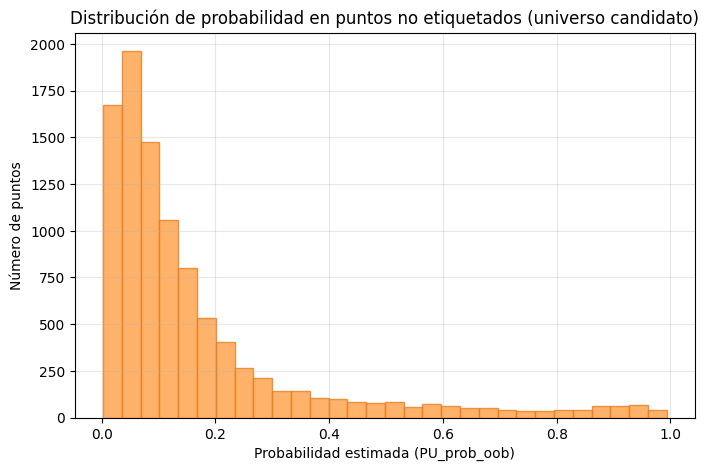

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ================================
# Distribución en universo candidato (UNL)
# ================================
plt.figure(figsize=(8,5))

plt.hist(
    PUNTOSNODESL["PU_prob_oob"].replace([np.inf, -np.inf], np.nan).dropna(),
    bins=30,
    color='#FF9F43',
    edgecolor='#E67E22',
    alpha=0.8
)

plt.xlabel("Probabilidad estimada (PU_prob_oob)")
plt.ylabel("Número de puntos")
plt.title("Distribución de probabilidad en puntos no etiquetados (universo candidato)")
plt.grid(alpha=0.3)
plt.show()



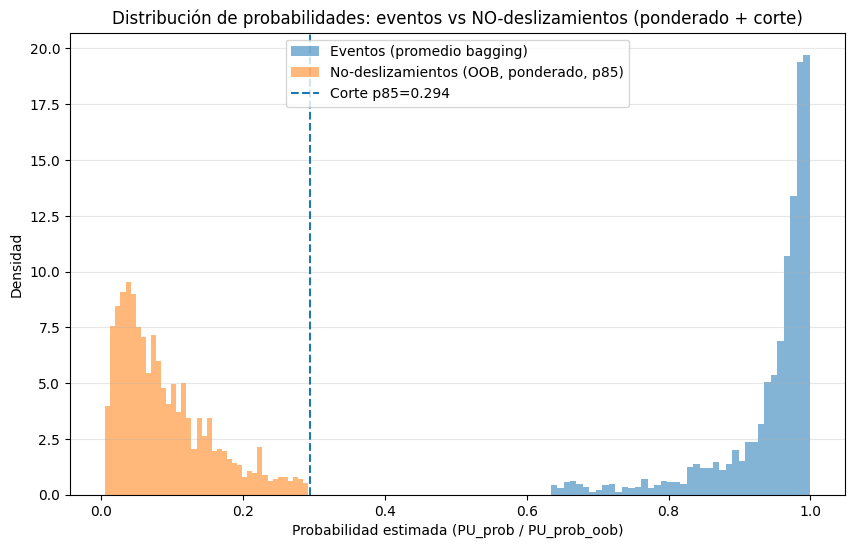

In [ ]:
# =======================================
# Gráfica (densidad comparable)
# =======================================
plt.figure(figsize=(10, 6))

plt.hist(
    EVENTOS["PU_prob"],
    bins=40, alpha=0.55, density=True,
    label="Eventos (promedio bagging)"
)

plt.hist(
    NO_DESL_PONDERADO["PU_prob_oob"],
    bins=40, alpha=0.55, density=True,
    label=f"No-deslizamientos (OOB, ponderado, p{info_p['p_corte']})"
)

plt.axvline(info_p["thr_corte"], linestyle="--", linewidth=1.5, label=f"Corte p{info_p['p_corte']}={info_p['thr_corte']:.3f}")

plt.xlabel("Probabilidad estimada (PU_prob / PU_prob_oob)")
plt.ylabel("Densidad")
plt.title("Distribución de probabilidades: eventos vs NO-deslizamientos (ponderado + corte)")
plt.legend(loc="upper center")
plt.grid(axis="y", alpha=0.3)
plt.show()


/tmp/ipykernel_20573/1289881518.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


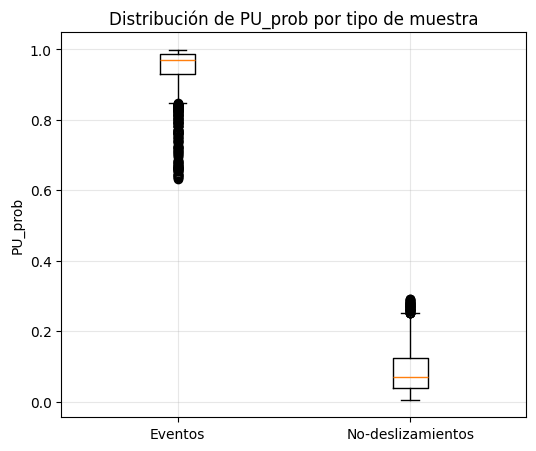

In [ ]:
plt.figure(figsize=(6,5))

plt.boxplot(
    [
        EVENTOS["PU_prob"].replace([np.inf, -np.inf], np.nan).dropna(),
        NO_DESL_PONDERADO["PU_prob_oob"].replace([np.inf, -np.inf], np.nan).dropna()
    ],
    labels=["Eventos", "No-deslizamientos"],
    showfliers=True
)

plt.ylabel("PU_prob")
plt.title("Distribución de PU_prob por tipo de muestra")
plt.grid(alpha=0.3)
plt.show()

### **TRATAMIENTO DE PUNTOS DE NO DESLIZAMIENTOS**

En esta fase se asignó una referencia temporal a los puntos identificados como no deslizamientos, mediante su emparejamiento con las fechas de ocurrencia de los eventos de remoción en masa registrados en el departamento del Boyaca durante el periodo 2005–2025. Este procedimiento permitió mantener la coherencia espacio-temporal del conjunto de datos y evitar el reprocesamiento de las variables hidroclimáticas previamente calculadas. De esta manera, los valores correspondientes a las precipitaciones acumuladas, la temperatura y la humedad del suelo fueron extraídos directamente de las superficies ya generadas para cada ventana temporal, garantizando consistencia metodológica y eficiencia computacional.

In [ ]:
# Imports

import os
import numpy as np
import pandas as pd
import geopandas as gpd

In [ ]:
# 1) RUTAS

EVENTOS_GPKG = "/content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/Eventos_Precipitaciones/evt_precifinalBoyaca160626.gpkg"
NO_DESLSHP = "/content/drive/MyDrive/TESIS-BOYACA/NoDeslizamientos/PUNTOSNODESLDEF/puntosnodeslizamientoBoyacaPH1586.shp"

OUT_DIR = "/content/drive/MyDrive/TESIS-BOYACA/NoDeslizamientos"
os.makedirs(OUT_DIR, exist_ok=True)

OUT_NO_GPKG = os.path.join(OUT_DIR, "NO_DESL_1586FECHAS.gpkg")
OUT_NO_SHP  = os.path.join(OUT_DIR, "NO_DESL_1586FECHAS.shp")  # opcional


In [ ]:
# 2) CARGAR CAPAS
import os
os.environ['SHAPE_RESTORE_SHX'] = 'YES'
eventos = gpd.read_file(EVENTOS_GPKG)
no_desl = gpd.read_file(NO_DESLSHP)

print("eventos:", eventos.shape)
print("no_desl:", no_desl.shape)

eventos: (1586, 35)
no_desl: (1586, 15)


In [ ]:
# PARÁMETROS
# -----------------------------
COL_FECHA_EVT = "Fecha_even"
ID_EVT = "Código_SIMMA"
ID_ND = "ID_NDES"

In [ ]:
eventos[COL_FECHA_EVT] = pd.to_datetime(eventos[COL_FECHA_EVT], errors="coerce")

if len(eventos) != len(no_desl):
    raise ValueError("Eventos y no-deslizamientos no tienen la misma cantidad")

In [ ]:
# -----------------------------
# ORDEN PARA EMPAREJAR 1:1
# -----------------------------
eventos_ordenados = eventos.sort_values([COL_FECHA_EVT, ID_EVT]).reset_index(drop=True)
no_desl_ordenados = no_desl.sort_values(ID_ND).reset_index(drop=True)

In [ ]:
no_desl_ordenados["Fecha_ref"] = eventos_ordenados[COL_FECHA_EVT].values


In [ ]:
# CALCULO FECHAS HACIA ATRÁS

ventanas = [1, 3, 5, 7, 9, 15, 30, 180]

for d in ventanas:
    col = f"Fecha_t0_{d}d"
    no_desl_ordenados[col] = (
        pd.to_datetime(no_desl_ordenados["Fecha_ref"]) -
        pd.to_timedelta(d, unit="D")
    )

# -----------------------------
# AÑO Y TRIMESTRE
# -----------------------------
no_desl_ordenados["Year"] = pd.to_datetime(no_desl_ordenados["Fecha_ref"]).dt.year
no_desl_ordenados["Trimestre"] = pd.to_datetime(no_desl_ordenados["Fecha_ref"]).dt.quarter

# (opcional) Fecha sin hora
no_desl_ordenados["Fecha_ref_txt"] = pd.to_datetime(
    no_desl_ordenados["Fecha_ref"]
).dt.strftime("%Y-%m-%d")

In [ ]:
no_desl_ordenados.head(2)

,ID_NDES,Geologia_U,Paisaje,Elevacion,Dist_vias,Dist_DD,Dist_Falla,CurvaturaN,CurvaturaT,TWI,...,Fecha_t0_3d,Fecha_t0_5d,Fecha_t0_7d,Fecha_t0_9d,Fecha_t0_15d,Fecha_t0_30d,Fecha_t0_180d,Year,Trimestre,Fecha_ref_txt
0,3.0,5,5,3188,1772.290039,61258.199219,5523.419922,-0.002666,18.321899,6.52562,...,2005-12-12,2005-12-10,2005-12-08,2005-12-06,2005-11-30,2005-11-15,2005-06-18,2005,4,2005-12-15
1,34.0,1,3,2622,7180.600098,54020.101562,7731.040039,0.001817,1.919960,5.94512,...,2005-12-12,2005-12-10,2005-12-08,2005-12-06,2005-11-30,2005-11-15,2005-06-18,2005,4,2005-12-15


In [ ]:
no_desl_ordenados.columns

Index(['ID_NDES', 'Geologia_U', 'Paisaje', 'Elevacion', 'Dist_vias', 'Dist_DD',
       'Dist_Falla', 'CurvaturaN', 'CurvaturaT', 'TWI', 'Eastness',
       'Northness', 'Pendiente', 'Acum_flujo', 'geometry', 'Fecha_ref',
       'Fecha_t0_1d', 'Fecha_t0_3d', 'Fecha_t0_5d', 'Fecha_t0_7d',
       'Fecha_t0_9d', 'Fecha_t0_15d', 'Fecha_t0_30d', 'Fecha_t0_180d', 'Year',
       'Trimestre', 'Fecha_ref_txt'],
      dtype='object')

In [ ]:
# GUARDAR COMO CAPA FINAL

output_gpkg_path = os.path.join(OUT_DIR, "PTOSNODESL_fechasV2.gpkg")

no_desl_ordenados.to_file(output_gpkg_path, layer="nodesliz", driver="GPKG")

print("Capa final guardada en:", output_gpkg_path)

Capa final guardada en: /content/drive/MyDrive/TESIS-BOYACA/NoDeslizamientos/PTOSNODESL_fechasV2.gpkg


### **Asignación de valores de precipitación**

En este ítem fue necesario asignar a cada uno de los puntos clasificados como no deslizamiento los valores de precipitación correspondientes, teniendo en cuenta la fecha de referencia asociada a cada punto. Para ello, se realizó una búsqueda sistemática en los rásteres previamente generados durante la etapa de interpolación de los eventos, los cuales corresponden a los acumulados de precipitación efectivamente calculados para cada ventana temporal. De esta manera, se garantizó que la asignación de valores se efectuara únicamente a partir de información climática existente y coherente con la fecha y ubicación espacial de cada punto.

In [ ]:
import os, re
import numpy as np
import pandas as pd
import rasterio
import geopandas as gpd

from collections import defaultdict
import time

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
nodesl= "/content/drive/MyDrive/TESIS-BOYACA/NoDeslizamientos/PTOSNODESL_fechasV2.gpkg"
RASTER_DIR = "/content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/PrecipitacionesAcumuladas"

In [ ]:
no_desl = gpd.read_file(nodesl)


In [ ]:
display(no_desl.head(2))

,ID_NDES,Geologia_U,Paisaje,Elevacion,Dist_vias,Dist_DD,Dist_Falla,CurvaturaN,CurvaturaT,TWI,...,Fecha_t0_5d,Fecha_t0_7d,Fecha_t0_9d,Fecha_t0_15d,Fecha_t0_30d,Fecha_t0_180d,Year,Trimestre,Fecha_ref_txt,geometry
0,3.0,5,5,3188,1772.290039,61258.199219,5523.419922,-0.002666,18.321899,6.52562,...,2005-12-10,2005-12-08,2005-12-06,2005-11-30,2005-11-15,2005-06-18,2005,4,2005-12-15,POINT (4954032.022 2166037.126)
1,34.0,1,3,2622,7180.600098,54020.101562,7731.040039,0.001817,1.919960,5.94512,...,2005-12-10,2005-12-08,2005-12-06,2005-11-30,2005-11-15,2005-06-18,2005,4,2005-12-15,POINT (4943979.2 2163813.274)


In [ ]:
# Se crean las nuevas columnas asociads a la precipitacion y sus ventanas ecluyentes.
cols_precip = [
    "P0_evento",
    "P1_excl", "P3_excl", "P5_excl", "P7_excl",
    "P9_excl", "P15_excl", "P30_excl", "P180_excl"
]

# crear columnas si no existen (float)
for c in cols_precip:
    if c not in no_desl.columns:
        no_desl[c] = np.nan
    no_desl[c] = no_desl[c].astype("float32")


In [ ]:
no_desl.columns

Index(['ID_NDES', 'Geologia_U', 'Paisaje', 'Elevacion', 'Dist_vias', 'Dist_DD',
       'Dist_Falla', 'CurvaturaN', 'CurvaturaT', 'TWI', 'Eastness',
       'Northness', 'Pendiente', 'Acum_flujo', 'Fecha_ref', 'Fecha_t0_1d',
       'Fecha_t0_3d', 'Fecha_t0_5d', 'Fecha_t0_7d', 'Fecha_t0_9d',
       'Fecha_t0_15d', 'Fecha_t0_30d', 'Fecha_t0_180d', 'Year', 'Trimestre',
       'Fecha_ref_txt', 'geometry', 'P0_evento', 'P1_excl', 'P3_excl',
       'P5_excl', 'P7_excl', 'P9_excl', 'P15_excl', 'P30_excl', 'P180_excl'],
      dtype='object')

In [ ]:
# Se fija como fecha de referencia la columna "Fecha_ref_txt"
COL_T0_TXT = "Fecha_ref_txt"

In [ ]:
# 2) Indexar TODOS los rasters UNA sola vez: fecha -> {var -> path}

idx_rasters = defaultdict(dict)

rx_p0  = re.compile(r"^P0_evento_t0_(\d{4}-\d{2}-\d{2})_.*\.tif$") # Expresión para identificar rasters de la precipitación del dia del evento.
rx_acc = re.compile(r"^accum_P(\d+)_excl_t0_(\d{4}-\d{2}-\d{2})_.*\.tif$") # Expresión para identificar rasters de la precipitación acumulada excluyente.

for fn in os.listdir(RASTER_DIR):
    m0 = rx_p0.match(fn)
    if m0:
        fecha = m0.group(1)
        idx_rasters[fecha]["P0_evento"] = os.path.join(RASTER_DIR, fn)
        continue

    m1 = rx_acc.match(fn)
    if m1:
        N = m1.group(1)
        fecha = m1.group(2)
        var = f"P{N}_excl"
        idx_rasters[fecha][var] = os.path.join(RASTER_DIR, fn)




In [ ]:
# 3) Función de muestreo
# La función extrae los valores de un ráster en las ubicaciones de un conjunto de puntos geográficos y
# devuelve dichos valores como un arreglo numérico

def sample_raster(tif_path, gdf_points):
    with rasterio.open(tif_path) as src:
        coords = [(geom.x, geom.y) for geom in gdf_points.geometry]
        vals = np.array([v[0] for v in src.sample(coords)], dtype="float32")
        if src.nodata is not None:
            vals = np.where(vals == src.nodata, np.nan, vals)
    return vals


In [ ]:
# 4) Procesar POR FECHA (grupo de puntos) + PROGRESO
# Recorre las fechas únicas de los puntos de no deslizamiento y, para cada fecha,
# identifica los rásteres de precipitación correspondientes, extrae sus valores
# en la ubicación de los puntos mediante muestreo espacial y los asigna como
# variables

fechas = pd.Series(no_desl[COL_T0_TXT]).dropna().astype(str).unique()
t0 = time.time()

for i, fecha_str in enumerate(fechas, 1):

    if fecha_str not in idx_rasters:
        continue

    idx_pts = no_desl.index[no_desl[COL_T0_TXT].astype(str) == fecha_str]
    gsub = no_desl.loc[idx_pts]

    for var in cols_precip:
        tif = idx_rasters[fecha_str].get(var, None)
        if tif is None:
            continue
        no_desl.loc[idx_pts, var] = sample_raster(tif, gsub)

    if i % 1 == 0:
        print(f"{i}/{len(fechas)} fechas procesadas — {(time.time()-t0)/60:.1f} min")


1/280 fechas procesadas — 0.6 min
2/280 fechas procesadas — 1.0 min
3/280 fechas procesadas — 1.5 min
4/280 fechas procesadas — 2.1 min
5/280 fechas procesadas — 2.5 min
6/280 fechas procesadas — 3.0 min
7/280 fechas procesadas — 3.5 min
8/280 fechas procesadas — 3.9 min
9/280 fechas procesadas — 4.5 min
10/280 fechas procesadas — 5.1 min
11/280 fechas procesadas — 5.6 min
12/280 fechas procesadas — 6.2 min
13/280 fechas procesadas — 6.6 min
14/280 fechas procesadas — 7.0 min
15/280 fechas procesadas — 7.6 min
16/280 fechas procesadas — 8.2 min
17/280 fechas procesadas — 8.7 min
18/280 fechas procesadas — 9.2 min
19/280 fechas procesadas — 9.7 min
20/280 fechas procesadas — 10.3 min
21/280 fechas procesadas — 10.7 min
22/280 fechas procesadas — 11.2 min
23/280 fechas procesadas — 11.7 min
24/280 fechas procesadas — 12.2 min
25/280 fechas procesadas — 12.8 min
26/280 fechas procesadas — 13.3 min
27/280 fechas procesadas — 13.9 min
28/280 fechas procesadas — 14.3 min
29/280 fechas proces

In [ ]:
import os

OUT_GPKG = "/content/drive/MyDrive/TESIS-BOYACA/NoDeslizamientos/nodeslprecipitacion.gpkg"

# Ensure the output directory exists
os.makedirs(os.path.dirname(OUT_GPKG), exist_ok=True)

no_desl.to_file(
    OUT_GPKG,
    layer="no_desliz",
    driver="GPKG"
)

In [ ]:
nodesl_precip= '/content/drive/MyDrive/TESIS-BOYACA/NoDeslizamientos/nodeslprecipitacion.gpkg'
nodesl_precip=gpd.read_file(nodesl_precip)

In [ ]:
nodesl_precip.head(2)

,ID_NDES,Geologia_U,Paisaje,Elevacion,Dist_vias,Dist_DD,Dist_Falla,CurvaturaN,CurvaturaT,TWI,...,P0_evento,P1_excl,P3_excl,P5_excl,P7_excl,P9_excl,P15_excl,P30_excl,P180_excl,geometry
0,3.0,5,5,3188,1772.290039,61258.199219,5523.419922,-0.002666,18.321899,6.52562,...,19.260515,1.367980,4.572981,5.336770,7.494352,8.119327,23.402279,86.058144,484.986450,POINT (4954032.022 2166037.126)
1,34.0,1,3,2622,7180.600098,54020.101562,7731.040039,0.001817,1.919960,5.94512,...,36.394722,3.268476,7.297567,7.585069,9.346248,12.027211,26.961893,73.081276,446.437439,POINT (4943979.2 2163813.274)


In [ ]:
cols_precip = ["P0_evento","P1_excl","P3_excl","P5_excl","P7_excl",
               "P9_excl","P15_excl","P30_excl","P180_excl"]

registros_con_nan = nodesl_precip.loc[
    nodesl_precip[cols_precip].isna().any(axis=1), ["ID_NDES","Fecha_ref_txt"] + cols_precip
    ]
registros_con_nan.head()

,ID_NDES,Fecha_ref_txt,P0_evento,P1_excl,P3_excl,P5_excl,P7_excl,P9_excl,P15_excl,P30_excl,P180_excl
37,330.0,2007-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
204,1398.0,2015-09-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
542,3493.0,2015-11-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
641,4206.0,2015-12-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
753,4857.0,2016-01-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
cols_precip = ["P0_evento","P1_excl","P3_excl","P5_excl","P7_excl",
               "P9_excl","P15_excl","P30_excl","P180_excl"]

nodesl_precip.loc[
    nodesl_precip["Fecha_ref_txt"].isin(["2007-01-05","2007-01-05"]),
    ["ID_NDES","Fecha_ref_txt"] + cols_precip
]


,ID_NDES,Fecha_ref_txt,P0_evento,P1_excl,P3_excl,P5_excl,P7_excl,P9_excl,P15_excl,P30_excl,P180_excl
37,330.0,2007-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
38,335.0,2007-01-05,3.861395,1.315002,5.933745,5.940536,6.584332,7.826456,26.927200,64.244820,864.179749
39,341.0,2007-01-05,1.921987,0.713650,1.602929,16.860233,17.143848,17.603237,29.366600,44.186943,1104.431519
40,353.0,2007-01-05,0.927324,0.000000,0.000000,0.183576,0.202925,0.269594,1.505532,21.571310,470.138336


In [ ]:
import rasterio
import numpy as np

def sample_raster(tif_path, gdf_points):
    with rasterio.open(tif_path) as src:
        coords = [(geom.x, geom.y) for geom in gdf_points.geometry]
        vals = np.array([v[0] for v in src.sample(coords)], dtype="float32")
        if src.nodata is not None:
            vals = np.where(vals == src.nodata, np.nan, vals)
    return vals

fechas_objetivo = ["2007-01-05", "2015-09-20", "2015-11-26", "2015-12-14", "2016-01-20"]

for fecha_str in fechas_objetivo:

    # si no hay ningún raster indexado para esa fecha, no se puede llenar
    if fecha_str not in idx_rasters:
        print(f"No existen rásteres indexados para {fecha_str}")
        continue

    # filas correspondientes a esa fecha
    idx_pts = no_desl.index[no_desl["Fecha_ref_txt"] == fecha_str]
    gsub = no_desl.loc[idx_pts]

    for var in cols_precip:
        # solo intentar llenar si está NaN
        if not no_desl.loc[idx_pts, var].isna().any():
            continue

        tif = idx_rasters[fecha_str].get(var, None)
        if tif is None:
            print(f"Falta raster {var} para {fecha_str}")
            continue

        no_desl.loc[idx_pts, var] = sample_raster(tif, gsub)
        print(f"Llenado {var} para fecha {fecha_str}")


Llenado P0_evento para fecha 2007-01-05
Llenado P1_excl para fecha 2007-01-05
Llenado P3_excl para fecha 2007-01-05
Llenado P5_excl para fecha 2007-01-05
Llenado P7_excl para fecha 2007-01-05
Llenado P9_excl para fecha 2007-01-05
Llenado P15_excl para fecha 2007-01-05
Llenado P30_excl para fecha 2007-01-05
Llenado P180_excl para fecha 2007-01-05
Llenado P0_evento para fecha 2015-09-20
Llenado P1_excl para fecha 2015-09-20
Llenado P3_excl para fecha 2015-09-20
Llenado P5_excl para fecha 2015-09-20
Llenado P7_excl para fecha 2015-09-20
Llenado P9_excl para fecha 2015-09-20
Llenado P15_excl para fecha 2015-09-20
Llenado P30_excl para fecha 2015-09-20
Llenado P180_excl para fecha 2015-09-20
Llenado P0_evento para fecha 2015-11-26
Llenado P1_excl para fecha 2015-11-26
Llenado P3_excl para fecha 2015-11-26
Llenado P5_excl para fecha 2015-11-26
Llenado P7_excl para fecha 2015-11-26
Llenado P9_excl para fecha 2015-11-26
Llenado P15_excl para fecha 2015-11-26
Llenado P30_excl para fecha 2015-11

Al verificar los puntos problemáticos en ArcGIS Pro, se observa que estos se enecuentran localizados fuera de la extensión espacial de los rásteres generados para las fechas específicas analizadas. Por lo tanto, se optó por ajustar manualmente la ubicación de dichos puntos dentro del área de cobertura de los rásteres correspondientes. Posteriormente, el archivo GeoPackage fue actualizado y recargado incorporando estos ajustes para continuar con el procesamiento de los datos.



In [ ]:
OUT_GPKG = '/content/drive/MyDrive/TESIS-BOYACA/NoDeslizamientos/nodeslprecipitacionv2.gpkg'
nodesl_precip = gpd.read_file(OUT_GPKG)

In [ ]:
nodesl_precip["ID_NDES"] = nodesl_precip["ID_NDES"].fillna(0).astype(int).astype(str)

In [ ]:
nodesl_precip.columns

Index(['ID_NDES', 'Geologia_U', 'Paisaje', 'Elevacion', 'Dist_vias', 'Dist_DD',
       'Dist_Falla', 'CurvaturaN', 'CurvaturaT', 'TWI', 'Eastness',
       'Northness', 'Pendiente', 'Acum_flujo', 'Fecha_ref', 'Fecha_t0_1d',
       'Fecha_t0_3d', 'Fecha_t0_5d', 'Fecha_t0_7d', 'Fecha_t0_9d',
       'Fecha_t0_15d', 'Fecha_t0_30d', 'Fecha_t0_180d', 'Year', 'Trimestre',
       'Fecha_ref_txt', 'P0_evento', 'P1_excl', 'P3_excl', 'P5_excl',
       'P7_excl', 'P9_excl', 'P15_excl', 'P30_excl', 'P180_excl', 'geometry'],
      dtype='object')

In [ ]:
nodesl_precip.loc[
    nodesl_precip[cols_precip].isna().any(axis=1),
    "Fecha_ref_txt"
].value_counts().head(10)


,count
Fecha_ref_txt,
2007-01-05,1
2015-09-20,1
2015-11-26,1
2015-12-14,1
2016-01-20,1
2023-07-08,1


In [ ]:
import rasterio
import numpy as np

def sample_raster(tif_path, gdf_points):
    with rasterio.open(tif_path) as src:
        coords = [(geom.x, geom.y) for geom in gdf_points.geometry]
        vals = np.array([v[0] for v in src.sample(coords)], dtype="float32")
        if src.nodata is not None:
            vals = np.where(vals == src.nodata, np.nan, vals)
    return vals

fechas_objetivo = ["2007-01-05", "2015-09-20", "2015-11-26",
                   "2015-12-14","2016-01-20", "2023-07-08"]

for fecha_str in fechas_objetivo:

    # si no hay ningún raster indexado para esa fecha, no se puede llenar
    if fecha_str not in idx_rasters:
        print(f"No existen rásteres indexados para {fecha_str}")
        continue

    # filas correspondientes a esa fecha
    idx_pts = nodesl_precip.index[nodesl_precip["Fecha_ref_txt"] == fecha_str]
    gsub = nodesl_precip.loc[idx_pts]

    for var in cols_precip:
        # solo intentar llenar si está NaN
        if not nodesl_precip.loc[idx_pts, var].isna().any():
            continue

        tif = idx_rasters[fecha_str].get(var, None)
        if tif is None:
            print(f"Falta raster {var} para {fecha_str}")
            continue

        nodesl_precip.loc[idx_pts, var] = sample_raster(tif, gsub)
        print(f"Llenado {var} para fecha {fecha_str}")

Llenado P0_evento para fecha 2007-01-05
Llenado P1_excl para fecha 2007-01-05
Llenado P3_excl para fecha 2007-01-05
Llenado P5_excl para fecha 2007-01-05
Llenado P7_excl para fecha 2007-01-05
Llenado P9_excl para fecha 2007-01-05
Llenado P15_excl para fecha 2007-01-05
Llenado P30_excl para fecha 2007-01-05
Llenado P180_excl para fecha 2007-01-05
Llenado P0_evento para fecha 2015-09-20
Llenado P1_excl para fecha 2015-09-20
Llenado P3_excl para fecha 2015-09-20
Llenado P5_excl para fecha 2015-09-20
Llenado P7_excl para fecha 2015-09-20
Llenado P9_excl para fecha 2015-09-20
Llenado P15_excl para fecha 2015-09-20
Llenado P30_excl para fecha 2015-09-20
Llenado P180_excl para fecha 2015-09-20
Llenado P0_evento para fecha 2015-11-26
Llenado P1_excl para fecha 2015-11-26
Llenado P3_excl para fecha 2015-11-26
Llenado P5_excl para fecha 2015-11-26
Llenado P7_excl para fecha 2015-11-26
Llenado P9_excl para fecha 2015-11-26
Llenado P15_excl para fecha 2015-11-26
Llenado P30_excl para fecha 2015-11

In [ ]:
fechas_problema = ["2007-01-05", "2015-09-20", "2015-11-26",
                   "2015-12-14","2016-01-20", "2023-07-08"]

ids_interes = ["330", "1398", "3493","4206","4857"]

cols_precip = ["P0_evento","P1_excl","P3_excl","P5_excl","P7_excl",
               "P9_excl","P15_excl","P30_excl","P180_excl"]

nodesl_precip.loc[
    (nodesl_precip["Fecha_ref_txt"].isin(fechas_problema)) &
    (nodesl_precip["ID_NDES"].isin(ids_interes)),
    ["ID_NDES", "Fecha_ref_txt"] + cols_precip
    ]

,ID_NDES,Fecha_ref_txt,P0_evento,P1_excl,P3_excl,P5_excl,P7_excl,P9_excl,P15_excl,P30_excl,P180_excl
37,330,2007-01-05,1.995306,0.000000,0.000000,0.955255,0.989552,1.114874,3.385373,34.121517,568.078796
204,1398,2015-09-20,2.656116,5.028309,11.681099,17.385706,22.642902,25.275927,58.814213,105.567345,931.919800
542,3493,2015-11-26,20.731627,0.142766,12.838362,12.838362,15.816189,26.125183,46.182899,150.725494,496.581055
641,4206,2015-12-14,15.506248,0.000000,0.114472,3.782992,3.793657,8.806034,18.764666,136.990829,1049.233276
753,4857,2016-01-20,0.008344,0.059621,0.059621,0.127498,0.179596,0.179596,1.581311,17.001640,667.884033


In [ ]:
# Se exporta el resultado en un geopackge.

import os

OUT_GPKG = "/content/drive/MyDrive/TESIS-BOYACA/NoDeslizamientos/nodeslprecipitaciondef.gpkg"

# Ensure the output directory exists
os.makedirs(os.path.dirname(OUT_GPKG), exist_ok=True)

nodesl_precip.to_file(
    OUT_GPKG,
    layer="no_desliz_def",
    driver="GPKG"
)

###**Asignación de valores de humedad y temperatura trimestral**


## **ADQUISICIÓN DE VARIABLES ASOCIADAS A IMÁGENES SATELITALES**

In [ ]:
import os, numpy as np, pandas as pd, geopandas as gpd
!pip install fiona

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 44.1 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import fiona

path = '/content/drive/MyDrive/TESIS-BOYACA/Dataset_Boyaca/Dataset_16062026.gpkg'
capas = fiona.listlayers(path)
print(f"Capas encontradas: {capas}")

Capas encontradas: ['eventos', 'ptsnodeslizamientos']


In [ ]:
df_positivos = gpd.read_file(path, layer='eventos')
df_negativos = gpd.read_file(path, layer='ptsnodeslizamientos')

In [ ]:
df_positivos.columns

Index(['OBJECTID', 'Código_SIMMA', 'Fecha_even', 'P0_evento', 'P1_excl',
       'P3_excl', 'P5_excl', 'P7_excl', 'P9_excl', 'P15_excl', 'P30_excl',
       'P180_excl', 'Latitud___', 'Longitud__', 'Fecha_t0_1d', 'Fecha_t0_3d',
       'Fecha_t0_5d', 'Fecha_t0_7d', 'Fecha_t0_15d', 'Fecha_t0_30d',
       'Fecha_t0_180d', 'Geologia_U', 'Paisaje', 'Elevacion', 'Dist_vias',
       'Dist_DD', 'Dist_Falla', 'CurvaturaN', 'CurvaturaT', 'TWI', 'Eastness',
       'Northness', 'Pendiente', 'Acum_flujo', 'geometry'],
      dtype='object')

In [ ]:
df_negativos.columns

Index(['ID_NDES', 'Geologia_U', 'Paisaje', 'Elevacion', 'Dist_vias', 'Dist_DD',
       'Dist_Falla', 'CurvaturaN', 'CurvaturaT', 'TWI', 'Eastness',
       'Northness', 'Pendiente', 'Acum_flujo', 'Fecha_ref', 'Fecha_t0_1d',
       'Fecha_t0_3d', 'Fecha_t0_5d', 'Fecha_t0_7d', 'Fecha_t0_9d',
       'Fecha_t0_15d', 'Fecha_t0_30d', 'Fecha_t0_180d', 'Year', 'Trimestre',
       'Fecha_ref_txt', 'P0_evento', 'P1_excl', 'P3_excl', 'P5_excl',
       'P7_excl', 'P9_excl', 'P15_excl', 'P30_excl', 'P180_excl', 'geometry'],
      dtype='object')

In [ ]:
columnas_no_usar = [
    'Fecha_ref_txt',
    'Fecha_t0_1d',
    'Fecha_t0_3d',
    'Fecha_t0_5d',
    'Fecha_t0_7d',
    'Fecha_t0_9d'
    'Fecha_t0_15d',
    'Fecha_t0_30d',
    'Fecha_t0_180d',
    'Year',
    'Trimestre',
    'Fecha_t0_9d',
    'Fecha_t0_15d'
]

df_positivosf= df_positivos.drop(columns=columnas_no_usar, errors='ignore')
df_negativosf= df_negativos.drop(columns=columnas_no_usar, errors='ignore')

In [ ]:
df_positivosf.columns

Index(['OBJECTID', 'Código_SIMMA', 'Fecha_even', 'P0_evento', 'P1_excl',
       'P3_excl', 'P5_excl', 'P7_excl', 'P9_excl', 'P15_excl', 'P30_excl',
       'P180_excl', 'Latitud___', 'Longitud__', 'Geologia_U', 'Paisaje',
       'Elevacion', 'Dist_vias', 'Dist_DD', 'Dist_Falla', 'CurvaturaN',
       'CurvaturaT', 'TWI', 'Eastness', 'Northness', 'Pendiente', 'Acum_flujo',
       'geometry'],
      dtype='object')

In [ ]:
df_negativosf.columns

Index(['ID_NDES', 'Geologia_U', 'Paisaje', 'Elevacion', 'Dist_vias', 'Dist_DD',
       'Dist_Falla', 'CurvaturaN', 'CurvaturaT', 'TWI', 'Eastness',
       'Northness', 'Pendiente', 'Acum_flujo', 'Fecha_ref', 'P0_evento',
       'P1_excl', 'P3_excl', 'P5_excl', 'P7_excl', 'P9_excl', 'P15_excl',
       'P30_excl', 'P180_excl', 'geometry'],
      dtype='object')

**Antes de generar la matriz maestra, se realizó la estandarización de nombres y formatos de las variables con el fin de garantizar la congruencia en la integración de las diferentes fuentes de información. Finalmente, se ajustó el conjunto de puntos de no deslizamiento con el propósito de equilibrar el dataset y reducir sesgos en las etapas posteriores de modelado.**

In [ ]:
df_negativosf = df_negativosf.to_crs(epsg=4326)
df_positivosf = df_positivosf.to_crs(epsg=4326)

# Renombrar columnas en los Negativos para que coincidan con los Positivos
df_negativosf = df_negativosf.rename(columns={
    'ID_NDES': 'Codigo',
    'Fecha_ref': 'Fecha_E',
})

# Renombrar columnas en los Positivos
df_positivosf = df_positivosf.rename(columns={
    'Código_SIMMA': 'Codigo',
    'Fecha_even': 'Fecha_E',
    'Latitud___': 'Latitud',
    'Longitud__': 'Longitud'
})

# Extraer Latitud y Longitud para los negativos desde la geometría
df_negativosf['Latitud'] = df_negativosf.geometry.y
df_negativosf['Longitud'] = df_negativosf.geometry.x

# Extraer Latitud y Longitud para los positivos desde la geometría
df_positivosf['Latitud'] = df_positivosf.geometry.y
df_positivosf['Longitud'] = df_positivosf.geometry.x

In [ ]:
df_positivosf.head(5)[["Codigo", "Fecha_E", "Latitud", "Longitud"]]

,Codigo,Fecha_E,Latitud,Longitud
0,56489,2018-09-20 00:00:00+00:00,5.238611,-73.058889
1,40217,2020-05-20 00:00:00+00:00,4.877863,-73.245077
2,40342,2020-06-01 00:00:00+00:00,5.152000,-73.067000
3,40915,2020-06-03 00:00:00+00:00,4.859000,-73.234000
4,41164,2020-06-17 00:00:00+00:00,4.859000,-73.234000


In [ ]:
df_negativosf.head(5)[["Codigo", "Fecha_E", "Latitud", "Longitud"]]

,Codigo,Fecha_E,Latitud,Longitud
0,3,2005-12-15,5.502542,-73.415165
1,34,2005-12-15,5.482347,-73.505939
2,36,2005-12-15,5.839474,-72.855360
3,47,2005-12-15,5.520325,-74.121081
4,48,2005-12-15,5.479428,-74.188502


In [ ]:
import pandas as pd

# Copias por seguridad
df_positivosf = df_positivosf.copy()
df_negativosf = df_negativosf.copy()

# Estandarizar Fecha_E en ambos DataFrames
for df in [df_positivosf, df_negativosf]:
    df["Fecha_E"] = (
        pd.to_datetime(df["Fecha_E"], errors="coerce", utc=True)
        .dt.tz_convert(None)   # elimina +00:00
        .dt.normalize()        # deja solo la fecha, hora 00:00:00
    )

In [ ]:
print(df_positivosf["Fecha_E"].dtype)
print(df_negativosf["Fecha_E"].dtype)

display(df_positivosf[["Codigo", "Fecha_E", "Latitud", "Longitud"]].head())
display(df_negativosf[["Codigo", "Fecha_E", "Latitud", "Longitud"]].head())

datetime64[ms]
datetime64[ms]


,Codigo,Fecha_E,Latitud,Longitud
0,56489,2018-09-20,5.238611,-73.058889
1,40217,2020-05-20,4.877863,-73.245077
2,40342,2020-06-01,5.152000,-73.067000
3,40915,2020-06-03,4.859000,-73.234000
4,41164,2020-06-17,4.859000,-73.234000


,Codigo,Fecha_E,Latitud,Longitud
0,3,2005-12-15,5.502542,-73.415165
1,34,2005-12-15,5.482347,-73.505939
2,36,2005-12-15,5.839474,-72.855360
3,47,2005-12-15,5.520325,-74.121081
4,48,2005-12-15,5.479428,-74.188502


In [ ]:
print("Registros totales:", len(df_positivosf))

# Cantidad de eventos únicos
print(
    "Eventos únicos (Lat, Lon, Fecha):",
    df_positivosf.drop_duplicates(
        subset=["Latitud", "Longitud", "Fecha_E"]
    ).shape[0]
)


Registros totales: 1586
Eventos únicos (Lat, Lon, Fecha): 1586


In [ ]:
# Añadir etiqueta: 1 para deslizamiento, 0 para no deslizamiento
df_positivosf['clase'] = 1
df_negativosf['clase'] = 0

In [ ]:
# Unir las dos tablas
if df_negativosf.crs != 'EPSG:4326':
    df_negativosf = df_negativosf.to_crs(epsg=4326)

# Determine common columns using the correct dataframes (df_positivosf and df_negativosf)
columnas_comunes = df_positivosf.columns.intersection(df_negativosf.columns)

# Concatenate the dataframes
matriz_maestra = pd.concat([df_positivosf[columnas_comunes], df_negativosf[columnas_comunes]], axis=0)

In [ ]:
print(f"Matriz unificada con {matriz_maestra.shape[0]} filas y {matriz_maestra.shape[1]} columnas.")

Matriz unificada con 3172 filas y 28 columnas.


In [ ]:
matriz_maestra.head(2)

,Codigo,Fecha_E,P0_evento,P1_excl,P3_excl,P5_excl,P7_excl,P9_excl,P15_excl,P30_excl,...,Dist_Falla,CurvaturaN,CurvaturaT,TWI,Eastness,Northness,Pendiente,Acum_flujo,geometry,clase
0,56489,2018-09-20,0.013432,12.106000,42.394432,53.755547,67.529228,69.828926,99.491898,174.872894,...,1332.553955,0.002591,10.603379,4.200564,-0.983870,0.178885,10.555381,0.0,POINT (-73.05889 5.23861),1
1,40217,2020-05-20,6.301852,6.287007,35.576134,70.935394,74.441734,108.377655,290.009827,548.185486,...,807.217468,-0.004084,20.869690,3.505004,-0.433816,0.901002,20.535101,0.0,POINT (-73.24508 4.87786),1


In [ ]:
matriz_maestra.columns

Index(['Codigo', 'Fecha_E', 'P0_evento', 'P1_excl', 'P3_excl', 'P5_excl',
       'P7_excl', 'P9_excl', 'P15_excl', 'P30_excl', 'P180_excl', 'Latitud',
       'Longitud', 'Geologia_U', 'Paisaje', 'Elevacion', 'Dist_vias',
       'Dist_DD', 'Dist_Falla', 'CurvaturaN', 'CurvaturaT', 'TWI', 'Eastness',
       'Northness', 'Pendiente', 'Acum_flujo', 'geometry', 'clase'],
      dtype='object')

In [ ]:
matriz_maestra.to_file('/content/drive/MyDrive/TESIS-BOYACA/Dataset_Boyaca/Final170626.gpkg', layer="DatasetFinal", driver="GPKG")
print("\nGuardado:", '/content/drive/MyDrive/TESIS-BOYACA/Dataset_Boyaca/Final170626.gpkg')


Guardado: /content/drive/MyDrive/TESIS-BOYACA/Dataset_Boyaca/Final170626.gpkg


### **Manejo de imágenes con conexión con GEE**

**En esta sección se establece la conexión entre Google Colab y Google Earth Engine (GEE), con el fin de acceder de manera remota a imágenes satelitales capturadas por distintos sensores remotos. Esto permite consultar y procesar series temporales de datos ópticos y radar provenientes de misiones como Landsat, Sentinel-2 y Sentinel-1, sin necesidad de descarga local de los datos. A partir de este Script, se extraen variables espectrales y de retrodispersión asociadas a la ubicación y fecha de ocurrencia de cada evento, utilizando ventanas temporales retrospectivas y resúmenes estadísticos en áreas buffer alrededor de los puntos de análisis, con el objetivo de caracterizar las condiciones ambientales previas a la ocurrencia de los eventos.**

In [ ]:
# =====================================
# Instalación de Librerías y recursos
# =====================================

!pip -q install earthengine-api geemap geopandas fiona pyproj shapely

import ee, geemap
import geopandas as gpd
import pandas as pd
from google.colab import drive
import pprint

# 1) Coneión con Drive

drive.mount('/content/drive')

# 2) Autenticación e inicialización de Earth Engine

ee.Authenticate()
ee.Initialize(project="ee-linapaolagarcia")
print("GEE listo ✅")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GEE listo ✅


In [ ]:
# -----------------------------
# Lectura GPGK - Dataset final
# -----------------------------
gpkg_path  = "/content/drive/MyDrive/TESIS-BOYACA/Dataset_Boyaca/Final170626.gpkg"
layer_name = "DatasetFinal"

gdf = gpd.read_file(gpkg_path, layer=layer_name)
print("CRS original:", gdf.crs)

# Asegurar CRS WGS84
gdf = gdf.to_crs(epsg=4326)

# Lat/Lon desde geometry "Actualiza Lat y Lon de acuerdo al CRS"
gdf["Longitud"] = gdf.geometry.x
gdf["Latitud"]  = gdf.geometry.y

# Mantuene columnas mínimas
gdf = gdf[["Codigo", "Fecha_E", "Latitud", "Longitud", "geometry"]].copy()

# Tipos
gdf["Codigo"]   = gdf["Codigo"].astype(str)
gdf["Fecha_E"]  = gdf["Fecha_E"].astype(str).str.strip()
gdf["Latitud"]  = gdf["Latitud"].astype(float)
gdf["Longitud"] = gdf["Longitud"].astype(float)


# Normalizar fechas a YYYY-MM-DD (soporta 'YYYY-MM-DD HH:MM:SS' y '5/10/2005')
# First attempt to parse dates
dt1_attempt1 = pd.to_datetime(gdf["Fecha_E"], errors="coerce")

# Second attempt, trying with dayfirst=True for any remaining NaT values
dt1_attempt2 = pd.to_datetime(gdf["Fecha_E"], errors="coerce", dayfirst=True)

# Combine results, filling NaT values from attempt1 with valid dates from attempt2
dt_combined = dt1_attempt1.fillna(dt1_attempt2)

# Check for any remaining bad dates
bad_dates = dt_combined.isna().sum()
if bad_dates > 0:
    print(f"⚠️ Fechas no interpretables: {bad_dates}")
    print("Ejemplos:", gdf.loc[dt_combined.isna(), "Fecha_E"].head(10).tolist())

gdf["Fecha_E"] = dt_combined.dt.strftime("%Y-%m-%d")
gdf = gdf.dropna(subset=["Fecha_E"]).copy()

# Listado de fechas adecuadas.
print("Filas finales (fecha válida):", len(gdf))
display(gdf.head(3))


CRS original: EPSG:4326
Filas finales (fecha válida): 3172


/tmp/ipykernel_6285/3057912332.py:32: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  dt1_attempt2 = pd.to_datetime(gdf["Fecha_E"], errors="coerce", dayfirst=True)


,Codigo,Fecha_E,Latitud,Longitud,geometry
0,56489,2018-09-20,5.238611,-73.058889,POINT (-73.05889 5.23861)
1,40217,2020-05-20,4.877863,-73.245077,POINT (-73.24508 4.87786)
2,40342,2020-06-01,5.152000,-73.067000,POINT (-73.067 5.152)


In [ ]:
# -----------------------------
# GENERAR FEATURECOLLECTION
# -----------------------------
def to_ee_feature(row):
    pt = ee.Geometry.Point([row["Longitud"], row["Latitud"]])
    return ee.Feature(pt, {
        "Codigo": row["Codigo"],
        "Fecha_E": row["Fecha_E"]
    })

features = [to_ee_feature(r) for _, r in gdf.iterrows()]
fc = ee.FeatureCollection(features)

print("N puntos (GEE):", fc.size().getInfo())
print("Ejemplo:", fc.first().toDictionary().getInfo())



N puntos (GEE): 3172
Ejemplo: {'Codigo': '56489', 'Fecha_E': '2018-09-20'}


**Con este código, se buscó mejorar la cobertura de las imágenes ópticas y de radar, como tal se extraen automáticamente variables derivadas de imágenes satelitales ópticas (Landsat y Sentinel-2) y radar SAR (Sentinel-1 y, si falta, ALOS PALSAR), se  calcula estadísticas dentro de un buffer (60 – 90 m de accuerdo a un análisis preliminar): medias y desviaciones estándar de índices como NDVI, NDWI, NBR y EVI, además de métricas SAR como VV, VH (y derivados VV−VH, VV/VH) o HH, HV en PALSAR. El resultado final es un CSV en Drive con columnas por variable y por configuración temporal, útil como insumo directo para análisis estadístico o entrenamiento de modelos.**

**Así mismo se presenta un mapa en donde se muestra a grandes rasgos la ubicación de 8 puntos diferentes junto con el buffer priorizado y la visualización de NDVI y VV.**

In [ ]:
# ============================================================
# SCRIPT EXTRACCIÓN DE VARIABLOES ASOCIADAS A IMÁGENES
# SATÉLITALES ÓPTICAS Y DE RADAR.
# ============================================================

# =====================================
# Instalación e imports
# =====================================
!pip -q install -U earthengine-api geemap geopandas fiona pyproj shapely

import ee
import geemap
import geopandas as gpd
import pandas as pd
import pprint
from google.colab import drive

# ================================================
# Conexión con Google Drive y Google Earth Engine
# ================================================

drive.mount("/content/drive")

PROJECT_ID = "ee-linapaolagarcia"
try:
    ee.Initialize(project=PROJECT_ID)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)

print("GEE listo ✅")

# =====================================
# Leer GPKG y preparar puntos
# =====================================

gpkg_path  = "/content/drive/MyDrive/TESIS-BOYACA/Dataset_Boyaca/Final170626.gpkg"
layer_name = "DatasetFinal"

gdf = gpd.read_file(gpkg_path, layer=layer_name)
print("CRS original:", gdf.crs)

# CRS WGS84/ Ajustar referencia espacial
gdf = gdf.to_crs(epsg=4326)

gdf["Longitud"] = gdf.geometry.x
gdf["Latitud"]  = gdf.geometry.y

gdf = gdf[["Codigo", "Fecha_E", "Latitud", "Longitud", "geometry"]].copy()
gdf["Codigo"]   = gdf["Codigo"].astype(str).str.strip()
gdf["Fecha_E"]  = gdf["Fecha_E"].astype(str).str.strip()
gdf["Latitud"]  = gdf["Latitud"].astype(float)
gdf["Longitud"] = gdf["Longitud"].astype(float)

# Normalizar fechas
dt1 = pd.to_datetime(gdf["Fecha_E"], errors="coerce")
mask_na = dt1.isna()
if mask_na.any():
    dt2 = pd.to_datetime(gdf.loc[mask_na, "Fecha_E"], errors="coerce", dayfirst=True)
    dt1.loc[mask_na] = dt2

# Revisión de fechas validas
bad_dates = int(dt1.isna().sum())
if bad_dates > 0:
    print(f"⚠️ Fechas no interpretables: {bad_dates}")
    print("Ejemplos:", gdf.loc[dt1.isna(), "Fecha_E"].head(10).tolist())

gdf["Fecha_E"] = dt1.dt.strftime("%Y-%m-%d")
gdf = gdf.dropna(subset=["Fecha_E"]).copy()

print("Filas finales (fecha válida):", len(gdf))
display(gdf.head(3))

# Función para convertir geodataframe en entidad espacial
# de GEE

def to_ee_feature(row):
    pt = ee.Geometry.Point([row["Longitud"], row["Latitud"]])
    return ee.Feature(pt, {"Codigo": row["Codigo"], "Fecha_E": row["Fecha_E"]})

features = [to_ee_feature(r) for _, r in gdf.iterrows()]
fc = ee.FeatureCollection(features)

print("N puntos (GEE):", fc.size().getInfo())
print("Ejemplo:", fc.first().toDictionary().getInfo())

# =====================================
# Parámetros globales
# =====================================
SCALE = 30

# Umbrales (Cauca: nubosidad alta)
MIN_VALID_FRAC_OPT = 0.20  # al menos 20% del área con datos ópticos válidos
MIN_VALID_FRAC_S1  = 0.10  # al menos 10% de píxeles válidos en el área para sentinel 1
MIN_VALID_FRAC_PAL = 0.10  # al menos 10% de píxeles válidos en el área para PALSAR
CLOUD_PROB_THRESH  = 60    # Se considera nube cuando la probabilidad es ≥ 60%.

# Control memoria EE  (evita errores de memoria/tiempo de cómputo)
TILE_SCALE = 16
MAX_PIXELS = 1e8

# =====================================
#  Funciones robustas
# =====================================
def b2i(b):
    """Convierte booleano a 0/1 (ee.Number)."""
    return ee.Number(ee.Algorithms.If(b, 1, 0))

def band_and(a, b):
    """AND lógico server-side (retorna ee.Boolean)."""
    return b2i(a).multiply(b2i(b)).eq(1)

def band_or(a, b):
    """OR lógico server-side (retorna ee.Boolean)."""
    return b2i(a).add(b2i(b)).gt(0)

def dict_get_safe(dct, key, default=None):

    dct = ee.Dictionary(dct)
    key = ee.String(key)
    return ee.Algorithms.If(dct.contains(key), dct.get(key), default)

# Calcula media y desviación estándar de una imagen dentro de una
# geometría (buffer o polígono).

def zonal_mean_std(img, geom, scale):
    reducer = ee.Reducer.mean().combine(ee.Reducer.stdDev(), sharedInputs=True)
    return ee.Dictionary(img.reduceRegion(
        reducer=reducer,
        geometry=geom, # Zona de análisis
        scale=scale,
        maxPixels=MAX_PIXELS,
        bestEffort=False,
        tileScale=TILE_SCALE
    ))

# Calcula la fracción de píxeles válidos de una banda específica de una imagen (img_band) dentro
# de una geometría de interés (geom), a una resolución espacial definida por scale.
# Genera un indicador continuo entre 0 y 1 que representa la cobertura efectiva de información utilizable.

def valid_fraction(img_band, geom, scale):
    m = img_band.mask().gt(0).unmask(0).toFloat().rename("valid")
    d = ee.Dictionary(m.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=geom,
        scale=scale,
        maxPixels=MAX_PIXELS,
        bestEffort=False,
        tileScale=TILE_SCALE
    ))
    return ee.Number(d.get("valid"))

def empty_band(name):
    """Imagen con banda 'name' enmascarada (sin datos) para evitar errores select()."""
    return ee.Image.constant(0).rename(name).updateMask(ee.Image.constant(0))

# =====================================
# Adquisición de imágenes ópticas
# =====================================

#------------Landsat-------------------

# Función que preprocesa una imagen Landsat de collection 2 - Nivel 2
def prep_landsat_indices(img):
    qa = img.select("QA_PIXEL") # Se selecciona la banda QA_PIXEL.
    mask = (qa.bitwiseAnd(1<<3).eq(0)    # cloud
            .And(qa.bitwiseAnd(1<<4).eq(0))  # shadow
            .And(qa.bitwiseAnd(1<<2).eq(0))) # cirrus

    # Detecta si la imagen corresponde a Landsat 8 o 9, si no existe
    # SR_B6 proviene de landsat 5 o 7.
    isL8 = img.bandNames().contains("SR_B6")

    # Selección homogénea de bandas espectrales” significa usar la misma
    # información física.

    blue = ee.Image(ee.Algorithms.If(isL8, img.select("SR_B2"), img.select("SR_B1")))
    red  = ee.Image(ee.Algorithms.If(isL8, img.select("SR_B4"), img.select("SR_B3")))
    nir  = ee.Image(ee.Algorithms.If(isL8, img.select("SR_B5"), img.select("SR_B4")))
    sw1  = ee.Image(ee.Algorithms.If(isL8, img.select("SR_B6"), img.select("SR_B5")))
    sw2  = img.select("SR_B7")

    # Toma la banda x, conviértala de números crudos a reflectancia real.
    def sc(x): return x.multiply(0.0000275).add(-0.2)

    # Convierte todas las bandas a reflectancia.
    blue, red, nir, sw1, sw2 = sc(blue), sc(red), sc(nir), sc(sw1), sc(sw2)

    # Cálculo de índices espectrales

    # NDVI= (NIR-RED)/(NIR+RED)- Índice de Vegetación de Diferencia Normalizada.
    ndvi = nir.subtract(red).divide(nir.add(red)).rename("NDVI")

    # NDWI = (NIR-SWIR1)/(NIR+SWIR1) - Índice de Diferencia Normalizada de Agua
    ndwi = nir.subtract(sw1).divide(nir.add(sw1)).rename("NDWI")

    # NBR = (NIR-SWIR2)/(NIR+SWIR2) - Índice Normalizado de Área Quemada
    nbr  = nir.subtract(sw2).divide(nir.add(sw2)).rename("NBR")

    # EVI = (NIR-SWIR2)/(NIR+SWIR2) - Índice de Vegetación Mejorado
    evi  = (nir.subtract(red).multiply(2.5)
            .divide(nir.add(red.multiply(6)).subtract(blue.multiply(7.5)).add(1))
            .rename("EVI"))

    return ndvi.addBands([ndwi, nbr, evi]).updateMask(mask)

#------------Sentinel-------------------

# Sentinel-2 Surface Reflectance (SR)
# Sentinel-2 Cloud Probability (s2cloudless)

def s2_join_cloudprob(s2_sr_col, s2_prob_col):
    join = ee.Join.saveFirst("cloud_prob") # Unión entre colecciones por index
    cond = ee.Filter.equals(leftField="system:index", rightField="system:index")
    return ee.ImageCollection(join.apply(s2_sr_col, s2_prob_col, cond)) # Se obtiene
    # una imagen de reflectancia tiene asociada su imagen de probabilidad de nube correspondiente.


# Preprocesa imagen Sentinel 2 para eliminar píxeles no válidos,aplicar control de nubosidad
# calculode índices exprectrales.

def prep_s2_indices(img, cloud_prob_thresh=CLOUD_PROB_THRESH):
    scl = img.select("SCL") # Se selecciona la banda SCL, que clasifica cada píxel según su tipo de superficie.
    good_scl = (scl.neq(3)  # Sombre de nube
                .And(scl.neq(8))   # Nube (probabilidad media)
                .And(scl.neq(9))   # Nube (probabilidad alta)
                .And(scl.neq(10))  # Cirros
                .And(scl.neq(11))) # Nievo/hielo

  # Filtro de nubosidad
    has_prob = img.propertyNames().contains("cloud_prob")
    prob_img = ee.Image(ee.Algorithms.If(
        has_prob,
        ee.Image(img.get("cloud_prob")).select("probability"),
        ee.Image.constant(0).rename("probability")
    ))
    good_prob = prob_img.lt(cloud_prob_thresh)

    img = img.updateMask(good_scl).updateMask(good_prob)

     # 🔧 ESCALADO Sentinel-2 SR a reflectancia
    def sc_s2(b):
        return ee.Image(b).multiply(0.0001)


    # Selección de bandas
    blue = sc_s2(img.select("B2"))
    red  = sc_s2(img.select("B4"))
    nir  = sc_s2(img.select("B8"))
    sw1  = sc_s2(img.select("B11"))
    sw2  = sc_s2(img.select("B12"))

    #  Calculo de índices espectrales
    ndvi = nir.subtract(red).divide(nir.add(red)).rename("NDVI")
    ndwi = nir.subtract(sw1).divide(nir.add(sw1)).rename("NDWI")
    nbr  = nir.subtract(sw2).divide(nir.add(sw2)).rename("NBR")
    evi  = (nir.subtract(red).multiply(2.5)
            .divide(nir.add(red.multiply(6)).subtract(blue.multiply(7.5)).add(1))
            .rename("EVI"))

    return ndvi.addBands([ndwi, nbr, evi])

# Función en Earth Engine que, para un punto/área (geom) y una fecha (d),
# busca imágenes ópticas en una ventana temporal, calcula índices espectrales y estadísticos
# zonales, y finalmente elige automáticamente entre Landsat y Sentinel-2 según cuál tenga mejor
# cobertura válida. Devuelve todo en un diccionario listo para anexar como
# atributos a un Feature.

def get_optical_indices_best(geom, d, opt_days):
    start = d.advance(-opt_days, "day")

    #-----------------------Landsat-------------------------------
    col_ls = (ee.ImageCollection("LANDSAT/LT05/C02/T1_L2")
              .merge(ee.ImageCollection("LANDSAT/LE07/C02/T1_L2"))
              .merge(ee.ImageCollection("LANDSAT/LC08/C02/T1_L2"))
              .merge(ee.ImageCollection("LANDSAT/LC09/C02/T1_L2"))
              .filterBounds(geom).filterDate(start, d))

    ls_n = col_ls.size() # Numero de imágenes Landsat encontradas.
    # Si ls_n > 0: Aplica la función prep_landsat_indices a cada imagen, luego calcula la mediana y genera un
    # compuesto de lo representativo del periodo, de l o contrario devuelve una banda vacía.
    ls_img   = ee.Image(ee.Algorithms.If(ls_n.gt(0), col_ls.map(prep_landsat_indices).median(), empty_band("NDVI")))

    # calcula los índices ópticos Landsat dentro del área de análisis, evalúa su cobertura válida y
    # confirma si los resultados pueden utilizarse en el análisis.
    ls_stats = ee.Dictionary(ee.Algorithms.If(ls_n.gt(0), zonal_mean_std(ls_img, geom, SCALE), ee.Dictionary({})))
    ls_valid = ee.Number(ee.Algorithms.If(ls_n.gt(0), valid_fraction(ls_img.select("NDVI"), geom, SCALE), 0))
    has_ls   = ls_stats.contains("NDVI_mean")

    #-----------------------Sentinel 2-------------------------------
    # Construye una colección Sentinel-2 de reflectancia superficial, le añade información de
    # probabilidad de nube y determina cuántas imágenes válidas están disponibles para el análisis.
    s2_sr = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
             .filterBounds(geom).filterDate(start, d)
             .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 95)))
    s2_prob = (ee.ImageCollection("COPERNICUS/S2_CLOUD_PROBABILITY")
               .filterBounds(geom).filterDate(start, d))

    # Une cada imagen Sentinel-2 de reflectancia superficial con su imagen correspondiente de probabilidad de nube
    # y luego cuenta cuántas imágenes resultantes hay disponibles.
    s2_joined = s2_join_cloudprob(s2_sr, s2_prob)
    s2_n = s2_joined.size()
    # Si existe s2_n > 0: Aplica la función prep_s2_indices a cada imagen, luego calcula la mediana y genera un
    # compuesto de lo representativo del periodo, de l o contrario devuelve una banda vacía.
    s2_img    = ee.Image(ee.Algorithms.If(s2_n.gt(0), s2_joined.map(prep_s2_indices).median(), empty_band("NDVI")))

    # Calcula la media y desviación estándar de los índices (NDVI, NDWI, NBR y EVI) dentro de geom.
    # de lo contrario devuelve un diccionario vacío.
    s2_stats  = ee.Dictionary(ee.Algorithms.If(s2_n.gt(0), zonal_mean_std(s2_img, geom, SCALE), ee.Dictionary({})))

    # Indicador de calidad que indica la proporción de area (geom) que datos utilizables para NDVI, si no hay imágenes
    # se asigna 0.
    s2_valid  = ee.Number(ee.Algorithms.If(s2_n.gt(0), valid_fraction(s2_img.select("NDVI"), geom, SCALE), 0))
    # Revisa si dentro del diccionario s2_stats existe el valor "NDVI_mean".
    # Detecta la existencia real de datos válidos, no solo la existencia de imágenes.
    has_s2    = s2_stats.contains("NDVI_mean")

    # Decide con que satélite va a trabajar de acuerdo con el que tenga mayor
    # cantidad de pixéles validos.
    choose_s2 = ee.Algorithms.If(
        band_and(has_ls, has_s2),
        s2_valid.gt(ls_valid),
        ee.Algorithms.If(has_s2, True, False)
    )

    # Selección de estadísticas ópticas
    final_stats = ee.Dictionary(ee.Algorithms.If(choose_s2, s2_stats, ls_stats))

    # Mide qué proporción del buffer tiene datos ópticos utilizables.
    final_valid = ee.Number(ee.Algorithms.If(choose_s2, s2_valid, ls_valid))

    # Indica que sensor aporto los datos y si fue posible adquirir
    # infromación.
    final_src = ee.String(ee.Algorithms.If(
        final_stats.contains("NDVI_mean"),
        ee.Algorithms.If(choose_s2, "s2", "landsat"),
        "missing"
    ))

    # Umbral mínimo (evita ruido)
    final_src = ee.String(ee.Algorithms.If(
        band_and(b2i(final_src.equals("missing")).eq(0), final_valid.gte(MIN_VALID_FRAC_OPT)),
        final_src,
        "missing"
    ))

    # Extrae el resultado óptico final a través de diccionarios
    def pick_ms(name):
        mean = ee.Algorithms.If(final_stats.contains(name+"_mean"), final_stats.get(name+"_mean"), None)
        std  = ee.Algorithms.If(final_stats.contains(name+"_stdDev"), final_stats.get(name+"_stdDev"), None)
        return mean, std

    ndvi_m, ndvi_s = pick_ms("NDVI")
    ndwi_m, ndwi_s = pick_ms("NDWI")
    nbr_m,  nbr_s  = pick_ms("NBR")
    evi_m,  evi_s  = pick_ms("EVI")

    # Si final_src == "missing", anular índices
    is_ok = b2i(final_src.equals("missing")).eq(0)

    ndvi_m = ee.Algorithms.If(is_ok, ndvi_m, None)
    ndvi_s = ee.Algorithms.If(is_ok, ndvi_s, None)
    ndwi_m = ee.Algorithms.If(is_ok, ndwi_m, None)
    ndwi_s = ee.Algorithms.If(is_ok, ndwi_s, None)
    nbr_m  = ee.Algorithms.If(is_ok, nbr_m,  None)
    nbr_s  = ee.Algorithms.If(is_ok, nbr_s,  None)
    evi_m  = ee.Algorithms.If(is_ok, evi_m,  None)
    evi_s  = ee.Algorithms.If(is_ok, evi_s,  None)

    return ee.Dictionary({
        "OPT_src": final_src,
        "OPT_valid_frac": final_valid,
        "NDVI_mean": ndvi_m, "NDVI_std": ndvi_s,
        "NDWI_mean": ndwi_m, "NDWI_std": ndwi_s,
        "NBR_mean":  nbr_m,  "NBR_std":  nbr_s,
        "EVI_mean":  evi_m,  "EVI_std":  evi_s,
    })

# =====================================
# Imágenes de Radar (SAR - PALSAR)
# =====================================

# =========================
# PARAMETROS SAR (AGREGAR)
# =========================

S1_PASS = None           # Dirección de la órbita
S1_ORBIT = None          # Filtrar por órbita relativa
S1_LIMIT = 60            # Establece un límite máximo de imágenes Sentinel-1
S1_SPECKLE_RADIUS_M = 30 # Define un suavizado espacial para reducir ese ruido
S1_DB_MIN = -35          # Rango válido de retrodispersión radar (en decibelios, dB)
S1_DB_MAX = 5

# =========================
# HELPERS SAR (AGREGAR)
# =========================
def to_db(img_lin):     # Convertir una imagen en escala lineal a decibelios (dB)
    eps = ee.Image.constant(1e-6)
    return img_lin.max(eps).log10().multiply(10)

def mask_s1_edges_db(img):
    """
    Sentinel-1 GRD en GEE está en dB.
    Evita el error de vv.gt(0) (que vacía todo) y limpia bordes/ruido.
    """
    vv = img.select("VV")
    vh = img.select("VH")

    # Mantener píxeles con datos + rango razonable en dB
    m = (vv.mask().And(vh.mask())
         .And(vv.gt(S1_DB_MIN)).And(vv.lt(S1_DB_MAX))
         .And(vh.gt(S1_DB_MIN)).And(vh.lt(S1_DB_MAX)))

    return img.updateMask(m)

#Reducir el speckle (granulado típico del radar) con un filtro espacia
def speckle_smooth_db(img_db, radius_m=S1_SPECKLE_RADIUS_M):
    radius_m = ee.Number(radius_m)
    return ee.Image(ee.Algorithms.If(
        radius_m.lte(0),
        img_db,
        img_db.focal_median(radius=radius_m, units="meters")
    ))

def db_to_lin(db_value):
    """Convierte un ee.Number en dB a lineal: lin = 10^(dB/10)."""
    return ee.Number(10).pow(ee.Number(db_value).divide(10))

# Inicia la extracción de información SAR a partir de Sentinel-1

def get_s1_sar(geom, d, sar_days):
    start = d.advance(-sar_days, "day")

    s1_col = (ee.ImageCollection("COPERNICUS/S1_GRD")
              .filterBounds(geom)
              .filterDate(start, d)
              .filter(ee.Filter.eq("instrumentMode", "IW"))
              .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
              .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH")))

    # Filtro por pasada (solo si el usuario lo fija)
    if S1_PASS is not None:
        s1_col = s1_col.filter(ee.Filter.eq("orbitProperties_pass", S1_PASS))

    # Filtro por órbita relativa (solo si el usuario lo fija)
    if S1_ORBIT is not None:
        s1_col = s1_col.filter(ee.Filter.eq("relativeOrbitNumber_start", S1_ORBIT))

    # Ordenar y limitar
    s1_col = (s1_col
              .sort("system:time_start", False)
              .limit(S1_LIMIT)
              .select(["VV", "VH"]))

    n = s1_col.size() # Calcula cuántas imágenes Sentinel-1 cumplen todos los criterios anteriores.

    # Se utiliza cuando no existe Sentinel 1 para la ventana temporal o existe y no cumple
    # con las condiciones mínimas.


    def out_missing():
        return ee.Dictionary({
            "SAR_sensor": "S1_GRD_IW",
            "SAR_src": "missing",
            "SAR_valid_frac": 0,
            "SAR_pass": S1_PASS,
            "SAR_orbit_rel": S1_ORBIT,
            "VV_mean": None, "VV_std": None,
            "VH_mean": None, "VH_std": None,
            "VVminusVH": None,
            "VVdivVH": None
        })

    # Construye un compuesto SAR (mediana) ), calcula estadísticas zonales de VV y VH en el buffer
    # calcula métricas derivadas (VV−VH y VV/VH), estima la cobertura válida y devuelve todo en un diccionario.

    def out_real():
        # 1) limpiar bordes/ruido (EN dB) + mediana temporal
        s1_med_db = s1_col.map(mask_s1_edges_db).median()

        # 2) suavizado leve (EN dB)
        vv_db = speckle_smooth_db(s1_med_db.select("VV"), S1_SPECKLE_RADIUS_M).rename("VV")
        vh_db = speckle_smooth_db(s1_med_db.select("VH"), S1_SPECKLE_RADIUS_M).rename("VH")
        s1_db = vv_db.addBands(vh_db)

        # 3) stats zonales (en dB)
        stats = zonal_mean_std(s1_db, geom, SCALE)
        hasVV = stats.contains("VV_mean")
        hasVH = stats.contains("VH_mean")

        vv_mean = ee.Algorithms.If(hasVV, stats.get("VV_mean"), None)
        vh_mean = ee.Algorithms.If(hasVH, stats.get("VH_mean"), None)
        vv_std  = ee.Algorithms.If(stats.contains("VV_stdDev"), stats.get("VV_stdDev"), None)
        vh_std  = ee.Algorithms.If(stats.contains("VH_stdDev"), stats.get("VH_stdDev"), None)

        missing_any = b2i(ee.Algorithms.IsEqual(vv_mean, None)).add(
                      b2i(ee.Algorithms.IsEqual(vh_mean, None))).gt(0)

        # 4) derivadas
        vv_minus_vh = ee.Algorithms.If(missing_any, None, ee.Number(vv_mean).subtract(ee.Number(vh_mean)))

        # Ratio físico más correcto en lineal: (10^(VV/10)) / (10^(VH/10))
        vv_lin = ee.Algorithms.If(missing_any, None, db_to_lin(vv_mean))
        vh_lin = ee.Algorithms.If(missing_any, None, db_to_lin(vh_mean))
        vv_div_vh = ee.Algorithms.If(missing_any, None, ee.Number(vv_lin).divide(ee.Number(vh_lin).add(1e-6)))

        # 5) cobertura válida (usa máscara real de VV)
        sar_valid = valid_fraction(s1_db.select("VV"), geom, SCALE)

        # 6) src final con umbral mínimo
        hasBoth = b2i(hasVV).multiply(b2i(hasVH)).eq(1)
        sar_src0 = ee.String(ee.Algorithms.If(hasBoth, "real", "missing"))
        sar_src  = ee.String(ee.Algorithms.If(
            band_and(sar_src0.equals("real"), ee.Number(sar_valid).gte(MIN_VALID_FRAC_S1)),
            "real", "missing"
        ))

        # si quedó missing, anular valores
        ok = b2i(sar_src.equals("missing")).eq(0)
        vv_mean = ee.Algorithms.If(ok, vv_mean, None)
        vv_std  = ee.Algorithms.If(ok, vv_std,  None)
        vh_mean = ee.Algorithms.If(ok, vh_mean, None)
        vh_std  = ee.Algorithms.If(ok, vh_std,  None)
        vv_minus_vh = ee.Algorithms.If(ok, vv_minus_vh, None)
        vv_div_vh   = ee.Algorithms.If(ok, vv_div_vh,   None)
        sar_valid   = ee.Number(ee.Algorithms.If(ok, sar_valid, 0))

        return ee.Dictionary({
            "SAR_sensor": "S1_GRD_IW",
            "SAR_src": sar_src,
            "SAR_valid_frac": sar_valid,
            "SAR_pass": S1_PASS,
            "SAR_orbit_rel": S1_ORBIT,
            "VV_mean": vv_mean, "VV_std": vv_std,
            "VH_mean": vh_mean, "VH_std": vh_std,
            "VVminusVH": vv_minus_vh,
            "VVdivVH": vv_div_vh
        })

    return ee.Dictionary(ee.Algorithms.If(n.gt(0), out_real(), out_missing()))

# Prepara la extracción de información SAR anual de ALOS PALSAR (HH/HV)
# para un punto o área y un año específico

def palsar_dn_to_db(img_dn):
    # dB = 10*log10(DN^2) - 83 = 20*log10(DN) - 83 conversión estándar JAXA
    eps = ee.Image.constant(1)  # evita log(0)
    return img_dn.max(eps).log10().multiply(20).subtract(83.0)


def get_palsar_annual(geom, d):
    year = ee.Number(d.get("year"))
    start = ee.Date.fromYMD(year, 1, 1)
    end   = start.advance(1, "year")

    col_epoch = (ee.ImageCollection("JAXA/ALOS/PALSAR/YEARLY/SAR_EPOCH")
                 .filterBounds(geom)
                 .filterDate(start, end))
    col_yearly = (ee.ImageCollection("JAXA/ALOS/PALSAR/YEARLY/SAR")
                  .filterBounds(geom)
                  .filterDate(start, end))

    use_epoch = col_epoch.size().gt(0)
    col = ee.ImageCollection(ee.Algorithms.If(use_epoch, col_epoch, col_yearly))
    n = col.size()

def out_missing():
        sensor = ee.String(ee.Algorithms.If(use_epoch, "PALSAR_epoch", "PALSAR_yearly"))
        return ee.Dictionary({"SAR_sensor": sensor, "SAR_src": "missing", "SAR_valid_frac": 0,
                              "HH_mean": None, "HH_std": None, "HV_mean": None, "HV_std": None,
                              "HHminusHV": None, "HHdivHV": None})


    # implementa la extracción completa y validada de variables SAR
    # anuales de ALOS PALSAR (polarizaciones HH y HV) para un área de análisis.
def out_real():
        img = ee.Image(col.first()).select(["HH","HV"])
        hh_db = palsar_dn_to_db(img.select("HH")).rename("HH")
        hv_db = palsar_dn_to_db(img.select("HV")).rename("HV")
        img_db = hh_db.addBands(hv_db)

        stats = zonal_mean_std(img_db, geom, scale=25)

        hh_mean = ee.Algorithms.If(stats.contains("HH_mean"), stats.get("HH_mean"), None)
        hv_mean = ee.Algorithms.If(stats.contains("HV_mean"), stats.get("HV_mean"), None)
        hh_std  = ee.Algorithms.If(stats.contains("HH_stdDev"), stats.get("HH_stdDev"), None)
        hv_std  = ee.Algorithms.If(stats.contains("HV_stdDev"), stats.get("HV_stdDev"), None)

        palsar_valid = valid_fraction(img_db.select("HH"), geom, scale=25)

        # src real SOLO si pasa umbral mínimo de cobertura
        src = ee.String(ee.Algorithms.If(ee.Number(palsar_valid).gte(MIN_VALID_FRAC_PAL), "real", "missing"))

        ok = b2i(src.equals("missing")).eq(0)
        hh_mean = ee.Algorithms.If(ok, hh_mean, None)
        hv_mean = ee.Algorithms.If(ok, hv_mean, None)
        hh_std  = ee.Algorithms.If(ok, hh_std,  None)
        hv_std  = ee.Algorithms.If(ok, hv_std,  None)

        hh_minus_hv = ee.Algorithms.If(ok, ee.Number(hh_mean).subtract(ee.Number(hv_mean)), None)
        hh_div_hv   = ee.Algorithms.If(ok, ee.Number(10).pow(ee.Number(hh_mean).divide(10)).divide(
                                          ee.Number(10).pow(ee.Number(hv_mean).divide(10)).add(1e-6)), None)

        sensor = ee.String(ee.Algorithms.If(use_epoch, "PALSAR_epoch", "PALSAR_yearly"))

        return ee.Dictionary({"SAR_sensor": sensor, "SAR_src": src, "SAR_valid_frac": palsar_valid,
                              "HH_mean": hh_mean, "HH_std": hh_std, "HV_mean": hv_mean, "HV_std": hv_std,
                              "HHminusHV": hh_minus_hv, "HHdivHV": hh_div_hv})

        return ee.Dictionary(ee.Algorithms.If(n.gt(0), out_real(), out_missing()))

# Garantiza que todo diccionario SAR tenga siempre las claves mínimas necesarias, aun cuando falten datos.
def ensure_sar_keys(sar_dict):
    sar_dict = ee.Dictionary(sar_dict)
    sar_sensor = dict_get_safe(sar_dict, "SAR_sensor", "unknown")
    sar_src    = dict_get_safe(sar_dict, "SAR_src", "missing")
    sar_vf     = dict_get_safe(sar_dict, "SAR_valid_frac", 0) #0 % de cobertura válida
    sar_dict = sar_dict.set("SAR_sensor", sar_sensor)
    sar_dict = sar_dict.set("SAR_src", sar_src)
    sar_dict = sar_dict.set("SAR_valid_frac", sar_vf)
    return sar_dict


# Escoger la fuente SAR más confiable disponible (S1 o PALSAR) según disponibilidad real
# y cobertura válida mínima.
def get_sar_best(geom, d, sar_days):
    s1 = ensure_sar_keys(get_s1_sar(geom, d, sar_days))
    p  = ensure_sar_keys(get_palsar_annual(geom, d))

    s1_ok = band_and(
        ee.String(s1.get("SAR_src")).equals("real"),
        ee.Number(s1.get("SAR_valid_frac")).gte(MIN_VALID_FRAC_S1)
    )
    p_ok = band_and(
        ee.String(p.get("SAR_src")).equals("real"),
        ee.Number(p.get("SAR_valid_frac")).gte(MIN_VALID_FRAC_PAL)
    )

    chosen = ee.Dictionary(ee.Algorithms.If(s1_ok, s1, ee.Algorithms.If(p_ok, p, s1)))
    return ensure_sar_keys(chosen)

# =========================================
# Extracción COMPLETA (exportación final)
# =========================================

# Para cada punto y su fecha, construye un buffer, extrae índices
# ópticos y métricas SAR y las guarda como columnas (propiedades)
# en el mismo punto, dejando el Feature listo para exportación a CSV.

def extract_all_data_param(feat, opt_days, sar_days, buffer_m):
    d = ee.Date(ee.String(feat.get("Fecha_E")))
    geom = feat.geometry().buffer(buffer_m)

    opt = get_optical_indices_best(geom, d, opt_days)
    sar = get_sar_best(geom, d, sar_days)

    return feat.set({
        "date_str": d.format("YYYY-MM-dd"),
        "conf_OPT_DAYS": opt_days,
        "conf_SAR_DAYS": sar_days,
        "conf_BUFFER_M": buffer_m,

        # Óptico
        "OPT_src": opt.get("OPT_src"),
        "OPT_valid_frac": opt.get("OPT_valid_frac"),
        f"NDVI_mean_{opt_days}d_30m": opt.get("NDVI_mean"),
        f"NDVI_std_{opt_days}d_30m":  opt.get("NDVI_std"),
        f"NDWI_mean_{opt_days}d_30m": opt.get("NDWI_mean"),
        f"NDWI_std_{opt_days}d_30m":  opt.get("NDWI_std"),
        f"NBR_mean_{opt_days}d_30m":  opt.get("NBR_mean"),
        f"NBR_std_{opt_days}d_30m":   opt.get("NBR_std"),
        f"EVI_mean_{opt_days}d_30m":  opt.get("EVI_mean"),
        f"EVI_std_{opt_days}d_30m":   opt.get("EVI_std"),

        # SAR (S1 o PALSAR)
        "SAR_sensor": dict_get_safe(sar, "SAR_sensor", None),
        "SAR_src":    dict_get_safe(sar, "SAR_src", None),
        "SAR_valid_frac": dict_get_safe(sar, "SAR_valid_frac", None),

        # Sentinel-1 (si aplica)
        f"VV_mean_{sar_days}d_30m":     dict_get_safe(sar, "VV_mean", None),
        f"VV_std_{sar_days}d_30m":      dict_get_safe(sar, "VV_std", None),
        f"VH_mean_{sar_days}d_30m":     dict_get_safe(sar, "VH_mean", None),
        f"VH_std_{sar_days}d_30m":      dict_get_safe(sar, "VH_std", None),
        f"VVminusVH_{sar_days}d_30m":   dict_get_safe(sar, "VVminusVH", None),
        f"VVdivVH_{sar_days}d_30m":     dict_get_safe(sar, "VVdivVH", None),

        # PALSAR (si aplica)
        f"HH_mean_{sar_days}d_25m":     dict_get_safe(sar, "HH_mean", None),
        f"HH_std_{sar_days}d_25m":      dict_get_safe(sar, "HH_std", None),
        f"HV_mean_{sar_days}d_25m":     dict_get_safe(sar, "HV_mean", None),
        f"HV_std_{sar_days}d_25m":      dict_get_safe(sar, "HV_std", None),
        f"HHminusHV_{sar_days}d_25m":   dict_get_safe(sar, "HHminusHV", None),
        f"HHdivHV_{sar_days}d_25m":     dict_get_safe(sar, "HHdivHV", None),
    })

#
# =====================================
#  Extracción LIGERA (auditoría)
# =====================================

# Esta función evalúa si existen datos ópticos y SAR utilizables
# para cada punto y fecha, pero no calcula ni exporta los índices numéricos,
# solo se utiliza para hacer una revisión.

def extract_audit_only(feat, opt_days, sar_days, buffer_m):
    d = ee.Date(ee.String(feat.get("Fecha_E")))
    geom = feat.geometry().buffer(buffer_m)

    opt = get_optical_indices_best(geom, d, opt_days)
    sar = get_sar_best(geom, d, sar_days)

    return feat.set({
        "OPT_src": opt.get("OPT_src"),
        "OPT_valid_frac": opt.get("OPT_valid_frac"),
        "SAR_sensor": dict_get_safe(sar, "SAR_sensor", None),
        "SAR_src":    dict_get_safe(sar, "SAR_src", None),
        "SAR_valid_frac": dict_get_safe(sar, "SAR_valid_frac", None),
    })

# ==============================================
#  Prueba rápida (Comprobar si código funciona)
# =============================================
BASE = {"opt": 120, "sar": 24, "buf": 90}
print("Prueba con 3 puntos (BASE)...")
muestra3 = ee.FeatureCollection(fc.toList(3)).map(
    lambda f: extract_all_data_param(f, BASE["opt"], BASE["sar"], BASE["buf"])
)
pprint.pprint(muestra3.first().toDictionary().getInfo())

# ============================================
#  Auditoría + elección de mejores opciones.
# ============================================
CONFIGS = [
    {"opt": 90, "sar": 24, "buf": 60},
    {"opt": 120, "sar": 24, "buf": 60},
    {"opt": 180, "sar": 36, "buf": 60},
    {"opt": 120, "sar": 24, "buf": 90},
    {"opt": 180, "sar": 36, "buf": 90}
] # Definición de configuraciones a evaluar
  # opt: ventana temporal óptica (días hacia atrás desde la fecha del evento).
  # sar: ventana temporal SAR (días hacia atrás).
  # buf: radio del buffer en metros alrededor del punto.

SAMPLE_N = 25  # Selección de muestra
fc_sample = ee.FeatureCollection(fc.toList(SAMPLE_N))


def audit_config(cfg):
    out = fc_sample.map(lambda f: extract_audit_only(f, cfg["opt"], cfg["sar"], cfg["buf"])) # FeatureCollection “auditable”: cada punto tiene
                                                                                             # indicadores de disponibilidad/calidad.

    total = out.size()

    # Óptico
    opt_ls = out.filter(ee.Filter.eq("OPT_src", "landsat")).size() # cuántos puntos quedaron con Landsat
    opt_s2 = out.filter(ee.Filter.eq("OPT_src", "s2")).size()      # cuántos puntos quedaron con Sentinel-2
    opt_mi = out.filter(ee.Filter.eq("OPT_src", "missing")).size() # cuántos quedaron sin datos ópticos
    opt_vf = out.aggregate_mean("OPT_valid_frac")                  # Qué tanto del buffer tuvo datos ópticos válidos

    # SAR
    sar_real = out.filter(ee.Filter.eq("SAR_src", "real")).size()    # Cuántos puntos tuvieron SAR utilizable
    sar_miss = out.filter(ee.Filter.eq("SAR_src", "missing")).size() # Cuántos quedaron sin SAR.
    sar_vf   = out.aggregate_mean("SAR_valid_frac")                  # Promedio de cobertura válida SAR

    s1_real = out.filter(ee.Filter.eq("SAR_sensor", "S1_GRD_IW")).filter(ee.Filter.eq("SAR_src", "real")).size() # Cuántos puntos obtuvieron SAR real desde Sentinel-1.
    palsar_real = out.filter(ee.Filter.neq("SAR_sensor", "S1_GRD_IW")).filter(ee.Filter.eq("SAR_src", "real")).size() # uántos puntos obtuvieron SAR real desde PALSAR.

    return ee.Dictionary({
        "opt_days": cfg["opt"], "sar_days": cfg["sar"], "buffer_m": cfg["buf"],
        "N": total,
        "OPT_landsat": opt_ls, "OPT_s2": opt_s2, "OPT_missing": opt_mi,
        "OPT_valid_frac_mean": opt_vf,
        "SAR_real": sar_real, "SAR_missing": sar_miss,
        "SAR_valid_frac_mean": sar_vf,
        "S1_real": s1_real, "PALSAR_real": palsar_real
    })

print("Auditoría config 1...")
a1 = audit_config(CONFIGS[0]).getInfo()
print(a1)

# (opcional) pausa corta
import time; time.sleep(5)

print("Auditoría config 2...")
a2 = audit_config(CONFIGS[1]).getInfo()
print(a2)

print("Auditoría config 3...")
a3 = audit_config(CONFIGS[2]).getInfo()
print(a3)

print("Auditoría config 4...")
a4 = audit_config(CONFIGS[3]).getInfo()
print(a4)

print("Auditoría config 5...")
a5 = audit_config(CONFIGS[4]).getInfo()
print(a5)

aud_df = pd.DataFrame([a1, a2, a3, a4, a5])
display(aud_df)

# Selección de la mejor configuración global
aud_df2 = aud_df.copy()
for col in ["OPT_missing", "SAR_real", "SAR_missing", "OPT_landsat", "OPT_s2", "S1_real", "PALSAR_real"]:
    aud_df2[col] = aud_df2[col].astype(int)

aud_df2 = aud_df2.sort_values(
    by=["OPT_missing", "OPT_valid_frac_mean", "SAR_real", "SAR_valid_frac_mean", "opt_days"],
    ascending=[True, False, False, False, True]
).reset_index(drop=True)

BEST = {
    "opt": int(aud_df2.loc[0, "opt_days"]),
    "sar": int(aud_df2.loc[0, "sar_days"]),
    "buf": int(aud_df2.loc[0, "buffer_m"])
}

print("BEST (según auditoría):", BEST)

# =====================================
#  EXTRACCIÓN A CSV CON ÍNDICES
# =====================================
print("Aplicando BEST a todos los puntos (EXTRACCIÓN COMPLETA)...")
fc_out = fc.map(lambda f: extract_all_data_param(f, BEST["opt"], BEST["sar"], BEST["buf"]))

print("Verificando primer punto completo (BEST)...")
pprint.pprint(fc_out.first().toDictionary().getInfo())

desc = f"ExtracionVariables_OPT{BEST['opt']}_SAR{BEST['sar']}_BUF{BEST['buf']}_30m_BOYACA_COMPLETO_17062026_defajustadoV2"
task = ee.batch.Export.table.toDrive(
    collection=fc_out,
    description=desc,
    folder="/content/drive/MyDrive/TESIS-BOYACA/Imágenes",
    fileFormat="CSV"
)
task.start()

print("Exportación COMPLETA iniciada ✅")
print("Drive → carpeta 'TESIS_GEE'")
print("Nombre tarea:", desc)
print("Ver progreso en: Earth Engine Code Editor → pestaña Tasks.")

# =====================================
# VISUALIZACIÓN EJEMPLIFICADA
# =====================================

import ee
import geemap

# --- helper: banda vacía segura ---
def empty_band(name):
    return ee.Image.constant(0).rename(name).updateMask(ee.Image.constant(0))

# --- helper: llave por coordenadas (para asegurar puntos diferentes) ---
def add_coord_key(f):
    coords = f.geometry().coordinates()
    lon = ee.Number(coords.get(0))
    lat = ee.Number(coords.get(1))
    # redondeo para evitar duplicados por micro-decimales
    lon_r = lon.multiply(1e6).round().divide(1e6)
    lat_r = lat.multiply(1e6).round().divide(1e6)
    key = lon_r.format('%.6f').cat('_').cat(lat_r.format('%.6f'))
    return f.set({"Lon": lon_r, "Lat": lat_r, "coord_key": key})

# --- Tomar 8 puntos con coordenadas diferentes (si quieres 5, cambia toList(5)) ---
fc5 = ee.FeatureCollection(
    fc.map(add_coord_key)
      .distinct(["coord_key"])
      .toList(8)
)

# geometría conjunta
pts_geom = fc5.geometry()

# --- AOI CONTROLADO (sube a 8000 si al hacer zoom “desaparece” por el clip) ---
AOI_BUFFER_M = 6000
aoi = pts_geom.buffer(AOI_BUFFER_M)

# --- fecha demo: la del primer punto ---
f0 = ee.Feature(fc5.first())
d0 = ee.Date(ee.String(f0.get("Fecha_E")))

print("Mostrando puntos únicos:", fc5.size().getInfo())
print("Fecha usada para compuestos (demo):", f0.get("Fecha_E").getInfo())

start_opt = d0.advance(-BEST["opt"], "day")
start_sar = d0.advance(-BEST["sar"], "day")

# =========================
# Óptico: NDVI (S2/Landsat) + RGB Landsat
# =========================

# Sentinel-2 SR + Cloud Probability (limitado)
s2_sr_vis = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
             .filterBounds(aoi)
             .filterDate(start_opt, d0)
             .sort("CLOUDY_PIXEL_PERCENTAGE")
             .limit(20))

s2_pb_vis = (ee.ImageCollection("COPERNICUS/S2_CLOUD_PROBABILITY")
             .filterBounds(aoi)
             .filterDate(start_opt, d0)
             .limit(20))

s2_j_vis = s2_join_cloudprob(s2_sr_vis, s2_pb_vis)
s2_n = s2_j_vis.size()

# Landsat (limitado)
ls_vis = (ee.ImageCollection("LANDSAT/LT05/C02/T1_L2")
          .merge(ee.ImageCollection("LANDSAT/LE07/C02/T1_L2"))
          .merge(ee.ImageCollection("LANDSAT/LC08/C02/T1_L2"))
          .merge(ee.ImageCollection("LANDSAT/LC09/C02/T1_L2"))
          .filterBounds(aoi)
          .filterDate(start_opt, d0)
          .limit(20))

ls_n = ls_vis.size()

# NDVI desde S2 o Landsat (fallback)
ndvi_from_s2 = ee.Image(ee.Algorithms.If(
    s2_n.gt(0),
    s2_j_vis.map(prep_s2_indices).median().select("NDVI"),
    empty_band("NDVI")
))

ndvi_from_ls = ee.Image(ee.Algorithms.If(
    ls_n.gt(0),
    ls_vis.map(prep_landsat_indices).median().select("NDVI"),
    empty_band("NDVI")
))

ndvi_vis = ee.Image(ee.Algorithms.If(
    s2_n.gt(0),
    ndvi_from_s2,
    ee.Algorithms.If(ls_n.gt(0), ndvi_from_ls, empty_band("NDVI"))
))

# RGB Landsat para fondo
def prep_landsat_rgb(img):
    qa = img.select("QA_PIXEL")
    mask = (qa.bitwiseAnd(1 << 3).eq(0)   # cloud
            .And(qa.bitwiseAnd(1 << 4).eq(0))  # shadow
            .And(qa.bitwiseAnd(1 << 2).eq(0))) # cirrus
    isL8 = img.bandNames().contains("SR_B6")
    r = ee.Image(ee.Algorithms.If(isL8, img.select("SR_B4"), img.select("SR_B3")))
    g = ee.Image(ee.Algorithms.If(isL8, img.select("SR_B3"), img.select("SR_B2")))
    b = ee.Image(ee.Algorithms.If(isL8, img.select("SR_B2"), img.select("SR_B1")))
    def sc(x): return x.multiply(0.0000275).add(-0.2)
    rgb = sc(r).addBands([sc(g), sc(b)]).rename(["R", "G", "B"])
    return rgb.updateMask(mask)

rgb_ls = ee.Image(ee.Algorithms.If(
    ls_n.gt(0),
    ls_vis.map(prep_landsat_rgb).median(),
    empty_band("R").addBands([empty_band("G"), empty_band("B")])
))

# =========================
# SAR: VV dB (S1) — limitado
# =========================
s1_vv_col = (ee.ImageCollection("COPERNICUS/S1_GRD")
             .filterBounds(aoi)
             .filterDate(start_sar, d0)
             .filter(ee.Filter.eq("instrumentMode", "IW"))
             .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
             .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))
             .select(["VV", "VH"]))

# Aplicar pasada SOLO si está definida
if S1_PASS is not None:
    s1_vv_col = s1_vv_col.filter(ee.Filter.eq("orbitProperties_pass", S1_PASS))

# Aplicar órbita SOLO si está definida
if S1_ORBIT is not None:
    s1_vv_col = s1_vv_col.filter(ee.Filter.eq("relativeOrbitNumber_start", S1_ORBIT))

# Limpiar bordes/ruido y limitar
s1_vv_col = (s1_vv_col
             .map(mask_s1_edges_db)
             .select(["VV"])
             .sort("system:time_start", False)
             .limit(30))

s1_n = s1_vv_col.size()

vv_db = ee.Image(ee.Algorithms.If(
    s1_n.gt(0),
    s1_vv_col.median().select("VV"),
    empty_band("VV")
))
vv_db = speckle_smooth_db(vv_db, S1_SPECKLE_RADIUS_M).rename("VV_dB")

# ==========================================
# Mapa: centrar en AOI + capas + leyendas
# ==========================================
m = geemap.Map()
m.centerObject(aoi, 11)

# 0) Fondo RGB Landsat (referencia visual)
rgb_params = {"min": 0.0, "max": 0.3, "bands": ["R", "G", "B"]}
m.addLayer(rgb_ls.clip(aoi), rgb_params, "RGB Landsat (fondo)")

# 1) NDVI con paleta “clásica” (rojo -> verde) + colorbar
ndvi_params = {
    "min": -0.2,
    "max": 0.9,
    "palette": ["d73027","f46d43","fdae61","fee08b","d9ef8b","a6d96a","66bd63","1a9850"]
}
m.addLayer(ndvi_vis.clip(aoi), ndvi_params, "NDVI")
m.add_colorbar(vis_params=ndvi_params, label="NDVI", layer_name="NDVI")

legend_ndvi = {
    "NDVI bajo / suelo": "d73027",
    "NDVI medio-bajo": "fdae61",
    "NDVI medio": "fee08b",
    "NDVI medio-alto": "a6d96a",
    "NDVI alto": "1a9850"
}
m.add_legend(legend_dict=legend_ndvi, title="Leyenda NDVI")

# 2) SAR VV (dB) con paleta + colorbar
vv_params = {
    "min": -25,
    "max": 0,
    "palette": ["000000","3b528b","21918c","5ec962","fde725"]
}
m.addLayer(vv_db.clip(aoi), vv_params, "S1 VV (dB)")
m.add_colorbar(vis_params=vv_params, label="VV (dB)", layer_name="S1 VV (dB)")

# 3) Puntos (amarillo con borde negro)
pts_style = {"color": "000000", "pointSize": 6, "pointShape": "circle", "fillColor": "FFD700"}
m.addLayer(fc5.style(**pts_style), {}, "Puntos únicos (8)")

# 4) Buffers (borde rojo, relleno transparente)
buffers_fc = fc5.map(lambda f: f.buffer(BEST["buf"]))
buf_style = {"color": "FF0000", "fillColor": "00000000", "width": 2}
m.addLayer(buffers_fc.style(**buf_style), {}, f"Buffers — {BEST['buf']} m")

m.addLayerControl()
m



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GEE listo ✅
CRS original: EPSG:4326
Filas finales (fecha válida): 3172


,Codigo,Fecha_E,Latitud,Longitud,geometry
0,56489,2018-09-20,5.238611,-73.058889,POINT (-73.05889 5.23861)
1,40217,2020-05-20,4.877863,-73.245077,POINT (-73.24508 4.87786)
2,40342,2020-06-01,5.152000,-73.067000,POINT (-73.067 5.152)


N puntos (GEE): 3172
Ejemplo: {'Codigo': '56489', 'Fecha_E': '2018-09-20'}
Prueba con 3 puntos (BASE)...
{'Codigo': '56489',
 'EVI_mean_120d_30m': 0.564130514211733,
 'EVI_std_120d_30m': 0.041097230852252656,
 'Fecha_E': '2018-09-20',
 'NBR_mean_120d_30m': 0.5494949632583636,
 'NBR_std_120d_30m': 0.04582228466677729,
 'NDVI_mean_120d_30m': 0.7831857391179896,
 'NDVI_std_120d_30m': 0.031005726463396624,
 'NDWI_mean_120d_30m': 0.24952528595516937,
 'NDWI_std_120d_30m': 0.03907777099671072,
 'OPT_src': 'landsat',
 'OPT_valid_frac': 1,
 'SAR_sensor': 'S1_GRD_IW',
 'SAR_src': 'missing',
 'SAR_valid_frac': 0,
 'conf_BUFFER_M': 90,
 'conf_OPT_DAYS': 120,
 'conf_SAR_DAYS': 24,
 'date_str': '2018-09-20'}
Auditoría config 1...
{'N': 25, 'OPT_landsat': 21, 'OPT_missing': 0, 'OPT_s2': 4, 'OPT_valid_frac_mean': 1, 'PALSAR_real': 0, 'S1_real': 24, 'SAR_missing': 1, 'SAR_real': 24, 'SAR_valid_frac_mean': 0.96, 'buffer_m': 60, 'opt_days': 90, 'sar_days': 24}
Auditoría config 2...
{'N': 25, 'OPT_landsa

,N,OPT_landsat,OPT_missing,OPT_s2,OPT_valid_frac_mean,PALSAR_real,S1_real,SAR_missing,SAR_real,SAR_valid_frac_mean,buffer_m,opt_days,sar_days
0,25,21,0,4,1,0,24,1,24,0.96,60,90,24
1,25,22,0,3,1,0,24,1,24,0.96,60,120,24
2,25,25,0,0,1,0,24,1,24,0.96,60,180,36
3,25,21,0,4,1,0,24,1,24,0.96,90,120,24
4,25,25,0,0,1,0,24,1,24,0.96,90,180,36


BEST (según auditoría): {'opt': 90, 'sar': 24, 'buf': 60}
Aplicando BEST a todos los puntos (EXTRACCIÓN COMPLETA)...
Verificando primer punto completo (BEST)...
{'Codigo': '56489',
 'EVI_mean_90d_30m': 0.5928643768363552,
 'EVI_std_90d_30m': 0.03349436066224303,
 'Fecha_E': '2018-09-20',
 'NBR_mean_90d_30m': 0.5692890173193507,
 'NBR_std_90d_30m': 0.029083643529364562,
 'NDVI_mean_90d_30m': 0.7997792266756776,
 'NDVI_std_90d_30m': 0.020445147685474452,
 'NDWI_mean_90d_30m': 0.267400031595272,
 'NDWI_std_90d_30m': 0.02634071216725702,
 'OPT_src': 'landsat',
 'OPT_valid_frac': 1,
 'SAR_sensor': 'S1_GRD_IW',
 'SAR_src': 'missing',
 'SAR_valid_frac': 0,
 'conf_BUFFER_M': 60,
 'conf_OPT_DAYS': 90,
 'conf_SAR_DAYS': 24,
 'date_str': '2018-09-20'}
Exportación COMPLETA iniciada ✅
Drive → carpeta 'TESIS_GEE'
Nombre tarea: ExtracionVariables_OPT90_SAR24_BUF60_30m_BOYACA_COMPLETO_17062026_defajustadoV2
Ver progreso en: Earth Engine Code Editor → pestaña Tasks.
Mostrando puntos únicos: 8
Fecha usa

Map(center=[5.146180822628731, -73.14782401868138], controls=(WidgetControl(options=['position', 'transparent_…

In [ ]:
import ee
import geemap
import json
import pandas as pd


from google.colab import drive
drive.mount('/content/drive')

PROJECT_ID = "ee-linapaolagarcia"
try:
    ee.Initialize(project=PROJECT_ID)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)

print("GEE listo ✅")

# 1. Definir el área de estudio basada en la envolvente de tus puntos
df = pd.read_csv('/content/drive/MyDrive/TESIS-BOYACA/Imágenes/ExtracionVariables_OPT90_SAR24_BUF60_30m_BOYACA_COMPLETO_17062026_defajustadoV2.csv')
# Convertir la columna 'Fecha_E' a tipo datetime
df['Fecha_E'] = pd.to_datetime(df['Fecha_E'])
def get_coords(geo_str):
    g = json.loads(geo_str)
    return g['coordinates']

# Extract Longitud and Latitud from the '.geo' column
df['Longitud'] = df['.geo'].apply(lambda x: get_coords(x)[0])
df['Latitud'] = df['.geo'].apply(lambda x: get_coords(x)[1])

coords = df['.geo'].apply(get_coords).tolist()
aoi = ee.Geometry.MultiPoint(coords).convexHull().buffer(20000)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GEE listo ✅


Category
Solo Óptica        1845
Óptica + Radar     1039
Sin Información     159
Solo Radar          129
Name: count, dtype: int64
Total eventos: 3172


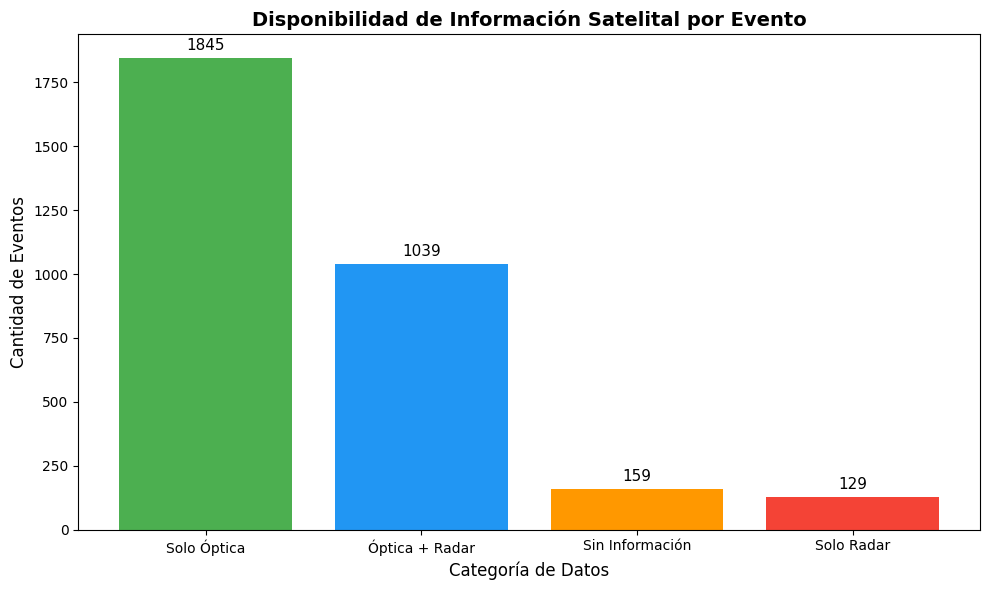

In [ ]:

import matplotlib.pyplot as plt

# Definir condiciones
has_opt = df['OPT_src'] != 'missing'
has_sar = df['SAR_src'] == 'real'

# Categorías utilizadas en el gráfico de barras
df['Category'] = 'Sin Información'
df.loc[has_opt & ~has_sar, 'Category'] = 'Solo Óptica'
df.loc[~has_opt & has_sar, 'Category'] = 'Solo Radar'
df.loc[has_opt & has_sar, 'Category'] = 'Óptica + Radar'

# Conteo de categorías
counts = df['Category'].value_counts()

# Organización descendente
counts = counts.sort_values(ascending=False)

# Cración de gráfico
plt.figure(figsize=(10, 6))
bars = plt.bar(counts.index, counts.values, color=['#4CAF50', '#2196F3', '#FF9800', '#F44336'])

# Estilo gráfico
plt.title('Disponibilidad de Información Satelital por Evento', fontweight='bold', fontsize=14)
plt.ylabel('Cantidad de Eventos', fontsize=12)
plt.xlabel('Categoría de Datos', fontsize=12)

# Add value labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max(counts.values)*0.01), int(yval), ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('disponibilidad_datos.png')

# Print summary for the response
print(counts)
print(f"Total eventos: {len(df)}")

En general fue posible obtener información asociada a **3013 eventos y "no eventos" de deslizamientos de tierra**, lo que indica un buen cubrimiento de la zona por parte de Landsat y Sentinel 2. Por el contrario, en el caso de radar se evidencia un faltante muy amplio debido a la fecha de lanzamiento del Sentinel 1 (3 de abril del 2014) y a la adecuación inicial que en promedio tardo entre el 2014-2015.Se trato de atender este faltante de información haciendo uso de imágenes de radar proporcionadas por ALOS PALSAR, sin embargo en GEE solo se presenta una colección anual.

Total Óptico: 2884
Total Radar: 1168
Sin Información: 159


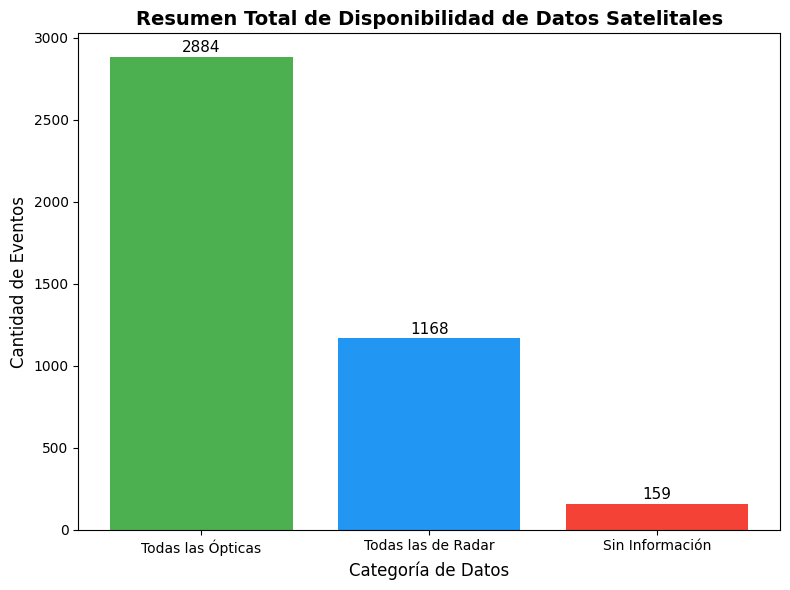

In [ ]:
# Calcular los totales independientes
# 'Todas las ópticas' incluye eventos que también tienen radar
total_optico = (df['OPT_src'] != 'missing').sum()

# 'Todas las de radar' incluye eventos que también tienen óptica
total_radar = (df['SAR_src'] == 'real').sum()

# 'Sin información' son los que no tienen absolutamente nada
total_ninguno = ((df['OPT_src'] == 'missing') & (df['SAR_src'] == 'missing')).sum()

# Preparar datos para el gráfico con formato LaTeX para negrita
etiquetas = ['Todas las Ópticas','Todas las de Radar','Sin Información']
valores = [total_optico, total_radar, total_ninguno]
colores = ['#4CAF50', '#2196F3', '#F44336']

# Crear el gráfico
plt.figure(figsize=(8, 6))
barras = plt.bar(etiquetas, valores, color=colores)

# Configuración de estilo
plt.title('Resumen Total de Disponibilidad de Datos Satelitales', fontweight='bold', fontsize=14)
plt.ylabel('Cantidad de Eventos', fontsize=12)
plt.xlabel('Categoría de Datos', fontsize=12)

# Añadir etiquetas de valor sobre las barras
for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + 10, int(yval),
             ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('resumen_total_disponibilidad.png')

# Resumen de consola
print(f"Total Óptico: {total_optico}")
print(f"Total Radar: {total_radar}")
print(f"Sin Información: {total_ninguno}")

Respecto a los años, se tiene un rezago bastante amplio relacionado con radar en los años  2015 y 2016 principalmente

      Sin_Opt  Sin_Rad  Sin_Gral
Year                            
2021        1        0         0
2022        1        0         0
2023        1        0         0
2024        1        0         0
2025        0        0         0


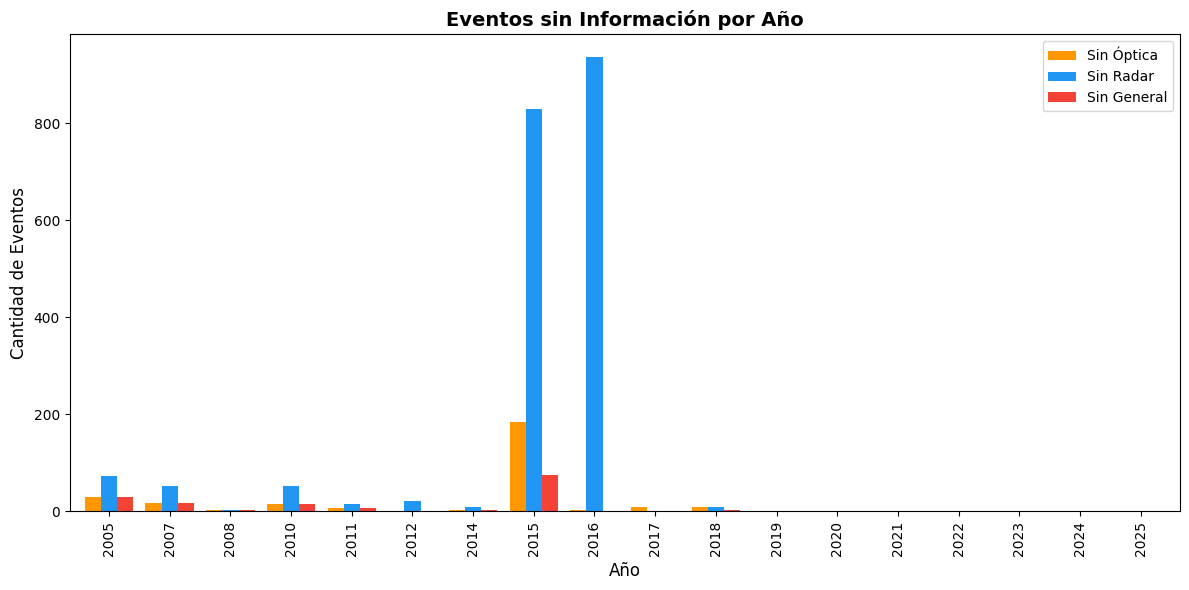

In [ ]:
# Extracción de año de fechas
df['Year'] = df['Fecha_E'].dt.year

# Versión ultra compacta
summary = df.assign(
    Sin_Opt = (df['OPT_src'] == 'missing'),
    Sin_Rad = (df['SAR_src'] != 'real'),
    Sin_Gral = (df['OPT_src'] == 'missing') & (df['SAR_src'] != 'real')
).groupby('Year')[['Sin_Opt', 'Sin_Rad', 'Sin_Gral']].sum()

# Graficar
ax = summary.plot(kind='bar', figsize=(12, 6), width=0.8, color=['#FF9800', '#2196F3', '#F44336'])
plt.title('Eventos sin Información por Año', fontweight='bold', fontsize=14)
plt.ylabel('Cantidad de Eventos', fontsize=12)
plt.xlabel('Año',fontsize=12)
plt.legend(['Sin Óptica', 'Sin Radar', 'Sin General'])
plt.tight_layout()
plt.savefig('faltantes_corto.png')

print(summary.tail())

**Como es posible observar en los anteriores gráficos, se evidencia la ausencia de información asociada tanto a variables derivadas de imágenes satelitáles ópticas como de radar. En el caso de la imágenes ópticas esta problemática se deriva por la prescencia de nubosidad continua en la zona de estudio y por consiguiente en la ubicación del evento y sus cercanías. Por otro lado, en el caso de radar, la falta de información se asocia principalmente a la disponibilidad histórica del sensor Sentinel-1, dado que su operación y adquisición sistemática inicia en años posteriores a varios eventos del periodo de análisis; en consecuencia, para esas fechas no existen escenas SAR en Earth Engine (o no cumplen los criterios mínimos de cobertura), generando ausencia de variables radar en los resultados.**

A continuación, se realiza un análisis para saber porque aunque para 2015 y 2016 , deberían haber imágenes de radar proporcionadas por Sentinel - 1, no se obtiene información.


In [ ]:
#. Filtrar todas las imágenes Sentinel-1 IW para 2015 y 2016
# No se filtra por fecha exacta del punto, sino por el año completo

s1_coleccion_2015 = ee.ImageCollection("COPERNICUS/S1_GRD") \
    .filterBounds(aoi) \
    .filterDate('2015-01-01', '2015-12-31') \
    .filter(ee.Filter.eq('instrumentMode', 'IW')) \
    .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV")) \
    .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))

s1_coleccion_2016 = ee.ImageCollection("COPERNICUS/S1_GRD") \
    .filterBounds(aoi) \
    .filterDate('2016-01-01', '2016-12-31') \
    .filter(ee.Filter.eq('instrumentMode', 'IW')) \
    .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV")) \
    .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))

# Se crean compuestos (mediana) para ver la cobertura espacial total
# Usamos la banda VV para la visualización general
mosaico_2015 = s1_coleccion_2015.select('VV').median().clip(aoi)
mosaico_2016 = s1_coleccion_2016.select('VV').median().clip(aoi)

# 4. Preparar puntos de éxito para referencia visual
df['Fecha_E'] = pd.to_datetime(df['Fecha_E'])
df_exito = df[(df['Fecha_E'].dt.year.isin([2015, 2016])) & (df['SAR_src'] == 'real')].copy()
features_exito = [ee.Feature(ee.Geometry.Point(json.loads(r['.geo'])['coordinates']), {'Codigo': str(r['Codigo'])}) for _, r in df_exito.iterrows()]
fc_exito = ee.FeatureCollection(features_exito)

# 5. Generar el mapa interactivo
Map = geemap.Map()
Map.centerObject(aoi, 8)

# Parámetros de visualización para radar (dB)
vis_params = {'min': -25, 'max': 0}

# Añadir las huellas de radar y los puntos
Map.addLayer(mosaico_2015, vis_params, 'Cobertura Radar 2015')
Map.addLayer(mosaico_2016, vis_params, 'Cobertura Radar 2016')
Map.addLayer(fc_exito, {'color': 'blue'}, 'Tus puntos con éxito (2015-2016)')

print(f"Imágenes encontradas en 2015: {s1_coleccion_2015.size().getInfo()}")
print(f"Imágenes encontradas en 2016: {s1_coleccion_2016.size().getInfo()}")

Map.add_colorbar(vis_params, label="Backscatter VV (dB)")
Map

Imágenes encontradas en 2015: 15
Imágenes encontradas en 2016: 50


Map(center=[5.91945114121049, -73.20996833527485], controls=(WidgetControl(options=['position', 'transparent_b…

En el anterior caso se demuestra que tanto para el año 2015 como para el año 2016, hay poca de existencia de imágenes, pero algunas de estas se pueden asociar a lo eventos ocurridos en este periodo de tiempo.

In [ ]:
# Se filtra en donde el atributo SAR_src es 'missing'
df_gap = df[df['SAR_src'] == 'missing'].reset_index(drop=True)
len(df_gap)


2004

In [ ]:
# Verificación de datos
if not df_gap.empty:
    fila_test = df_gap.iloc[550] # Fila que se desea analizar (se analiza una fila especifica)

    def diagnostico_detallado(fila):
        fecha_evento = ee.Date(fila['Fecha_E'].strftime('%Y-%m-%d')) # Convierte fecha de evento en ee.date
        inicio = fecha_evento.advance(-24, 'day') # ventana temporal de 24 días como en el código inical
        punto = ee.Geometry.Point([fila['Longitud'], fila['Latitud']]) # Crea geometría de punto con Longitud y Latitud

       # Búsqueda de imágenes de Sentinel-1, sin filtros de banda

        col = ee.ImageCollection("COPERNICUS/S1_GRD") \
                .filterBounds(punto) \
                .filterDate(inicio, fecha_evento)

        num_images = col.size().getInfo() # Número de imágenes encontradas

        print(f"--- Diagnóstico para el punto {fila['Codigo']} ---")
        print(f"Imágenes totales encontradas en 24 días: {num_images}")

        if num_images > 0:
            info = col.toList(num_images).getInfo() # Use num_images as count
            for i, img in enumerate(info):
                bands = img['bands']  # (Como VV, VH, HH, HV).
                band_names = [b['id'] for b in bands]
                mode = img['properties']['instrumentMode']
                print(f"Imagen {i+1}:")
                print(f"  - Bandas disponibles: {band_names}")
                print(f"  - Modo: {mode}")
                if 'VH' not in band_names:
                    print("  - [!] FALLA: No tiene banda VH (código la descarta)")
                if mode != 'IW':
                    print(f"  - [!] FALLA: El modo es {mode}, no IW (código la descarta)")
        else:
            print("No se encontraron imágenes Sentinel-1 para este punto y rango de fechas.")

    diagnostico_detallado(fila_test)
else:
    print("No hay eventos con SAR_src == 'missing' para diagnosticar.")

--- Diagnóstico para el punto 64203 ---
Imágenes totales encontradas en 24 días: 1
Imagen 1:
  - Bandas disponibles: ['VV', 'angle']
  - Modo: IW
  - [!] FALLA: No tiene banda VH (código la descarta)


In [ ]:
con_imagenes_pero_sin_vh = 0
total_sin_imagenes = 0
otros_casos = 0
total_puntos = len(df_gap)

print(f"Iniciando análisis de {total_puntos} puntos...")


# Para cada punto: Se define la fecha del evento. Se construye una ventana temporal retrospectiva
# de 24 días, coherente con la lógica del análisis SAR. Se crea la geometría puntual a partir de
# las coordenadas del evento.

for i, fila in df_gap.iterrows():
    fecha_evento = ee.Date(fila['Fecha_E'].strftime('%Y-%m-%d')) # Definición fecha del evento
    inicio = fecha_evento.advance(-24, 'day') # Ventana temporal retrospectiva de 24 días
    punto = ee.Geometry.Point([fila['Longitud'], fila['Latitud']]) # Creación de geometría puntual

    col = ee.ImageCollection("COPERNICUS/S1_GRD") \
            .filterBounds(punto) \
            .filterDate(inicio, fecha_evento)

    num_images = col.size().getInfo()

    if num_images == 0:
        total_sin_imagenes += 1  # No hay imágenes
    else:
        # Analizamos las bandas de las imágenes encontradas, se inspeccionan todas las imágenes disponibles.
        info = col.toList(num_images).getInfo()
        tiene_vh_alguna = any(['VH' in [b['id'] for b in img['bands']] for img in info]) #Se verifica si al menos una imagen contiene la banda VH.

        # El satélite  pasó, pero las adquisiciones no cumplen el requisito mínimo de polarización.
        if not tiene_vh_alguna:
            con_imagenes_pero_sin_vh += 1
        else:
            otros_casos += 1

print("-" * 30)
print(f"RESULTADOS DEL DIAGNÓSTICO:")
print(f"Puntos donde NO hay satélite (0 imágenes): {total_sin_imagenes}")
print(f"Puntos con imágenes pero SIN banda VH: {con_imagenes_pero_sin_vh}")
print(f"Puntos que sí tienen VH (revisar otros filtros): {otros_casos}")

Iniciando análisis de 2004 puntos...
------------------------------
RESULTADOS DEL DIAGNÓSTICO:
Puntos donde NO hay satélite (0 imágenes): 387
Puntos con imágenes pero SIN banda VH: 1616
Puntos que sí tienen VH (revisar otros filtros): 1


In [ ]:
import pandas as pd

# Suponiendo que df_gap tiene la columna 'Fecha_E'
fecha_limite_s1 = pd.to_datetime('2014-01-01')

pre_s1 = df_gap[pd.to_datetime(df_gap['Fecha_E']) < fecha_limite_s1].shape[0]
post_s1 = df_gap[pd.to_datetime(df_gap['Fecha_E']) >= fecha_limite_s1].shape[0]

print(f"Puntos antes de Ene-2014 (Sin S1 disponible): {pre_s1}")
print(f"Puntos después de Ene-2014 (Posible falta de cobertura): {post_s1}")

Puntos antes de Ene-2014 (Sin S1 disponible): 220
Puntos después de Ene-2014 (Posible falta de cobertura): 1784


In [ ]:
import pandas as pd

# Definir la fecha límite y filtrar los 615 puntos clave
fecha_limite_s1 = pd.to_datetime('2014-01-01')
df_post_s1 = df_gap[pd.to_datetime(df_gap['Fecha_E']) >= fecha_limite_s1].copy()

puntos_recuperados_vh = 0
puntos_persisten_solo_vv = 0
puntos_sin_datos_aun = 0

print(f"Analizando ventana de 24 días para {len(df_post_s1)} puntos...")

for i, fila in df_post_s1.iterrows():
    fecha_evento = ee.Date(pd.to_datetime(fila['Fecha_E']).strftime('%Y-%m-%d'))
    inicio = fecha_evento.advance(-24, 'day')
    punto = ee.Geometry.Point([fila['Longitud'], fila['Latitud']])

    col = ee.ImageCollection("COPERNICUS/S1_GRD") \
            .filterBounds(punto) \
            .filterDate(inicio, fecha_evento) \
            .filter(ee.Filter.eq('instrumentMode', 'IW'))

    count = col.size().getInfo()

    if count == 0:
        puntos_sin_datos_aun += 1
    else:
        # Verificamos si al menos UNA imagen de la colección tiene VH
        info = col.toList(count).getInfo()
        tiene_vh_alguna = any(['VH' in [b['id'] for b in img['bands']] for img in info])

        if tiene_vh_alguna:
            puntos_recuperados_vh += 1
        else:
            puntos_persisten_solo_vv += 1

print("-" * 30)
print(f"RESULTADOS CON VENTANA DE 24 DÍAS:")
print(f"Puntos que AHORA tienen VH: {puntos_recuperados_vh}")
print(f"Puntos que siguen siendo SOLO VV: {puntos_persisten_solo_vv}")
print(f"Puntos que siguen sin imágenes: {puntos_sin_datos_aun}")

Analizando ventana de 24 días para 1784 puntos...
------------------------------
RESULTADOS CON VENTANA DE 24 DÍAS:
Puntos que AHORA tienen VH: 1
Puntos que siguen siendo SOLO VV: 1616
Puntos que siguen sin imágenes: 167


**Como se pudo observar de acuerdo a los anteriores resultados, se establece que hay información que no contiene ambas polarizaciones, sino solo la VV, por lo tanto, a continuación se va a ingresar esta información en el csv resultante.**

In [ ]:
import ee
import geemap
import json
import pandas as pd
from google.colab import drive

# ================================================
# Conexión con Google Drive y Google Earth Engine
# ================================================

drive.mount("/content/drive")

PROJECT_ID = "ee-linapaolagarcia"
try:
    ee.Initialize(project=PROJECT_ID)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)

print("GEE listo ✅")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GEE listo ✅


In [ ]:
# ============================================================
# Inclusión de valores de VV cuando existan.
# ============================================================

# =============================
# 1) Asignación de rutas
# =============================

CSV_BASE = "/content/drive/MyDrive/TESIS-BOYACA/Imágenes/ExtracionVariables_OPT90_SAR24_BUF60_30m_BOYACA_COMPLETO_17062026_defajustadoV2.csv"

# Carpeta Drive y nombre del parche
PATCH_FOLDER = "/content/drive/MyDrive/TESIS-BOYACA/Imágenes"
PATCH_DESC   = "PARCHE_SAR24_BUF60_VVONLY_2014_01_2016_12_BoyacaV2"

# Salida final fusionada
CSV_OUT_UPDATED = "/content/drive/MyDrive/TESIS_GEE/ExtracionVariables_OPT90_SAR24_BUF60_30m_Boyaca_COMPLETO_ACTUALIZADO_VVONLYajusteV2.csv"

# Ruta esperada del parche (NO existirá hasta que termine la tarea EE)
CSV_PATCH_EXPECTED = os.path.join(PATCH_FOLDER, f"{PATCH_DESC}.csv")

# ==================================================
# 2) PARÁMETROS SAR (Derivados de código principal)
# =================================================

SCALE = 30
SAR_DAYS = 24
BUF_M = 60

MIN_VALID_FRAC_S1  = 0.10
TILE_SCALE = 16
MAX_PIXELS = 1e8

S1_PASS  = None
S1_ORBIT = None
S1_LIMIT = 60
S1_SPECKLE_RADIUS_M = 30
S1_DB_MIN = -35
S1_DB_MAX = 5

# ====================================================
# 3) LEER BASE + EXTRAER COORDS (.geo) y DEFINIR GAP
# ====================================================

base = pd.read_csv(CSV_BASE) # Leer csv base

# Verificación de la existencia de la columna de geometría
if ".geo" not in base.columns:
    raise ValueError("No existe la columna '.geo' en el CSV base. Verifica que sea un export de GEE con geometría.")

def get_coords(geo_str):
    try:
        g = json.loads(geo_str)
        return g.get("coordinates", [None, None])
    except Exception:
        return [None, None]

base["Longitud"] = base[".geo"].apply(lambda x: get_coords(x)[0])
base["Latitud"]  = base[".geo"].apply(lambda x: get_coords(x)[1])

# Normalizar llave
base["Codigo"]  = base["Codigo"].astype(str).str.strip()
base["Fecha_E"] = pd.to_datetime(base["Fecha_E"], errors="coerce")

# Filtrar filas con info mínima
base = base.dropna(subset=["Codigo", "Fecha_E", "Latitud", "Longitud"]).copy()

# Rango temporal situaciones donde se encuentra solo información de
# la polarización VV
fecha_inicio = pd.Timestamp("2014-01-01")
fecha_fin    = pd.Timestamp("2016-12-31")
cond_fecha = (base["Fecha_E"] >= fecha_inicio) & (base["Fecha_E"] <= fecha_fin)

# Criterio de “SAR incompleto”, selecciona las puntos que tiene el atributo SAR-src como
# missing y que por consiguiente VV_mean_24d_30m esta vacío.
col_sarsrc = "SAR_src"
col_vv = f"VV_mean_{SAR_DAYS}d_30m"

cond_missing = (base[col_sarsrc].astype(str) == "missing") if col_sarsrc in base.columns else False
cond_vv_nan  = base[col_vv].isna() if col_vv in base.columns else False

gap = base[cond_fecha & (cond_missing | cond_vv_nan)].copy()

print("CSV base:", CSV_BASE)
print("Eventos objetivo (2014-01-01 a 2016-12-31 con SAR incompleto):", len(gap))
print("Rango fechas GAP:", gap["Fecha_E"].min(), "→", gap["Fecha_E"].max())

if len(gap) == 0:
    raise ValueError("No hay eventos 'gap' con SAR incompleto en el rango indicado. Revisa filtros/columnas.")

# =================================================
# 4) Construcción de FeatureCollection (solo gap)
# =================================================
# Se conviertesn los datos procesados con pandas en un formato
# complatible con GEE.
def to_feat(row):
    pt = ee.Geometry.Point([float(row["Longitud"]), float(row["Latitud"])])
    return ee.Feature(pt, {
        "Codigo": str(row["Codigo"]).strip(),
        "Fecha_E": row["Fecha_E"].strftime("%Y-%m-%d")
    })

fc_gap = ee.FeatureCollection([to_feat(r) for _, r in gap.iterrows()])
print("N (FeatureCollection gap):", fc_gap.size().getInfo())

# =============================
# 5) Funciones de ayuda
# =============================
# Convierte un valor lógico (boolean) en un número 0/1 en entorno GEE
def b2i(b):
    return ee.Number(ee.Algorithms.If(b, 1, 0))

# Implementa un AND lógico robusto en GEE.
def band_and(a, b):
    return b2i(a).multiply(b2i(b)).eq(1)

# Evita que el codigo falle cuando un valor NO existe en
# un diccionario.

def dict_get_safe(dct, key, default=None):
    dct = ee.Dictionary(dct)
    key = ee.String(key)
    return ee.Algorithms.If(dct.contains(key), dct.get(key), default)


# Calcula media y desviación estándar (estadísticos zonales) de las bandas de una imagen dentro de una geometría (buffer).
def zonal_mean_std(img, geom, scale):
    reducer = ee.Reducer.mean().combine(ee.Reducer.stdDev(), sharedInputs=True)
    return ee.Dictionary(img.reduceRegion(
        reducer=reducer,
        geometry=geom,
        scale=scale,
        maxPixels=MAX_PIXELS,
        bestEffort=False,
        tileScale=TILE_SCALE
    ))

# Estima la fracción de píxeles válidos (0 a 1) dentro del buffer.
def valid_fraction(img_band, geom, scale):
    m = img_band.mask().gt(0).unmask(0).toFloat().rename("valid")
    d = ee.Dictionary(m.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=geom,
        scale=scale,
        maxPixels=MAX_PIXELS,
        bestEffort=False,
        tileScale=TILE_SCALE
    ))
    return ee.Number(d.get("valid"))

# Crea una banda “vacía” (enmascarada), con el nombre indicado.
def empty_band(name):
    return ee.Image.constant(0).rename(name).updateMask(ee.Image.constant(0))

# Convierte un valor en dB a escala lineal.
def db_to_lin(db_value):
    return ee.Number(10).pow(ee.Number(db_value).divide(10))

# Aplica un suavizado espacial (mediana focal) para reducir el speckle del radar.
def speckle_smooth_db(img_db, radius_m=S1_SPECKLE_RADIUS_M):
    radius_m = ee.Number(radius_m)
    return ee.Image(ee.Algorithms.If(
        radius_m.lte(0),
        img_db,
        img_db.focal_median(radius=radius_m, units="meters")
    ))

# ELimina píxeles problemáticos en Sentinel-1 (VV/VH) usando:
# las máscara nativa de las bansas así como el rango de retrodispersión fijado.
def mask_s1_edges_db_vvvh(img):
    vv = img.select("VV")
    vh = img.select("VH")
    m = (vv.mask().And(vh.mask())
         .And(vv.gt(S1_DB_MIN)).And(vv.lt(S1_DB_MAX))
         .And(vh.gt(S1_DB_MIN)).And(vh.lt(S1_DB_MAX)))
    return img.updateMask(m)

# ===============================================
# Extracción de variable SAR permitiendo VV_only
# ==============================================

# Extrae variables SAR de Sentinel-1 en una ventana temporal fde 24 días con un buffer 60m, pero con una diferencia clave frente al código original:
# Si existen imágenes con VV y VH → calcula métricas completas y marca SAR_src = "real".
# Si no existen imágenes con VH, pero sí con VV → calcula solo VV, deja las métricas que requieren VH como None y marca SAR_src = "vv_only".
# Si no hay imágenes → marca SAR_src = "missing".

def get_s1_sar_vv_or_vvvh(geom, d, sar_days):
    start = d.advance(-sar_days, "day")

    s1_base = (ee.ImageCollection("COPERNICUS/S1_GRD")
               .filterBounds(geom)
               .filterDate(start, d)
               .filter(ee.Filter.eq("instrumentMode", "IW"))
               .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV")))

    if S1_PASS is not None:
        s1_base = s1_base.filter(ee.Filter.eq("orbitProperties_pass", S1_PASS))
    if S1_ORBIT is not None:
        s1_base = s1_base.filter(ee.Filter.eq("relativeOrbitNumber_start", S1_ORBIT))

    s1_base = s1_base.sort("system:time_start", False).limit(S1_LIMIT)
    n_all = s1_base.size()

# Indicaciones para llenar el csv en caso de que no existan imágenes.

    def out_missing():
        return ee.Dictionary({
            "SAR_sensor": "S1_GRD_IW",
            "SAR_src": "missing",
            "SAR_valid_frac": 0,
            "VV_mean": None, "VV_std": None,
            "VH_mean": None, "VH_std": None,
            "VVminusVH": None,
            "VVdivVH": None
        })

# En caso de que si hayan  imágenes.

    def out_real():
        col_vvvh = s1_base.filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH")) # contiene solo imágenes que además de VV tienen VH.
        use_vvvh = col_vvvh.size().gt(0) # es True si hay al menos una.

        col = ee.ImageCollection(ee.Algorithms.If(use_vvvh, col_vvvh, s1_base)) # Si hay VH → usa la colección VV+VH. Si no hay VH → usa la colección solo VV.

        def select_bands(img):
            return ee.Image(ee.Algorithms.If(use_vvvh, img.select(["VV", "VH"]), img.select(["VV"])))
        col_sel = col.map(select_bands)

        def clean(img):
            return ee.Image(ee.Algorithms.If(use_vvvh, mask_s1_edges_db_vvvh(img), img)) # limpia SOLO si hay VV y VH

         # crea una sola imagen compuesta, donde cada píxel es la mediana de todos los píxeles en el tiempo.
        med = col_sel.map(clean).median()

        #  Suavizado VV
        vv_db = speckle_smooth_db(med.select("VV"), S1_SPECKLE_RADIUS_M).rename("VV")

        # Si existe banda VH la suaviza de lo contrario crea una banda "VH" vacia
        # en,ascarada
        vh_db = ee.Image(ee.Algorithms.If(
            use_vvvh,
            speckle_smooth_db(med.select("VH"), S1_SPECKLE_RADIUS_M).rename("VH"),
            empty_band("VH")
        ))

        # Imagen final con bandas consistentes
        img_db = vv_db.addBands(vh_db)

        # Calculo de estadísticos zonales

        stats = zonal_mean_std(img_db, geom, SCALE)

        # Confirma si realmente existen valores
        hasVV = stats.contains("VV_mean")
        hasVH = ee.Algorithms.If(use_vvvh, stats.contains("VH_mean"), False)

        # Extraer VV y su dispersión solo si existe
        vv_mean = ee.Algorithms.If(hasVV, stats.get("VV_mean"), None)
        vv_std  = ee.Algorithms.If(stats.contains("VV_stdDev"), stats.get("VV_stdDev"), None)

        # Extraer VH y su dispersión solo si existe
        vh_mean = ee.Algorithms.If(hasVH, stats.get("VH_mean"), None)
        vh_std  = ee.Algorithms.If(stats.contains("VH_stdDev"), stats.get("VH_stdDev"), None)

        # Detecta si falta VH
        missing_vh = b2i(ee.Algorithms.IsEqual(vh_mean, None)).eq(1)

        # Si no falta VH calcula VV − VH y VV/VH en escala lineal
        vv_minus_vh = ee.Algorithms.If(
            missing_vh, None,
            ee.Number(vv_mean).subtract(ee.Number(vh_mean))
        )

        vv_lin = ee.Algorithms.If(missing_vh, None, db_to_lin(vv_mean))
        vh_lin = ee.Algorithms.If(missing_vh, None, db_to_lin(vh_mean))

        vv_div_vh = ee.Algorithms.If(
            missing_vh, None,
            ee.Number(vv_lin).divide(ee.Number(vh_lin).add(1e-6))
        )

        # Fracción de píxeles válidos en el buffer
        sar_valid = valid_fraction(img_db.select("VV"), geom, SCALE)

        # Clasificación.
       # Si NO hay VV_mean → "missing"
       # Si hay VV_mean y hay VH_mean → "real"
       # Si hay VV_mean pero no VH_mean → "vv_only"

        sar_src0 = ee.String(ee.Algorithms.If(
            hasVV,
            ee.Algorithms.If(hasVH, "real", "vv_only"),
            "missing"
        ))

        # Reglas de calidad: si cobertura es baja → “missing”
        not_missing = b2i(ee.String(sar_src0).equals("missing")).eq(0)

        sar_src = ee.String(ee.Algorithms.If(
            band_and(not_missing, ee.Number(sar_valid).gte(MIN_VALID_FRAC_S1)),
            sar_src0,
            "missing"
        ))

        # Si quedó missing, borrar valores para no “contaminar” el CSV

        ok = b2i(ee.String(sar_src).equals("missing")).eq(0)

        vv_mean = ee.Algorithms.If(ok, vv_mean, None)
        vv_std  = ee.Algorithms.If(ok, vv_std,  None)
        vh_mean = ee.Algorithms.If(ok, vh_mean, None)
        vh_std  = ee.Algorithms.If(ok, vh_std,  None)
        vv_minus_vh = ee.Algorithms.If(ok, vv_minus_vh, None)
        vv_div_vh   = ee.Algorithms.If(ok, vv_div_vh,   None)
        sar_valid   = ee.Number(ee.Algorithms.If(ok, sar_valid, 0))

        # Salida del diccionario.

        return ee.Dictionary({
            "SAR_sensor": "S1_GRD_IW",
            "SAR_src": sar_src,
            "SAR_valid_frac": sar_valid,
            "VV_mean": vv_mean, "VV_std": vv_std,
            "VH_mean": vh_mean, "VH_std": vh_std,
            "VVminusVH": vv_minus_vh,
            "VVdivVH": vv_div_vh
        })

    return ee.Dictionary(ee.Algorithms.If(n_all.gt(0), out_real(), out_missing()))

# =========================================================================
# 7) CREA proceso en GEE y exporta archivo csv con esta información de los
# puntos problemáticos.
# =========================================================================
def extract_sar_patch(feat):
    d = ee.Date(ee.String(feat.get("Fecha_E")))
    geom = feat.geometry().buffer(BUF_M)
    sar = ee.Dictionary(get_s1_sar_vv_or_vvvh(geom, d, SAR_DAYS))

    return feat.set({
        "SAR_sensor": dict_get_safe(sar, "SAR_sensor", None),
        "SAR_src": dict_get_safe(sar, "SAR_src", None),
        "SAR_valid_frac": dict_get_safe(sar, "SAR_valid_frac", None),
        f"VV_mean_{SAR_DAYS}d_30m": dict_get_safe(sar, "VV_mean", None),
        f"VV_std_{SAR_DAYS}d_30m":  dict_get_safe(sar, "VV_std", None),
        f"VH_mean_{SAR_DAYS}d_30m": dict_get_safe(sar, "VH_mean", None),
        f"VH_std_{SAR_DAYS}d_30m":  dict_get_safe(sar, "VH_std", None),
        f"VVminusVH_{SAR_DAYS}d_30m": dict_get_safe(sar, "VVminusVH", None),
        f"VVdivVH_{SAR_DAYS}d_30m":   dict_get_safe(sar, "VVdivVH", None),
    })

fc_patch = fc_gap.map(extract_sar_patch)

patch_cols = [
    "Codigo", "Fecha_E",
    "SAR_sensor", "SAR_src", "SAR_valid_frac",
    f"VV_mean_{SAR_DAYS}d_30m", f"VV_std_{SAR_DAYS}d_30m",
    f"VH_mean_{SAR_DAYS}d_30m", f"VH_std_{SAR_DAYS}d_30m",
    f"VVminusVH_{SAR_DAYS}d_30m", f"VVdivVH_{SAR_DAYS}d_30m"
]
fc_patch_small = fc_patch.select(patch_cols)


task = ee.batch.Export.table.toDrive(
    collection=fc_patch_small,
    description=PATCH_DESC,
    folder=PATCH_FOLDER,
    fileFormat="CSV"
)
task.start()

print("\n✅ PARCHE exportándose:", PATCH_DESC)
print("Ruta esperada:", CSV_PATCH_EXPECTED)


CSV base: /content/drive/MyDrive/TESIS-BOYACA/Imágenes/ExtracionVariables_OPT90_SAR24_BUF60_30m_BOYACA_COMPLETO_17062026_defajustadoV2.csv
Eventos objetivo (2014-01-01 a 2016-12-31 con SAR incompleto): 1774
Rango fechas GAP: 2014-05-15 00:00:00 → 2016-06-01 00:00:00
N (FeatureCollection gap): 1774

✅ PARCHE exportándose: PARCHE_SAR24_BUF60_VVONLY_2014_01_2016_12_BoyacaV2
Ruta esperada: /content/drive/MyDrive/TESIS-BOYACA/Imágenes/PARCHE_SAR24_BUF60_VVONLY_2014_01_2016_12_BoyacaV2.csv


In [ ]:
# =======================================
# Fusión del parche con el archivo base
# =======================================

# Vefica que el documento exista
import os
if not os.path.exists(CSV_PATCH_EXPECTED):
    raise FileNotFoundError(f"No existe todavía el parche en Drive: {CSV_PATCH_EXPECTED}")

patch = pd.read_csv(CSV_PATCH_EXPECTED)

base2 = pd.read_csv(CSV_BASE)

# Se normaliza tanto el codigo como la fecha del csv inical y del generado en el paso anterior
base2["Codigo"]  = base2["Codigo"].astype(str).str.strip()
patch["Codigo"]  = patch["Codigo"].astype(str).str.strip()

base2["Fecha_E"] = pd.to_datetime(base2["Fecha_E"], errors="coerce").dt.strftime("%Y-%m-%d")
patch["Fecha_E"] = pd.to_datetime(patch["Fecha_E"], errors="coerce").dt.strftime("%Y-%m-%d")

# Se define la llave de la unión.
key = ["Codigo", "Fecha_E"]

# Definir qué columnas SAR se van a actualizar
sar_cols = [
    "SAR_sensor", "SAR_src", "SAR_valid_frac",
    f"VV_mean_{SAR_DAYS}d_30m", f"VV_std_{SAR_DAYS}d_30m",
    f"VH_mean_{SAR_DAYS}d_30m", f"VH_std_{SAR_DAYS}d_30m",
    f"VVminusVH_{SAR_DAYS}d_30m", f"VVdivVH_{SAR_DAYS}d_30m"
]

# Convertir ambos a índices por llave y alinear filas
sar_cols = [c for c in sar_cols if (c in base2.columns and c in patch.columns)]

base_i  = base2.set_index(key)
patch_i = patch.set_index(key).reindex(base_i.index)

# Si el parche tiene dato → reemplaza el base
# Si el parche es NaN → conserva lo del base

for c in sar_cols:
    base_i[c] = base_i[c].where(~patch_i[c].notna(), patch_i[c])

# Guardar el CSV final
out = base_i.reset_index()
out.to_csv(CSV_OUT_UPDATED, index=False)

print("\n✅ CSV FINAL actualizado guardado en:", CSV_OUT_UPDATED)
print("Conteo SAR_src (real/missing/vv_only):")
print(out["SAR_src"].value_counts(dropna=False).head(20))


✅ CSV FINAL actualizado guardado en: /content/drive/MyDrive/TESIS_GEE/ExtracionVariables_OPT90_SAR24_BUF60_30m_Boyaca_COMPLETO_ACTUALIZADO_VVONLYajusteV2.csv
Conteo SAR_src (real/missing/vv_only):
SAR_src
vv_only    1615
real       1168
missing     389
Name: count, dtype: int64


In [ ]:
import ee
import geemap
import json
import pandas as pd

# 1. Definir el área de estudio basada en la envolvente de tus puntos
df = pd.read_csv('/content/drive/MyDrive/TESIS-BOYACA/Imágenes/ExtracionVariables_OPT90_SAR24_BUF60_30m_Boyaca_COMPLETO_ACTUALIZADO_VVONLYajusteV2.csv')
# Convertir la columna 'Fecha_E' a tipo datetime
df['Fecha_E'] = pd.to_datetime(df['Fecha_E'])
def get_coords(geo_str):
    g = json.loads(geo_str)
    return g['coordinates']

# Extract Longitud and Latitud from the '.geo' column
df['Longitud'] = df['.geo'].apply(lambda x: get_coords(x)[0])
df['Latitud'] = df['.geo'].apply(lambda x: get_coords(x)[1])

coords = df['.geo'].apply(get_coords).tolist()
aoi = ee.Geometry.MultiPoint(coords).convexHull().buffer(20000)

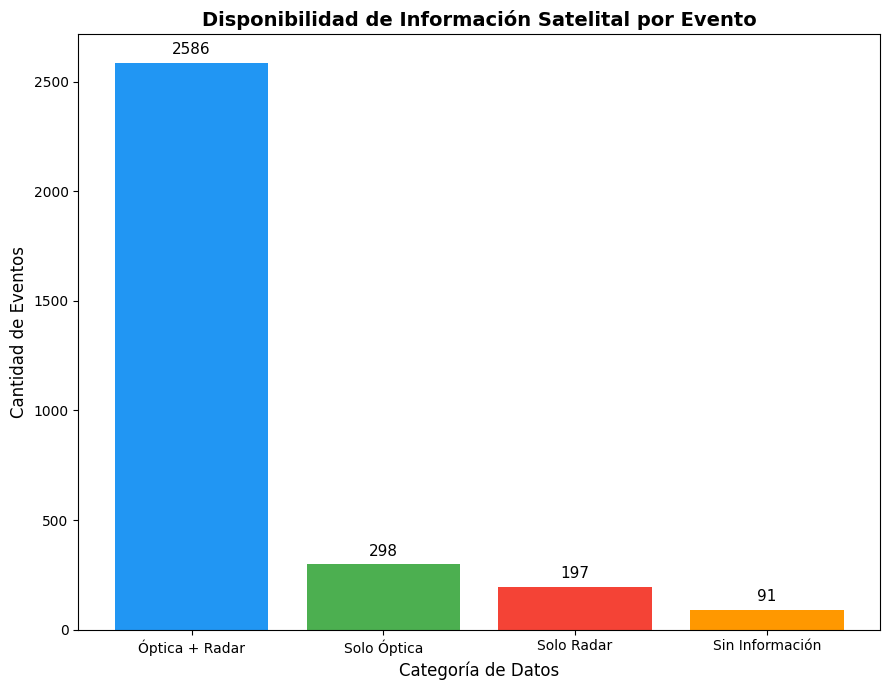

Category
Óptica + Radar     2586
Solo Óptica         298
Solo Radar          197
Sin Información      91
Name: count, dtype: int64
Total eventos: 3172


In [ ]:
import matplotlib.pyplot as plt

# ---------------------------
# Condiciones simples
# ---------------------------
has_opt = df['OPT_src'] != 'missing'
has_sar = df['SAR_src'].isin(['real', 'vv_only'])

# ---------------------------
# Categorías claras
# ---------------------------
df['Category'] = 'Sin Información'
df.loc[has_opt & has_sar, 'Category'] = 'Óptica + Radar'
df.loc[has_opt & ~has_sar, 'Category'] = 'Solo Óptica'
df.loc[~has_opt & has_sar, 'Category'] = 'Solo Radar'

# ---------------------------
# Conteo
# ---------------------------
counts = df['Category'].value_counts().sort_values(ascending=False)

# ---------------------------
# Gráfico
# ---------------------------
plt.figure(figsize=(9, 7))

# Define colores a través del diccionario
colors_map = {
    'Óptica + Radar': '#2196F3' ,
    'Solo Óptica':'#4CAF50' ,
    'Sin Información': '#FF9800',
    'Solo Radar': '#F44336'  # Assigning a specific color to 'Solo Radar'
}

# Ensure the order of colors matches the order of counts.index
ordered_colors = [colors_map[cat] for cat in counts.index]

bars = plt.bar(
    counts.index,
    counts.values,
    color=ordered_colors
)

plt.title('Disponibilidad de Información Satelital por Evento', fontsize=14, fontweight='bold')
plt.ylabel('Cantidad de Eventos', fontsize=12)
plt.xlabel('Categoría de Datos', fontsize=12)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + max(counts.values)*0.01,
        int(yval),
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.tight_layout()
plt.savefig('disponibilidad_datos_simplificada.png', dpi=300)
plt.show()

print(counts)
print(f"Total eventos: {len(df)}")

**Se puede destacar que de los 3172 puntos tanto de deslizamiento como de no deslizamiento, 2586 tienen informacion tanto de imagenesopticas como de radar bien sea en una polarización o en ambas.**

      Sin_Opt  Sin_Rad  Sin_Gral
Year                            
2021        1        0         0
2022        1        0         0
2023        1        0         0
2024        1        0         0
2025        0        0         0


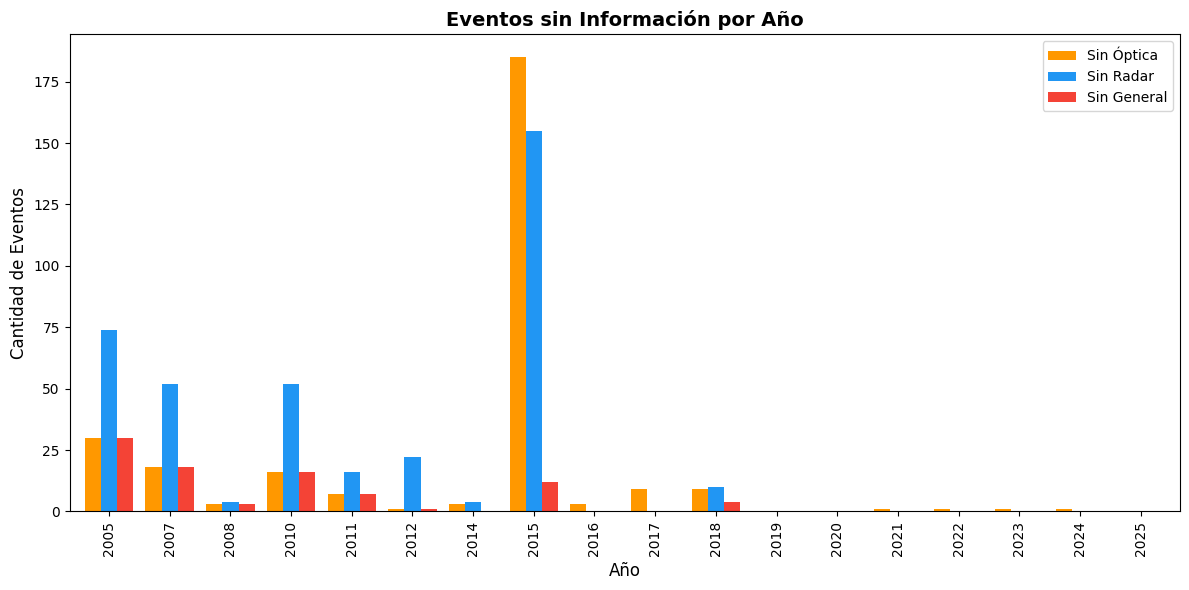

In [ ]:
# Extracción de año de fechas
df['Year'] = df['Fecha_E'].dt.year

# Versión ultra compacta
summary = df.assign(
    Sin_Opt = (df['OPT_src'] == 'missing'),
    Sin_Rad = (~df['SAR_src'].isin(['real', 'vv_only'])), # Corrected: Use isin() and invert the condition for 'missing' radar
    Sin_Gral = (df['OPT_src'] == 'missing') & (~df['SAR_src'].isin(['real', 'vv_only'])) # Corrected: Use isin() and invert the condition for 'missing' radar
).groupby('Year')[['Sin_Opt', 'Sin_Rad', 'Sin_Gral']].sum()

# Graficar
ax = summary.plot(kind='bar', figsize=(12, 6), width=0.8, color=['#FF9800', '#2196F3', '#F44336'])
plt.title('Eventos sin Información por Año', fontweight='bold', fontsize=14)
plt.ylabel('Cantidad de Eventos', fontsize=12)
plt.xlabel('Año',fontsize=12)
plt.legend(['Sin Óptica', 'Sin Radar', 'Sin General'])
plt.tight_layout()
plt.savefig('faltantes_corto.png')

print(summary.tail())

In [ ]:
import pandas as pd
import ee
import json

# ===============
# Carga de CSV
# ===============

df = pd.read_csv('/content/drive/MyDrive/TESIS_GEE/ExtracionVariables_OPT90_SAR24_BUF60_30m_Boyaca_COMPLETO_ACTUALIZADO_VVONLYajusteV2.csv')

print("Filas:", len(df))
print("Columnas:", df.columns.tolist()[:30], "...")

# Ajusta de nombres en el CSV
COL_LON  = "Longitud"
COL_LAT  = "Latitud"
COL_DATE = "Fecha_E"
COL_ID   = "Codigo"

if COL_ID not in df.columns:
    df[COL_ID] = df.index.astype(int)

# Extracción de Longitud and Latitud a partir de la columna '.geo'
def get_coords(geo_str):
    g = json.loads(geo_str)
    return g['coordinates']

df[COL_LON] = df['.geo'].apply(lambda x: get_coords(x)[0])
df[COL_LAT] = df['.geo'].apply(lambda x: get_coords(x)[1])

# Normalización de fechas
df[COL_DATE] = pd.to_datetime(df[COL_DATE], errors="coerce").dt.strftime("%Y-%m-%d")
df = df.dropna(subset=[COL_DATE, COL_LAT, COL_LON]).copy()
print("Filas válidas:", len(df))


# =============================================
# 1) Definición de funciones ALOS PALSAR anual
# =============================================

# Convierte DN → retrodispersión radar en dB
def palsar_dn_to_db(img, band):
    """gamma0(dB) = 10*log10(DN^2) - 83"""
    dn = img.select(band).toFloat()
    db = dn.pow(2).log10().multiply(10.0).subtract(83.0)
    return db.rename(f"{band}_db")

def get_palsar_annual_image(year):
    """
    Selecciona mosaico anual:
    - <2015: JAXA/ALOS/PALSAR/YEARLY/SAR
    - >=2015: JAXA/ALOS/PALSAR/YEARLY/SAR_EPOCH
    Maneja gap 2011-2014 devolviendo None.
    """
    year = ee.Number(year)
    in_gap = year.gte(2011).And(year.lte(2014)) # Vacío entre 2011-2014

    col_old = ee.ImageCollection("JAXA/ALOS/PALSAR/YEARLY/SAR") \
        .filter(ee.Filter.calendarRange(year, year, "year"))

    col_new = ee.ImageCollection("JAXA/ALOS/PALSAR/YEARLY/SAR_EPOCH") \
        .filter(ee.Filter.calendarRange(year, year, "year"))

    chosen = ee.ImageCollection(ee.Algorithms.If(year.gte(2015), col_new, col_old))
    img = ee.Image(ee.Algorithms.If(chosen.size().gt(0), chosen.first(), None))
    img = ee.Image(ee.Algorithms.If(in_gap, None, img))
    return img

# Convierte un conjunto de píxeles en un valor estadístico.
def zonal_mean_std(img, geom, scale=25):
    reducer = ee.Reducer.mean().combine(
        reducer2=ee.Reducer.stdDev(),
        sharedInputs=True
    )
    return img.reduceRegion(
        reducer=reducer,
        geometry=geom,
        scale=scale,
        bestEffort=True,
        maxPixels=1e13
    )

def add_palsar_to_feature(ft, buffer_m=60, scale=25):
    """
    ft debe tener propiedades: Fecha_E, y geometría en punto.
    Agrega HH_db/HV_db (mean y stdDev) + HH_HV_db (mean y stdDev) + año.
    """
    d = ee.Date(ft.get("Fecha_E"))
    year = ee.Number(d.get("year"))
    geom = ft.geometry().buffer(buffer_m)

    img = get_palsar_annual_image(year)

    def when_missing():
        return ft.set({
            "PALSAR_year": year,
            "HH_db_mean": None, "HH_db_stdDev": None,
            "HV_db_mean": None, "HV_db_stdDev": None,
            "HH_HV_db_mean": None, "HH_HV_db_stdDev": None,
            "PALSAR_ok": 0
        })

    def when_available():
        hh_db = palsar_dn_to_db(img, "HH")
        hv_db = palsar_dn_to_db(img, "HV")
        hh_hv = hh_db.subtract(hv_db).rename("HH_HV_db")
        stack = hh_db.addBands(hv_db).addBands(hh_hv)

        stats = zonal_mean_std(stack, geom, scale=scale)
        return ft.set(stats).set({"PALSAR_year": year, "PALSAR_ok": 1})

    return ee.Feature(ee.Algorithms.If(img, when_available(), when_missing()))


# ===================================
# 2) Pasar df -> FeatureCollection
# ===================================
def df_to_fc(df_slice):
    feats = [] #Preparacion de lista vacia
    for _, r in df_slice.iterrows():
        pt = ee.Geometry.Point([float(r[COL_LON]), float(r[COL_LAT])]) # Ubicacion del punto en entorno GEE
        feats.append(
            ee.Feature(pt, {
                "Codigo": str(r[COL_ID]),
                "Fecha_E": str(r[COL_DATE])
            })
        )
    return ee.FeatureCollection(feats)

# Parámetros
BUFFER_M = 60
SCALE    = 25   # PALSAR anual trabaja bien en 25 m (mosaico)

# Tamaño de lote
BATCH = 300

fc_list = []
n = len(df)

for i in range(0, n, BATCH):
    df_b = df.iloc[i:i+BATCH]
    fc_b = df_to_fc(df_b).map(lambda f: add_palsar_to_feature(f, buffer_m=BUFFER_M, scale=SCALE))
    fc_list.append(fc_b)

fc_all = ee.FeatureCollection(fc_list).flatten()
print("FeatureCollection listo.")


# ============================================================
# 3) Exportar a Drive (CSV)
# ============================================================
task = ee.batch.Export.table.toDrive(
    collection=fc_all,
    description="PALSAR_ANUAL_Boyaca_BUF60",
    folder="TESIS_GEE",
    fileNamePrefix="PALSAR_ANUAL_BOYACA_BUF60_180626",
    fileFormat="CSV"
)
task.start()
print("Exportación iniciada: revisa Tasks en Earth Engine / Colab.")

Filas: 3172
Columnas: ['Codigo', 'Fecha_E', 'system:index', 'EVI_mean_90d_30m', 'EVI_std_90d_30m', 'HH_mean_24d_25m', 'HH_std_24d_25m', 'HHdivHV_24d_25m', 'HHminusHV_24d_25m', 'HV_mean_24d_25m', 'HV_std_24d_25m', 'NBR_mean_90d_30m', 'NBR_std_90d_30m', 'NDVI_mean_90d_30m', 'NDVI_std_90d_30m', 'NDWI_mean_90d_30m', 'NDWI_std_90d_30m', 'OPT_src', 'OPT_valid_frac', 'SAR_sensor', 'SAR_src', 'SAR_valid_frac', 'VH_mean_24d_30m', 'VH_std_24d_30m', 'VV_mean_24d_30m', 'VV_std_24d_30m', 'VVdivVH_24d_30m', 'VVminusVH_24d_30m', 'conf_BUFFER_M', 'conf_OPT_DAYS'] ...
Filas válidas: 3172
FeatureCollection listo.
Exportación iniciada: revisa Tasks en Earth Engine / Colab.


In [ ]:
import pandas as pd

# 1. Cargar ambos archivos
df_principal = pd.read_csv('/content/drive/MyDrive/TESIS_GEE/ExtracionVariables_OPT90_SAR24_BUF60_30m_Boyaca_COMPLETO_ACTUALIZADO_VVONLYajusteV2.csv')
df_palsar = pd.read_csv('/content/drive/MyDrive/TESIS_GEE/PALSAR_ANUAL_BOYACA_BUF60_180626.csv')

# 2. Asegurar que las llaves de unión tengan el mismo formato
# Se convierte el 'Codigo' a numérico y 'Fecha_E' a texto para evitar errores de coincidencia
df_principal['Codigo'] = pd.to_numeric(df_principal['Codigo'], errors='coerce')
df_palsar['Codigo'] = pd.to_numeric(df_palsar['Codigo'], errors='coerce')

df_principal['Fecha_E'] = df_principal['Fecha_E'].astype(str)
df_palsar['Fecha_E'] = df_palsar['Fecha_E'].astype(str)

# 3. Seleccionar y renombrar las columnas del archivo PALSAR para que coincidan con el destino
# Se usa un diccionario para mapear los nombres del archivo de GEE a los nombres de tu tesis
palsar_subset = df_palsar[[
    'Codigo',
    'Fecha_E',
    'HH_db_mean',
    'HH_db_stdDev',
    'HV_db_mean',
    'HV_db_stdDev',
    'HH_HV_db_mean',
    'HH_HV_db_stdDev',
    'PALSAR_ok',
    'PALSAR_year'
]].copy()

# 4. Realizar la unión
# Esto mantiene todos los datos originales y pega los de PALSAR donde haya coincidencia
df_final = pd.merge(df_principal, palsar_subset, on=['Codigo', 'Fecha_E'], how='left')

# 5. Asignar los valores a las columnas específicas que mencionaste
df_final['HH_mean_24d_25m'] = df_final['HH_db_mean']
df_final['HH_std_24d_25m'] = df_final['HH_db_stdDev']
df_final['HV_mean_24d_25m'] = df_final['HV_db_mean']
df_final['HV_std_24d_25m'] = df_final['HV_db_stdDev']
df_final['HHminusHV_24d_25m'] = df_final['HH_HV_db_mean']
df_final['HHdivHV_24d_25m'] = df_final['HH_HV_db_mean'] # En escala logarítmica (dB), la resta es el ratio

# 6. Limpieza: Eliminar las columnas temporales que ya no necesarias.
columnas_a_borrar = ['HH_db_mean', 'HH_db_stdDev', 'HV_db_mean', 'HV_db_stdDev', 'HH_HV_db_mean']
df_final = df_final.drop(columns=columnas_a_borrar)

# 7. Guardar el resultado
ruta= '/content/drive/MyDrive/TESIS_GEE/Extracion_Consolidada_FinalBoyaca.csv'
df_final.to_csv(ruta, index=False)
print("¡Unión completada! El archivo 'Extracion_Consolidada_FinalBoyaca.csv' ha sido generado.")

¡Unión completada! El archivo 'Extracion_Consolidada_FinalBoyaca.csv' ha sido generado.


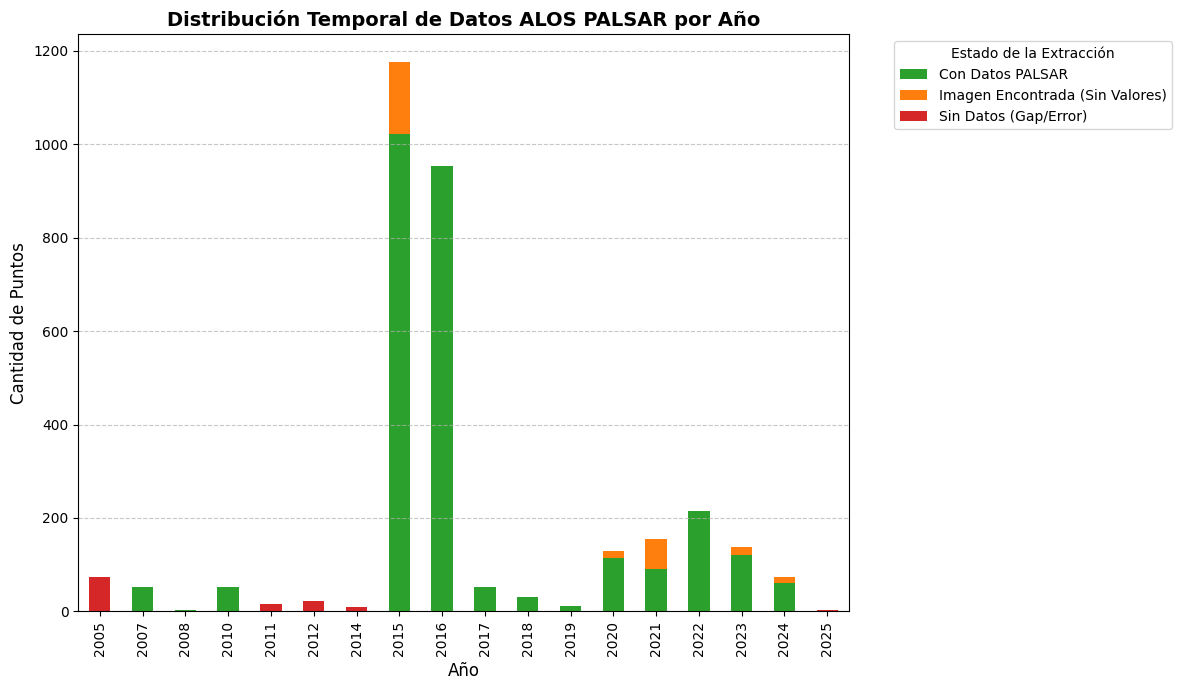

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the PALSAR data
df_palsar = pd.read_csv('/content/drive/MyDrive/TESIS-BOYACA/Imágenes/Extracion_Consolidada_FinalBoyaca.csv')

# Convert PALSAR_year to integer for better plotting
df_palsar['PALSAR_year'] = df_palsar['PALSAR_year'].fillna(0).astype(int)

# Group by year and PALSAR_ok status
# PALSAR_ok = 1 means success, 0 means no data found
# Let's also check where HH_mean_24d_25m is null vs not null within PALSAR_ok == 1
df_palsar['Status'] = 'Sin Datos (Gap/Error)'
df_palsar.loc[(df_palsar['PALSAR_ok'] == 1) & (df_palsar['HH_mean_24d_25m'].notnull()), 'Status'] = 'Con Datos PALSAR'
df_palsar.loc[(df_palsar['PALSAR_ok'] == 1) & (df_palsar['HH_mean_24d_25m'].isnull()), 'Status'] = 'Imagen Encontrada (Sin Valores)'

summary = df_palsar.groupby(['PALSAR_year', 'Status']).size().unstack(fill_value=0)

# Reorder status if they exist
cols = [c for c in ['Con Datos PALSAR', 'Imagen Encontrada (Sin Valores)', 'Sin Datos (Gap/Error)'] if c in summary.columns]
summary = summary[cols]

# Plotting
plt.figure(figsize=(12, 7))
summary.plot(kind='bar', stacked=True, color=['#2ca02c', '#ff7f0e', '#d62728'], ax=plt.gca())

plt.title('Distribución Temporal de Datos ALOS PALSAR por Año', fontsize=14, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Cantidad de Puntos', fontsize=12)
plt.legend(title='Estado de la Extracción', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig('distribucion_temporal_palsar.png')



Encontrados: 3046, Con datos: 2778, Sin info: 394


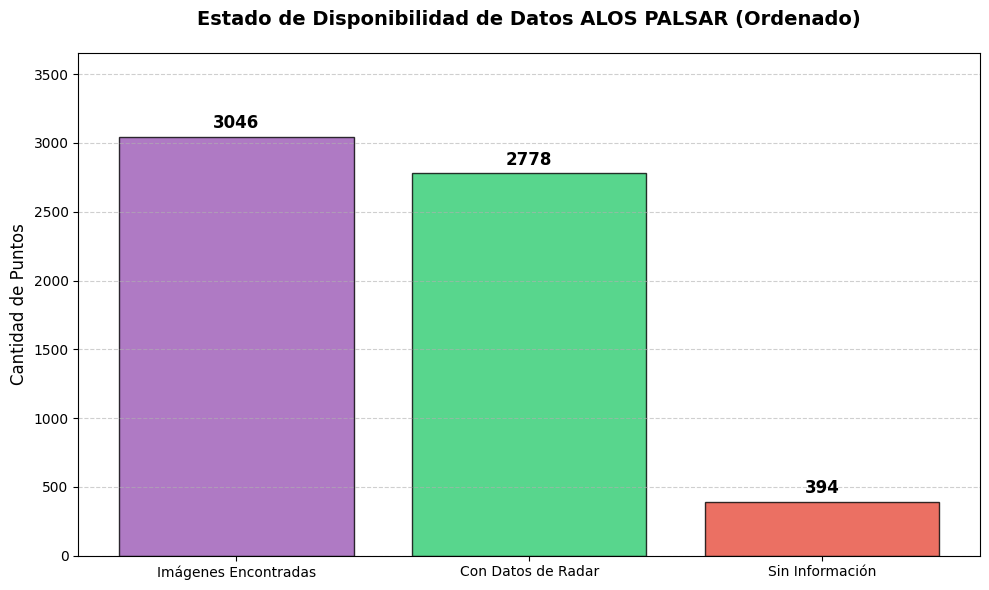

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar el archivo procesado
df_palsar = pd.read_csv('/content/drive/MyDrive/TESIS-BOYACA/Imágenes/Extracion_Consolidada_FinalBoyaca.csv')

# Cálculos dinámicos
total = len(df_palsar)
con_datos = df_palsar['HH_mean_24d_25m'].notnull().sum()
sin_info = total - con_datos
encontrados = int(df_palsar['PALSAR_ok'].sum())

# Reordenar: Sin Información al final
categorias = ['Imágenes Encontradas', 'Con Datos de Radar', 'Sin Información']
valores = [encontrados, con_datos, sin_info]
colores = ['#9b59b6', '#2ecc71', '#e74c3c']

# Creación del gráfico
plt.figure(figsize=(10, 6))
barras = plt.bar(categorias, valores, color=colores, edgecolor='black', alpha=0.8)

# Etiquetas de valores
for bar in barras:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 30, int(yval),
             ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.title('Estado de Disponibilidad de Datos ALOS PALSAR (Ordenado)', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Cantidad de Puntos', fontsize=12)
plt.ylim(0, max(valores) * 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('resumen_palsar_final_ordenado.png')

print(f"Encontrados: {encontrados}, Con datos: {con_datos}, Sin info: {sin_info}")

### **GENERACIÓN DE DATASET CON VARIABLES DERIVADAS DE IMAGENES**

In [ ]:
!pip install fiona
import os, numpy as np, pandas as pd, geopandas as gpd, fiona

from google.colab import drive
drive.mount('/content/drive')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 60.5 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
Datasetfinal = gpd.read_file('/content/drive/MyDrive/TESIS-BOYACA/Dataset_Boyaca/Final170626.gpkg', layer="DatasetFinal", driver="GPKG")
df_img = pd.read_csv('/content/drive/MyDrive/TESIS-BOYACA/Imágenes/Extracion_Consolidada_FinalBoyaca.csv')

Datasetfinal.head(2)

,Codigo,Fecha_E,P0_evento,P1_excl,P3_excl,P5_excl,P7_excl,P9_excl,P15_excl,P30_excl,...,Dist_Falla,CurvaturaN,CurvaturaT,TWI,Eastness,Northness,Pendiente,Acum_flujo,clase,geometry
0,56489,2018-09-20,0.013432,12.106000,42.394432,53.755547,67.529228,69.828926,99.491898,174.872894,...,1332.553955,0.002591,10.603379,4.200564,-0.983870,0.178885,10.555381,0.0,1,POINT (-73.05889 5.23861)
1,40217,2020-05-20,6.301852,6.287007,35.576134,70.935394,74.441734,108.377655,290.009827,548.185486,...,807.217468,-0.004084,20.869690,3.505004,-0.433816,0.901002,20.535101,0.0,1,POINT (-73.24508 4.87786)


In [ ]:
df_img.head(2)

,Codigo,Fecha_E,system:index,EVI_mean_90d_30m,EVI_std_90d_30m,HH_mean_24d_25m,HH_std_24d_25m,HHdivHV_24d_25m,HHminusHV_24d_25m,HV_mean_24d_25m,...,VVdivVH_24d_30m,VVminusVH_24d_30m,conf_BUFFER_M,conf_OPT_DAYS,conf_SAR_DAYS,date_str,.geo,HH_HV_db_stdDev,PALSAR_ok,PALSAR_year
0,56489,2018-09-20,0,0.592864,0.033494,-7.48032,1.802572,7.556639,7.556639,-15.036959,...,NaN,NaN,60,90,24,2018-09-20,"{""type"":""Point"",""coordinates"":[-73.05888888993...",2.166951,1,2018
1,40217,2020-05-20,1,0.378672,0.047929,-6.07292,1.366248,5.222959,5.222959,-11.295878,...,5.186312,7.148677,60,90,24,2020-05-20,"{""type"":""Point"",""coordinates"":[-73.24507712975...",1.363681,1,2020


In [ ]:
print("CSV filas:", len(df_img))
print("GPKG filas:", len(Datasetfinal))
print("CSV cols:", df_img.columns.tolist())
print("GPKG cols:", Datasetfinal.columns.tolist())


CSV filas: 3172
GPKG filas: 3172
CSV cols: ['Codigo', 'Fecha_E', 'system:index', 'EVI_mean_90d_30m', 'EVI_std_90d_30m', 'HH_mean_24d_25m', 'HH_std_24d_25m', 'HHdivHV_24d_25m', 'HHminusHV_24d_25m', 'HV_mean_24d_25m', 'HV_std_24d_25m', 'NBR_mean_90d_30m', 'NBR_std_90d_30m', 'NDVI_mean_90d_30m', 'NDVI_std_90d_30m', 'NDWI_mean_90d_30m', 'NDWI_std_90d_30m', 'OPT_src', 'OPT_valid_frac', 'SAR_sensor', 'SAR_src', 'SAR_valid_frac', 'VH_mean_24d_30m', 'VH_std_24d_30m', 'VV_mean_24d_30m', 'VV_std_24d_30m', 'VVdivVH_24d_30m', 'VVminusVH_24d_30m', 'conf_BUFFER_M', 'conf_OPT_DAYS', 'conf_SAR_DAYS', 'date_str', '.geo', 'HH_HV_db_stdDev', 'PALSAR_ok', 'PALSAR_year']
GPKG cols: ['Codigo', 'Fecha_E', 'P0_evento', 'P1_excl', 'P3_excl', 'P5_excl', 'P7_excl', 'P9_excl', 'P15_excl', 'P30_excl', 'P180_excl', 'Latitud', 'Longitud', 'Geologia_U', 'Paisaje', 'Elevacion', 'Dist_vias', 'Dist_DD', 'Dist_Falla', 'CurvaturaN', 'CurvaturaT', 'TWI', 'Eastness', 'Northness', 'Pendiente', 'Acum_flujo', 'clase', 'geometr

In [ ]:
# Normalizar fechas a YYYY-MM-DD (soporta 'YYYY-MM-DD HH:MM:SS' y '5/10/2005')
dt1 = pd.to_datetime(Datasetfinal["Fecha_E"], errors="coerce", infer_datetime_format=True)
mask_na = dt1.isna()
dt2 = pd.to_datetime(Datasetfinal.loc[mask_na, "Fecha_E"], errors="coerce", dayfirst=True, infer_datetime_format=True)
dt1.loc[mask_na] = dt2

bad_dates = dt1.isna().sum()
if bad_dates > 0:
    print(f"⚠️ Fechas no interpretables: {bad_dates}")
    print("Ejemplos:", Datasetfinal.loc[dt1.isna(), "Fecha_E"].head(10).tolist())

Datasetfinal["Fecha_E"] = dt1.dt.strftime("%Y-%m-%d")
Datasetfinal = Datasetfinal.dropna(subset=["Fecha_E"]).copy()

# Listado de fechas adecuadas.
print("Filas finales (fecha válida):", len(Datasetfinal))
display(Datasetfinal.head(3))

#Guardar csv con solución del formato de fecha
Datasetfinal.to_file('/content/drive/MyDrive/TESIS-BOYACA/Dataset_Boyaca/Final18062026.gpkg', layer="DatasetFinal", driver="GPKG")
print("\nGuardado:", '/content/drive/MyDrive/TESIS-BOYACA/Dataset_Boyaca/Final18062026.gpkg')

Filas finales (fecha válida): 3172


,Codigo,Fecha_E,P0_evento,P1_excl,P3_excl,P5_excl,P7_excl,P9_excl,P15_excl,P30_excl,...,Dist_Falla,CurvaturaN,CurvaturaT,TWI,Eastness,Northness,Pendiente,Acum_flujo,clase,geometry
0,56489,2018-09-20,0.013432,12.106000,42.394432,53.755547,67.529228,69.828926,99.491898,174.872894,...,1332.553955,0.002591,10.603379,4.200564,-0.983870,0.178885,10.555381,0.00000,1,POINT (-73.05889 5.23861)
1,40217,2020-05-20,6.301852,6.287007,35.576134,70.935394,74.441734,108.377655,290.009827,548.185486,...,807.217468,-0.004084,20.869690,3.505004,-0.433816,0.901002,20.535101,0.00000,1,POINT (-73.24508 4.87786)
2,40342,2020-06-01,1.510925,50.365150,97.658173,126.839279,195.761871,222.064087,326.803528,561.635864,...,1632.176514,-0.000701,27.247314,4.586474,0.221267,-0.975213,26.950413,0.60206,1,POINT (-73.067 5.152)



Guardado: /content/drive/MyDrive/TESIS-BOYACA/Dataset_Boyaca/Final18062026.gpkg


In [ ]:
def normalize_codigo(series):
    # Convertimos a numérico, redondeamos y pasamos a Int64 para quitar el .0
    temp = pd.to_numeric(series, errors="coerce").round(0).astype("Int64")
    # Limpiamos nulos y espacios en blanco
    return temp.astype(str).replace('<NA>', np.nan).str.strip()

# Aplicamos a los Códigos
df_img["Codigo"] = normalize_codigo(df_img["Codigo"])
Datasetfinal["Codigo"] = normalize_codigo(Datasetfinal["Codigo"])

In [ ]:
# 1. Asegurar que NO existan espacios ocultos en las llaves de ambos archivos
Datasetfinal["Codigo"] = Datasetfinal["Codigo"].astype(str).str.strip()
df_img["Codigo"] = df_img["Codigo"].astype(str).str.strip()

Datasetfinal["Fecha_E"] = Datasetfinal["Fecha_E"].astype(str).str.strip()
df_img["Fecha_E"] = df_img["Fecha_E"].astype(str).str.strip()

In [ ]:
# =======================================
# Selección de variables predictoras
# =======================================
opt_vars = [
    "EVI_mean_90d_30m","EVI_std_90d_30m",
    "NDVI_mean_90d_30m","NDVI_std_90d_30m",
    "NDWI_mean_90d_30m","NDWI_std_90d_30m",
    "NBR_mean_90d_30m","NBR_std_90d_30m",
]

s1_vars = [
    "VV_mean_24d_30m","VV_std_24d_30m",
    "VH_mean_24d_30m","VH_std_24d_30m",
    "VVdivVH_24d_30m","VVminusVH_24d_30m",
]

palsar_vars = [
    "HH_mean_24d_25m","HH_std_24d_25m",
    "HV_mean_24d_25m","HV_std_24d_25m",
    "HHdivHV_24d_25m","HHminusHV_24d_25m",
    "HH_HV_db_stdDev",
]

key_cols = ["Codigo", "Fecha_E"]

vars_keep = key_cols + opt_vars + s1_vars + palsar_vars
vars_keep_existing = [c for c in vars_keep if c in df_img.columns]

df_img1 = df_img[vars_keep_existing].copy()

# ============================================================
# Control de duplicados por (Codigo + Fecha_E)
# ============================================================
df_img1 = df_img1.drop_duplicates(subset=["Codigo","Fecha_E"], keep="first")

# ============================================================
# Se aplica Merge por Codigo + Fecha_E
# ============================================================
gdf_join = Datasetfinal.merge(
    df_img1,
    on=["Codigo","Fecha_E"],
    how="left",
    validate="1:1"
)

# ============================================================
# Auditoría rápida
# ============================================================
new_cols = [c for c in df_img1.columns if c not in ["Codigo","Fecha_E"]]

n_total = len(gdf_join)
n_any = gdf_join[new_cols].notna().any(axis=1).sum()

print(f"Total registros: {n_total}")
print(f"Registros con variables satelitales: {n_any} ({n_any/n_total:.2%})")

# ============================================================
# Guardar GPKG final
# ============================================================
out_gpkg  = "/content/drive/MyDrive/TESIS-BOYACA/Dataset_Boyaca/Finalvars18062026.gpkg"
out_layer= "DatasetFinalVar"
gdf_join.to_file(out_gpkg, layer=out_layer, driver="GPKG")
print("Guardado en:", out_gpkg)



Total registros: 3172
Registros con variables satelitales: 3134 (98.80%)
Guardado en: /content/drive/MyDrive/TESIS-BOYACA/Dataset_Boyaca/Finalvars18062026.gpkg


In [ ]:
Datasetfinal2 = gpd.read_file('/content/drive/MyDrive/TESIS-BOYACA/Dataset_Boyaca/Finalvars18062026.gpkg')


In [ ]:
Datasetfinal2.head(2)

,Codigo,Fecha_E,P0_evento,P1_excl,P3_excl,P5_excl,P7_excl,P9_excl,P15_excl,P30_excl,...,VVdivVH_24d_30m,VVminusVH_24d_30m,HH_mean_24d_25m,HH_std_24d_25m,HV_mean_24d_25m,HV_std_24d_25m,HHdivHV_24d_25m,HHminusHV_24d_25m,HH_HV_db_stdDev,geometry
0,56489,2018-09-20,0.013432,12.106000,42.394432,53.755547,67.529228,69.828926,99.491898,174.872894,...,NaN,NaN,-7.48032,1.802572,-15.036959,2.415872,7.556639,7.556639,2.166951,POINT (-73.05889 5.23861)
1,40217,2020-05-20,6.301852,6.287007,35.576134,70.935394,74.441734,108.377655,290.009827,548.185486,...,5.186312,7.148677,-6.07292,1.366248,-11.295878,1.462011,5.222959,5.222959,1.363681,POINT (-73.24508 4.87786)


In [ ]:
Datasetfinal2.columns

Index(['Codigo', 'Fecha_E', 'P0_evento', 'P1_excl', 'P3_excl', 'P5_excl',
       'P7_excl', 'P9_excl', 'P15_excl', 'P30_excl', 'P180_excl', 'Latitud',
       'Longitud', 'Geologia_U', 'Paisaje', 'Elevacion', 'Dist_vias',
       'Dist_DD', 'Dist_Falla', 'CurvaturaN', 'CurvaturaT', 'TWI', 'Eastness',
       'Northness', 'Pendiente', 'Acum_flujo', 'clase', 'EVI_mean_90d_30m',
       'EVI_std_90d_30m', 'NDVI_mean_90d_30m', 'NDVI_std_90d_30m',
       'NDWI_mean_90d_30m', 'NDWI_std_90d_30m', 'NBR_mean_90d_30m',
       'NBR_std_90d_30m', 'VV_mean_24d_30m', 'VV_std_24d_30m',
       'VH_mean_24d_30m', 'VH_std_24d_30m', 'VVdivVH_24d_30m',
       'VVminusVH_24d_30m', 'HH_mean_24d_25m', 'HH_std_24d_25m',
       'HV_mean_24d_25m', 'HV_std_24d_25m', 'HHdivHV_24d_25m',
       'HHminusHV_24d_25m', 'HH_HV_db_stdDev', 'geometry'],
      dtype='object')

In [ ]:
Datasetfinal2.shape

(3172, 49)

## **Asignación de valores de Humedad y Temperatura Trimestral**

### **Humedad del suelo**

In [ ]:
# ============================
# INSTALACIÓN DE LIBRERÍAS
# ============================

!pip install -q geopandas rasterio shapely fiona pyproj
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# =============================
# 1. IMPORTACIÓN DE LIBRERÍAS
# =============================
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio

# =================================
# 2. RUTAS Y PARÁMETROS GENERALES
# =================================

# Ruta del archivo de eventos

RUTA_EVENTOS = "/content/drive/MyDrive/TESIS-BOYACA/Dataset_Boyaca/Finalvars18062026.gpkg"

# Ruta HUMEDAD TRIMESTAL FINAL
ruta_humfinal = "/content/drive/MyDrive/TESIS-BOYACA/Humedad/hum_trimestral_final.csv"

# Ruta donde están los rásteres trimestrales de humedad
OUT_RASTERS_DIR = "/content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/HumedadTrimestral"


# CRS de trabajo
CRS_TRABAJO = 9377

# Nombre de la columna de fecha y opcionalmente del código del evento
COL_FECHA_EVT = "Fecha_E"
COL_ID_EVT    = "Codigo"

# Nombre de la columna donde se guardará el valor de humedad en el punto del evento
COL_HUM_EVT = "Humedad_trim_evt"




Mounted at /content/drive


In [ ]:
hum_trimestral_fina = pd.read_csv(ruta_humfinal)
gdf_evt = gpd.read_file(RUTA_EVENTOS)

In [ ]:
gdf_evt = gdf_evt.to_crs(CRS_TRABAJO)
print("Eventos reproyectados a CRS:", CRS_TRABAJO)

Eventos reproyectados a CRS: 9377


In [ ]:
gdf_evt.head(2)

,Codigo,Fecha_E,P0_evento,P1_excl,P3_excl,P5_excl,P7_excl,P9_excl,P15_excl,P30_excl,...,VVdivVH_24d_30m,VVminusVH_24d_30m,HH_mean_24d_25m,HH_std_24d_25m,HV_mean_24d_25m,HV_std_24d_25m,HHdivHV_24d_25m,HHminusHV_24d_25m,HH_HV_db_stdDev,geometry
0,56489,2018-09-20,0.013432,12.106000,42.394432,53.755547,67.529228,69.828926,99.491898,174.872894,...,NaN,NaN,-7.48032,1.802572,-15.036959,2.415872,7.556639,7.556639,2.166951,POINT (4993476.94 2136858.232)
1,40217,2020-05-20,6.301852,6.287007,35.576134,70.935394,74.441734,108.377655,290.009827,548.185486,...,5.186312,7.148677,-6.07292,1.366248,-11.295878,1.462011,5.222959,5.222959,1.363681,POINT (4972837.954 2097002.211)


In [ ]:
# ===============================
# 3. AÑO Y TRIMESTRE DEL EVENTO
# ===============================
# Asegurar que la fecha está en formato datetime
gdf_evt[COL_FECHA_EVT] = pd.to_datetime(gdf_evt[COL_FECHA_EVT], errors='coerce')

# Año y trimestre
gdf_evt['Year'] = gdf_evt[COL_FECHA_EVT].dt.year
gdf_evt['Trimestre'] = gdf_evt[COL_FECHA_EVT].dt.quarter

# Inicializar columna de humedad en eventos
gdf_evt[COL_HUM_EVT] = np.nan

In [ ]:
gdf_evt.head(2)

,Codigo,Fecha_E,P0_evento,P1_excl,P3_excl,P5_excl,P7_excl,P9_excl,P15_excl,P30_excl,...,HH_std_24d_25m,HV_mean_24d_25m,HV_std_24d_25m,HHdivHV_24d_25m,HHminusHV_24d_25m,HH_HV_db_stdDev,geometry,Year,Trimestre,Humedad_trim_evt
0,56489,2018-09-20,0.013432,12.106000,42.394432,53.755547,67.529228,69.828926,99.491898,174.872894,...,1.802572,-15.036959,2.415872,7.556639,7.556639,2.166951,POINT (4993476.94 2136858.232),2018,3,NaN
1,40217,2020-05-20,6.301852,6.287007,35.576134,70.935394,74.441734,108.377655,290.009827,548.185486,...,1.366248,-11.295878,1.462011,5.222959,5.222959,1.363681,POINT (4972837.954 2097002.211),2020,2,NaN


In [ ]:
# ============================================================
# 4. LISTA DE COMBINACIONES AÑO–TRIMESTRE PRESENTES EN LOS EVENTOS
# ============================================================
trims_evt = (
    gdf_evt[['Year', 'Trimestre']]
    .dropna()
    .drop_duplicates()
    .sort_values(['Year', 'Trimestre'])
    .to_records(index=False)
)

print("Combinaciones Año–Trimestre con eventos:", len(trims_evt))
print(trims_evt)

Combinaciones Año–Trimestre con eventos: 51
[(2005, 4) (2007, 1) (2007, 3) (2008, 2) (2008, 3) (2010, 1) (2011, 2)
 (2011, 3) (2012, 2) (2012, 3) (2012, 4) (2014, 2) (2014, 4) (2015, 1)
 (2015, 3) (2015, 4) (2016, 1) (2016, 2) (2016, 3) (2016, 4) (2017, 2)
 (2017, 3) (2017, 4) (2018, 1) (2018, 2) (2018, 3) (2018, 4) (2019, 1)
 (2019, 2) (2019, 3) (2019, 4) (2020, 1) (2020, 2) (2020, 3) (2020, 4)
 (2021, 1) (2021, 2) (2021, 3) (2021, 4) (2022, 1) (2022, 2) (2022, 3)
 (2022, 4) (2023, 1) (2023, 2) (2023, 3) (2023, 4) (2024, 2) (2024, 3)
 (2024, 4) (2025, 1)]


In [ ]:
# ============================================================
# 5. ASIGNAR HUMEDAD TRIMESTRAL A CADA EVENTO
# ============================================================
for year, trim in trims_evt:
    print(f"\n=== Asignando humedad a eventos de {year}-T{int(trim)} ===")

    # Subconjunto de eventos en ese trimestre
    mask = (gdf_evt['Year'] == year) & (gdf_evt['Trimestre'] == trim)
    sub_evt = gdf_evt[mask]

    if sub_evt.empty:
        print("  -> No hay eventos en este trimestre.")
        continue

    # Nombre y ruta del ráster trimestral correspondiente
    tif_name = f"humedad_{int(year)}_T{int(trim)}.tif"
    tif_path = os.path.join(OUT_RASTERS_DIR, tif_name)

    if not os.path.exists(tif_path):
        print(f"  -> No existe el ráster {tif_path}. Se dejan NaN para estos eventos.")
        continue

    print("  -> Usando ráster:", tif_path)

    # Abrir ráster y muestrear
    with rasterio.open(tif_path) as src:
        # Coordenadas X,Y de los eventos de cada trimestre
        xs = sub_evt.geometry.x.to_numpy()
        ys = sub_evt.geometry.y.to_numpy()

        coords = list(zip(xs, ys))

        # Extraer valores del pixel de las coordenadas de cada evento de acuerdo al trimestre en que suceden
        vals = list(src.sample(coords))
        vals = np.array([v[0] for v in vals], dtype="float32")

        # Manejo de nodata, si el evento cae fuera de la máscara o en una celda sin datos, el valor se convierte a NaN

        if src.nodata is not None:
             vals[vals == src.nodata] = np.nan

        # Asignar al GeoDataFrame original
        # Cada evento queda con un atributo:Humedad del suelo correspondiente al trimestre y ubicación del deslizamiento
        gdf_evt.loc[mask, COL_HUM_EVT] = vals

print("\nAsignación de humedad trimestral a eventos completada.")


=== Asignando humedad a eventos de 2005-T4 ===
  -> Usando ráster: /content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/HumedadTrimestral/humedad_2005_T4.tif

=== Asignando humedad a eventos de 2007-T1 ===
  -> Usando ráster: /content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/HumedadTrimestral/humedad_2007_T1.tif

=== Asignando humedad a eventos de 2007-T3 ===
  -> Usando ráster: /content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/HumedadTrimestral/humedad_2007_T3.tif

=== Asignando humedad a eventos de 2008-T2 ===
  -> Usando ráster: /content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/HumedadTrimestral/humedad_2008_T2.tif

=== Asignando humedad a eventos de 2008-T3 ===
  -> Usando ráster: /content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/HumedadTrimestral/humedad_2008_T3.tif

=== Asignando humedad a eventos de 2010-T1 ===
  -> Usando ráster: /content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/HumedadTrimestral/humedad_2010_T1.tif

=== Asignando humedad a eventos de 2011-T2 ===
  ->

In [ ]:
nan_total = gdf_evt[ gdf_evt['Humedad_trim_evt'].isna() ]
print("Total de eventos con NaN:", len(nan_total))

Total de eventos con NaN: 6


In [ ]:
gdf_evt.head(2)

,Codigo,Fecha_E,P0_evento,P1_excl,P3_excl,P5_excl,P7_excl,P9_excl,P15_excl,P30_excl,...,HH_std_24d_25m,HV_mean_24d_25m,HV_std_24d_25m,HHdivHV_24d_25m,HHminusHV_24d_25m,HH_HV_db_stdDev,geometry,Year,Trimestre,Humedad_trim_evt
0,56489,2018-09-20,0.013432,12.106000,42.394432,53.755547,67.529228,69.828926,99.491898,174.872894,...,1.802572,-15.036959,2.415872,7.556639,7.556639,2.166951,POINT (4993476.94 2136858.232),2018,3,55.154251
1,40217,2020-05-20,6.301852,6.287007,35.576134,70.935394,74.441734,108.377655,290.009827,548.185486,...,1.366248,-11.295878,1.462011,5.222959,5.222959,1.363681,POINT (4972837.954 2097002.211),2020,2,48.514545


In [ ]:
# 1. Subconjunto de eventos con NaN en humedad
nan_total = gdf_evt[gdf_evt['Humedad_trim_evt'].isna()]
print("Total de eventos con NaN:", len(nan_total))

# 2. Conteo por año y trimestre
nan_por_trim = (
    nan_total
    .groupby(['Year', 'Trimestre'])
    .size()
    .reset_index(name='N_eventos_NaN')
    .sort_values(['Year', 'Trimestre'])
)

print("\nNaN por año y trimestre:")
print(nan_por_trim)

# 3. Ver filas específicas (opcional)
nan_total[[COL_ID_EVT, COL_FECHA_EVT, 'Year', 'Trimestre', COL_HUM_EVT]].head(6)


Total de eventos con NaN: 6

NaN por año y trimestre:
   Year  Trimestre  N_eventos_NaN
0  2015          4              5
1  2016          1              1


,Codigo,Fecha_E,Year,Trimestre,Humedad_trim_evt
609,65933,2015-12-26,2015,4,NaN
630,65085,2015-12-26,2015,4,NaN
631,65086,2015-12-26,2015,4,NaN
635,65087,2015-12-26,2015,4,NaN
641,65088,2015-12-26,2015,4,NaN
652,64667,2016-01-20,2016,1,NaN


In [ ]:
est_problem = (
    nan_total
    .groupby('Codigo')
    .size()

)

print(est_problem)

Codigo
64667    1
65085    1
65086    1
65087    1
65088    1
65933    1
dtype: int64


**Dado a la inexistencia de información en al menos 6 estaciones, no fue posible generar todas las interpolaciones, por tal motivo, 6 eventos de deslizamientos, no tienen dato de humedad de suelo asociada, distinguiendo como trimestres problemáticos el último trimestre del año 2015 y el primer trimestre del año 2016; en total son 2 trimestres con problemas.**

**Por tal razón, para estas situaciones problemáticas, se planteó calcular la  climatología trimestral de la humedad del suelo. Para ello, se recopilaron todas las observaciones históricas disponibles de humedad del suelo correspondientes a un mismo trimestre del año, independientemente del año de registro. Posteriormente, para cada estación, se calculó el promedio aritmético de la humedad del suelo considerando exclusivamente los registros válidos de dicho trimestre a lo largo de toda la serie temporal.**

**A partir de estos valores promedio trimestrales por estación, se generaron superficies espaciales continuas mediante interpolación geoestadística utilizando el método de kriging ordinario. De este modo, se construyó un ráster climatológico para cada trimestre del año, el cual representa el patrón espacial típico de la humedad del suelo bajo condiciones medias multianuales. Estas superficies climatológicas fueron empleadas únicamente en los casos en que no fue posible generar interpolaciones trimestrales específicas para un año determinado.**

In [ ]:
# 1) Trimestres únicos que requieren climatología (solo 1..4)
trimestres_clim_necesarios = sorted(nan_por_trim['Trimestre'].unique().astype(int).tolist())
print("\nTrimestres que requieren climatología:", trimestres_clim_necesarios)


Trimestres que requieren climatología: [1, 4]


In [ ]:
# ------------------------------------------------------------
# 1. IMPORTACIÓN DE LIBRERÍAS
# ------------------------------------------------------------
!pip install pykrige
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.transform import from_origin
from shapely.geometry import Point
from shapely.ops import unary_union
from pykrige.ok import OrdinaryKriging
from scipy.spatial import cKDTree

# ------------------------------------------------------------
# 2. PARÁMETROS GENERALES (AJUSTABLES)
# ------------------------------------------------------------
CRS_TRABAJO = 9377                 # MAGNA-SIRGAS / Colombia Bogota
CELL = 500                         # Tamaño de píxel (m)
VARIO = "spherical"                # Modelo de variograma
RANGE_ESCALA = 1.45                # Factor de ajuste del rango
NUGGET_FRACCION_DEL_SILL = 1e-5    # Nugget como fracción del sill
UMBRAL_ESTACIONES = 6
TRIMESTRES = trimestres_clim_necesarios         # Trimestres climatológicos

In [ ]:
RUTA_SHAPEHUM = '/content/drive/MyDrive/TESIS-BOYACA/Humedad/Humedad_Boyaca.shp'
RUTA_MASCARA    = '/content/drive/MyDrive/TESIS-BOYACA/Depto/Boyaca.shp'
RUTA_HUM_TR      = '/content/drive/MyDrive/TESIS-BOYACA/Humedad/hum_trimestral_final.csv'
OUT_RASTERS_CLIM_HUM = "/content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/ClimHumTrimestral"
OUT_RASTERS_HUM = "/content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/HumedadTrimestral"
os.makedirs(OUT_RASTERS_CLIM_HUM, exist_ok=True)

In [ ]:
# ------------------------------------------------------------
# 3. CARGA DE DATOS
# ------------------------------------------------------------
#  Estaciones
gdf_est = gpd.read_file(RUTA_SHAPEHUM).to_crs(CRS_TRABAJO)

# Asegurar identificador de estación
if "EstacionID" not in gdf_est.columns and "CODIGO" in gdf_est.columns:
    gdf_est = gdf_est.rename(columns={"Codigo": "EstacionID"})

# 4.2 Datos de humedad trimestral por estación
df_hum = pd.read_csv(RUTA_HUM_TR)


In [ ]:
# ------------------------------------------------------------
# 4. CÁLCULO DE CLIMATOLOGÍA TRIMESTRAL POR ESTACIÓN
# ------------------------------------------------------------
clim_hum = (
    df_hum
    .dropna(subset=["Humedad_trimestral"])
    .groupby(["EstacionID", "Trimestre"], observed=True)
    ["Humedad_trimestral"]
    .mean()
    .reset_index()
    .rename(columns={"Humedad_trimestral": "Humedad_clim"})
)

# Asegurar que gdf_est tenga la columna 'EstacionID' (se asume que 'CODIGO' es la original)
if "EstacionID" not in gdf_est.columns and "CODIGO" in gdf_est.columns:
    gdf_est = gdf_est.rename(columns={"CODIGO": "EstacionID"})

# Convertir 'EstacionID' a string en ambos DataFrames para asegurar compatibilidad de tipos
clim_hum['EstacionID'] = clim_hum['EstacionID'].astype(str)
gdf_est['EstacionID'] = gdf_est['EstacionID'].astype(str)

# Unir climatología con geometría
gdf_clim = clim_hum.merge(
    gdf_est[["EstacionID", "geometry"]],
    on="EstacionID",
    how="inner"
)
gdf_clim = gpd.GeoDataFrame(gdf_clim, geometry="geometry", crs=CRS_TRABAJO)

In [ ]:
gdf_clim.head(3)

,EstacionID,Trimestre,Humedad_clim,geometry
0,16015130,1,52.042952,POINT (5056756.889 2387516.66)
1,16015130,2,49.989079,POINT (5056756.889 2387516.66)
2,16015130,3,54.161250,POINT (5056756.889 2387516.66)


In [ ]:
# =====================
# 5) Máscara y rejilla
# =====================
gdf_mask = gpd.read_file(RUTA_MASCARA).to_crs(CRS_TRABAJO)
mask_poly = unary_union(gdf_mask.geometry)

minx, miny, maxx, maxy = gdf_mask.total_bounds #Límites del dpt.
nx = int(np.floor((maxx - minx)/CELL))
ny = int(np.floor((maxy - miny)/CELL)) #  Permite crear una especie de malla a través de puntos que se ajusta al territorio de acuerdo al
                                       #  tamaño de celda específicado para el procesamiento

xs = minx + CELL/2.0 + CELL*np.arange(nx)       # Crea las coordenadas de la malla
ys = maxy - CELL/2.0 - CELL*np.arange(ny)

grid_points, grid_idx = [], []             # Selecciona solo los puntos que caigan dentro del Cauca

for iy, yy in enumerate(ys):
    for ix, xx in enumerate(xs):
        p = Point(xx, yy)
        if mask_poly.contains(p):
            grid_points.append(p)
            grid_idx.append((iy, ix))

pred_x = np.array([p.x for p in grid_points], dtype="float64")      # Extrae las coordenadas X e Y para usarlas en el kriging
pred_y = np.array([p.y for p in grid_points], dtype="float64")

In [ ]:
# ============================================================
# 6) Funciones auxiliares de intgerpolación
# ============================================================
def dedup_trim_gdf(gdf, col_val, decimals=0):
    """Agrupa puntos casi coincidentes para evitar problemas numéricos."""
    tmp = gdf.copy()
    tmp["x"] = tmp.geometry.x
    tmp["y"] = tmp.geometry.y
    tmp["xr"] = tmp["x"].round(decimals)
    tmp["yr"] = tmp["y"].round(decimals)
    g = tmp.groupby(["xr", "yr"], as_index=False)[col_val].mean()
    x = g["xr"].to_numpy(float)
    y = g["yr"].to_numpy(float)
    z = g[col_val].to_numpy(float)
    return x, y, z

def suggest_range_xy(x, y):
    """Rango sugerido para el variograma a partir del 3er vecino más cercano."""
    xy = np.c_[x, y]
    if xy.shape[0] < 4:
        return 20000.0
    D = np.sqrt(((xy[None,:,:]-xy[:,None,:])**2).sum(axis=2))
    D.sort(axis=1)
    d3 = np.median(D[:,3]) if D.shape[1] > 3 else np.median(D[:,-1])
    return float(3.0 * d3)

def idw_predict(x, y, z, px, py, k=12, p=2.0):
    """IDW como respaldo en dado caso que kriging no funcione."""
    tree = cKDTree(np.c_[x,y])
    dists, idxs = tree.query(np.c_[px,py], k=min(k, len(x)))
    dists = np.atleast_2d(dists); idxs = np.atleast_2d(idxs)
    w = 1.0 / np.maximum(dists, 1e-6)**p
    num = (w * z[idxs]).sum(axis=1)
    den = w.sum(axis=1)
    return (num/den).astype("float32")

def krige_predict_safe(x, y, z, px, py, variogram_model, base_range, base_nugget, sill):
    """Kriging robusto con reintentos y fallback a IDW."""
    if sill < 1e-6:
        # Muy poca variabilidad: devuelve una constante (media)
        return np.full(len(px), float(np.mean(z)), dtype="float32"), {"mode":"const"}

    nug_scales = [1, 2, 4, 8, 16]
    rng_scales = [1.0, 1.5, 2.0]

    for rs in rng_scales:
        for ns in nug_scales:
            vrng = max(base_range * rs, 1.0)
            vnug = max(base_nugget * ns, 1e-6 * max(sill, 1.0))
            vsill = max(sill, 1e-6)
            try:
                OK = OrdinaryKriging(
                    x, y, z,
                    variogram_model=variogram_model,
                    variogram_parameters={"sill": vsill, "range": vrng, "nugget": vnug},
                    enable_plotting=False
                )
                z_pred, _ = OK.execute("points", px, py)
                return np.asarray(z_pred, dtype="float32"), {
                    "mode":"ok",
                    "sill":vsill,
                    "range":vrng,
                    "nugget":vnug
                }
            except Exception:
                pass

    # Si todo falla, usar IDW
        return idw_predict(x, y, z, px, py, k=min(12, len(x))), {"mode":"idw"}


In [ ]:
# ------------------------------------------------------------
# 8. INTERPOLACIÓN CLIMATOLÓGICA POR TRIMESTRE
# ------------------------------------------------------------

log_rows = []  # para registrar cómo se interpoló cada trimestre

for trim in TRIMESTRES:
    trim = int(trim)
    print(f"\nInterpolando climatología T{trim}")

    out_tif = os.path.join(OUT_RASTERS_CLIM_HUM, f"humedad_clim_T{trim}.tif")

    # (opcional) reanudar: si ya existe el tif, no recalcular
    if os.path.exists(out_tif):
        print("  -> Ya existe, se omite (reanudar).")
        continue

    # Subconjunto de estaciones para ese trimestre climatológico
    sub = (
        gdf_clim[gdf_clim["Trimestre"] == trim]
        .dropna(subset=["Humedad_clim"])   # asegurar que no haya NaN en el valor climatológico
        .copy()
    )

    n_est = len(sub)
    print("  Estaciones con dato:", n_est)

    # Umbral mínimo de estaciones
    if n_est < UMBRAL_ESTACIONES:
        print(f"  -> Muy pocas estaciones (<{UMBRAL_ESTACIONES}), se omite trimestre.")
        log_rows.append({
            "trimestre": trim,
            "generado": False,
            "motivo": "pocas_estaciones",
            "n_estaciones": int(n_est)
        })
        continue

    # Deduplicación espacial robusta (agrupa puntos casi coincidentes y promedia)
    x, y, z = dedup_trim_gdf(sub, col_val="Humedad_clim", decimals=0)
    n_unicas = len(x)

    if n_unicas < 3:
        print("  -> Menos de 3 puntos únicos tras deduplicar, se omite.")
        log_rows.append({
            "trimestre": trim,
            "generado": False,
            "motivo": "pocos_unicos",
            "n_estaciones": int(n_est),
            "n_unicas": int(n_unicas)
        })
        continue

    # Parámetros del variograma (base)
    sill = float(np.var(z))
    rng0 = suggest_range_xy(x, y) * float(RANGE_ESCALA)
    nug0 = float(NUGGET_FRACCION_DEL_SILL) * max(sill, 1e-6)

    # Kriging seguro (reintentos + fallback a IDW si falla)
    z_pred, info = krige_predict_safe(
        x, y, z,
        pred_x, pred_y,
        variogram_model=VARIO,
        base_range=rng0,
        base_nugget=nug0,
        sill=sill
    )

    # Ensamblar al grid (NaN fuera de la máscara)
    grid = np.full((ny, nx), np.nan, dtype="float32")
    for (iy, ix), val in zip(grid_idx, z_pred):
        grid[iy, ix] = val

    # Guardar GeoTIFF
    transform = from_origin(minx, maxy, CELL, CELL)
    with rasterio.open(
        out_tif, "w", driver="GTiff",
        height=ny, width=nx, count=1,
        dtype="float32",
        crs=gdf_masc.crs if "gdf_masc" in globals() else CRS_TRABAJO,
        transform=transform,
        nodata=np.nan,
        compress="DEFLATE"
    ) as dst:
        dst.write(grid, 1)

    print("  -> Ráster generado:", out_tif)
    print("     modo:", info.get("mode"),
          "| sill:", sill,
          "| range_inicial:", rng0,
          "| nugget_inicial:", nug0)

    # Guardar log del trimestre
    log_rows.append({
        "trimestre": trim,
        "generado": True,
        "n_estaciones": int(n_est),
        "n_unicas": int(n_unicas),
        "modo": info.get("mode"),
        "sill": float(sill),
        "range_inicial": float(rng0),
        "nugget_inicial": float(nug0),
        # (opcional) si el kriging reintentó, info puede contener range/nugget finales:
        "range_usado": float(info.get("range")) if info.get("range") is not None else np.nan,
        "nugget_usado": float(info.get("nugget")) if info.get("nugget") is not None else np.nan
    })

print("\nClimatología trimestral finalizada.")

# (opcional) guardar log a CSV para anexos/metodología
if len(log_rows) > 0:
    df_log = pd.DataFrame(log_rows).sort_values(["trimestre"])
    log_path = os.path.join(OUT_RASTERS_CLIM_HUM, "_log_climatologia_por_trimestre.csv")
    df_log.to_csv(log_path, index=False)
    print("Log guardado en:", log_path)



Interpolando climatología T1
  -> Ya existe, se omite (reanudar).

Interpolando climatología T4
  -> Ya existe, se omite (reanudar).

Climatología trimestral finalizada.


In [ ]:
# Ruta donde están los rásteres trimestrales de humedad
COL_YEAR, COL_TRIM, COL_HUM = "Year", "Trimestre", "Humedad_trim_evt"
OUT_RASTERS_HUM = "/content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/HumedadTrimestral"
OUT_RASTERS_CLIM_HUM = "/content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/ClimHumTrimestral"
PREF_REAL, PREF_CLIM = "humedad", "humedad_clim"



In [ ]:

def raster_path(year, trim):
    p_real = os.path.join(OUT_RASTERS_HUM, f"{PREF_REAL}_{int(year)}_T{int(trim)}.tif")
    if os.path.exists(p_real):
        return p_real, "real"
    p_clim = os.path.join(OUT_RASTERS_CLIM_HUM, f"{PREF_CLIM}_T{int(trim)}.tif")
    if os.path.exists(p_clim):
        return p_clim, "clim"
    return None, "missing"

def sample_points(tif, gdf_sub):
    with rasterio.open(tif) as src:
        g = gdf_sub.to_crs(src.crs) if gdf_sub.crs != src.crs else gdf_sub
        coords = list(zip(g.geometry.x.to_numpy(), g.geometry.y.to_numpy()))
        vals = np.array([v[0] for v in src.sample(coords)], dtype="float32")
        if src.nodata is not None:
            vals[vals == src.nodata] = np.nan
    return vals



In [ ]:
# --- RELLENO SOLO NaN ---
mask = gdf_evt[COL_HUM].isna() & gdf_evt[COL_YEAR].notna() & gdf_evt[COL_TRIM].notna()
combos = gdf_evt.loc[mask, [COL_YEAR, COL_TRIM]].drop_duplicates().sort_values([COL_YEAR, COL_TRIM]).to_numpy()

print("Eventos NaN a rellenar:", int(mask.sum()))

for year, trim in combos:
    m = mask & (gdf_evt[COL_YEAR] == year) & (gdf_evt[COL_TRIM] == trim)
    tif, modo = raster_path(year, trim)
    if tif is None:
        print(f"{int(year)}-T{int(trim)}: sin ráster (real ni clim) -> quedan NaN | N={int(m.sum())}")
        continue

    vals = sample_points(tif, gdf_evt.loc[m])
    gdf_evt.loc[m, COL_HUM] = vals
    print(f"{int(year)}-T{int(trim)}: relleno con {modo} | N={len(vals)}")

for year, trim in combos:
    m = mask & (gdf_evt[COL_YEAR] == year) & (gdf_evt[COL_TRIM] == trim)

    tif, modo = raster_path(year, trim)

    if tif is None:
        print(f"{int(year)}-T{int(trim)}: sin ráster -> quedan NaN | N={int(m.sum())}")
        continue

    vals = sample_points(tif, gdf_evt.loc[m])

    print(
        f"{int(year)}-T{int(trim)}: {modo} | "
        f"N puntos={len(vals)} | "
        f"válidos={np.isfinite(vals).sum()} | "
        f"NaN extraídos={np.isnan(vals).sum()}"
    )

    gdf_evt.loc[m, COL_HUM] = vals

Eventos NaN a rellenar: 6
2015-T4: relleno con real | N=5
2016-T1: relleno con real | N=1
2015-T4: real | N puntos=5 | válidos=0 | NaN extraídos=5
2016-T1: real | N puntos=1 | válidos=0 | NaN extraídos=1


En este caso el problema estaba relacionado con que estos puntos estan por fuera de la superficie generada por lo tanto se considera mejor eliminar estos eventos que si ocurrieron, y  eliminar la misma cantidad para los eventos que no ocurrieron en esta fechas.




In [ ]:
# ============================================================
# ELIMINAR DESLIZAMIENTOS CLASE 1 CON HUMEDAD NaN
# Y ELIMINAR LA MISMA CANTIDAD DE CLASE 0
# POR AÑO Y TRIMESTRE
# ============================================================

SEED = 42

COL_CLASE = "clase"        # 1 = deslizamiento, 0 = no deslizamiento
COL_HUM = COL_HUM          # columna de humedad
COL_YEAR = "Year"
COL_TRIM = "Trimestre"

gdf_dep = gdf_evt.copy()

# ------------------------------------------------------------
# 1. Identificar los registros Clase 1 que tienen humedad NaN
# ------------------------------------------------------------

mask_clase1_nan = (
    (gdf_dep[COL_CLASE] == 1) &
    (gdf_dep[COL_HUM].isna()) &
    (gdf_dep[COL_YEAR].notna()) &
    (gdf_dep[COL_TRIM].notna())
)

clase1_nan = gdf_dep.loc[mask_clase1_nan].copy()

print("Registros Clase 1 con humedad NaN a eliminar:", len(clase1_nan))

print("\nResumen de Clase 1 NaN por año y trimestre:")
resumen_nan = (
    clase1_nan
    .groupby([COL_YEAR, COL_TRIM])
    .size()
    .reset_index(name="n_clase1_nan")
)

print(resumen_nan)

Registros Clase 1 con humedad NaN a eliminar: 6

Resumen de Clase 1 NaN por año y trimestre:
   Year  Trimestre  n_clase1_nan
0  2015          4             5
1  2016          1             1


In [ ]:
# ------------------------------------------------------------
# 2. Seleccionar registros Clase 0 a eliminar
#    en los mismos años y trimestres
# ------------------------------------------------------------

idx_clase0_eliminar = []

for _, row in resumen_nan.iterrows():
    year = row[COL_YEAR]
    trim = row[COL_TRIM]
    n_eliminar = int(row["n_clase1_nan"])

    candidatos_clase0 = gdf_dep[
        (gdf_dep[COL_CLASE] == 0) &
        (gdf_dep[COL_YEAR] == year) &
        (gdf_dep[COL_TRIM] == trim)
    ]

    print(
        f"{int(year)}-T{int(trim)} | "
        f"Clase 1 NaN a eliminar: {n_eliminar} | "
        f"Clase 0 disponibles: {len(candidatos_clase0)}"
    )

    if len(candidatos_clase0) < n_eliminar:
        raise ValueError(
            f"No hay suficientes registros Clase 0 en {int(year)}-T{int(trim)}. "
            f"Se necesitan {n_eliminar}, pero hay {len(candidatos_clase0)}."
        )

    muestra_clase0 = candidatos_clase0.sample(
        n=n_eliminar,
        random_state=SEED
    )

    idx_clase0_eliminar.extend(muestra_clase0.index.tolist())

2015-T4 | Clase 1 NaN a eliminar: 5 | Clase 0 disponibles: 351
2016-T1 | Clase 1 NaN a eliminar: 1 | Clase 0 disponibles: 465


In [ ]:
# ------------------------------------------------------------
# 3. Eliminar Clase 1 NaN y la misma cantidad de Clase 0
# ------------------------------------------------------------

idx_clase1_eliminar = clase1_nan.index.tolist()

idx_total_eliminar = idx_clase1_eliminar + idx_clase0_eliminar

gdf_dep_balanceado = gdf_dep.drop(index=idx_total_eliminar).copy()

print("\nTotal Clase 1 eliminados:", len(idx_clase1_eliminar))
print("Total Clase 0 eliminados:", len(idx_clase0_eliminar))
print("Total registros eliminados:", len(idx_total_eliminar))

print("\nDistribución de clases antes:")
print(gdf_dep[COL_CLASE].value_counts().sort_index())

print("\nDistribución de clases después:")
print(gdf_dep_balanceado[COL_CLASE].value_counts().sort_index())

print("\nNaN restantes en humedad:")
print(gdf_dep_balanceado[COL_HUM].isna().sum())


Total Clase 1 eliminados: 6
Total Clase 0 eliminados: 6
Total registros eliminados: 12

Distribución de clases antes:
clase
0    1586
1    1586
Name: count, dtype: int64

Distribución de clases después:
clase
0    1580
1    1580
Name: count, dtype: int64

NaN restantes en humedad:
0


In [ ]:
# Dataset final Humedad
gdf_dep_balanceado.to_file(r"/content/drive/MyDrive/TESIS-BOYACA/Dataset_Boyaca/Finalvars26062026.gpkg",
    layer="dataset_final",
    driver="GPKG"
)

### **Temperatura del suelo**

In [ ]:
ruta_tempfinal='/content/drive/MyDrive/TESIS-BOYACA/Temperatura/temp_trimestral_final.csv'
OUT_RASTERS_DIR = '/content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/TemperaturaTrimestral'
RUTA_EVENTOS = '/content/drive/MyDrive/TESIS-BOYACA/Dataset_Boyaca/Finalvars26062026.gpkg'
CRS_TRABAJO = 9377

In [ ]:
temp_trimestral_fina = pd.read_csv(ruta_tempfinal)
gdf_evtf = gpd.read_file(RUTA_EVENTOS)

In [ ]:
gdf_evtf = gdf_evtf.to_crs(CRS_TRABAJO)
print("Eventos reproyectados a CRS:", CRS_TRABAJO)

Eventos reproyectados a CRS: 9377


In [ ]:
# ===============================
# 3. AÑO Y TRIMESTRE DEL EVENTO
# ===============================
# Asegurar que la fecha está en formato datetime
gdf_evtf[COL_FECHA_EVT] = pd.to_datetime(gdf_evtf[COL_FECHA_EVT], errors='coerce')

# Año y trimestre
gdf_evtf['Year'] = gdf_evtf[COL_FECHA_EVT].dt.year
gdf_evtf['Trimestre'] = gdf_evtf[COL_FECHA_EVT].dt.quarter

# Definir la columna para la temperatura en eventos
COL_TEMP_EVT = "Temperatura_trim_evt"

# Inicializar columna de temperatura en eventos
gdf_evtf[COL_TEMP_EVT] = np.nan

In [ ]:
# ============================================================
# 4. LISTA DE COMBINACIONES AÑO–TRIMESTRE PRESENTES EN LOS EVENTOS
# ============================================================
trims_evt = (
    gdf_evtf[['Year', 'Trimestre']]
    .dropna()
    .drop_duplicates()
    .sort_values(['Year', 'Trimestre'])
    .to_records(index=False)
)

print("Combinaciones Año–Trimestre con eventos:", len(trims_evt))
print(trims_evt)

Combinaciones Año–Trimestre con eventos: 51
[(2005, 4) (2007, 1) (2007, 3) (2008, 2) (2008, 3) (2010, 1) (2011, 2)
 (2011, 3) (2012, 2) (2012, 3) (2012, 4) (2014, 2) (2014, 4) (2015, 1)
 (2015, 3) (2015, 4) (2016, 1) (2016, 2) (2016, 3) (2016, 4) (2017, 2)
 (2017, 3) (2017, 4) (2018, 1) (2018, 2) (2018, 3) (2018, 4) (2019, 1)
 (2019, 2) (2019, 3) (2019, 4) (2020, 1) (2020, 2) (2020, 3) (2020, 4)
 (2021, 1) (2021, 2) (2021, 3) (2021, 4) (2022, 1) (2022, 2) (2022, 3)
 (2022, 4) (2023, 1) (2023, 2) (2023, 3) (2023, 4) (2024, 2) (2024, 3)
 (2024, 4) (2025, 1)]


In [ ]:
# ============================================================
# 5. ASIGNAR TEMPERATURA TRIMESTRAL A CADA EVENTO
# ============================================================
for year, trim in trims_evt:
    print(f"\n=== Asignando temperatura a eventos de {year}-T{int(trim)} ===")

    # Subconjunto de eventos en ese trimestre
    mask = (gdf_evtf['Year'] == year) & (gdf_evtf['Trimestre'] == trim)
    sub_evt = gdf_evtf[mask]

    if sub_evt.empty:
        print("  -> No hay eventos en este trimestre.")
        continue

    # Nombre y ruta del ráster trimestral correspondiente
    tif_name = f"temperatura_{int(year)}_T{int(trim)}.tif"
    tif_path = os.path.join(OUT_RASTERS_DIR, tif_name)

    if not os.path.exists(tif_path):
        print(f"  -> No existe el ráster {tif_path}. Se dejan NaN para estos eventos.")
        continue

    print("  -> Usando ráster:", tif_path)

    # Abrir ráster y muestrear
    with rasterio.open(tif_path) as src:
        # Coordenadas X,Y de los eventos de cada trimestre
        xs = sub_evt.geometry.x.to_numpy()
        ys = sub_evt.geometry.y.to_numpy()

        coords = list(zip(xs, ys))

        # Extraer valores del pixel de las coordenadas de cada evento de acuerdo al trimestre en que suceden
        vals = list(src.sample(coords))
        vals = np.array([v[0] for v in vals], dtype="float32")

        # Manejo de nodata, si el evento cae fuera de la máscara o en una celda sin datos, el valor se convierte a NaN

        if src.nodata is not None:
             vals[vals == src.nodata] = np.nan

        # Asignar al GeoDataFrame original
        # Cada evento queda con un atributo:Humedad del suelo correspondiente al trimestre y ubicación del deslizamiento
        gdf_evtf.loc[mask, COL_TEMP_EVT] = vals

print("\nAsignación de temperatura trimestral a eventos completada.")


=== Asignando temperatura a eventos de 2005-T4 ===
  -> Usando ráster: /content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/TemperaturaTrimestral/temperatura_2005_T4.tif

=== Asignando temperatura a eventos de 2007-T1 ===
  -> Usando ráster: /content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/TemperaturaTrimestral/temperatura_2007_T1.tif

=== Asignando temperatura a eventos de 2007-T3 ===
  -> Usando ráster: /content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/TemperaturaTrimestral/temperatura_2007_T3.tif

=== Asignando temperatura a eventos de 2008-T2 ===
  -> Usando ráster: /content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/TemperaturaTrimestral/temperatura_2008_T2.tif

=== Asignando temperatura a eventos de 2008-T3 ===
  -> Usando ráster: /content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/TemperaturaTrimestral/temperatura_2008_T3.tif

=== Asignando temperatura a eventos de 2010-T1 ===
  -> Usando ráster: /content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/TemperaturaTrimestral/temp

In [ ]:
nan_total = gdf_evtf[ gdf_evtf['Temperatura_trim_evt'].isna() ]
print("Total de eventos con NaN:", len(nan_total))

Total de eventos con NaN: 0


In [ ]:
gdf_evtf.head(5)

,Codigo,Fecha_E,P0_evento,P1_excl,P3_excl,P5_excl,P7_excl,P9_excl,P15_excl,P30_excl,...,HV_mean_24d_25m,HV_std_24d_25m,HHdivHV_24d_25m,HHminusHV_24d_25m,HH_HV_db_stdDev,Year,Trimestre,Humedad_trim_evt,geometry,Temperatura_trim_evt
0,56489,2018-09-20,0.013432,12.106000,42.394432,53.755547,67.529228,69.828926,99.491898,174.872894,...,-15.036959,2.415872,7.556639,7.556639,2.166951,2018,3,55.154251,POINT (4993476.94 2136858.232),15.057122
1,40217,2020-05-20,6.301852,6.287007,35.576134,70.935394,74.441734,108.377655,290.009827,548.185486,...,-11.295878,1.462011,5.222959,5.222959,1.363681,2020,2,48.514545,POINT (4972837.954 2097002.211),14.795225
2,40342,2020-06-01,1.510925,50.365150,97.658173,126.839279,195.761871,222.064087,326.803528,561.635864,...,-14.414776,1.745307,7.940783,7.940783,2.220418,2020,2,47.519577,POINT (4992577.467 2127288.228),16.058865
3,40915,2020-06-03,5.372523,46.935139,81.741867,109.097672,138.274582,230.255371,301.809326,607.839722,...,-11.654927,1.538247,4.298604,4.298604,1.398417,2020,2,48.652435,POINT (4974064.924 2094917.505),14.688731
4,41164,2020-06-17,65.631699,64.318085,81.337784,95.365128,115.717285,121.099236,293.827484,549.567383,...,-11.654927,1.538247,4.298604,4.298604,1.398417,2020,2,48.652435,POINT (4974064.924 2094917.505),14.688731


**Para la variable temperatura no se requirió el cálculo de valores promedio, debido a la disponibilidad completa de los rásteres para todos los periodos considerados.**

In [ ]:
gdf_evtf.columns

Index(['Codigo', 'Fecha_E', 'P0_evento', 'P1_excl', 'P3_excl', 'P5_excl',
       'P7_excl', 'P9_excl', 'P15_excl', 'P30_excl', 'P180_excl', 'Latitud',
       'Longitud', 'Geologia_U', 'Paisaje', 'Elevacion', 'Dist_vias',
       'Dist_DD', 'Dist_Falla', 'CurvaturaN', 'CurvaturaT', 'TWI', 'Eastness',
       'Northness', 'Pendiente', 'Acum_flujo', 'clase', 'EVI_mean_90d_30m',
       'EVI_std_90d_30m', 'NDVI_mean_90d_30m', 'NDVI_std_90d_30m',
       'NDWI_mean_90d_30m', 'NDWI_std_90d_30m', 'NBR_mean_90d_30m',
       'NBR_std_90d_30m', 'VV_mean_24d_30m', 'VV_std_24d_30m',
       'VH_mean_24d_30m', 'VH_std_24d_30m', 'VVdivVH_24d_30m',
       'VVminusVH_24d_30m', 'HH_mean_24d_25m', 'HH_std_24d_25m',
       'HV_mean_24d_25m', 'HV_std_24d_25m', 'HHdivHV_24d_25m',
       'HHminusHV_24d_25m', 'HH_HV_db_stdDev', 'Year', 'Trimestre',
       'Humedad_trim_evt', 'geometry', 'Temperatura_trim_evt'],
      dtype='object')

In [ ]:
# ============================================================
# ORDEN Y NOMBRE FINAL DE COLUMNAS
# ============================================================

# 1. Renombrar columnas
gdf_evtf = gdf_evtf.rename(columns={
    "Humedad_trim_evt": "Humedad_T",
    "Temperatura_trim_evt": "Temp_T"
})

# 2. Definir orden final deseado
columnas_finales = [
    'Codigo', 'P0_evento', 'P1_excl', 'P3_excl', 'P5_excl', 'P7_excl',
    'P9_excl', 'P15_excl', 'P30_excl', 'P180_excl', 'Latitud', 'Longitud',
    'Humedad_T', 'Temp_T', 'Fecha_E', 'Dist_vias', 'Dist_DD', 'Dist_Falla',
    'Geologia_U', 'Paisaje', 'Elevacion', 'CurvaturaN', 'CurvaturaT', 'TWI',
    'Eastness', 'Northness', 'Pendiente', 'Acum_flujo', 'clase',
    'EVI_mean_90d_30m', 'EVI_std_90d_30m', 'NDVI_mean_90d_30m',
    'NDVI_std_90d_30m', 'NDWI_mean_90d_30m', 'NDWI_std_90d_30m',
    'NBR_mean_90d_30m', 'NBR_std_90d_30m', 'VV_mean_24d_30m',
    'VV_std_24d_30m', 'VH_mean_24d_30m', 'VH_std_24d_30m',
    'VVdivVH_24d_30m', 'VVminusVH_24d_30m', 'HH_mean_24d_25m',
    'HH_std_24d_25m', 'HV_mean_24d_25m', 'HV_std_24d_25m',
    'HHdivHV_24d_25m', 'HHminusHV_24d_25m', 'HH_HV_db_stdDev',
    'geometry'
]

# 3. Verificar si falta alguna columna
faltantes = [c for c in columnas_finales if c not in gdf_evtf.columns]

if len(faltantes) > 0:
    print("Columnas faltantes:")
    print(faltantes)
else:
    # 4. Reordenar y conservar solo las columnas finales
    gdf_evtf = gdf_evtf[columnas_finales].copy()

    print("Columnas finales:")
    print(gdf_evtf.columns)

Columnas finales:
Index(['Codigo', 'P0_evento', 'P1_excl', 'P3_excl', 'P5_excl', 'P7_excl',
       'P9_excl', 'P15_excl', 'P30_excl', 'P180_excl', 'Latitud', 'Longitud',
       'Humedad_T', 'Temp_T', 'Fecha_E', 'Dist_vias', 'Dist_DD', 'Dist_Falla',
       'Geologia_U', 'Paisaje', 'Elevacion', 'CurvaturaN', 'CurvaturaT', 'TWI',
       'Eastness', 'Northness', 'Pendiente', 'Acum_flujo', 'clase',
       'EVI_mean_90d_30m', 'EVI_std_90d_30m', 'NDVI_mean_90d_30m',
       'NDVI_std_90d_30m', 'NDWI_mean_90d_30m', 'NDWI_std_90d_30m',
       'NBR_mean_90d_30m', 'NBR_std_90d_30m', 'VV_mean_24d_30m',
       'VV_std_24d_30m', 'VH_mean_24d_30m', 'VH_std_24d_30m',
       'VVdivVH_24d_30m', 'VVminusVH_24d_30m', 'HH_mean_24d_25m',
       'HH_std_24d_25m', 'HV_mean_24d_25m', 'HV_std_24d_25m',
       'HHdivHV_24d_25m', 'HHminusHV_24d_25m', 'HH_HV_db_stdDev', 'geometry'],
      dtype='object')


In [ ]:
out_path = "/content/drive/MyDrive/TESIS-BOYACA/Dataset_Boyaca/Definitivovars26062026.gpkg"

gdf_evtf.to_file(out_path, layer="dataset_final", driver="GPKG")
print("Guardado en:", out_path)

Guardado en: /content/drive/MyDrive/TESIS-BOYACA/Dataset_Boyaca/Definitivovars26062026.gpkg


## **Preparación y depuración del dataset**


In [ ]:
# Conexión drive e importacion de librerias
!pip install -q fiona
import geopandas as gpd
import fiona
from google.colab import drive
drive.mount('/content/drive')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 24.4 MB/s eta 0:00:00
Mounted at /content/drive


In [ ]:
# Rutas de acceso a GPKG con dataset completo del area de estudio
gpkg_path = "/content/drive/MyDrive/TESIS-BOYACA/Dataset_Boyaca/Definitivovars260620262.gpkg"
layer_name="dataset_final"
gdf = gpd.read_file(gpkg_path, layer=layer_name)
gdf.shape, gdf.columns

((3160, 51),
 Index(['Codigo', 'P0_evento', 'P1_excl', 'P3_excl', 'P5_excl', 'P7_excl',
        'P9_excl', 'P15_excl', 'P30_excl', 'P180_excl', 'Latitud', 'Longitud',
        'Humedad_T', 'Temp_T', 'Fecha_E', 'Dist_vias', 'Dist_DD', 'Dist_Falla',
        'Geologia_U', 'Paisaje', 'Elevacion', 'CurvaturaN', 'CurvaturaT', 'TWI',
        'Eastness', 'Northness', 'Pendiente', 'Acum_flujo', 'clase',
        'EVI_mean_90d_30m', 'EVI_std_90d_30m', 'NDVI_mean_90d_30m',
        'NDVI_std_90d_30m', 'NDWI_mean_90d_30m', 'NDWI_std_90d_30m',
        'NBR_mean_90d_30m', 'NBR_std_90d_30m', 'VV_mean_24d_30m',
        'VV_std_24d_30m', 'VH_mean_24d_30m', 'VH_std_24d_30m',
        'VVdivVH_24d_30m', 'VVminusVH_24d_30m', 'HH_mean_24d_25m',
        'HH_std_24d_25m', 'HV_mean_24d_25m', 'HV_std_24d_25m',
        'HHdivHV_24d_25m', 'HHminusHV_24d_25m', 'HH_HV_db_stdDev', 'geometry'],
       dtype='object'))

En este caso se observa que la prescencia de nulos corresponde a la variables derivadas de imagénes satelitales tanto ópticas como de radar. Respecto a los datos derivados de **Alos Palsar** se establece la existencia de 63.07%. En relación a los **indices ópticos derivados de landsat y sentinel 2** se observa la ausencia de 287 registros que representa un 9.08% y por último respecto a Sentinel 1 se presenta ausencia de 393 registros que representa 12.44%.


In [ ]:
import pandas as pd

# Columnas que no se analizaran para determinar los NULL
excluir = ['Fecha_E', 'Latitud', 'Longitud']

# Columnas a analizar
cols_analizar = [c for c in gdf.columns if c not in excluir]

# Crear dataframe de nulos
null_df = pd.DataFrame({
    'Nulos': gdf[cols_analizar].isna().sum(),
    'Porcentaje (%)': gdf[cols_analizar].isna().mean()*100
})

# Filtrar solo variables con nulos > 0
null_df = null_df[null_df['Nulos'] > 0]

# Ordenar de mayor a menor
null_df = null_df.sort_values(by='Nulos', ascending=False)

null_df

,Nulos,Porcentaje (%)
VH_std_24d_30m,1992,63.037975
VVminusVH_24d_30m,1992,63.037975
VH_mean_24d_30m,1992,63.037975
VVdivVH_24d_30m,1992,63.037975
HV_mean_24d_25m,393,12.436709
HHminusHV_24d_25m,393,12.436709
HHdivHV_24d_25m,393,12.436709
HH_HV_db_stdDev,393,12.436709
HV_std_24d_25m,393,12.436709
HH_mean_24d_25m,393,12.436709


*Para el caso de las variables derivadas de imágenes ópticas, se evidencia un leve sesgo hacia la clase 1;  además se observa un sesgo leve en los registros con datos faltantes (176 frente a 111 en la clase 1). Aunque la diferencia no es extrema, sí indica que la ausencia de información óptica afecta en mayor proporción a los no-eventos.*

In [ ]:
# Crear variable indicadora de ausencia óptica
gdf['sin_optica'] = gdf[['NDVI_mean_90d_30m']].isna().any(axis=1)

# Cruce con clase
pd.crosstab(gdf['sin_optica'], gdf['clase'])

clase,0,1
sin_optica,,
False,1404,1469
True,176,111


*La ausencia de información S1 representa el 10,32 % de la clase no deslizamiento y el 14,30 % de la clase deslizamiento. Aunque la diferencia no es altamente marcada, evidencia una mayor proporción de datos faltantes en los registros asociados a eventos de deslizamiento*

In [ ]:
gdf['sin_s1'] = gdf[['VV_mean_24d_30m']].isna().any(axis=1)
pd.crosstab(gdf['sin_s1'], gdf['clase'])

clase,0,1
sin_s1,,
False,1417,1354
True,163,226


In [ ]:
gdf['sin_s1'] = gdf[['VH_mean_24d_30m']].isna().any(axis=1)
pd.crosstab(gdf['sin_s1'], gdf['clase'])

clase,0,1
sin_s1,,
False,592,576
True,988,1004


*Respecto al balance total de clases se encuentra totalmente balanceado la mitad de datos se asocian a deslizamientos y la otra a no deslizamientos.*

In [ ]:
gdf['clase'].value_counts(normalize=True)

,proportion
clase,
1,0.5
0,0.5


A continuación se puede observar el resumen estadistico de cada una de las variables númericas del dataset.

In [ ]:
import numpy as np

# Excluir columnas no numéricas
num_df = gdf.select_dtypes(include=[np.number]).copy()

# Definir columnas númericas que no se tendran en cuenta
eliminar = ['clase', 'Latitud', 'Longitud', 'OBJECTID_1']

# Filtrar las columnas que no tienen información no deseada
actual_eliminar = [col for col in eliminar if col in num_df.columns]

# Eliminar la variable objetivo y otras columnas especificadas
num_df = num_df.drop(columns=actual_eliminar)


In [ ]:
# Análisis estadístico
num_df.describe().T


,count,mean,std,min,25%,50%,75%,max
P0_evento,3160.0,3.660106,7.297266,0.000000,0.015157,0.406091,4.960074,116.677719
P1_excl,3160.0,4.441660,9.720270,0.000000,0.088957,0.799006,4.837988,134.056396
P3_excl,3160.0,12.787282,19.287034,0.000000,0.111370,4.425537,18.275406,182.000122
P5_excl,3160.0,20.154105,27.509388,0.000000,0.407523,8.364329,30.466379,215.356659
P7_excl,3160.0,27.549923,35.960115,0.000000,0.722063,13.795401,41.661068,255.871490
P9_excl,3160.0,33.715370,42.424620,0.000000,1.318102,18.685074,49.669887,305.266327
P15_excl,3160.0,57.804009,62.519988,0.006159,8.021481,39.677464,81.511873,402.022491
P30_excl,3160.0,118.444398,110.023113,0.696966,26.057617,86.349022,169.804966,693.040100
P180_excl,3160.0,986.107066,467.803561,88.103203,676.953339,988.608887,1223.291504,3225.997559
Humedad_T,3160.0,29.121346,15.409938,0.396445,17.195059,24.409493,38.685698,84.518425


Como se observa, se realizó un análisis estádistico descriptivo de las variables incluidas en el estudio, sin embargo se resaltan algunas inconsistencias en la variables asociadas al **índice EVI** en donde aunque el indice debería situarse entre -1 y 1 hay valores que superan este rango llegando  hasta los **3.3229**.

In [ ]:
gdf.loc[gdf['EVI_mean_90d_30m'] > 1.5,
        ['Fecha_E', 'Codigo', 'EVI_mean_90d_30m']]

,Fecha_E,Codigo,EVI_mean_90d_30m
1511,2016-10-19,48588,3.229002
2394,2016-01-20,5247,1.556869
2991,2022-08-09,8910,1.541367


In [ ]:
gdf.loc[gdf['EVI_mean_90d_30m'] < -1.5,
        ['Fecha_E', 'Codigo', 'EVI_mean_90d_30m']]

,Fecha_E,Codigo,EVI_mean_90d_30m


In [ ]:
gdf['EVI_mean_90d_30m'] = gdf['EVI_mean_90d_30m'].clip(-1.5, 1.5)

***Como se observa en las salidas anteriores hay 3 datos problemáticos que superan los umbrales establecidos para el índice EVI. Por tal motivo, se utiliza CLIP  para poner un límite máximo y mínimo a los valores y que de esta manera no afecte el resultado de la aplicación de los diferentes algoritmos.***

In [ ]:
gdf[['EVI_mean_90d_30m']].describe()

,EVI_mean_90d_30m
count,2873.000000
mean,0.443458
std,0.132125
min,-1.171382
25%,0.370073
50%,0.459647
75%,0.527583
max,1.500000


In [ ]:
# Como se limito el EVI_mean también es necesario limitar el EVI_std
gdf['EVI_std_90d_30m'] = gdf['EVI_std_90d_30m'].clip(0, 2)
gdf[['EVI_std_90d_30m']].describe()

,EVI_std_90d_30m
count,2873.000000
mean,0.054058
std,0.050122
min,0.003976
25%,0.033652
50%,0.047190
75%,0.065932
max,1.940088


**Finalmente se muestra nuevamente el resumen estadístico de las variables incluidas dentro del Dataset, demostrando que estas tienen valores aceptables.**

In [ ]:
# Análisis estadístico

num_df = gdf.select_dtypes(include=[np.number]).copy()
num_df.describe().T


,count,mean,std,min,25%,50%,75%,max
P0_evento,3160.0,3.660106,7.297266,0.000000,0.015157,0.406091,4.960074,116.677719
P1_excl,3160.0,4.441660,9.720270,0.000000,0.088957,0.799006,4.837988,134.056396
P3_excl,3160.0,12.787282,19.287034,0.000000,0.111370,4.425537,18.275406,182.000122
P5_excl,3160.0,20.154105,27.509388,0.000000,0.407523,8.364329,30.466379,215.356659
P7_excl,3160.0,27.549923,35.960115,0.000000,0.722063,13.795401,41.661068,255.871490
P9_excl,3160.0,33.715370,42.424620,0.000000,1.318102,18.685074,49.669887,305.266327
P15_excl,3160.0,57.804009,62.519988,0.006159,8.021481,39.677464,81.511873,402.022491
P30_excl,3160.0,118.444398,110.023113,0.696966,26.057617,86.349022,169.804966,693.040100
P180_excl,3160.0,986.107066,467.803561,88.103203,676.953339,988.608887,1223.291504,3225.997559
Latitud,3160.0,5.738017,0.420032,4.663843,5.577520,5.690681,5.840324,7.041308


In [ ]:
gdf = gdf.drop(columns=['sin_optica','sin_s1','sin_palsar'], errors='ignore')

In [ ]:
gdf.columns

Index(['Codigo', 'P0_evento', 'P1_excl', 'P3_excl', 'P5_excl', 'P7_excl',
       'P9_excl', 'P15_excl', 'P30_excl', 'P180_excl', 'Latitud', 'Longitud',
       'Humedad_T', 'Temp_T', 'Fecha_E', 'Dist_vias', 'Dist_DD', 'Dist_Falla',
       'Geologia_U', 'Paisaje', 'Elevacion', 'CurvaturaN', 'CurvaturaT', 'TWI',
       'Eastness', 'Northness', 'Pendiente', 'Acum_flujo', 'clase',
       'EVI_mean_90d_30m', 'EVI_std_90d_30m', 'NDVI_mean_90d_30m',
       'NDVI_std_90d_30m', 'NDWI_mean_90d_30m', 'NDWI_std_90d_30m',
       'NBR_mean_90d_30m', 'NBR_std_90d_30m', 'VV_mean_24d_30m',
       'VV_std_24d_30m', 'VH_mean_24d_30m', 'VH_std_24d_30m',
       'VVdivVH_24d_30m', 'VVminusVH_24d_30m', 'HH_mean_24d_25m',
       'HH_std_24d_25m', 'HV_mean_24d_25m', 'HV_std_24d_25m',
       'HHdivHV_24d_25m', 'HHminusHV_24d_25m', 'HH_HV_db_stdDev', 'geometry'],
      dtype='object')

## **Análisis exploratorio de los datos**

Dado que este ejercicio corresponde a una validación espacial del modelo previamente planteado, se mantuvo la misma estructura de variables definida para el departamento del Cauca. En consecuencia, la aplicación del modelo en Boyacá no implicó una nueva selección de predictores, sino la conservación del conjunto de variables resultante del análisis de correlación y del proceso de modelamiento previo.
De esta manera, el conjunto de variables utilizado en la validación espacial de Boyacá corresponde a:

  `['P0_evento', 'P1_excl', 'P5_excl', 'P30_excl', 'Humedad_T', 'Temp_T', 'Dist_vias', 'Dist_DD', 'Dist_Falla', 'Elevacion', 'CurvaturaN', 'CurvaturaT', 'TWI', 'Eastness', 'Northness', 'Pendiente', 'Geologia_U_2', 'Geologia_U_3', 'Geologia_U_5', 'Geologia_U_6', 'Geologia_U_7', 'Paisaje_2', 'Paisaje_3', 'Paisaje_4', 'Paisaje_5', 'Paisaje_6', 'Paisaje_7', 'EVI_mean_90d_30m', 'EVI_std_90d_30m', 'NDVI_mean_90d_30m', 'NDVI_std_90d_30m', 'NDWI_mean_90d_30m', 'NDWI_std_90d_30m', 'VV_mean_24d_30m', 'VV_std_24d_30m', 'VVminusVH_24d_30m']`

Para el análisis exploratorio inicial, las variables categóricas `Geologia_U y Paisaje` se conservaron en su forma original, con el propósito de facilitar la interpretación descriptiva de su distribución y su relación con la variable objetivo. Sin embargo, para el ingreso de estas variables al modelo predictivo fue necesario aplicar **codificación One Hot Encoding.**

In [ ]:
# Variables que se eliminarán según el análisis de correlación

cols_eliminar = [
    # Precipitación
    "P3_excl","P7_excl","P9_excl","P15_excl","P180_excl",

    # Topografía
    "Acum_flujo",

    # Índices ópticos
    "NBR_mean_90d_30m","NBR_std_90d_30m",

    # Sentinel-1
    "VH_mean_24d_30m","VH_std_24d_30m","VVdivVH_24d_30m",

    # PALSAR
    "HV_mean_24d_25m","HV_std_24d_25m","HHdivHV_24d_25m","HH_HV_db_stdDev"
]

# Crear copia limpia del dataset
gdf_limpio = gdf.drop(columns=cols_eliminar, errors="ignore")


In [ ]:
gdf_limpio.columns

Index(['Codigo', 'P0_evento', 'P1_excl', 'P5_excl', 'P30_excl', 'Latitud',
       'Longitud', 'Humedad_T', 'Temp_T', 'Fecha_E', 'Dist_vias', 'Dist_DD',
       'Dist_Falla', 'Geologia_U', 'Paisaje', 'Elevacion', 'CurvaturaN',
       'CurvaturaT', 'TWI', 'Eastness', 'Northness', 'Pendiente', 'clase',
       'EVI_mean_90d_30m', 'EVI_std_90d_30m', 'NDVI_mean_90d_30m',
       'NDVI_std_90d_30m', 'NDWI_mean_90d_30m', 'NDWI_std_90d_30m',
       'VV_mean_24d_30m', 'VV_std_24d_30m', 'VVminusVH_24d_30m',
       'HH_mean_24d_25m', 'HH_std_24d_25m', 'HHminusHV_24d_25m', 'geometry'],
      dtype='object')

In [ ]:
out_path = "/content/drive/MyDrive/TESIS-BOYACA/Dataset_Boyaca/DatasetBoyaca_010726.gpkg"

gdf_limpio.to_file(out_path, layer="Dataset_Boyaca_limpio", driver="GPKG")
print("Guardado en:", out_path)

Guardado en: /content/drive/MyDrive/TESIS-BOYACA/Dataset_Boyaca/DatasetBoyaca_010726.gpkg


In [ ]:
# Conexión drive e importacion de librerias
import geopandas as gpd
import fiona
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Rutas de acceso a GPKG con dataset completo del area de estudio eliminando variables que presentan problemas de correlación.

gpkg_path = "/content/drive/MyDrive/TESIS-BOYACA/Dataset_Boyaca/DatasetBoyaca_010726.gpkg"
layer_name="Dataset_Boyaca_limpio"
gdf = gpd.read_file(gpkg_path, layer=layer_name)
gdf.shape, gdf.columns

((3160, 36),
 Index(['Codigo', 'P0_evento', 'P1_excl', 'P5_excl', 'P30_excl', 'Latitud',
        'Longitud', 'Humedad_T', 'Temp_T', 'Fecha_E', 'Dist_vias', 'Dist_DD',
        'Dist_Falla', 'Geologia_U', 'Paisaje', 'Elevacion', 'CurvaturaN',
        'CurvaturaT', 'TWI', 'Eastness', 'Northness', 'Pendiente', 'clase',
        'EVI_mean_90d_30m', 'EVI_std_90d_30m', 'NDVI_mean_90d_30m',
        'NDVI_std_90d_30m', 'NDWI_mean_90d_30m', 'NDWI_std_90d_30m',
        'VV_mean_24d_30m', 'VV_std_24d_30m', 'VVminusVH_24d_30m',
        'HH_mean_24d_25m', 'HH_std_24d_25m', 'HHminusHV_24d_25m', 'geometry'],
       dtype='object'))

### **Gráficos de Análisis Exploratorio de Datos**

Variables a graficar: ['Pendiente', 'TWI', 'Elevacion', 'Paisaje', 'P0_evento', 'P5_excl', 'P30_excl', 'NDVI_mean_90d_30m', 'EVI_mean_90d_30m', 'Dist_vias', 'Dist_DD', 'Dist_Falla']
Numéricas: ['Pendiente', 'TWI', 'Elevacion', 'P0_evento', 'P5_excl', 'P30_excl', 'NDVI_mean_90d_30m', 'EVI_mean_90d_30m', 'Dist_vias', 'Dist_DD', 'Dist_Falla']
Categóricas: ['Paisaje']


/tmp/ipykernel_14977/1880884670.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


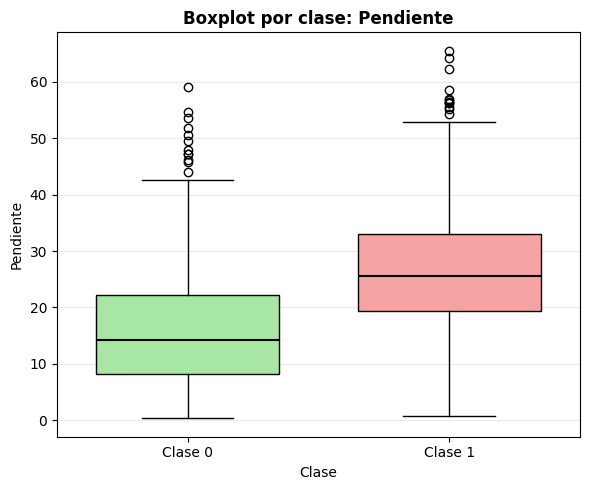

/tmp/ipykernel_14977/1880884670.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


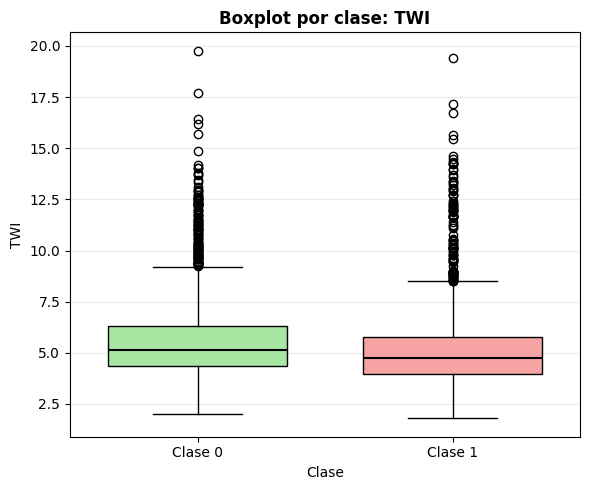

/tmp/ipykernel_14977/1880884670.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


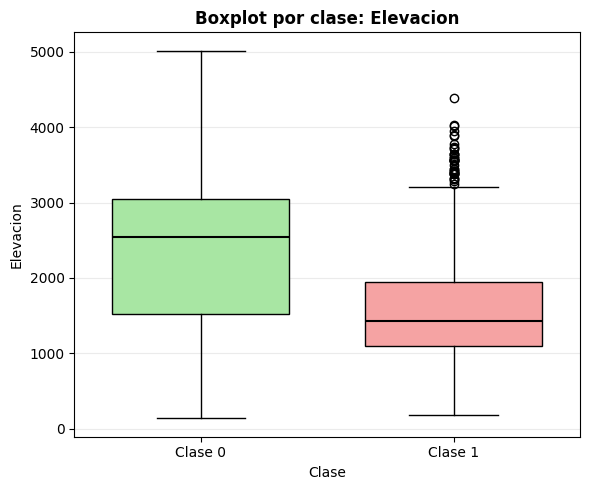

/tmp/ipykernel_14977/1880884670.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


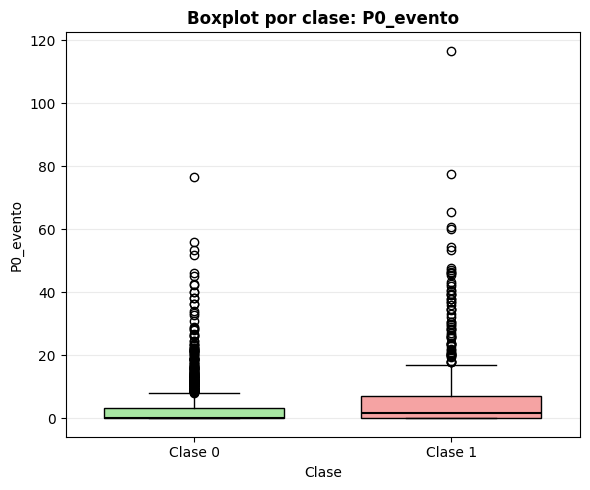

/tmp/ipykernel_14977/1880884670.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


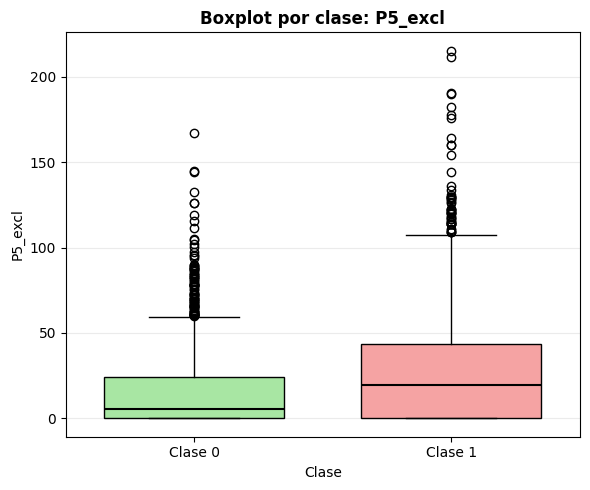

/tmp/ipykernel_14977/1880884670.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


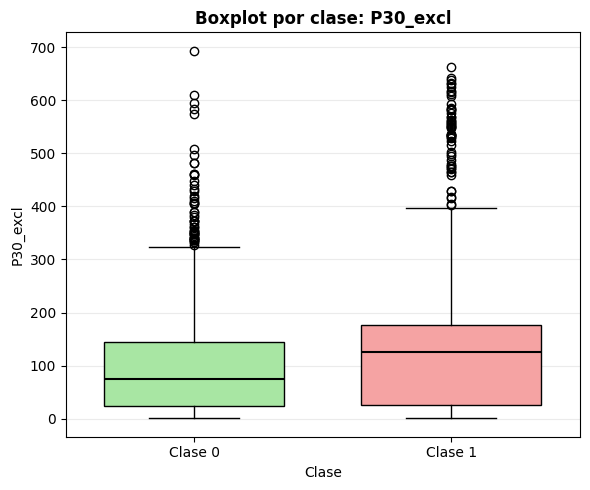

/tmp/ipykernel_14977/1880884670.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


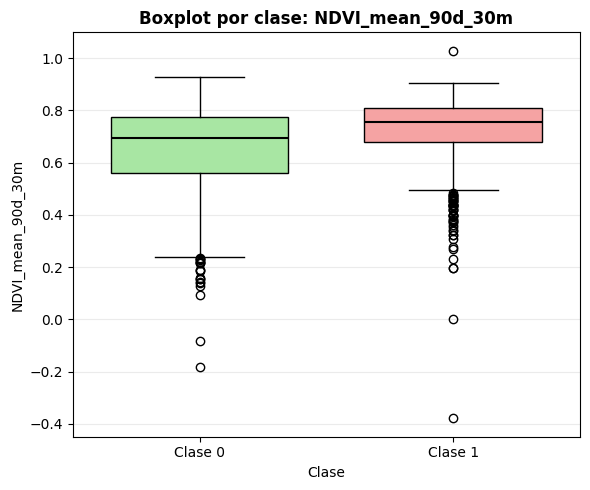

/tmp/ipykernel_14977/1880884670.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


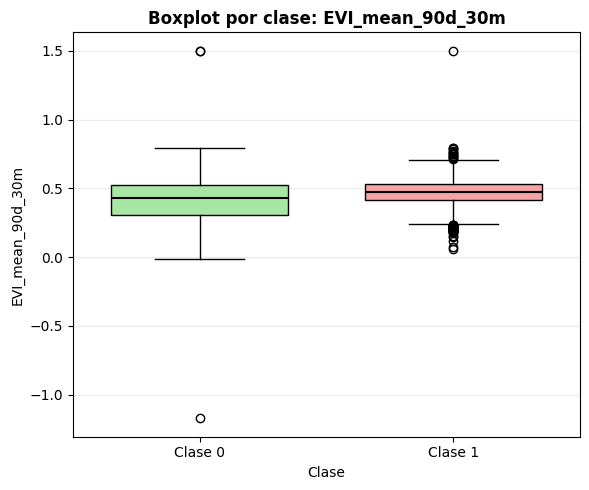

/tmp/ipykernel_14977/1880884670.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


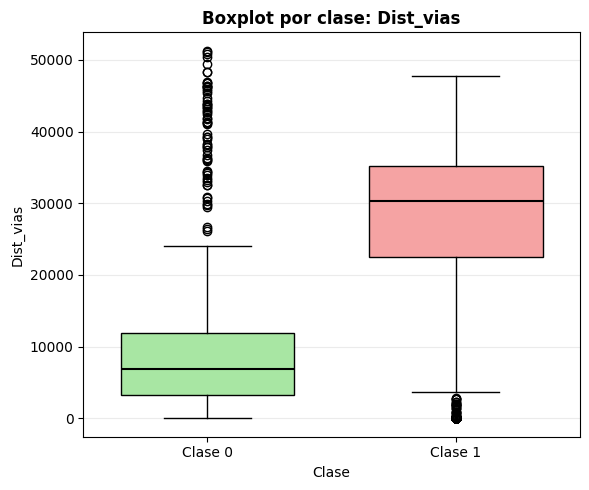

/tmp/ipykernel_14977/1880884670.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


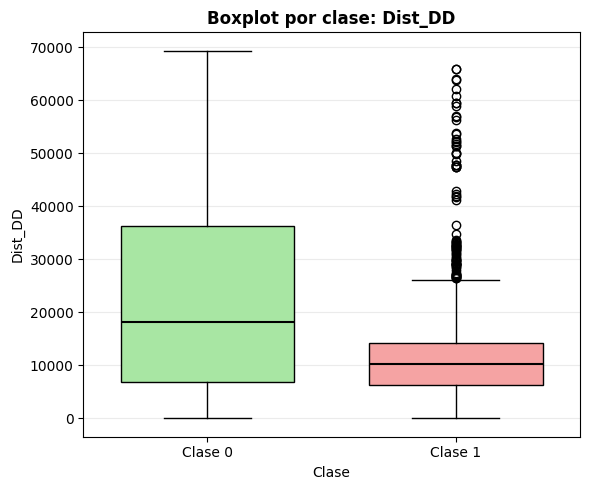

/tmp/ipykernel_14977/1880884670.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


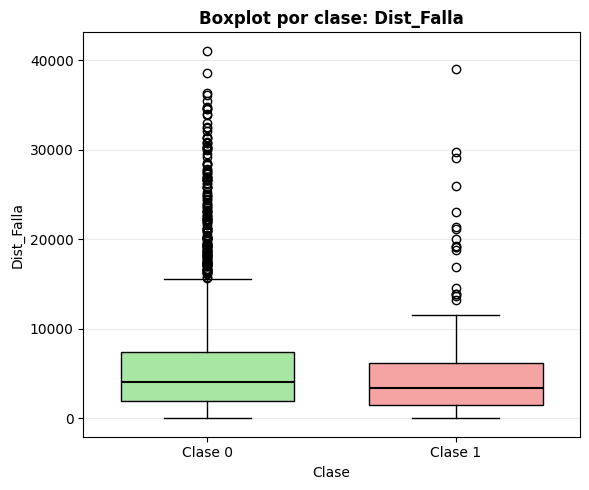

In [ ]:
# ============================================
# GRÁFICOS EDA (por clase) – Dataset Boyaca
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Colores pastel SOLO para boxplots
COLOR_0 = "#A8E6A3"   # verde pastel
COLOR_1 = "#F5A3A3"   # rojo pastel

# Colores originales para histogramas
HIST_0 = "#1f77b4"    # azul
HIST_1 = "#ff7f0e"    # naranja

# Asegura que 'clase' sea 0/1
gdf['clase'] = gdf['clase'].astype(int)

# ---- Selecciona variables (ajusta si quieres) ----
vars_topo = ['Pendiente', 'TWI', 'Elevacion', 'Geologia_UC', 'Paisaje']
vars_prec = ['P0_evento', 'P5_excl', 'P30_excl']
vars_opt  = ['NDVI_mean_90d_30m', 'EVI_mean_90d_30m']
vars_dist = ['Dist_vias', 'Dist_DD', 'Dist_Falla']

# Une y deja solo las que realmente existan en el DF
vars_plot = []
for grupo in [vars_topo, vars_prec, vars_opt, vars_dist]:
    vars_plot += [v for v in grupo if v in gdf.columns]

print("Variables a graficar:", vars_plot)

# Separar categóricas y numéricas
cat_vars = [v for v in ['Geologia_UC', 'Paisaje'] if v in vars_plot]
num_vars = [v for v in vars_plot if v not in cat_vars]

print("Numéricas:", num_vars)
print("Categóricas:", cat_vars)

# ============================================
# 1) BOXPLOTS por clase (numéricas) con colores pastel
# ============================================
for v in num_vars:
    dfp = gdf[['clase', v]].dropna()
    if dfp.empty:
        continue

    s0 = dfp.loc[dfp['clase'] == 0, v]
    s1 = dfp.loc[dfp['clase'] == 1, v]

    plt.figure(figsize=(6, 5))

    bp = plt.boxplot(
        [s0, s1],
        labels=['Clase 0', 'Clase 1'],
        patch_artist=True,
        showfliers=True,
        widths=0.7   # 🔹 ESTA ES LA CLAVE
    )

    # Colores pastel
    bp['boxes'][0].set_facecolor(COLOR_0)
    bp['boxes'][1].set_facecolor(COLOR_1)

    # Bordes y medianas para legibilidad
    for box in bp['boxes']:
        box.set_edgecolor("black")

    for median in bp['medians']:
        median.set_color("black")
        median.set_linewidth(1.5)

    for part in ['whiskers', 'caps']:
        for item in bp[part]:
            item.set_color("black")

    plt.title(f'Boxplot por clase: {v}', fontweight='bold')
    plt.xlabel('Clase')
    plt.ylabel(v)
    plt.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.show()


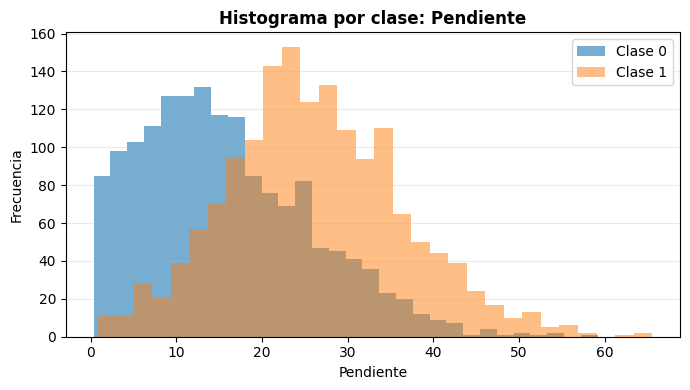

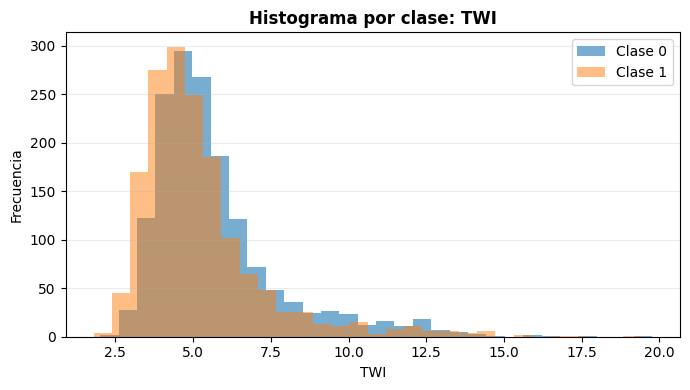

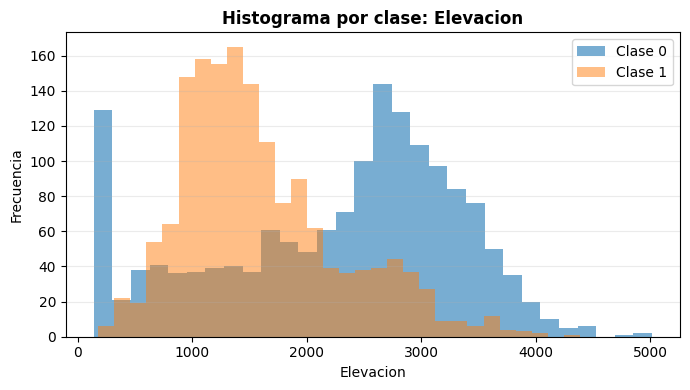

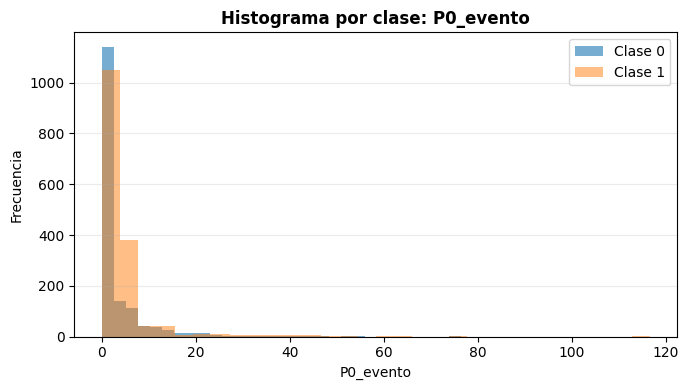

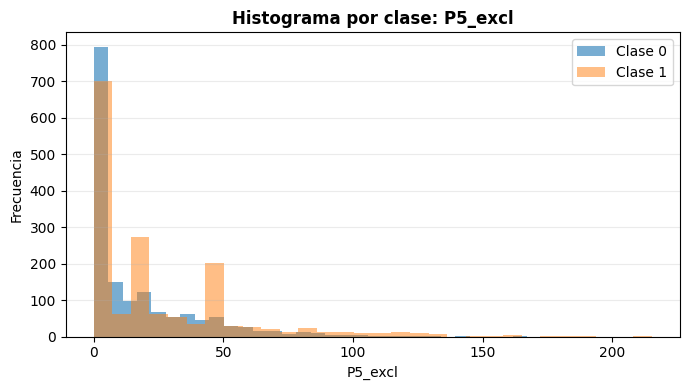

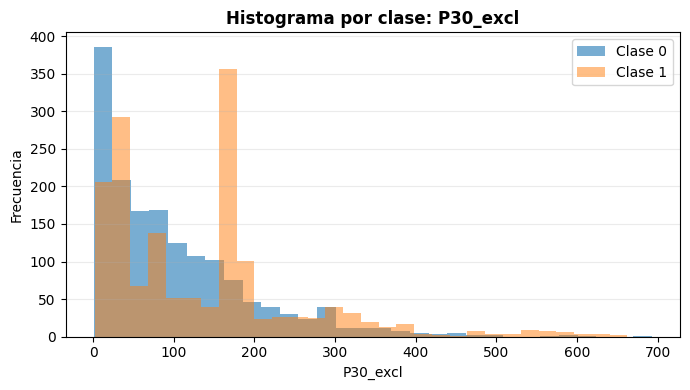

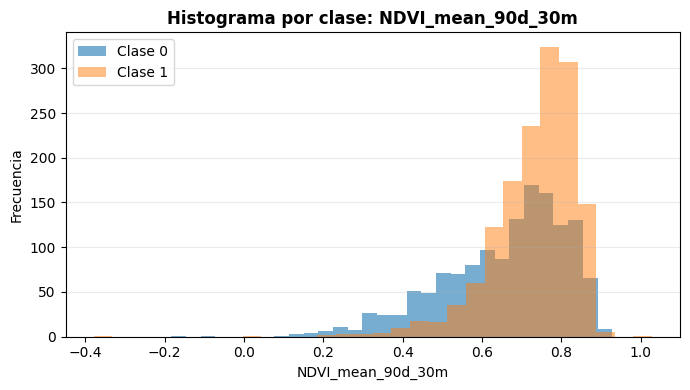

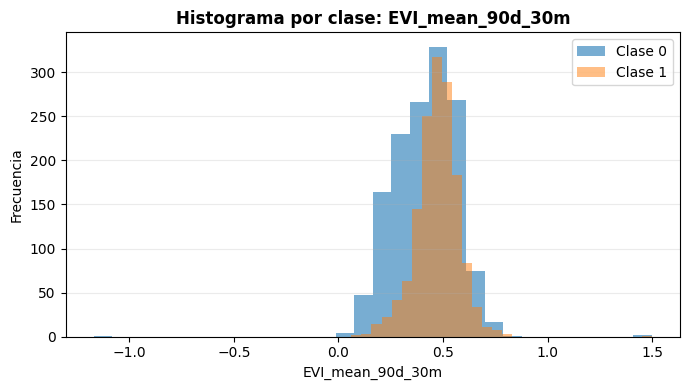

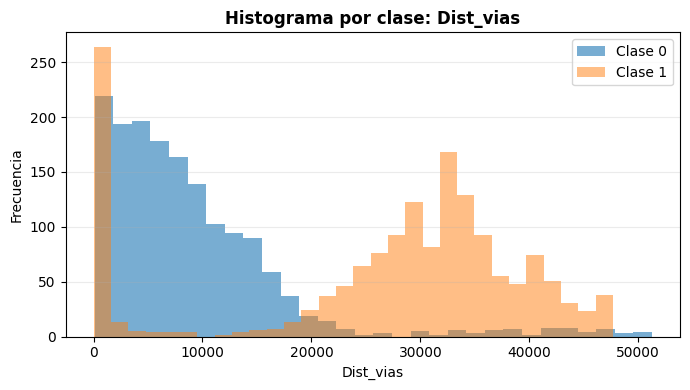

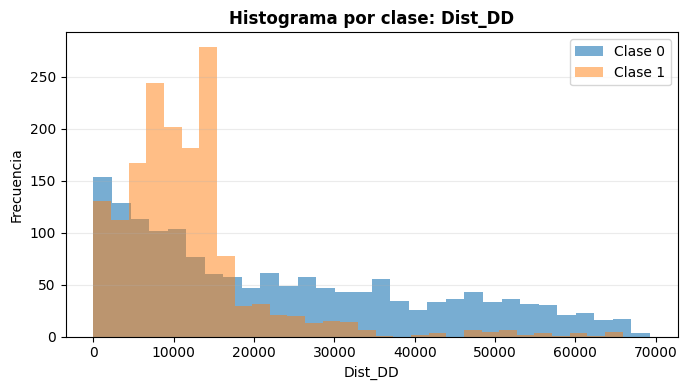

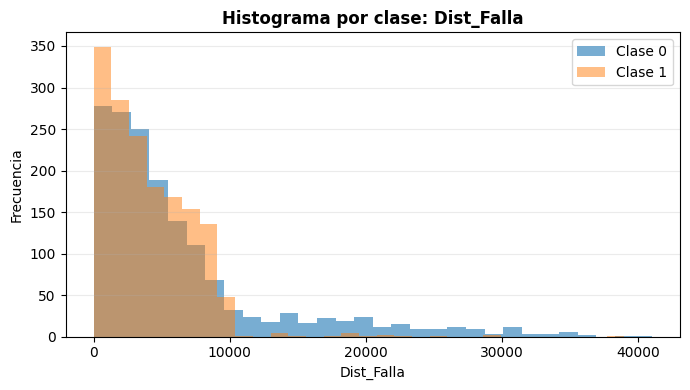

In [ ]:
# ============================================
# 2) HISTOGRAMAS comparativos por clase (numéricas)
# ============================================
for v in num_vars:
    dfp = gdf[['clase', v]].dropna()
    if dfp.empty:
        continue

    x0 = dfp.loc[dfp['clase'] == 0, v]
    x1 = dfp.loc[dfp['clase'] == 1, v]

    plt.figure(figsize=(7, 4))
    plt.hist(x0, bins=30, alpha=0.6, label='Clase 0', color=HIST_0, edgecolor='none')
    plt.hist(x1, bins=30, alpha=0.5, label='Clase 1', color=HIST_1, edgecolor='none')
    plt.title(f'Histograma por clase: {v}', fontweight='bold')
    plt.xlabel(v)
    plt.ylabel('Frecuencia')
    plt.legend()
    plt.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.show()



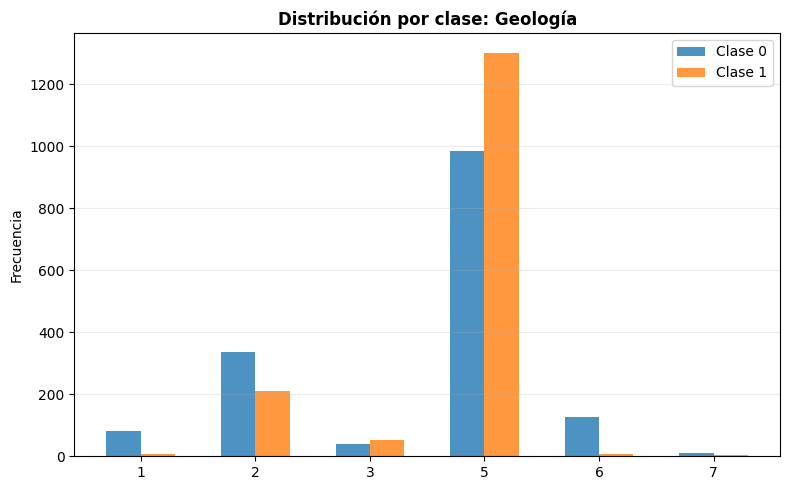

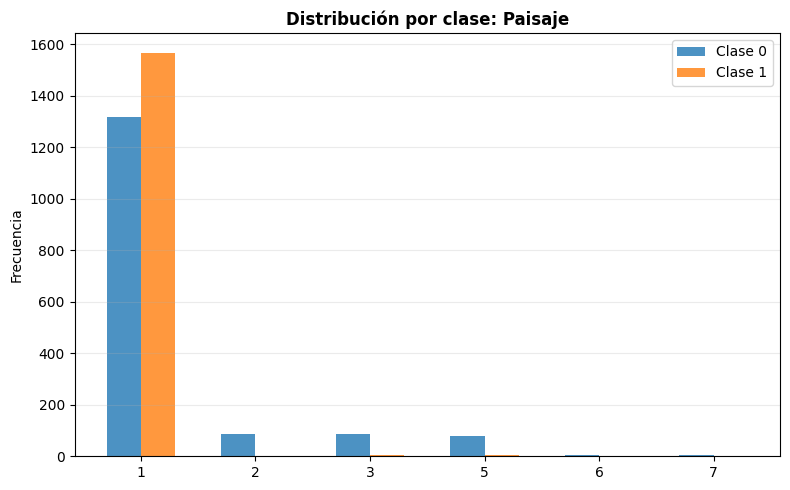

In [ ]:
# ============================================
# 3) CATEGÓRICAS: Geologia_UC y Paisaje
# ============================================
def plot_categorical_bars(df, col, title=None):
    tmp = df[['clase', col]].dropna().copy()
    if tmp.empty:
        print(f"⚠️ Sin datos para {col}")
        return

    ct = pd.crosstab(tmp[col], tmp['clase'])
    if 0 not in ct.columns:
        ct[0] = 0
    if 1 not in ct.columns:
        ct[1] = 0
    ct = ct[[0, 1]].sort_index()

    x = np.arange(len(ct.index))
    width = 0.30

    plt.figure(figsize=(8,5))
    plt.bar(x - width/2, ct[0].values, width=width, alpha=0.8 ,label='Clase 0', color=HIST_0)
    plt.bar(x + width/2, ct[1].values, width=width, alpha=0.8, label='Clase 1', color=HIST_1)

    plt.xticks(x, ct.index.astype(str))
    plt.ylabel('Frecuencia')
    plt.title(title if title else f'Distribución por clase: {col}', fontweight='bold')
    plt.legend()
    plt.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.show()

plot_categorical_bars(gdf, 'Geologia_U', 'Distribución por clase: Geología')
plot_categorical_bars(gdf, 'Paisaje', 'Distribución por clase: Paisaje')

In [ ]:
# =========================================================
# Transformación de variables categóricas a variables dummy
# =========================================================

categoricas = ["Geologia_U", "Paisaje"]

gdf = pd.get_dummies(
    gdf,
    columns=categoricas,
    drop_first=True,   # elimina categoría base
    dtype=int
)

print("Columnas después de crear dummies:")
print(gdf.columns)

Columnas después de crear dummies:
Index(['Codigo', 'P0_evento', 'P1_excl', 'P5_excl', 'P30_excl', 'Latitud',
       'Longitud', 'Humedad_T', 'Temp_T', 'Fecha_E', 'Dist_vias', 'Dist_DD',
       'Dist_Falla', 'Elevacion', 'CurvaturaN', 'CurvaturaT', 'TWI',
       'Eastness', 'Northness', 'Pendiente', 'clase', 'EVI_mean_90d_30m',
       'EVI_std_90d_30m', 'NDVI_mean_90d_30m', 'NDVI_std_90d_30m',
       'NDWI_mean_90d_30m', 'NDWI_std_90d_30m', 'VV_mean_24d_30m',
       'VV_std_24d_30m', 'VVminusVH_24d_30m', 'HH_mean_24d_25m',
       'HH_std_24d_25m', 'HHminusHV_24d_25m', 'geometry', 'Geologia_U_2',
       'Geologia_U_3', 'Geologia_U_5', 'Geologia_U_6', 'Geologia_U_7',
       'Paisaje_2', 'Paisaje_3', 'Paisaje_5', 'Paisaje_6', 'Paisaje_7'],
      dtype='object')


In [ ]:
out_path = "/content/drive/MyDrive/TESIS-BOYACA/Dataset_Boyaca/DatasetBoyaca_010726.gpkg"

gdf.to_file(out_path, layer="Dataset_Boyaca_Varcategoricas", driver="GPKG")
print("Guardado en:", out_path)

Guardado en: /content/drive/MyDrive/TESIS-BOYACA/Dataset_Boyaca/DatasetBoyaca_010726.gpkg


##**Implementación del modelo aplicado sobre el departamento de Cauca**

Inicialmente se va a cargar el modelo con la validación temporal realizada para el departamento de Cauca

In [ ]:
# ============================================================
# 1. CARGAR MODELO TEMPORAL ENTRENADO EN CAUCA
# ============================================================

!pip install fiona
import os
import json
import joblib
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import geopandas as gpd
import fiona
from google.colab import drive
drive.mount('/content/drive')

from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    recall_score,
    precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    auc
)

# Ruta donde guardaste el modelo final temporal de Cauca
ruta_modelo_dir = "/content/drive/MyDrive/TESIS/PRUEBA_MAPACONTINUO/Modelo_Final"

ruta_modelo = os.path.join(ruta_modelo_dir, "modelo_temporal.pkl")
ruta_feature_order = os.path.join(ruta_modelo_dir, "feature_order.json")

# Cargar modelo
modelo_temporal = joblib.load(ruta_modelo)

# Cargar orden exacto de variables usadas en Cauca
with open(ruta_feature_order, "r", encoding="utf-8") as f:
    feature_order = json.load(f)

print("Modelo temporal cargado correctamente.")
print("Número de variables esperadas:", len(feature_order))
print(feature_order)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Modelo temporal cargado correctamente.
Número de variables esperadas: 36
['P0_evento', 'P1_excl', 'P5_excl', 'P30_excl', 'Humedad_T', 'Temp_T', 'Dist_vias', 'Dist_DD', 'Dist_Falla', 'Elevacion', 'CurvaturaN', 'CurvaturaT', 'TWI', 'Eastness', 'Northness', 'Pendiente', 'Geologia_U_2', 'Geologia_U_3', 'Geologia_U_5', 'Geologia_U_6', 'Geologia_U_7', 'Paisaje_2', 'Paisaje_3', 'Paisaje_4', 'Paisaje_5', 'Paisaje_6', 'Paisaje_7', 'EVI_mean_90d_30m', 'EVI_std_90d_30m', 'NDVI_mean_90d_30m', 'NDVI_std_90d_30m', 'NDWI_mean_90d_30m', 'NDWI_std_90d_30m', 'VV_mean_24d_30m', 'VV_std_24d_30m', 'VVminusVH_24d_30m']


In [ ]:
import numpy as np
import pandas as pd

#Variables boyaca
gdf_boyaca= gpd.read_file("/content/drive/MyDrive/TESIS-BOYACA/Dataset_Boyaca/DatasetBoyaca_010726.gpkg", layer="Dataset_Boyaca_Varcategoricas")
# Lista de variables esperadas por el modelo temporal de Cauca
feature_order = [
    'P0_evento', 'P1_excl', 'P5_excl', 'P30_excl',
    'Humedad_T', 'Temp_T',
    'Dist_vias', 'Dist_DD', 'Dist_Falla',
    'Elevacion', 'CurvaturaN', 'CurvaturaT', 'TWI',
    'Eastness', 'Northness', 'Pendiente',
    'Geologia_U_2', 'Geologia_U_3', 'Geologia_U_5',
    'Geologia_U_6', 'Geologia_U_7',
    'Paisaje_2', 'Paisaje_3', 'Paisaje_4',
    'Paisaje_5', 'Paisaje_6', 'Paisaje_7',
    'EVI_mean_90d_30m', 'EVI_std_90d_30m',
    'NDVI_mean_90d_30m', 'NDVI_std_90d_30m',
    'NDWI_mean_90d_30m', 'NDWI_std_90d_30m',
    'VV_mean_24d_30m', 'VV_std_24d_30m',
    'VVminusVH_24d_30m'
]

# ============================================================
# 1. IDENTIFICAR VARIABLES FALTANTES
# ============================================================

faltantes = [col for col in feature_order if col not in gdf_boyaca.columns]

print("Variables faltantes en Boyacá:")
print(faltantes)

Variables faltantes en Boyacá:
['Paisaje_4']


Se detecta la ausencia de la variables dummie paisaje 4 en las variables de Boyaca esto se debe a que en este departamento no había presencia de esta clase. Por lo tanto es necesario crear la variables y llenarla de cero para todas las variables

In [ ]:
# ============================================================
# 2. CREAR VARIABLES FALTANTES CON VALOR 0
# ============================================================

for col in faltantes:
    gdf_boyaca[col] = 0

print("Variables faltantes creadas correctamente.")

Variables faltantes creadas correctamente.


In [ ]:
# ============================================================
# 3. CREAR X E y PARA BOYACÁ
# ============================================================

X_boyaca = gdf_boyaca[feature_order].copy()
y_boyaca = gdf_boyaca["clase"].astype(int).copy()

# Convertir todo a numérico
X_boyaca = X_boyaca.apply(pd.to_numeric, errors="coerce")

# Reemplazar infinitos por NaN
X_boyaca = X_boyaca.replace([np.inf, -np.inf], np.nan)

# Revisar nulos
nulos = X_boyaca.isna().sum()
nulos = nulos[nulos > 0]

print("Variables con nulos:")
print(nulos)

print("Dimensión X Boyacá:", X_boyaca.shape)
print("Distribución de clases:")
print(y_boyaca.value_counts())

Variables con nulos:
EVI_mean_90d_30m      287
EVI_std_90d_30m       287
NDVI_mean_90d_30m     287
NDVI_std_90d_30m      287
NDWI_mean_90d_30m     287
NDWI_std_90d_30m      287
VV_mean_24d_30m       389
VV_std_24d_30m        389
VVminusVH_24d_30m    1992
dtype: int64
Dimensión X Boyacá: (3160, 36)
Distribución de clases:
clase
1    1580
0    1580
Name: count, dtype: int64


Dado que para el departamento del Cauca el mejor desempeño se obtuvo con el escenario E3, en el caso de Boyacá se adoptó el mismo conjunto de variables definido para dicho escenario. Para garantizar la consistencia metodológica con el proceso de entrenamiento original, se conservaron únicamente los registros que no presentaron valores nulos en ninguna de las variables explicativas requeridas por el modelo.

In [ ]:
# ============================================================
# VERIFICAR VARIABLES ESPERADAS POR EL MODELO TEMPORAL DE CAUCA
# ============================================================

features_modelo_cauca = modelo_temporal.get_booster().feature_names

print("Número de variables esperadas por el modelo de Cauca:", len(features_modelo_cauca))
print(features_modelo_cauca)

print("\nNúmero de variables en X_boyaca_e3:", X_boyaca_e3.shape[1])
print(list(X_boyaca_e3.columns))

faltantes = [v for v in features_modelo_cauca if v not in X_boyaca_e3.columns]
adicionales = [v for v in X_boyaca_e3.columns if v not in features_modelo_cauca]

print("\nVariables faltantes en Boyacá:", faltantes)
print("Variables adicionales en Boyacá:", adicionales)# ============================================================
# VERIFICAR VARIABLES ESPERADAS POR EL MODELO TEMPORAL DE CAUCA
# ============================================================

features_modelo_cauca = modelo_temporal.get_booster().feature_names

print("Número de variables esperadas por el modelo de Cauca:", len(features_modelo_cauca))
print(features_modelo_cauca)

print("\nNúmero de variables en X_boyaca_e3:", X_boyaca_e3.shape[1])
print(list(X_boyaca_e3.columns))

faltantes = [v for v in features_modelo_cauca if v not in X_boyaca_e3.columns]
adicionales = [v for v in X_boyaca_e3.columns if v not in features_modelo_cauca]

print("\nVariables faltantes en Boyacá:", faltantes)
print("Variables adicionales en Boyacá:", adicionales)

Número de variables esperadas por el modelo de Cauca: 36
['P0_evento', 'P1_excl', 'P5_excl', 'P30_excl', 'Humedad_T', 'Temp_T', 'Dist_vias', 'Dist_DD', 'Dist_Falla', 'Elevacion', 'CurvaturaN', 'CurvaturaT', 'TWI', 'Eastness', 'Northness', 'Pendiente', 'Geologia_U_2', 'Geologia_U_3', 'Geologia_U_5', 'Geologia_U_6', 'Geologia_U_7', 'Paisaje_2', 'Paisaje_3', 'Paisaje_4', 'Paisaje_5', 'Paisaje_6', 'Paisaje_7', 'EVI_mean_90d_30m', 'EVI_std_90d_30m', 'NDVI_mean_90d_30m', 'NDVI_std_90d_30m', 'NDWI_mean_90d_30m', 'NDWI_std_90d_30m', 'VV_mean_24d_30m', 'VV_std_24d_30m', 'VVminusVH_24d_30m']

Número de variables en X_boyaca_e3: 36
['P0_evento', 'P1_excl', 'P5_excl', 'P30_excl', 'Humedad_T', 'Temp_T', 'Dist_vias', 'Dist_DD', 'Dist_Falla', 'Elevacion', 'CurvaturaN', 'CurvaturaT', 'TWI', 'Eastness', 'Northness', 'Pendiente', 'Geologia_U_2', 'Geologia_U_3', 'Geologia_U_5', 'Geologia_U_6', 'Geologia_U_7', 'Paisaje_2', 'Paisaje_3', 'Paisaje_4', 'Paisaje_5', 'Paisaje_6', 'Paisaje_7', 'EVI_mean_90d_30m'

In [ ]:
# ============================================================
# 4. FILTRAR REGISTROS COMPLETOS PARA EL ESCENARIO E3
# ============================================================

# Elige los registros que no son nulos
mask_e3_completo = X_boyaca.notna().all(axis=1)

X_boyaca_e3 = X_boyaca.loc[mask_e3_completo].copy()
y_boyaca_e3 = y_boyaca.loc[mask_e3_completo].copy()
gdf_boyaca_e3 = gdf_boyaca.loc[mask_e3_completo].copy()

print("Registros originales Boyacá:", len(gdf_boyaca))
print("Registros completos para E3:", len(gdf_boyaca_e3))
print("Registros excluidos por NaN:", len(gdf_boyaca) - len(gdf_boyaca_e3))

print("\nDistribución de clases en Boyacá completo E3:")
print(y_boyaca_e3.value_counts())

print("\nDistribución porcentual:")
print((y_boyaca_e3.value_counts(normalize=True) * 100).round(2))

Registros originales Boyacá: 3160
Registros completos para E3: 1039
Registros excluidos por NaN: 2121

Distribución de clases en Boyacá completo E3:
clase
1    525
0    514
Name: count, dtype: int64

Distribución porcentual:
clase
1    50.53
0    49.47
Name: proportion, dtype: float64


El siguiente paso consistió en aplicar el modelo temporal entrenado en Cauca sobre los registros completos de Boyacá del escenario E3. Es decir, aquí no se entrena nada nuevo; solamente se usa el modelo ya aprendido en Cauca para predecir en Boyacá.

In [ ]:
X_boyaca_e3.columns

Index(['P0_evento', 'P1_excl', 'P5_excl', 'P30_excl', 'Humedad_T', 'Temp_T',
       'Dist_vias', 'Dist_DD', 'Dist_Falla', 'Elevacion', 'CurvaturaN',
       'CurvaturaT', 'TWI', 'Eastness', 'Northness', 'Pendiente',
       'Geologia_U_2', 'Geologia_U_3', 'Geologia_U_5', 'Geologia_U_6',
       'Geologia_U_7', 'Paisaje_2', 'Paisaje_3', 'Paisaje_4', 'Paisaje_5',
       'Paisaje_6', 'Paisaje_7', 'EVI_mean_90d_30m', 'EVI_std_90d_30m',
       'NDVI_mean_90d_30m', 'NDVI_std_90d_30m', 'NDWI_mean_90d_30m',
       'NDWI_std_90d_30m', 'VV_mean_24d_30m', 'VV_std_24d_30m',
       'VVminusVH_24d_30m'],
      dtype='object')

In [ ]:
# ============================================================
# 5. APLICAR MODELO TEMPORAL CAUCA SOBRE BOYACÁ E3 COMPLETO
# ============================================================

y_prob_boyaca = modelo_temporal.predict_proba(X_boyaca_e3)[:, 1]

# Mantener el mismo umbral usado en Cauca
umbral = 0.5
y_pred_boyaca = (y_prob_boyaca >= umbral).astype(int)

# Guardar resultados en el GeoDataFrame filtrado
gdf_boyaca_e3["prob_deslizamiento"] = y_prob_boyaca
gdf_boyaca_e3["prediccion"] = y_pred_boyaca

print("Predicción aplicada correctamente.")
print("Registros evaluados:", len(gdf_boyaca_e3))

Predicción aplicada correctamente.
Registros evaluados: 1039


In [ ]:
# ============================================================
# 5. MÉTRICAS DE VALIDACIÓN ESPACIAL EXTERNA
# ============================================================

from sklearn.metrics import accuracy_score,roc_auc_score, f1_score, recall_score, precision_score

accuracy_boyaca = accuracy_score(y_boyaca_e3, y_pred_boyaca)
auc_boyaca = roc_auc_score(y_boyaca_e3, y_prob_boyaca)
f1_boyaca = f1_score(y_boyaca_e3, y_pred_boyaca)
recall_boyaca = recall_score(y_boyaca_e3, y_pred_boyaca)
precision_boyaca = precision_score(y_boyaca_e3, y_pred_boyaca)

print("===== RESULTADOS VALIDACIÓN ESPACIAL EXTERNA - BOYACÁ / E3 COMPLETO =====")
print(f"Accuracy: {accuracy_boyaca:.4f}")
print(f"AUC: {auc_boyaca:.4f}")
print(f"F1-score: {f1_boyaca:.4f}")
print(f"Recall / Sensibilidad: {recall_boyaca:.4f}")
print(f"Precision: {precision_boyaca:.4f}")


===== RESULTADOS VALIDACIÓN ESPACIAL EXTERNA - BOYACÁ / E3 COMPLETO =====
Accuracy: 0.4986
AUC: 0.3272
F1-score: 0.6606
Recall / Sensibilidad: 0.9657
Precision: 0.5020


El modelo tiene una alta sensibilidad para la clase Evento, porque de 525 eventos reales logró detectar 509.Sin embargo, tiene una capacidad muy baja para identificar los no eventos, porque de 514 no eventos reales solo clasificó correctamente 5.

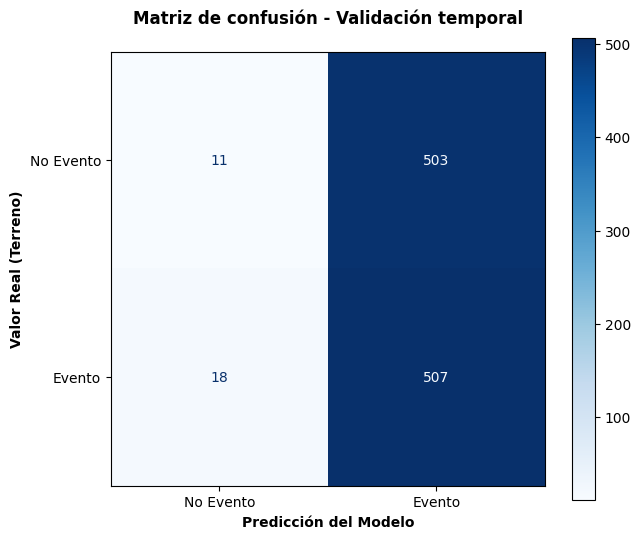

In [ ]:
# =========================================
# 7. Matriz de confusión
# =========================================
clases= ["No Evento", "Evento"]
cm = confusion_matrix(y_boyaca_e3, y_pred_boyaca)
fig,ax=plt.subplots(figsize=(7,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
disp.plot(cmap="Blues", ax=ax, colorbar=True, values_format="d")
plt.title("Matriz de confusión - Validación temporal", fontweight="bold", pad=20)
plt.xlabel("Predicción del Modelo", fontweight="bold", fontsize=10)
plt.ylabel("Valor Real (Terreno)", fontweight="bold", fontsize=10)
ax.grid(False)
plt.show()




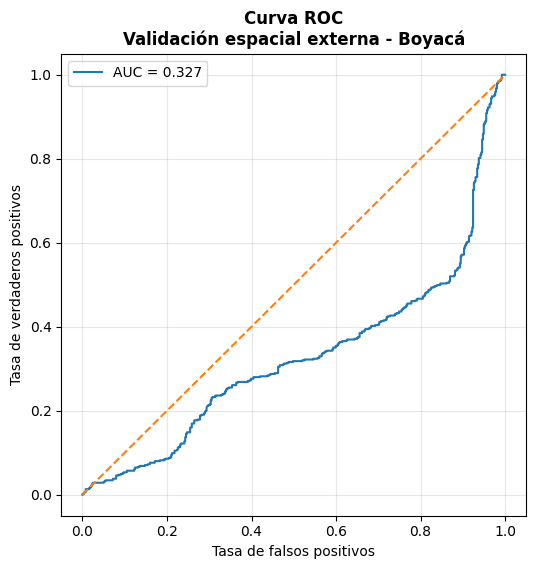

In [ ]:
# ============================================================
# 5. CURVA ROC
# ============================================================

from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_boyaca_e3, y_prob_boyaca)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC\nValidación espacial externa - Boyacá", fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Al igual que la matriz de confusión la curva ROC confirma que la validación espacial en un territorio diferente a Cauca, en este caso Boyacá tuvo un desempeño bajo, el modelo no separa adecuadamente las dos clases en Boyacá.

**Estos resultados sugieren que las relaciones aprendidas por el modelo en Cauca no se transfieren directamente al departamento de Boyacá, posiblemente debido a diferencias territoriales en la distribución de las variables geomorfológicas, climáticas, espectrales y radar. En consecuencia, la aplicación del modelo en nuevos territorios requiere procesos de recalibración o reentrenamiento local.**

In [ ]:
# ============================================================
# 1. PREPARAR DATOS PARA ENTRENAMIENTO LOCAL EN BOYACÁ
# ============================================================

import numpy as np
import pandas as pd

# Asegurar fecha
gdf_boyaca_e3["Fecha_E"] = pd.to_datetime(
    gdf_boyaca_e3["Fecha_E"],
    errors="coerce"
)

# Matriz de variables y clase
X_boyaca_local = gdf_boyaca_e3[feature_order].copy()
y_boyaca_local = gdf_boyaca_e3["clase"].astype(int).copy()

# Asegurar numéricos
X_boyaca_local = X_boyaca_local.apply(pd.to_numeric, errors="coerce")
X_boyaca_local = X_boyaca_local.replace([np.inf, -np.inf], np.nan)

# Como ya filtraste E3 completo, no deberían quedar nulos
print("Nulos restantes:")
print(X_boyaca_local.isna().sum()[X_boyaca_local.isna().sum() > 0])

print("Dimensión:", X_boyaca_local.shape)
print("Distribución de clases:")
print(y_boyaca_local.value_counts())

Nulos restantes:
Series([], dtype: int64)
Dimensión: (1039, 36)
Distribución de clases:
clase
1    525
0    514
Name: count, dtype: int64


In [ ]:
# ============================================================
# 2. PARTICIÓN TEMPORAL 70/30 EN BOYACÁ
# ============================================================

df_boyaca_model = gdf_boyaca_e3.copy()
df_boyaca_model["Fecha_E"] = pd.to_datetime(df_boyaca_model["Fecha_E"], errors="coerce")

# Ordenar temporalmente
df_boyaca_model = df_boyaca_model.sort_values("Fecha_E").reset_index(drop=True)

# Corte 70/30
split_idx = int(len(df_boyaca_model) * 0.70)

train_boyaca = df_boyaca_model.iloc[:split_idx].copy()
test_boyaca  = df_boyaca_model.iloc[split_idx:].copy()

X_train_b = train_boyaca[feature_order].copy()
y_train_b = train_boyaca["clase"].astype(int).copy()

X_test_b = test_boyaca[feature_order].copy()
y_test_b = test_boyaca["clase"].astype(int).copy()

print("Entrenamiento Boyacá:", len(train_boyaca))
print("Prueba Boyacá:", len(test_boyaca))

print("\nDistribución entrenamiento:")
print(y_train_b.value_counts(normalize=True).round(3))

print("\nDistribución prueba:")
print(y_test_b.value_counts(normalize=True).round(3))

Entrenamiento Boyacá: 727
Prueba Boyacá: 312

Distribución entrenamiento:
clase
1    0.505
0    0.495
Name: proportion, dtype: float64

Distribución prueba:
clase
1    0.506
0    0.494
Name: proportion, dtype: float64


In [ ]:
# ============================================================
# 1. PREPARAR DATOS DE BOYACÁ PARA REENTRENAMIENTO LOCAL
# ============================================================

import numpy as np
import pandas as pd

gdf_boyaca_e3 = gdf_boyaca_e3.copy()

gdf_boyaca_e3["Fecha_E"] = pd.to_datetime(
    gdf_boyaca_e3["Fecha_E"],
    errors="coerce"
)

# Ordenar temporalmente
gdf_boyaca_model = (
    gdf_boyaca_e3
    .dropna(subset=["Fecha_E"])
    .sort_values("Fecha_E")
    .reset_index(drop=True)
)

X_boyaca_local = gdf_boyaca_model[feature_order].copy()
y_boyaca_local = gdf_boyaca_model["clase"].astype(int).copy()

# Asegurar que todo sea numérico
X_boyaca_local = X_boyaca_local.apply(pd.to_numeric, errors="coerce")
X_boyaca_local = X_boyaca_local.replace([np.inf, -np.inf], np.nan)

print("Dimensión X Boyacá:", X_boyaca_local.shape)
print("Nulos restantes:")
print(X_boyaca_local.isna().sum()[X_boyaca_local.isna().sum() > 0])

print("\nDistribución de clases:")
print(y_boyaca_local.value_counts())

Dimensión X Boyacá: (1039, 36)
Nulos restantes:
Series([], dtype: int64)

Distribución de clases:
clase
1    525
0    514
Name: count, dtype: int64


In [ ]:
# ============================================================
# 2. PARTICIÓN TEMPORAL 70/30
# ============================================================

split_idx = int(len(gdf_boyaca_model) * 0.70)

train_boyaca = gdf_boyaca_model.iloc[:split_idx].copy()
test_boyaca  = gdf_boyaca_model.iloc[split_idx:].copy()

X_train_b = train_boyaca[feature_order].copy()
y_train_b = train_boyaca["clase"].astype(int).copy()

X_test_b = test_boyaca[feature_order].copy()
y_test_b = test_boyaca["clase"].astype(int).copy()

X_train_b = X_train_b.apply(pd.to_numeric, errors="coerce")
X_test_b = X_test_b.apply(pd.to_numeric, errors="coerce")

print("Registros entrenamiento Boyacá:", len(X_train_b))
print("Registros prueba Boyacá:", len(X_test_b))

print("\nDistribución entrenamiento:")
print(y_train_b.value_counts())
print((y_train_b.value_counts(normalize=True) * 100).round(2))

print("\nDistribución prueba:")
print(y_test_b.value_counts())
print((y_test_b.value_counts(normalize=True) * 100).round(2))

Registros entrenamiento Boyacá: 727
Registros prueba Boyacá: 312

Distribución entrenamiento:
clase
1    367
0    360
Name: count, dtype: int64
clase
1    50.48
0    49.52
Name: proportion, dtype: float64

Distribución prueba:
clase
1    158
0    154
Name: count, dtype: int64
clase
1    50.64
0    49.36
Name: proportion, dtype: float64


In [ ]:
# ============================================================
# 3. CLONAR EL MISMO MODELO TEMPORAL
# ============================================================

from sklearn.base import clone

modelo_boyaca_local = clone(modelo_temporal)

print("Modelo clonado:")
print(modelo_boyaca_local)

Modelo clonado:
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.5,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None,
              num_parallel_tree=None, ...)


In [ ]:
# ============================================================
# 4. AJUSTAR PESO DE CLASE PARA BOYACÁ
# ============================================================

pos = (y_train_b == 1).sum()
neg = (y_train_b == 0).sum()

scale_pos_weight_boyaca = neg / pos if pos > 0 else 1.0

# Solo si el modelo tiene este parámetro
if "scale_pos_weight" in modelo_boyaca_local.get_params():
    modelo_boyaca_local.set_params(scale_pos_weight=scale_pos_weight_boyaca)

print("scale_pos_weight Boyacá:", scale_pos_weight_boyaca)

scale_pos_weight Boyacá: 0.9809264305177112


In [ ]:
# ============================================================
# 5. ENTRENAMIENTO CON VALIDACIÓN INTERNA SI EL MODELO USA EARLY STOPPING
# ============================================================

params = modelo_boyaca_local.get_params()

if params.get("early_stopping_rounds", None) is not None:

    split_interno = int(len(train_boyaca) * 0.80)

    train_in = train_boyaca.iloc[:split_interno].copy()
    val_in = train_boyaca.iloc[split_interno:].copy()

    X_train_in = train_in[feature_order].apply(pd.to_numeric, errors="coerce")
    y_train_in = train_in["clase"].astype(int)

    X_val_in = val_in[feature_order].apply(pd.to_numeric, errors="coerce")
    y_val_in = val_in["clase"].astype(int)

    modelo_boyaca_local.fit(
        X_train_in,
        y_train_in,
        eval_set=[(X_val_in, y_val_in)],
        verbose=False
    )

else:
    modelo_boyaca_local.fit(X_train_b, y_train_b)

print("Modelo E3 reentrenado con Boyacá correctamente.")

Modelo E3 reentrenado con Boyacá correctamente.


In [ ]:
# ============================================================
# 6. EVALUAR MODELO LOCAL BOYACÁ
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    f1_score,
    recall_score,
    precision_score,
    confusion_matrix,
    classification_report

)

y_prob_boyaca_local = modelo_boyaca_local.predict_proba(X_test_b)[:, 1]

umbral = 0.5
y_pred_boyaca_local = (y_prob_boyaca_local >= umbral).astype(int)

accuracy_boyaca_local = accuracy_score(y_test_b, y_pred_boyaca_local)
auc_boyaca_local = roc_auc_score(y_test_b, y_prob_boyaca_local)
f1_boyaca_local = f1_score(y_test_b, y_pred_boyaca_local)
recall_boyaca_local = recall_score(y_test_b, y_pred_boyaca_local)
precision_boyaca_local = precision_score(y_test_b, y_pred_boyaca_local)

print("===== MODELO E3 REENTRENADO CON BOYACÁ =====")
print(f"Accuracy: {accuracy_boyaca_local:.4f}")
print(f"AUC: {auc_boyaca_local:.4f}")
print(f"F1-score: {f1_boyaca_local:.4f}")
print(f"Recall: {recall_boyaca_local:.4f}")
print(f"Precision: {precision_boyaca_local:.4f}")

===== MODELO E3 REENTRENADO CON BOYACÁ =====
Accuracy: 0.9776
AUC: 0.9804
F1-score: 0.9775
Recall: 0.9620
Precision: 0.9935


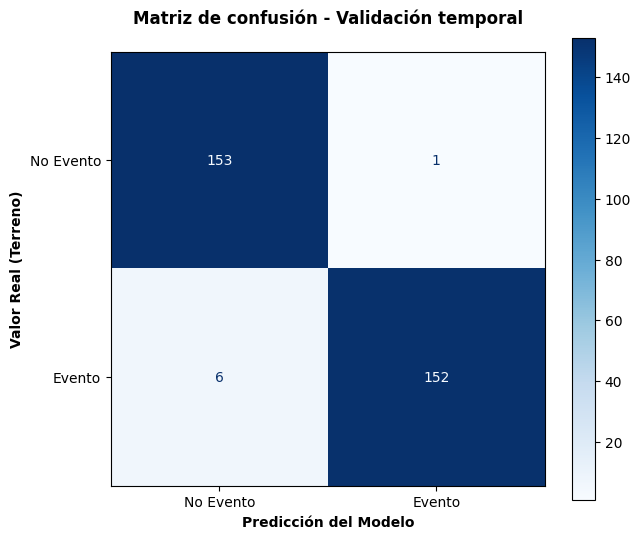

In [ ]:
# =========================================
# 7. Matriz de confusión
# =========================================
clases= ["No Evento", "Evento"]
cm = confusion_matrix(y_test_b, y_pred_boyaca_local)
fig,ax=plt.subplots(figsize=(7,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
disp.plot(cmap="Blues", ax=ax, colorbar=True, values_format="d")
plt.title("Matriz de confusión - Validación temporal", fontweight="bold", pad=20)
plt.xlabel("Predicción del Modelo", fontweight="bold", fontsize=10)
plt.ylabel("Valor Real (Terreno)", fontweight="bold", fontsize=10)
ax.grid(False)
plt.show()




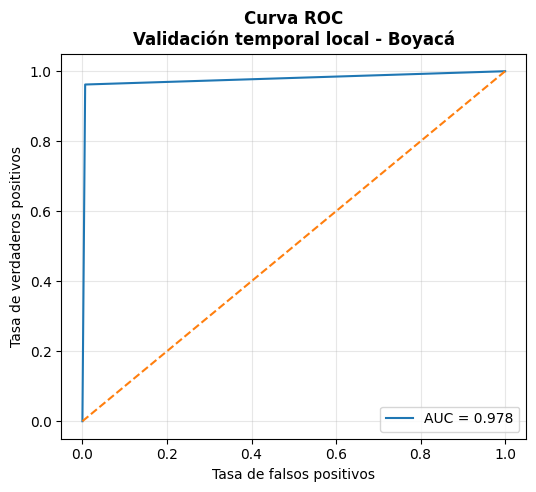

In [ ]:
# ============================================================
# 8. CURVA ROC
# ============================================================

from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test_b, y_pred_boyaca_local)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC\nValidación temporal local - Boyacá", fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

A partir de los resultados obtenidos en la matriz de confusión, la curva ROC y los indicadores de desempeño, se evidencia que, al reentrenar el modelo con datos propios del departamento de Boyacá, este presenta una alta capacidad para diferenciar entre eventos y no eventos de deslizamiento en el conjunto evaluado. Este comportamiento sugiere que la estructura metodológica definida para el escenario E3 conserva capacidad predictiva cuando el modelo es ajustado con información local del territorio.

In [ ]:
# ============================================================
# 7. GUARDAR MODELO REENTRENADO CON BOYACÁ
# ============================================================

import os
import json
import joblib

ruta_modelo_boyaca = "/content/drive/MyDrive/TESIS-BOYACA/Modelo_E3_Reentrenado_Boyaca"
os.makedirs(ruta_modelo_boyaca, exist_ok=True)

joblib.dump(
    modelo_boyaca_local,
    os.path.join(ruta_modelo_boyaca, "modelo_E3_reentrenado_boyaca.pkl")
)

with open(
    os.path.join(ruta_modelo_boyaca, "feature_order_E3_boyaca.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump(feature_order, f, ensure_ascii=False, indent=4)

print("Modelo reentrenado con Boyacá guardado correctamente.")

Modelo reentrenado con Boyacá guardado correctamente.


/tmp/ipykernel_926/977693828.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

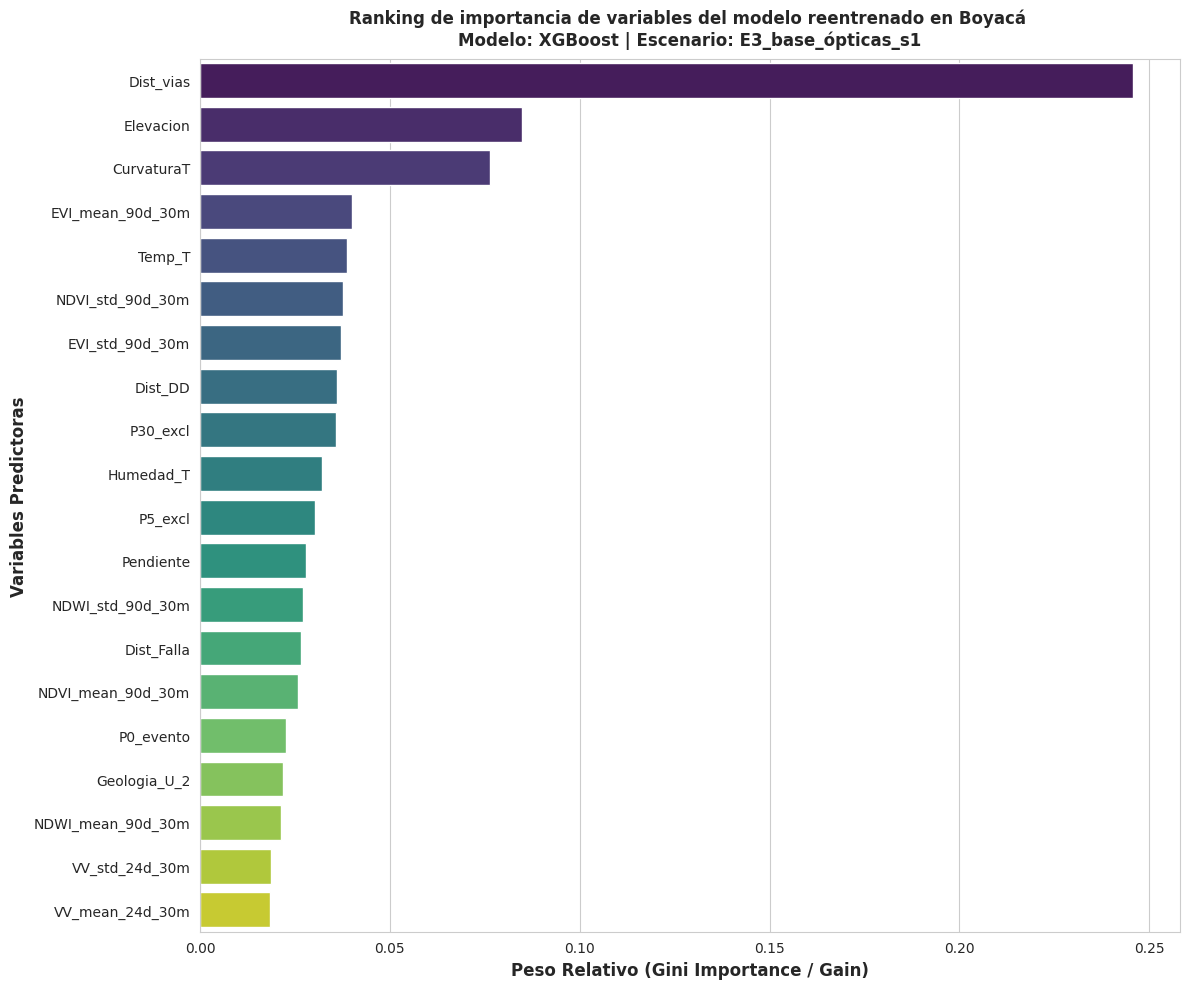

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# ============================================================
# IMPORTANCIA DE VARIABLES - MODELO REENTRENADO EN BOYACÁ
# MISMO ESTILO VISUAL DEL GRÁFICO DE CAUCA
# ============================================================

# 1. Crear DataFrame de importancias
importancias_boyaca = pd.DataFrame({
    "Variable": X_train_b.columns,
    "Importancia": modelo_boyaca_local.feature_importances_
}).sort_values("Importancia", ascending=False).head(20)

# 2. Configuración visual igual a Cauca
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(12, 10))

ax = sns.barplot(
    x="Importancia",
    y="Variable",
    data=importancias_boyaca,
    palette="viridis",
    ax=ax
)

# 3. Personalización de etiquetas y títulos
ax.set_title(
    "Ranking de importancia de variables del modelo reentrenado en Boyacá \n"
     "Modelo: XGBoost | Escenario: E3_base_ópticas_s1",
    fontsize=12,
    fontweight="bold",
    pad=10
)

ax.set_xlabel("Peso Relativo (Gini Importance / Gain)", fontsize=12, fontweight="bold")
ax.set_ylabel("Variables Predictoras", fontsize=12, fontweight="bold")

# 4. Ajuste de diseño
fig.tight_layout()

# 5. Guardar en alta resolución
nombre_salida = "importancia_variables_boyaca_xgboost.png"

fig.savefig(
    nombre_salida,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

# 6. Descargar
files.download(nombre_salida)

# 7. Mostrar figura
plt.show()

**Validación de comportamiento de datos, para verificar el correcto comportamiento del modelo**

In [ ]:
cod_train = set(train_boyaca["Codigo"].astype(str))
cod_test = set(test_boyaca["Codigo"].astype(str))

interseccion_codigos = cod_train.intersection(cod_test)

print("Códigos repetidos entre train y test:", len(interseccion_codigos))
print(list(interseccion_codigos)[:20])

Códigos repetidos entre train y test: 0
[]


In [ ]:
# Crear identificador espacial-temporal aproximado
train_check = train_boyaca.copy()
test_check = test_boyaca.copy()

for df in [train_check, test_check]:
    df["Fecha_E"] = pd.to_datetime(df["Fecha_E"], errors="coerce")
    df["x_round"] = df.geometry.x.round(4)
    df["y_round"] = df.geometry.y.round(4)

train_keys = set(
    zip(
        train_check["Fecha_E"].astype(str),
        train_check["x_round"],
        train_check["y_round"]
    )
)

test_keys = set(
    zip(
        test_check["Fecha_E"].astype(str),
        test_check["x_round"],
        test_check["y_round"]
    )
)

interseccion_geom_fecha = train_keys.intersection(test_keys)

print("Coincidencias fecha-geometría entre train y test:", len(interseccion_geom_fecha))

Coincidencias fecha-geometría entre train y test: 0


In [ ]:
print("Rango temporal entrenamiento:")
print(train_boyaca["Fecha_E"].min(), train_boyaca["Fecha_E"].max())

print("\nRango temporal prueba:")
print(test_boyaca["Fecha_E"].min(), test_boyaca["Fecha_E"].max())

print("\nDistribución por año en entrenamiento:")
print(train_boyaca["Fecha_E"].dt.year.value_counts().sort_index())

print("\nDistribución por año en prueba:")
print(test_boyaca["Fecha_E"].dt.year.value_counts().sort_index())

Rango temporal entrenamiento:
2015-01-01 00:00:00 2022-09-22 00:00:00

Rango temporal prueba:
2022-09-22 00:00:00 2025-01-28 00:00:00

Distribución por año en entrenamiento:
Fecha_E
2015    239
2016     16
2017     43
2018     15
2019     12
2020    130
2021    155
2022    117
Name: count, dtype: int64

Distribución por año en prueba:
Fecha_E
2022     98
2023    137
2024     73
2025      4
Name: count, dtype: int64


CRS Boyacá: EPSG:9377
CRS puntos: EPSG:9377


/tmp/ipykernel_926/2698972451.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = cm.get_cmap("YlOrRd")


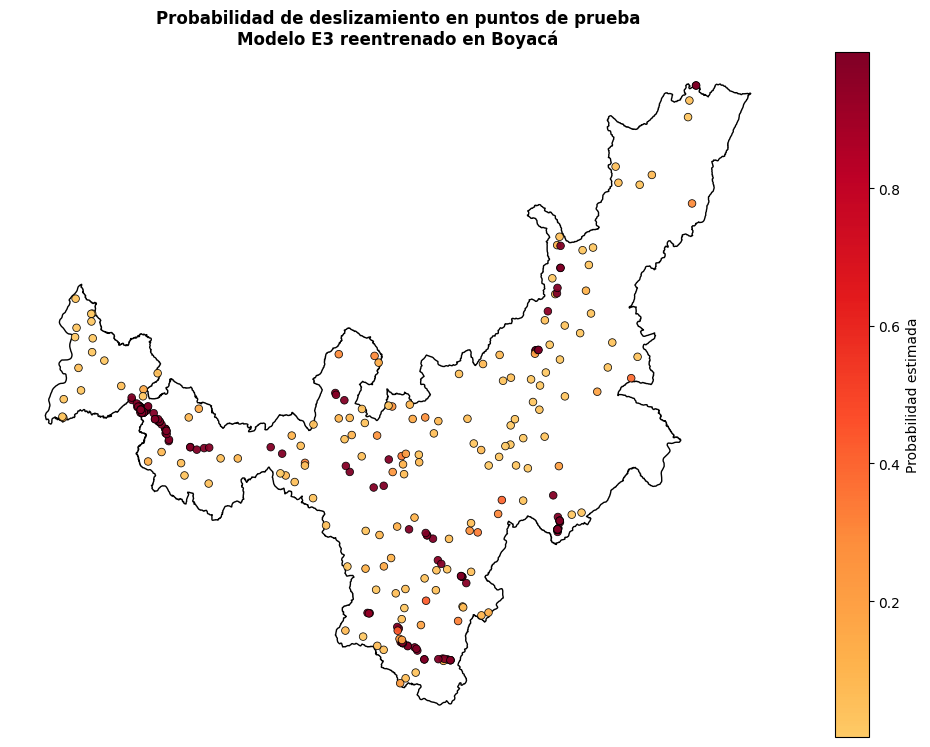

In [ ]:
# ============================================================
# MAPA DE PROBABILIDAD - MODELO E3 REENTRENADO EN BOYACÁ
# ============================================================

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np

# ================================
# Preparar GeoDataFrame del test
# ================================

test_map_boyaca = test_boyaca.copy()

# Agregar resultados del modelo reentrenado
test_map_boyaca["prob_deslizamiento"] = y_prob_boyaca_local
test_map_boyaca["prediccion"] = y_pred_boyaca_local
test_map_boyaca["clase_real"] = y_test_b.values

# ================================
# Cargar límite departamental
# ================================

boyaca = gpd.read_file("/content/drive/MyDrive/TESIS-BOYACA/Depto/Boyaca.shp")

print("CRS Boyacá:", boyaca.crs)
print("CRS puntos:", test_map_boyaca.crs)

# Asegurar mismo CRS
if boyaca.crs != test_map_boyaca.crs:
    boyaca = boyaca.to_crs(test_map_boyaca.crs)

# ================================
# Crear paleta YlOrRd ajustada
# ================================

base_cmap = cm.get_cmap("YlOrRd")
colors = base_cmap(np.linspace(0.30, 1, 256))

custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    "YlOrRd_ajustada",
    colors
)

# ================================
# Graficar mapa
# ================================

fig, ax = plt.subplots(figsize=(10, 8))

# Límite departamental
boyaca.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=1
)

# Puntos de prueba con probabilidad
test_map_boyaca.plot(
    column="prob_deslizamiento",
    cmap=custom_cmap,
    legend=True,
    markersize=30,
    alpha=0.95,
    edgecolor="black",
    linewidth=0.55,
    ax=ax,
    legend_kwds={
        "label": "Probabilidad estimada",
        "shrink": 0.90
    }
)

# Título
ax.set_title(
    "Probabilidad de deslizamiento en puntos de prueba\nModelo E3 reentrenado en Boyacá",
    fontsize=12,
    fontweight="bold"
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

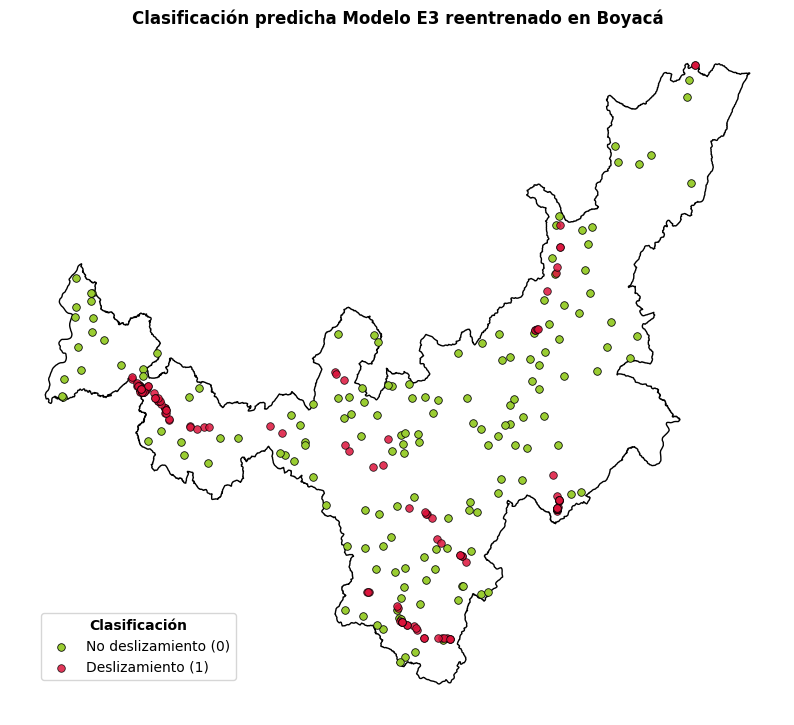

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 9))

# Mapa base
boyaca.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1)

# Separar clases
deslizamientos = test_map_boyaca[test_map_boyaca["prediccion"] == 1]
no_deslizamientos = test_map_boyaca[test_map_boyaca["prediccion"] == 0]

# Graficar cada clase con color específico
no_deslizamientos.plot(ax=ax, color="yellowgreen", markersize=30,edgecolor="black",
    linewidth=0.55, label="No deslizamiento (0)")

deslizamientos.plot(ax=ax, color="crimson", markersize=30,edgecolor="black",
    linewidth=0.55, alpha=0.85, label="Deslizamiento (1)")


# Leyenda personalizada
legend = ax.legend(
    title="Clasificación",
    loc="upper right",
    bbox_to_anchor=(0.30, 0.16)
)
legend.get_title().set_fontweight("bold")

# Título
ax.set_title("Clasificación predicha Modelo E3 reentrenado en Boyacá",fontsize=12, fontweight="bold")

# Quitar ejes
ax.set_axis_off()

plt.show()

### **Elaboración de un mapa continuo de predicción para fechas especificas de set de prueba**


En esta sección se plantea la generación de un mapa continuo de susceptibilidad para una fecha específica, lo cual representa un cambio metodológico respecto a fases previas del estudio, donde el análisis se realizó de manera puntual sobre ubicaciones discretas de deslizamientos y no deslizamientos. En este caso, el objetivo es extender la predicción a todo el territorio, permitiendo una representación espacial completa del fenómeno.

Para lograrlo, es necesario integrar información proveniente de imágenes satelitales, las cuales aportan variables dinámicas con variación temporal, fundamentales para caracterizar las condiciones del terreno en la fecha de análisis. Adicionalmente, se incorporan variables estáticas de carácter geomorfológico  que deben estar en formato ráster, debidamente alineadas espacialmente y estandarizadas a una misma resolución, en este caso de 30 metros.

De igual manera, las variables de precipitación acumulada, deben cumplir con las mismas condiciones de alineación espacial y resolución. Esto asegura que todas las variables utilizadas como entrada en el modelo sean comparables pixel a pixel.

En conjunto, este proceso permite construir una matriz espacial continua de variables predictoras, a partir de la cual el modelo de aprendizaje de máquina puede generar una superficie continua de probabilidad de ocurrencia de deslizamientos.

**AJUSTE DE VARIABLES HIDROCLIMATOLÓGICAS**

En primer lugar, se ajustan la variables hidroclimátologicas utilizadas en el modelo final:

**`['P0_evento', 'P1_excl', 'P5_excl', 'P30_excl', 'Humedad_T', 'Temp_T']`**

 De tal manera que queden alineados con el DEM (elevación) y así compartan el mismo sistema de referencia en este caso 9377 "Origen nacional", obtengan la misma resolución  de 30 m y que tengan los pixeles perfecftamente superpuestos.

In [ ]:
# =================================================
# AJUSTE DE PRECIPITACIÓN, HUMEDAD Y TEMPERATURA
# ALINEADAS A ELEVACIÓN
# =================================================

!pip -q install rasterio

import os
import glob
from datetime import datetime

import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
from google.colab import drive

# =========================================
# 1. MONTAR DRIVE
# =========================================
drive.mount('/content/drive')

# =========================================
# 2. PARÁMETROS DE ENTRADA
# =========================================

# Fechas objetivo del mapa continuo
fechas_objetivo = [ "2025-01-03", "2023-08-14", "2022-11-27","2024-07-04", "2022-01-03"] # Ajustar según necesidad
# Raster elevación
elevacion_path = "/content/drive/MyDrive/TESIS-BOYACA/MapaContinuo/Variables_Estaticas/Elevacion.tif"


# Carpetas fuente de humedad, temperatura trimestral y precpitación acumulativa excluyente
precip_dir = "/content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/PrecipitacionesAcumuladas"
humedad_real_dir = "/content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/HumedadTrimestral"
humedad_clim_dir = "/content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/ClimHumTrimestral"
temp_dir = "/content/drive/MyDrive/TESIS-BOYACA/Interpolaciones/TemperaturaTrimestral"

# Carpeta base donde se almacenarán los resultados
output_base_dir = "/content/drive/MyDrive/TESIS-BOYACA/MapaContinuo/Variables_Temporales/Hidroclimatologicas"


# =========================================
# 3. FUNCIONES AUXILIARES
# =========================================

# Busca todos los archivos que coincidad con el patrón y los ordena.
def buscar_unico(patron):
    files = sorted(glob.glob(patron))
    if len(files) == 0:
        return None
    return files[0]

#  Busca el archivo raster de precipitación a partir de una fecha específica, y
#  una variable de precipitación específica.

def encontrar_precipitacion(fecha_str, variable):
    if variable == "P0_evento":
        patron = os.path.join(precip_dir, f"*P0_evento*t0*{fecha_str}*.tif")
    elif variable == "P1_excl":
        patron = os.path.join(precip_dir, f"*P1_excl*t0*{fecha_str}*.tif")
    elif variable == "P5_excl":
        patron = os.path.join(precip_dir, f"*P5_excl*t0*{fecha_str}*.tif")
    elif variable == "P30_excl":
        patron = os.path.join(precip_dir, f"*P30_excl*t0*{fecha_str}*.tif")
    else:
        raise ValueError(f"Variable no reconocida: {variable}")

    return buscar_unico(patron)

#  Busca humedad del suelo a partir de año y trimestre.
def encontrar_humedad(year, tri):
    patron_real = os.path.join(humedad_real_dir, f"*humedad*{year}*T{tri}*.tif")
    f_real = buscar_unico(patron_real)
    if f_real is not None:
        return f_real, "real"

    patron_clim = os.path.join(humedad_clim_dir, f"*humedad*clim*T{tri}*.tif")
    f_clim = buscar_unico(patron_clim)
    if f_clim is not None:
        return f_clim, "climatologia"

    return None, "missing"

#  Busca temperatura del suelo a partir de año y trimestre.
def encontrar_temperatura(year, tri):
    patron = os.path.join(temp_dir, f"*temperatura*{year}*T{tri}*.tif")
    return buscar_unico(patron)


# Función para alinear un raster de entrada a parter del rater de referencia de "elevación"
# utilizando el resampleo bilinear para ajustar la resolución espacial.
def alinear_a_elevacion(src_path, ref_path, out_path, resampling=Resampling.bilinear):
    with rasterio.open(ref_path) as ref:
        ref_meta = ref.meta.copy()
        ref_crs = ref.crs
        ref_transform = ref.transform
        ref_width = ref.width
        ref_height = ref.height

    with rasterio.open(src_path) as src:
        src_data = src.read(1)
        src_transform = src.transform
        src_crs = src.crs
        src_nodata = src.nodata

        dst_data = np.full((ref_height, ref_width), np.nan, dtype=np.float32)

        reproject(
            source=src_data,
            destination=dst_data,
            src_transform=src_transform,
            src_crs=src_crs,
            src_nodata=src_nodata,
            dst_transform=ref_transform,
            dst_crs=ref_crs,
            dst_nodata=np.nan,
            resampling=resampling
        )

        out_meta = ref_meta.copy()
        out_meta.update({
            "driver": "GTiff",
            "height": ref_height,
            "width": ref_width,
            "transform": ref_transform,
            "crs": ref_crs,
            "count": 1,
            "dtype": "float32",
            "nodata": np.nan,
            "compress": "lzw"
        })

        with rasterio.open(out_path, "w", **out_meta) as dst:
            dst.write(dst_data, 1)

# Toma una variable raster, la alinea respecto al raster de referencia
# y la guarda con un nombre definido.

def procesar_variable(nombre_salida, src_path, ref_path, output_dir):
    out_path = os.path.join(output_dir, f"{nombre_salida}.tif")

    alinear_a_elevacion(
        src_path=src_path,
        ref_path=ref_path,
        out_path=out_path,
        resampling=Resampling.bilinear
    )

    return out_path

# =========================================
# 4. PROCESAMIENTO POR CADA FECHA
# =========================================

# Brinda información del proceso
for fecha_objetivo in fechas_objetivo:
    print("\n" + "="*60)
    print("Procesando fecha:", fecha_objetivo)

    fecha_dt = datetime.strptime(fecha_objetivo, "%Y-%m-%d")
    year = fecha_dt.year
    month = fecha_dt.month

    if month in [1, 2, 3]:
        tri = 1
    elif month in [4, 5, 6]:
        tri = 2
    elif month in [7, 8, 9]:
        tri = 3
    else:
        tri = 4

    # carpeta por fecha del evento
    nombre_carpeta = f"{fecha_objetivo.replace('-', '')}"
    output_dir = os.path.join(output_base_dir, nombre_carpeta)
    os.makedirs(output_dir, exist_ok=True)

    rutas_fuente = {}

    for var in ["P0_evento", "P1_excl", "P5_excl", "P30_excl"]:
        rutas_fuente[var] = encontrar_precipitacion(fecha_objetivo, var)

    ruta_humedad, tipo_humedad = encontrar_humedad(year, tri)
    rutas_fuente["Humedad_T"] = ruta_humedad

    rutas_fuente["Temp_T"] = encontrar_temperatura(year, tri)

    print("Tipo de humedad seleccionado:", tipo_humedad)

    rutas_salida = {}

    for var, src in rutas_fuente.items():
        if src is None:
            print(f"[ADVERTENCIA] No se encontró raster para {var} en {fecha_objetivo}")
            continue

        print(f"Procesando {var}")
        out_path = procesar_variable(
            nombre_salida=var,
            src_path=src,
            ref_path=elevacion_path,
            output_dir=output_dir
        )
        rutas_salida[var] = out_path

    # guardar resumen por fecha
    resumen_path = os.path.join(output_dir, "resumen_proceso.txt")
    with open(resumen_path, "w", encoding="utf-8") as f:
        f.write("RESUMEN DEL PROCESO\n")
        f.write("===================\n")
        f.write(f"Fecha objetivo: {fecha_objetivo}\n")
        f.write(f"Año: {year}\n")
        f.write(f"Trimestre: {tri}\n")
        f.write(f"Tipo de humedad: {tipo_humedad}\n")
        f.write(f"Raster patrón: {elevacion_path}\n")
        f.write(f"Carpeta de salida: {output_dir}\n\n")

        f.write("RASTERS FUENTE\n")
        f.write("--------------\n")
        for k, v in rutas_fuente.items():
            f.write(f"{k}: {v}\n")

        f.write("\nRASTERS GENERADOS\n")
        f.write("-----------------\n")
        for k, v in rutas_salida.items():
            f.write(f"{k}: {v}\n")

    print("Finalizado:", fecha_objetivo)
    print("Salida en:", output_dir)

print("\nProceso completo para todas las fechas.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Procesando fecha: 2025-01-03
Tipo de humedad seleccionado: real
Procesando P0_evento
Procesando P1_excl
Procesando P5_excl
Procesando P30_excl
Procesando Humedad_T
Procesando Temp_T
Finalizado: 2025-01-03
Salida en: /content/drive/MyDrive/TESIS-BOYACA/MapaContinuo/Variables_Temporales/Hidroclimatologicas/20250103

Procesando fecha: 2023-08-14
Tipo de humedad seleccionado: real
Procesando P0_evento
Procesando P1_excl
Procesando P5_excl
Procesando P30_excl
Procesando Humedad_T
Procesando Temp_T
Finalizado: 2023-08-14
Salida en: /content/drive/MyDrive/TESIS-BOYACA/MapaContinuo/Variables_Temporales/Hidroclimatologicas/20230814

Procesando fecha: 2022-11-27
Tipo de humedad seleccionado: real
Procesando P0_evento
Procesando P1_excl
Procesando P5_excl
Procesando P30_excl
Procesando Humedad_T
Procesando Temp_T
Finalizado: 2022-11-27
Salida en: /content/drive/MyDrive

**AJUSTE DE VARIABLES TEMPORALES DERIVADAS DE IMÁGENES SATELITALES**

En este caso se van a obtener las variables derivadas de imágenes satelitales "ópticas y de radar" resultantes de la identificación del mejor modelo. para ello es necesario realizar una conexión a través de la API con Google Earth Engine de

 **`EVI_mean_90d_30m', 'EVI_std_90d_30m', 'NDVI_mean_90d_30m', 'NDVI_std_90d_30m', 'NDWI_mean_90d_30m', 'NDWI_std_90d_30m', 'VV_mean_24d_30m', 'VV_std_24d_30m', 'VVminusVH_24d_30m'`**

 Para ello respecto a las imágenes satelitales se utilizan tanto imágenes provenientes de Landsat como  de sentinel. Se define que imagen utilizar de
 acuerdo a una fración de utibilidad, la que tenga mayor valor será seleccionada.

In [ ]:
# ============================================================
# BLOQUE 1. EXPORTACIÓN DESDE EARTH ENGINE
# SOLO PROCESA LO QUE REALMENTE HACE FALTA
# ============================================================

# =====================================
# Instalación de librerías
# =====================================
!pip -q install earthengine-api geemap geopandas rasterio shapely pyproj fiona numpy

import os
import ee
import geemap
import rasterio
import geopandas as gpd
import numpy as np

from rasterio.warp import transform_bounds
from rasterio.enums import Resampling
from google.colab import drive

# =====================================
# Montar Drive
# =====================================
drive.mount('/content/drive')

# =====================================
# Autenticación e inicialización GEE
# =====================================
ee.Authenticate()
ee.Initialize(project="ee-linapaolagarcia")
print("Google Earth Engine listo ✅")

# ============================================================
# PARÁMETROS GENERALES
# ============================================================

# Fechas objetivo para exportación
fechas_objetivo = [ "2025-01-03", "2023-08-14", "2022-11-27","2024-07-04", "2022-01-03"]

# Ruta del shapefile del área de estudio
shp_path = "/content/drive/MyDrive/TESIS-BOYACA/Depto/Boyaca.shp"

# Ruta del DEM de referencia
dem_tif_path = "/content/drive/MyDrive/TESIS-BOYACA/MapaContinuo/Variables_Estaticas/Elevacion.tif"

# Carpeta base temporal en Drive (nombre que usará GEE al exportar)
drive_export_root = "EXPORT_TEMPBOYACA"

# Ruta final REAL donde deben quedar los productos temporales
drive_export_root_local = "/content/drive/MyDrive/TESIS-BOYACA/MapaContinuo/Variables_Temporales/Imagenes"

# Parámetros de ventanas temporales
OPT_DAYS = 90
SAR_DAYS = 24

# Umbral mínimo de fracción válida para usar Sentinel-2
MIN_VALID = 0.20

# Escala para evaluar cobertura válida
VALID_SCALE = 120

# Valor de nodata en exportaciones
NODATA_OUT = -9999

# Crear carpeta base final si no existe
os.makedirs(drive_export_root_local, exist_ok=True)

# ============================================================
# LEER AOI DESDE SHAPEFILE
# ============================================================

# Leer shapefile con geopandas
gdf = gpd.read_file(shp_path)

# Si el shapefile no está en EPSG:4326, convertirlo
if gdf.crs is None:
    raise ValueError("El shapefile no tiene sistema de referencia definido.")

if gdf.crs.to_string() != "EPSG:4326":
    gdf = gdf.to_crs("EPSG:4326")

# Unificar geometrías
aoi_geom_shp = gdf.unary_union

# Convertir a geometría de Earth Engine
aoi = geemap.geopandas_to_ee(gdf)

print("AOI cargada correctamente ✅")

# ============================================================
# LEER DEM Y EXTRAER GRILLA DE REFERENCIA
# ============================================================

with rasterio.open(dem_tif_path) as dem_src:
    dem_crs = dem_src.crs
    dem_transform = dem_src.transform
    dem_bounds = dem_src.bounds
    dem_width = dem_src.width
    dem_height = dem_src.height
    dem_res = dem_src.res
    dem_nodata = dem_src.nodata

gee_crs = dem_crs.to_string()
gee_transform = [
    dem_transform.a,
    dem_transform.b,
    dem_transform.c,
    dem_transform.d,
    dem_transform.e,
    dem_transform.f
]

# Transformar extensión del DEM a coordenadas geográficas
bounds_wgs84 = transform_bounds(
    dem_crs,
    "EPSG:4326",
    dem_bounds.left,
    dem_bounds.bottom,
    dem_bounds.right,
    dem_bounds.top,
    densify_pts=21
)

minx, miny, maxx, maxy = bounds_wgs84

# Región de exportación para GEE
region_export = [[
    [minx, miny],
    [maxx, miny],
    [maxx, maxy],
    [minx, maxy],
    [minx, miny]
]]

print("DEM leído correctamente ✅")
print("CRS:", gee_crs)
print("Resolución:", dem_res)
print("Dimensiones:", dem_width, "x", dem_height)

# ============================================================
# FUNCIONES AUXILIARES DE ALINEACIÓN
# ============================================================

def align_to_dem_grid(img):
    return (
        img
        .resample("bilinear")
        .reproject(crs=gee_crs, crsTransform=gee_transform)
        .clip(aoi)
    )

def valid_fraction(img, geom, scale=120):
    valid = img.mask().reduce(ee.Reducer.min()).rename("valid")

    stats = valid.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=geom,
        scale=scale,
        maxPixels=1e13,
        bestEffort=True
    )

    val = stats.get("valid")
    return ee.Number(ee.Algorithms.If(val, val, 0))

# ============================================================
# PREPROCESAMIENTO DE SENTINEL-2
# ============================================================

def prep_sentinel2(img):
    qa = img.select("QA60")
    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11

    mask = (
        qa.bitwiseAnd(cloud_bit_mask).eq(0)
        .And(qa.bitwiseAnd(cirrus_bit_mask).eq(0))
    )

    blue = img.select("B2").multiply(0.0001)
    red  = img.select("B4").multiply(0.0001)
    nir  = img.select("B8").multiply(0.0001)
    sw1  = img.select("B11").multiply(0.0001)

    ndvi = nir.subtract(red).divide(nir.add(red)).rename("NDVI")
    ndwi = nir.subtract(sw1).divide(nir.add(sw1)).rename("NDWI")
    evi  = nir.subtract(red).multiply(2.5).divide(
        nir.add(red.multiply(6)).subtract(blue.multiply(7.5)).add(1)
    ).rename("EVI")

    return ee.Image.cat([evi, ndvi, ndwi]).updateMask(mask).copyProperties(img, img.propertyNames())

# ============================================================
# PREPROCESAMIENTO DE LANDSAT 8-9
# ============================================================

def prep_landsat89(img):
    qa = img.select("QA_PIXEL")

    mask = (
        qa.bitwiseAnd(1 << 1).eq(0)
        .And(qa.bitwiseAnd(1 << 2).eq(0))
        .And(qa.bitwiseAnd(1 << 3).eq(0))
        .And(qa.bitwiseAnd(1 << 4).eq(0))
    )

    blue = img.select("SR_B2").multiply(0.0000275).add(-0.2)
    red  = img.select("SR_B4").multiply(0.0000275).add(-0.2)
    nir  = img.select("SR_B5").multiply(0.0000275).add(-0.2)
    sw1  = img.select("SR_B6").multiply(0.0000275).add(-0.2)

    ndvi = nir.subtract(red).divide(nir.add(red)).rename("NDVI")
    ndwi = nir.subtract(sw1).divide(nir.add(sw1)).rename("NDWI")
    evi  = nir.subtract(red).multiply(2.5).divide(
        nir.add(red.multiply(6)).subtract(blue.multiply(7.5)).add(1)
    ).rename("EVI")

    return ee.Image.cat([evi, ndvi, ndwi]).updateMask(mask).copyProperties(img, img.propertyNames())

# ============================================================
# PREPROCESAMIENTO DE LANDSAT 5-7
# ============================================================

def prep_landsat57(img):
    qa = img.select("QA_PIXEL")

    mask = (
        qa.bitwiseAnd(1 << 1).eq(0)
        .And(qa.bitwiseAnd(1 << 2).eq(0))
        .And(qa.bitwiseAnd(1 << 3).eq(0))
        .And(qa.bitwiseAnd(1 << 4).eq(0))
    )

    blue = img.select("SR_B1").multiply(0.0000275).add(-0.2)
    red  = img.select("SR_B3").multiply(0.0000275).add(-0.2)
    nir  = img.select("SR_B4").multiply(0.0000275).add(-0.2)
    sw1  = img.select("SR_B5").multiply(0.0000275).add(-0.2)

    ndvi = nir.subtract(red).divide(nir.add(red)).rename("NDVI")
    ndwi = nir.subtract(sw1).divide(nir.add(sw1)).rename("NDWI")
    evi  = nir.subtract(red).multiply(2.5).divide(
        nir.add(red.multiply(6)).subtract(blue.multiply(7.5)).add(1)
    ).rename("EVI")

    return ee.Image.cat([evi, ndvi, ndwi]).updateMask(mask).copyProperties(img, img.propertyNames())

# ============================================================
# RESUMEN ÓPTICO
# ============================================================

def summarize_optical(col, aoi_geom):
    reducer = ee.Reducer.mean().combine(
        reducer2=ee.Reducer.stdDev(),
        sharedInputs=True
    )

    img = col.reduce(reducer).clip(aoi_geom)

    img = img.rename([
        "EVI_mean_90d_30m",
        "EVI_std_90d_30m",
        "NDVI_mean_90d_30m",
        "NDVI_std_90d_30m",
        "NDWI_mean_90d_30m",
        "NDWI_std_90d_30m"
    ])

    return align_to_dem_grid(img)

# ============================================================
# OBTENER ÍNDICES ÓPTICOS ALINEADOS
# ============================================================

def get_optical_indices_best_aligned(aoi_geom, fecha_objetivo, opt_days=90, min_valid=0.2):
    fecha_ee = ee.Date(fecha_objetivo)
    inicio = fecha_ee.advance(-opt_days, "day")

    col_s2 = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(aoi_geom)
        .filterDate(inicio, fecha_ee)
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 80))
        .map(prep_sentinel2)
    )

    col_l57 = (
        ee.ImageCollection("LANDSAT/LT05/C02/T1_L2")
        .merge(ee.ImageCollection("LANDSAT/LE07/C02/T1_L2"))
        .filterBounds(aoi_geom)
        .filterDate(inicio, fecha_ee)
        .map(prep_landsat57)
    )

    col_l89 = (
        ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
        .merge(ee.ImageCollection("LANDSAT/LC09/C02/T1_L2"))
        .filterBounds(aoi_geom)
        .filterDate(inicio, fecha_ee)
        .map(prep_landsat89)
    )

    col_ls = col_l57.merge(col_l89)

    n_s2 = col_s2.size()
    n_ls = col_ls.size()

    empty_img = (
        ee.Image.constant([0, 0, 0, 0, 0, 0])
        .rename([
            "EVI_mean_90d_30m",
            "EVI_std_90d_30m",
            "NDVI_mean_90d_30m",
            "NDVI_std_90d_30m",
            "NDWI_mean_90d_30m",
            "NDWI_std_90d_30m"
        ])
        .selfMask()
    )

    img_s2 = ee.Image(
        ee.Algorithms.If(n_s2.gt(0), summarize_optical(col_s2, aoi_geom), empty_img)
    )

    img_ls = ee.Image(
        ee.Algorithms.If(n_ls.gt(0), summarize_optical(col_ls, aoi_geom), empty_img)
    )

    frac_s2 = valid_fraction(img_s2, aoi_geom, scale=VALID_SCALE)
    frac_ls = valid_fraction(img_ls, aoi_geom, scale=VALID_SCALE)

    use_s2 = frac_s2.gte(min_valid)
    use_ls = frac_ls.gt(0)

    img_best = ee.Image(
        ee.Algorithms.If(
            use_s2,
            img_s2,
            ee.Algorithms.If(use_ls, img_ls, empty_img)
        )
    )

    src_best = ee.String(
        ee.Algorithms.If(
            use_s2,
            "s2",
            ee.Algorithms.If(use_ls, "landsat", "missing")
        )
    )

    return {
        "image": img_best,
        "src": src_best,
        "valid_frac_s2": frac_s2,
        "valid_frac_ls": frac_ls,
        "n_s2": n_s2,
        "n_ls": n_ls
    }

# ============================================================
# PREPROCESAMIENTO DE SENTINEL-1
# ============================================================

def prep_s1(img):
    vv = img.select("VV")
    vh = img.select("VH")
    vv_minus_vh = vv.subtract(vh).rename("VVminusVH")

    return ee.Image.cat([
        vv.rename("VV"),
        vv_minus_vh
    ]).copyProperties(img, img.propertyNames())

# ============================================================
# OBTENER ÍNDICES RADAR ALINEADOS
# ============================================================

def get_radar_indices_aligned(aoi_geom, fecha_objetivo, sar_days=24):
    fecha_ee = ee.Date(fecha_objetivo)
    inicio = fecha_ee.advance(-sar_days, "day")

    col = (
        ee.ImageCollection("COPERNICUS/S1_GRD")
        .filterBounds(aoi_geom)
        .filterDate(inicio, fecha_ee)
        .filter(ee.Filter.eq("instrumentMode", "IW"))
        .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
        .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))
        .map(prep_s1)
    )

    n_imgs = col.size()

    empty_img = (
        ee.Image.constant([0, 0, 0])
        .rename([
            "VV_mean_24d_30m",
            "VV_std_24d_30m",
            "VVminusVH_24d_30m"
        ])
        .selfMask()
    )

    img = ee.Image(
        ee.Algorithms.If(
            n_imgs.gt(0),
            ee.Image.cat([
                col.select("VV").mean().rename("VV_mean_24d_30m"),
                col.select("VV").reduce(ee.Reducer.stdDev()).rename("VV_std_24d_30m"),
                col.select("VVminusVH").mean().rename("VVminusVH_24d_30m")
            ]),
            empty_img
        )
    )

    return {
        "image": align_to_dem_grid(img),
        "n_imgs": n_imgs
    }

# ============================================================
# BLOQUE PRINCIPAL:
# VERIFICAR NECESIDAD REAL ANTES DE USAR GEE
# ============================================================

for fecha_objetivo in fechas_objetivo:
    print("\n" + "=" * 75)
    print("Procesando fecha:", fecha_objetivo)

    fecha_txt = fecha_objetivo.replace("-", "")
    carpeta_temporal_gee = f"{drive_export_root}_{fecha_txt}"

    # ---------------------------------------------------
    # Ruta final real donde queda el flujo del proyecto
    # ---------------------------------------------------
    carpeta_final = os.path.join(drive_export_root_local, fecha_txt)
    os.makedirs(carpeta_final, exist_ok=True)

    # ---------------------------------------------------
    # Productos a verificar en la carpeta final
    # ---------------------------------------------------
    ruta_opt = os.path.join(carpeta_final, "OPTICAS.tif")
    ruta_rad = os.path.join(carpeta_final, "RADAR.tif")
    ruta_opt_mask = os.path.join(carpeta_final, "OPTICAS_mask.tif")
    ruta_rad_mask = os.path.join(carpeta_final, "RADAR_mask.tif")

    existe_opt = os.path.exists(ruta_opt)
    existe_rad = os.path.exists(ruta_rad)
    existe_opt_mask = os.path.exists(ruta_opt_mask)
    existe_rad_mask = os.path.exists(ruta_rad_mask)

    print(f"OPTICAS.tif existe: {existe_opt}")
    print(f"RADAR.tif existe: {existe_rad}")
    print(f"OPTICAS_mask.tif existe: {existe_opt_mask}")
    print(f"RADAR_mask.tif existe: {existe_rad_mask}")

    # ---------------------------------------------------
    # Definir necesidad real antes de llamar GEE
    # ---------------------------------------------------
    necesita_opt = False
    necesita_rad = False

    # Si ya existe el mask final, no hace falta exportar ópticas
    if existe_opt_mask:
        necesita_opt = False
    elif existe_opt:
        necesita_opt = False
    else:
        necesita_opt = True

    # Si ya existe el mask final, no hace falta exportar radar
    if existe_rad_mask:
        necesita_rad = False
    elif existe_rad:
        necesita_rad = False
    else:
        necesita_rad = True

    print(f"¿Necesita exportar OPTICAS desde GEE?: {necesita_opt}")
    print(f"¿Necesita exportar RADAR desde GEE?: {necesita_rad}")

    # Si no necesita nada, se omite completamente esta fecha
    if not necesita_opt and not necesita_rad:
        print("No se requiere procesamiento en GEE para esta fecha ✅")
        continue

    # ==================================================
    # EXPORTAR ÓPTICAS SOLO SI REALMENTE HACE FALTA
    # ==================================================
    if necesita_opt:
        print("Se requiere exportar OPTICAS desde GEE...")

        resultado_opt = get_optical_indices_best_aligned(
            aoi_geom=aoi,
            fecha_objetivo=fecha_objetivo,
            opt_days=OPT_DAYS,
            min_valid=MIN_VALID
        )

        info_opt = ee.Dictionary({
            "src": resultado_opt["src"],
            "valid_frac_s2": resultado_opt["valid_frac_s2"],
            "valid_frac_ls": resultado_opt["valid_frac_ls"],
            "n_s2": resultado_opt["n_s2"],
            "n_ls": resultado_opt["n_ls"]
        }).getInfo()

        print("Ópticas -> imágenes Sentinel-2:", info_opt["n_s2"])
        print("Ópticas -> imágenes Landsat:", info_opt["n_ls"])
        print("Ópticas -> fracción válida S2:", info_opt["valid_frac_s2"])
        print("Ópticas -> fracción válida Landsat:", info_opt["valid_frac_ls"])
        print("Ópticas -> fuente seleccionada:", info_opt["src"])

        task_opt = ee.batch.Export.image.toDrive(
            image=ee.Image(resultado_opt["image"]).unmask(NODATA_OUT),
            description=f"OPTICAS_{fecha_txt}",
            folder=carpeta_temporal_gee,
            fileNamePrefix="OPTICAS",
            region=region_export,
            crs=gee_crs,
            crsTransform=gee_transform,
            maxPixels=1e13,
            fileFormat="GeoTIFF",
            formatOptions={"noData": NODATA_OUT}
        )
        task_opt.start()
        print("Exportación de OPTICAS enviada ✅")
    else:
        print("OPTICAS no se procesa en GEE porque ya existe en el flujo final ✅")

    # ==================================================
    # EXPORTAR RADAR SOLO SI REALMENTE HACE FALTA
    # ==================================================
    if necesita_rad:
        print("Se requiere exportar RADAR desde GEE...")

        resultado_rad = get_radar_indices_aligned(
            aoi_geom=aoi,
            fecha_objetivo=fecha_objetivo,
            sar_days=SAR_DAYS
        )

        info_rad = ee.Dictionary({
            "n_imgs": resultado_rad["n_imgs"]
        }).getInfo()

        print("Radar -> número de imágenes Sentinel-1:", info_rad["n_imgs"])

        task_rad = ee.batch.Export.image.toDrive(
            image=ee.Image(resultado_rad["image"]).unmask(NODATA_OUT),
            description=f"RADAR_{fecha_txt}",
            folder=carpeta_temporal_gee,
            fileNamePrefix="RADAR",
            region=region_export,
            crs=gee_crs,
            crsTransform=gee_transform,
            maxPixels=1e13,
            fileFormat="GeoTIFF",
            formatOptions={"noData": NODATA_OUT}
        )
        task_rad.start()
        print("Exportación de RADAR enviada ✅")
    else:
        print("RADAR no se procesa en GEE porque ya existe en el flujo final ✅")

print("\nVerificación completada ✅")
print("Solo se llamó a GEE cuando realmente hacía falta.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 59.2 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Earth Engine listo ✅


/tmp/ipykernel_926/3547361558.py:84: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  aoi_geom_shp = gdf.unary_union


AOI cargada correctamente ✅
DEM leído correctamente ✅
CRS: PROJCS["MAGNA-SIRGAS 2018 / Origen-Nacional",GEOGCS["MAGNA-SIRGAS 2018",DATUM["Marco_Geocentrico_Nacional_de_Referencia_2018",SPHEROID["GRS 1980",6378137,298.257222101004,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1329"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","20046"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",4],PARAMETER["central_meridian",-73],PARAMETER["scale_factor",0.9992],PARAMETER["false_easting",5000000],PARAMETER["false_northing",2000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","9377"]]
Resolución: (30.0, 30.0)
Dimensiones: 10117 x 8901

Procesando fecha: 2025-01-03
OPTICAS.tif existe: True
RADAR.tif existe: True
OPTICAS_mask.tif existe: True
RADAR_mask.tif existe: True
¿Necesita exportar OPTICAS desde GEE?: False
¿Necesita exportar RADAR desde GEE?: False
No se requiere pro

In [ ]:
# ============================================================
# BLOQUE 2. MOVER LOS ARCHIVOS A LA RUTA FINAL
# Y MOSAICAR SI GEE LOS PARTIÓ EN VARIOS TILES
# Ejecutar cuando los .tif ya existan en las carpetas temporales
# ============================================================

# Cuando los .tif ya hayan sido generados en las carpetas
# temporales de GEE se mueven a la carpeta donde se quiere
# que queden definitivamente.
#
# Este bloque ahora:
# 1. verifica si la carpeta temporal existe
# 2. detecta si GEE exportó un solo archivo o varios tiles
# 3. si hay varios tiles, los mosaica en un solo archivo
# 4. guarda finalmente:
#       - OPTICAS.tif
#       - RADAR.tif
# 5. no sobrescribe innecesariamente
# 6. elimina la carpeta temporal solo si quedó vacía

import os
import glob
import shutil
import rasterio

from rasterio.merge import merge

fechas_objetivo = ["2025-01-03", "2023-08-14", "2022-11-27","2024-07-04", "2022-01-03"]

drive_export_root = "EXPORT_TEMPBOYACA"
drive_export_root_local = "/content/drive/MyDrive/TESIS-BOYACA/MapaContinuo/Variables_Temporales/Imagenes"

os.makedirs(drive_export_root_local, exist_ok=True)

def crear_mosaico(archivos_entrada, archivo_salida):
    """
    Une varios tiles .tif en un solo raster final.
    """
    srcs = [rasterio.open(fp) for fp in archivos_entrada]

    mosaico, out_transform = merge(srcs)

    out_meta = srcs[0].meta.copy()
    out_meta.update({
        "driver": "GTiff",
        "height": mosaico.shape[1],
        "width": mosaico.shape[2],
        "transform": out_transform,
        "count": mosaico.shape[0],
        "compress": "lzw"
    })

    # Conservar nombres de bandas si existen
    band_names = list(srcs[0].descriptions)
    band_names = [
        band_names[i] if i < len(band_names) and band_names[i] not in [None, ""]
        else f"Band{i+1}"
        for i in range(mosaico.shape[0])
    ]

    with rasterio.open(archivo_salida, "w", **out_meta) as dst:
        dst.write(mosaico)
        for i, nombre in enumerate(band_names, start=1):
            dst.set_band_description(i, nombre)

    for src in srcs:
        src.close()

    print("Mosaico creado:", archivo_salida)

for fecha_objetivo in fechas_objetivo:
    fecha_txt = fecha_objetivo.replace("-", "")

    # Carpeta temporal creada por GEE en MyDrive
    carpeta_origen = f"/content/drive/MyDrive/{drive_export_root}_{fecha_txt}"

    # Carpeta final real del flujo de trabajo
    carpeta_destino = os.path.join(drive_export_root_local, fecha_txt)
    os.makedirs(carpeta_destino, exist_ok=True)

    # Rutas esperadas finales
    ruta_opt_destino = os.path.join(carpeta_destino, "OPTICAS.tif")
    ruta_rad_destino = os.path.join(carpeta_destino, "RADAR.tif")

    existe_opt_destino = os.path.exists(ruta_opt_destino)
    existe_rad_destino = os.path.exists(ruta_rad_destino)

    print("\n" + "=" * 75)
    print("Procesando fecha:", fecha_objetivo)
    print("Carpeta temporal:", carpeta_origen)
    print("Carpeta final:", carpeta_destino)
    print(f"OPTICAS.tif ya existe en destino: {existe_opt_destino}")
    print(f"RADAR.tif ya existe en destino: {existe_rad_destino}")

    # --------------------------------------------------------
    # Si la carpeta temporal no existe, no hay nada que mover
    # --------------------------------------------------------
    if not os.path.exists(carpeta_origen):
        print("No existe la carpeta temporal. No hay archivos para mover.")
        continue

    archivos = os.listdir(carpeta_origen)

    if len(archivos) == 0:
        print("La carpeta temporal existe pero está vacía.")
        continue

    # --------------------------------------------------------
    # DETECTAR ARCHIVOS DE ÓPTICAS
    # --------------------------------------------------------
    if not existe_opt_destino:
        archivos_opt = sorted(glob.glob(os.path.join(carpeta_origen, "OPTICAS*.tif")))

        if len(archivos_opt) == 0:
            print("No se encontraron archivos de OPTICAS en la carpeta temporal.")
        elif len(archivos_opt) == 1:
            shutil.move(archivos_opt[0], ruta_opt_destino)
            print("OPTICAS movido directamente a:", ruta_opt_destino)
        else:
            print("OPTICAS llegó en varios tiles. Se generará mosaico...")
            crear_mosaico(archivos_opt, ruta_opt_destino)

            # Eliminar tiles después del mosaico
            for fp in archivos_opt:
                if os.path.exists(fp):
                    os.remove(fp)
                    print("Tile eliminado:", os.path.basename(fp))
    else:
        print("OPTICAS.tif ya existe en destino. No se mueve ni mosaica nuevamente.")

    # --------------------------------------------------------
    # DETECTAR ARCHIVOS DE RADAR
    # --------------------------------------------------------
    if not existe_rad_destino:
        archivos_rad = sorted(glob.glob(os.path.join(carpeta_origen, "RADAR*.tif")))

        if len(archivos_rad) == 0:
            print("No se encontraron archivos de RADAR en la carpeta temporal.")
        elif len(archivos_rad) == 1:
            shutil.move(archivos_rad[0], ruta_rad_destino)
            print("RADAR movido directamente a:", ruta_rad_destino)
        else:
            print("RADAR llegó en varios tiles. Se generará mosaico...")
            crear_mosaico(archivos_rad, ruta_rad_destino)

            # Eliminar tiles después del mosaico
            for fp in archivos_rad:
                if os.path.exists(fp):
                    os.remove(fp)
                    print("Tile eliminado:", os.path.basename(fp))
    else:
        print("RADAR.tif ya existe en destino. No se mueve ni mosaica nuevamente.")

    # --------------------------------------------------------
    # Intentar eliminar carpeta temporal solo si quedó vacía
    # --------------------------------------------------------
    try:
        restos = os.listdir(carpeta_origen)
        if len(restos) == 0:
            os.rmdir(carpeta_origen)
            print("Carpeta temporal eliminada:", carpeta_origen)
        else:
            print("La carpeta temporal no quedó vacía; contenido restante:", restos)
    except Exception as e:
        print("No se pudo eliminar la carpeta temporal:", str(e))

print("\nMovimiento / mosaico finalizado ✅")


Procesando fecha: 2025-01-03
Carpeta temporal: /content/drive/MyDrive/EXPORT_TEMPBOYACA_20250103
Carpeta final: /content/drive/MyDrive/TESIS-BOYACA/MapaContinuo/Variables_Temporales/Imagenes/20250103
OPTICAS.tif ya existe en destino: True
RADAR.tif ya existe en destino: True
No existe la carpeta temporal. No hay archivos para mover.

Procesando fecha: 2023-08-14
Carpeta temporal: /content/drive/MyDrive/EXPORT_TEMPBOYACA_20230814
Carpeta final: /content/drive/MyDrive/TESIS-BOYACA/MapaContinuo/Variables_Temporales/Imagenes/20230814
OPTICAS.tif ya existe en destino: True
RADAR.tif ya existe en destino: True
No existe la carpeta temporal. No hay archivos para mover.

Procesando fecha: 2022-11-27
Carpeta temporal: /content/drive/MyDrive/EXPORT_TEMPBOYACA_20221127
Carpeta final: /content/drive/MyDrive/TESIS-BOYACA/MapaContinuo/Variables_Temporales/Imagenes/20221127
OPTICAS.tif ya existe en destino: True
RADAR.tif ya existe en destino: True
No existe la carpeta temporal. No hay archivos para

In [ ]:
# ============================================================
# BLOQUE 3. ALINEAR Y ENMASCARAR CON EL DEM
# SOLO SI LOS PRODUCTOS FINALES TODAVÍA NO EXISTEN
# ============================================================

# En esta etapa se busca que las imágenes queden correctamente
# alineadas con el raster de referencia, en este caso la elevación (DEM).
#
# Este bloque:
# 1. toma OPTICAS.tif y RADAR.tif ya unificados
# 2. los remuestrea y enmascara con el DEM
# 3. conserva nombres de bandas
# 4. solo genera:
#       - OPTICAS_mask.tif
#       - RADAR_mask.tif
#    si todavía no existen

import os
import rasterio
import numpy as np

from rasterio.warp import reproject, Resampling

fechas_objetivo = ["2025-01-03", "2023-08-14", "2022-11-27","2024-07-04", "2022-01-03"]

dem_tif_path = "/content/drive/MyDrive/TESIS-BOYACA/MapaContinuo/Variables_Estaticas/Elevacion.tif"
drive_export_root_local = "/content/drive/MyDrive/TESIS-BOYACA/MapaContinuo/Variables_Temporales/Imagenes"
NODATA_OUT = -9999

def crs_equivalentes_flexible(crs_raster, crs_dem):
    if crs_raster is None or crs_dem is None:
        return False

    raster_str = str(crs_raster).upper()
    dem_str = str(crs_dem).upper()

    if raster_str == dem_str:
        return True

    if "9377" in raster_str and "9377" in dem_str:
        return True

    return False

def remuestrear_y_enmascarar_con_dem(
    raster_entrada,
    dem_referencia,
    raster_salida,
    nodata_salida=-9999,
    resampling=Resampling.bilinear
):
    """
    Reencaja el raster de entrada a la malla exacta del DEM,
    aplica la máscara del DEM y conserva los nombres de bandas.
    """

    with rasterio.open(dem_referencia) as dem_src:
        dem_mask = dem_src.read_masks(1) > 0
        dem_profile = dem_src.profile.copy()
        dem_crs = dem_src.crs
        dem_transform = dem_src.transform
        dem_width = dem_src.width
        dem_height = dem_src.height

    with rasterio.open(raster_entrada) as src:
        if not crs_equivalentes_flexible(src.crs, dem_crs):
            raise ValueError(
                f"CRS diferente entre DEM y raster:\nDEM={dem_crs}\nRaster={src.crs}"
            )

        src_count = src.count

        # Leer nombres de bandas
        band_names = list(src.descriptions)

        # Si no existen nombres, crear genéricos
        if band_names is None or len(band_names) == 0:
            band_names = [f"Band{i}" for i in range(1, src_count + 1)]

        # Si vienen vacíos o None, rellenar
        band_names = [
            band_names[i] if i < len(band_names) and band_names[i] not in [None, ""]
            else f"Band{i+1}"
            for i in range(src_count)
        ]

        destino = np.full(
            (src_count, dem_height, dem_width),
            nodata_salida,
            dtype=np.float32
        )

        for i in range(1, src_count + 1):
            reproject(
                source=rasterio.band(src, i),
                destination=destino[i - 1],
                src_transform=src.transform,
                src_crs=src.crs,
                src_nodata=src.nodata,
                dst_transform=dem_transform,
                dst_crs=dem_crs,
                dst_nodata=nodata_salida,
                resampling=resampling
            )

    # Aplicar máscara del DEM
    for i in range(destino.shape[0]):
        banda = destino[i]
        banda[~dem_mask] = nodata_salida
        destino[i] = banda

    out_profile = dem_profile.copy()
    out_profile.update(
        driver="GTiff",
        height=dem_height,
        width=dem_width,
        transform=dem_transform,
        crs=dem_crs,
        count=destino.shape[0],
        dtype="float32",
        nodata=nodata_salida,
        compress="lzw"
    )

    with rasterio.open(raster_salida, "w", **out_profile) as dst:
        dst.write(destino.astype(np.float32))

        # Escribir descripciones de bandas
        for idx, nombre in enumerate(band_names, start=1):
            dst.set_band_description(idx, nombre)

    print("Raster ajustado, enmascarado y con nombres conservados:", raster_salida)
    print("Nombres de bandas:", band_names)

for fecha_objetivo in fechas_objetivo:
    fecha_txt = fecha_objetivo.replace("-", "")
    carpeta_fecha = os.path.join(drive_export_root_local, fecha_txt)

    raster_opt = os.path.join(carpeta_fecha, "OPTICAS.tif")
    raster_rad = os.path.join(carpeta_fecha, "RADAR.tif")

    salida_opt = os.path.join(carpeta_fecha, "OPTICAS_mask.tif")
    salida_rad = os.path.join(carpeta_fecha, "RADAR_mask.tif")

    print("\n" + "=" * 75)
    print("Procesando carpeta:", carpeta_fecha)

    if not os.path.exists(carpeta_fecha):
        print("No existe la carpeta de la fecha:", carpeta_fecha)
        continue

    # --------------------------------------------------------
    # Procesar ÓPTICAS solo si hace falta
    # --------------------------------------------------------
    if os.path.exists(salida_opt):
        print("OPTICAS_mask.tif ya existe. No se vuelve a generar ✅")
    else:
        if os.path.exists(raster_opt):
            remuestrear_y_enmascarar_con_dem(
                raster_entrada=raster_opt,
                dem_referencia=dem_tif_path,
                raster_salida=salida_opt,
                nodata_salida=NODATA_OUT,
                resampling=Resampling.bilinear
            )
        else:
            print("No existe OPTICAS.tif, por lo tanto no se puede generar OPTICAS_mask.tif")

    # --------------------------------------------------------
    # Procesar RADAR solo si hace falta
    # --------------------------------------------------------
    if os.path.exists(salida_rad):
        print("RADAR_mask.tif ya existe. No se vuelve a generar ✅")
    else:
        if os.path.exists(raster_rad):
            remuestrear_y_enmascarar_con_dem(
                raster_entrada=raster_rad,
                dem_referencia=dem_tif_path,
                raster_salida=salida_rad,
                nodata_salida=NODATA_OUT,
                resampling=Resampling.bilinear
            )
        else:
            print("No existe RADAR.tif, por lo tanto no se puede generar RADAR_mask.tif")

print("\nProceso finalizado ✅")
print("Usa como productos finales:")
print("- OPTICAS_mask.tif")
print("- RADAR_mask.tif")


Procesando carpeta: /content/drive/MyDrive/TESIS-BOYACA/MapaContinuo/Variables_Temporales/Imagenes/20250103
OPTICAS_mask.tif ya existe. No se vuelve a generar ✅
RADAR_mask.tif ya existe. No se vuelve a generar ✅

Procesando carpeta: /content/drive/MyDrive/TESIS-BOYACA/MapaContinuo/Variables_Temporales/Imagenes/20230814
OPTICAS_mask.tif ya existe. No se vuelve a generar ✅
RADAR_mask.tif ya existe. No se vuelve a generar ✅

Procesando carpeta: /content/drive/MyDrive/TESIS-BOYACA/MapaContinuo/Variables_Temporales/Imagenes/20221127
OPTICAS_mask.tif ya existe. No se vuelve a generar ✅
RADAR_mask.tif ya existe. No se vuelve a generar ✅

Procesando carpeta: /content/drive/MyDrive/TESIS-BOYACA/MapaContinuo/Variables_Temporales/Imagenes/20240704
OPTICAS_mask.tif ya existe. No se vuelve a generar ✅
RADAR_mask.tif ya existe. No se vuelve a generar ✅

Procesando carpeta: /content/drive/MyDrive/TESIS-BOYACA/MapaContinuo/Variables_Temporales/Imagenes/20220103
OPTICAS_mask.tif ya existe. No se vuelv

**Generación del Stack con vaariables requeridas**

En esta sección se bujsca unir todas las variables a partir de un Stack , con la finalidad de ejecutar el mejor modelo.

In [ ]:
!pip -q install earthengine-api geemap geopandas fiona pyproj shapely pycrs

import os
import ee
import geemap
import geopandas as gpd
from google.colab import drive

# =============================================
# 1. MONTAR DRIVE E INICIALIZAR EARTH ENGINE
# =============================================
drive.mount('/content/drive')


  Preparing metadata (setup.py) ... done
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import gc
import rasterio
import numpy as np

from rasterio.warp import reproject, Resampling

# =============
# PARÁMETROS
# =============

fechas_objetivo = ["2025-01-03", "2023-08-14", "2022-11-27","2024-07-04", "2022-01-03"]

ruta_base_temporales = "/content/drive/MyDrive/TESIS-BOYACA/MapaContinuo/Variables_Temporales/Imagenes"
ruta_base_estaticas = "/content/drive/MyDrive/TESIS-BOYACA/MapaContinuo/Variables_Estaticas"
ruta_base_hidro = "/content/drive/MyDrive/TESIS-BOYACA/MapaContinuo/Variables_Temporales/Hidroclimatologicas"
ruta_stacks = "/content/drive/MyDrive/TESIS-BOYACA/MapaContinuo/Stacks"

os.makedirs(ruta_stacks, exist_ok=True)

NODATA_OUT = -9999.0

# =============================
# ORDEN EXACTO DEL MODELO
# =============================

orden_variables_modelo = [
    "P0_evento",
    "P1_excl",
    "P5_excl",
    "P30_excl",
    "Humedad_T",
    "Temp_T",
    "Dist_vias",
    "Dist_DD",
    "Dist_Falla",
    "Elevacion",
    "CurvaturaN",
    "CurvaturaT",
    "TWI",
    "Eastness",
    "Northness",
    "Pendiente",
    "Geologia_U_2",
    "Geologia_U_3",
    "Geologia_U_5",
    "Geologia_U_6",
    "Geologia_U_7",
    "Paisaje_2",
    "Paisaje_3",
    "Paisaje_4",
    "Paisaje_5",
    "Paisaje_6",
    "Paisaje_7",
    "EVI_mean_90d_30m",
    "EVI_std_90d_30m",
    "NDVI_mean_90d_30m",
    "NDVI_std_90d_30m",
    "NDWI_mean_90d_30m",
    "NDWI_std_90d_30m",
    "VV_mean_24d_30m",
    "VV_std_24d_30m",
    "VVminusVH_24d_30m"
]

# ============================================================
# MAPEOS
# ============================================================
mapa_estaticas = {
    "Dist_vias": os.path.join(ruta_base_estaticas, "Dist_vias.tif"),
    "Dist_DD": os.path.join(ruta_base_estaticas, "Dist_DD.tif"),
    "Dist_Falla": os.path.join(ruta_base_estaticas, "Dist_Falla.tif"),
    "Elevacion": os.path.join(ruta_base_estaticas, "Elevacion.tif"),
    "CurvaturaN": os.path.join(ruta_base_estaticas, "CurvaturaN.tif"),
    "CurvaturaT": os.path.join(ruta_base_estaticas, "CurvaturaT.tif"),
    "TWI": os.path.join(ruta_base_estaticas, "TWI.tif"),
    "Eastness": os.path.join(ruta_base_estaticas, "Eastness.tif"),
    "Northness": os.path.join(ruta_base_estaticas, "Northness.tif"),
    "Pendiente": os.path.join(ruta_base_estaticas, "Pendiente.tif"),
    "Geologia_U_2": os.path.join(ruta_base_estaticas, "Geologia_U_2.tif"),
    "Geologia_U_3": os.path.join(ruta_base_estaticas, "Geologia_U_3.tif"),
    "Geologia_U_5": os.path.join(ruta_base_estaticas, "Geologia_U_5.tif"),
    "Geologia_U_6": os.path.join(ruta_base_estaticas, "Geologia_U_6.tif"),
    "Geologia_U_7": os.path.join(ruta_base_estaticas, "Geologia_U_7.tif"),
    "Paisaje_2": os.path.join(ruta_base_estaticas, "Paisaje_2.tif"),
    "Paisaje_3": os.path.join(ruta_base_estaticas, "Paisaje_3.tif"),
    "Paisaje_4": os.path.join(ruta_base_estaticas, "Paisaje_4.tif"),
    "Paisaje_5": os.path.join(ruta_base_estaticas, "Paisaje_5.tif"),
    "Paisaje_6": os.path.join(ruta_base_estaticas, "Paisaje_6.tif"),
    "Paisaje_7": os.path.join(ruta_base_estaticas, "Paisaje_7.tif"),
}

mapa_hidro_archivos = {
    "P0_evento": "P0_evento.tif",
    "P1_excl": "P1_excl.tif",
    "P5_excl": "P5_excl.tif",
    "P30_excl": "P30_excl.tif",
    "Humedad_T": "Humedad_T.tif",
    "Temp_T": "Temp_T.tif"
}

bandas_opticas_esperadas = [
    "EVI_mean_90d_30m",
    "EVI_std_90d_30m",
    "NDVI_mean_90d_30m",
    "NDVI_std_90d_30m",
    "NDWI_mean_90d_30m",
    "NDWI_std_90d_30m"
]

bandas_radar_esperadas = [
    "VV_mean_24d_30m",
    "VV_std_24d_30m",
    "VVminusVH_24d_30m"
]

# ============================================================
# FUNCIONES AUXILIARES
# ============================================================

# Verifica los sistemas de referencia para que sean
# Compatibles.
def crs_equivalentes_flexible(crs1, crs2):
    if crs1 is None or crs2 is None:
        return False
    s1 = str(crs1).upper()
    s2 = str(crs2).upper()
    return s1 == s2 or ("9377" in s1 and "9377" in s2)

def transform_equivalente(t1, t2, tol=1e-6):
    return all(abs(a - b) <= tol for a, b in zip(tuple(t1), tuple(t2)))

def leer_banda_por_nombre(ruta_raster, nombre_banda):
    with rasterio.open(ruta_raster) as src:
        descripciones = list(src.descriptions)
        descripciones = [
            descripciones[i] if i < len(descripciones) and descripciones[i] not in [None, ""]
            else f"Band{i+1}"
            for i in range(src.count)
        ]

        if nombre_banda not in descripciones:
            raise ValueError(
                f"La banda {nombre_banda} no existe en {ruta_raster}. "
                f"Bandas encontradas: {descripciones}"
            )

        idx = descripciones.index(nombre_banda) + 1
        arr = src.read(idx).astype(np.float32)
        return arr

def leer_y_ajustar_una_banda(
    ruta_raster,
    ref_crs,
    ref_transform,
    ref_width,
    ref_height,
    nodata_salida=-9999.0,
    resampling=Resampling.bilinear,
    band_index=1
):
    with rasterio.open(ruta_raster) as src:
        mismo_crs = crs_equivalentes_flexible(src.crs, ref_crs)
        mismo_transform = transform_equivalente(src.transform, ref_transform, tol=1e-6)
        mismas_dimensiones = (src.width == ref_width and src.height == ref_height)

        if mismo_crs and mismo_transform and mismas_dimensiones:
            return src.read(band_index).astype(np.float32)

        destino = np.full((ref_height, ref_width), nodata_salida, dtype=np.float32)

        reproject(
            source=rasterio.band(src, band_index),
            destination=destino,
            src_transform=src.transform,
            src_crs=src.crs,
            src_nodata=src.nodata,
            dst_transform=ref_transform,
            dst_crs=ref_crs,
            dst_nodata=nodata_salida,
            resampling=resampling
        )

        return destino

# ============================================================
# CREAR STACKS BANDA POR BANDA
# ============================================================

# Se crea un stack por cada fecha.
# Ahora, si el stack final ya existe, no se vuelve a procesar.


for fecha in fechas_objetivo:
    fecha_txt = fecha.replace("-", "")
    carpeta_fecha = os.path.join(ruta_base_temporales, fecha_txt)
    carpeta_hidro_fecha = os.path.join(ruta_base_hidro, fecha_txt)

    ruta_opt = os.path.join(carpeta_fecha, "OPTICAS_mask.tif")
    ruta_rad = os.path.join(carpeta_fecha, "RADAR_mask.tif")
    ruta_salida = os.path.join(ruta_stacks, f"VARIABLES_MODELO_{fecha_txt}.tif")

    print("\n" + "=" * 80)
    print("Procesando fecha:", fecha_txt)

    # --------------------------------------------------------
    # Si el stack final ya existe, no se vuelve a crear
    # --------------------------------------------------------
    if os.path.exists(ruta_salida):
        print("El stack ya existe. No se reprocesa:", ruta_salida)
        continue

    # --------------------------------------------------------
    # Verificar existencia de insumos necesarios
    # --------------------------------------------------------
    if not os.path.exists(ruta_opt):
        print("No existe:", ruta_opt)
        continue
    if not os.path.exists(ruta_rad):
        print("No existe:", ruta_rad)
        continue
    if not os.path.exists(carpeta_hidro_fecha):
        print("No existe la carpeta hidro:", carpeta_hidro_fecha)
        continue


    with rasterio.open(ruta_opt) as ref:
        ref_crs = ref.crs
        ref_transform = ref.transform
        ref_width = ref.width
        ref_height = ref.height
        ref_profile = ref.profile.copy()

    out_profile = ref_profile.copy()
    out_profile.update(
        driver="GTiff",
        count=len(orden_variables_modelo),
        dtype="float32",
        nodata=NODATA_OUT,
        compress="lzw"
    )

    with rasterio.open(ruta_salida, "w", **out_profile) as dst:
        for banda_idx, nombre_var in enumerate(orden_variables_modelo, start=1):
            print(f"  Escribiendo banda {banda_idx}: {nombre_var}")

            # Hidroclimatológicas
            if nombre_var in mapa_hidro_archivos:
                ruta_hidro = os.path.join(carpeta_hidro_fecha, mapa_hidro_archivos[nombre_var])

                if not os.path.exists(ruta_hidro):
                    raise FileNotFoundError(f"No existe la variable hidroclimatológica: {ruta_hidro}")

                arr = leer_y_ajustar_una_banda(
                    ruta_hidro,
                    ref_crs=ref_crs,
                    ref_transform=ref_transform,
                    ref_width=ref_width,
                    ref_height=ref_height,
                    nodata_salida=NODATA_OUT,
                    resampling=Resampling.bilinear,
                    band_index=1
                )

            # Estáticas
            elif nombre_var in mapa_estaticas:
                ruta_est = mapa_estaticas[nombre_var]

                if not os.path.exists(ruta_est):
                    raise FileNotFoundError(f"No existe la variable estática: {ruta_est}")

                if nombre_var.startswith("Geologia_") or nombre_var.startswith("Paisaje_"):
                    metodo = Resampling.nearest
                else:
                    metodo = Resampling.bilinear

                arr = leer_y_ajustar_una_banda(
                    ruta_est,
                    ref_crs=ref_crs,
                    ref_transform=ref_transform,
                    ref_width=ref_width,
                    ref_height=ref_height,
                    nodata_salida=NODATA_OUT,
                    resampling=metodo,
                    band_index=1
                )

            # Ópticas
            elif nombre_var in bandas_opticas_esperadas:
                arr = leer_banda_por_nombre(ruta_opt, nombre_var)

            # Radar
            elif nombre_var in bandas_radar_esperadas:
                arr = leer_banda_por_nombre(ruta_rad, nombre_var)

            else:
                raise ValueError(f"Variable no reconocida en el orden del modelo: {nombre_var}")

            dst.write(arr.astype(np.float32), banda_idx)
            dst.set_band_description(banda_idx, nombre_var)

            del arr
            gc.collect()

    print("Stack final creado:", ruta_salida)
    print("Total de bandas:", len(orden_variables_modelo))


Procesando fecha: 20250103
El stack ya existe. No se reprocesa: /content/drive/MyDrive/TESIS-BOYACA/MapaContinuo/Stacks/VARIABLES_MODELO_20250103.tif

Procesando fecha: 20230814
El stack ya existe. No se reprocesa: /content/drive/MyDrive/TESIS-BOYACA/MapaContinuo/Stacks/VARIABLES_MODELO_20230814.tif

Procesando fecha: 20221127
El stack ya existe. No se reprocesa: /content/drive/MyDrive/TESIS-BOYACA/MapaContinuo/Stacks/VARIABLES_MODELO_20221127.tif

Procesando fecha: 20240704
El stack ya existe. No se reprocesa: /content/drive/MyDrive/TESIS-BOYACA/MapaContinuo/Stacks/VARIABLES_MODELO_20240704.tif

Procesando fecha: 20220103
El stack ya existe. No se reprocesa: /content/drive/MyDrive/TESIS-BOYACA/MapaContinuo/Stacks/VARIABLES_MODELO_20220103.tif


**Generación de mapas continios por fechas**

In [ ]:
with rasterio.open(ruta_stack) as src:
    nombres_bandas = obtener_nombres_bandas(src)

    print("Número de bandas del stack:", src.count)
    print("\nBandas leídas en el stack:")
    for i, nombre in enumerate(nombres_bandas, start=1):
        print(f"{i}: {nombre}")

    print("\nVariables esperadas por el modelo:")
    for i, nombre in enumerate(feature_order, start=1):
        print(f"{i}: {nombre}")

NameError: name 'ruta_stack' is not defined

In [ ]:
# Aplicación del modelo entrenado sobre cada stack raster para generar,
# por cada fecha, dos salidas

import os
import json
import joblib
import rasterio
import numpy as np
from rasterio.windows import Window

# ============================================================
# 1. PARÁMETROS
# ============================================================
fechas_objetivo = ["2025-01-03", "2023-08-14", "2022-11-27","2024-07-04", "2022-01-03"]

ruta_stacks = "/content/drive/MyDrive/TESIS-BOYACA/MapaContinuo/Stacks"
ruta_modelo_dir = "/content/drive/MyDrive/TESIS-BOYACA/Modelo_E3_Reentrenado_Boyaca"
ruta_salida = "/content/drive/MyDrive/TESIS-BOYACA/MapaContinuo/ResultadosProbabilidad"

os.makedirs(ruta_salida, exist_ok=True)

ruta_modelo = os.path.join(ruta_modelo_dir, "modelo_E3_reentrenado_boyaca.pkl")
ruta_features = os.path.join(ruta_modelo_dir, "feature_order_E3_boyaca.json")

nodata_out = -9999.0
umbral_clase = 0.5


# ============================================================
# 2. CARGAR MODELO Y ORDEN DE VARIABLES
# ============================================================
modelo = joblib.load(ruta_modelo)

with open(ruta_features, "r", encoding="utf-8") as f:
    feature_order = json.load(f)

print("Modelo cargado correctamente")
print("Número de variables esperadas:", len(feature_order))

# ==============================
# 3. FUNCIONES AUXILIARES
# ==============================

# Esta función extrae los nombres de las bandas de un raster multibanda (src).
def obtener_nombres_bandas(src):
    nombres = list(src.descriptions)
    return [
        nombres[i] if i < len(nombres) and nombres[i] not in [None, ""]
        else f"Band{i+1}"
        for i in range(src.count)
    ]

# Esta función aplica el modelo para obtener: probabilidades de deslizamiento.

def predecir_probabilidad(modelo, X_valid):
    if hasattr(modelo, "predict_proba"):
        return modelo.predict_proba(X_valid)[:, 1].astype(np.float32)
    else:
        return modelo.predict(X_valid).astype(np.float32)


# ===========================================
# 4. PROCESAMIENTO POR FECHA Y POR BLOQUES
# ===========================================

# Para cada una de las fechas especificadas se repite el proceso
# para obtener los mapas de probabilidad y clase.

for fecha in fechas_objetivo:
    print("\n" + "=" * 90)
    print("Procesando fecha:", fecha)

    fecha_txt = fecha.replace("-", "")
    ruta_stack = os.path.join(ruta_stacks, f"VARIABLES_MODELO_{fecha_txt}.tif")
    ruta_prob = os.path.join(ruta_salida, f"PROBABILIDAD_{fecha_txt}.tif")
    ruta_clase = os.path.join(ruta_salida, f"CLASE_{fecha_txt}.tif")
# --------------------------------------------------------
# Si ya existen los dos productos finales, no reprocesar
# --------------------------------------------------------
    existe_prob = os.path.exists(ruta_prob)
    existe_clase = os.path.exists(ruta_clase)

    print(f"¿Existe mapa de probabilidad?: {existe_prob}")
    print(f"¿Existe mapa binario?: {existe_clase}")

    if existe_prob and existe_clase:
        print("Los productos finales ya existen. No se reprocesa esta fecha ✅")
        continue

# --------------------------------------------------------
# Verificar que exista el stack de entrada
# --------------------------------------------------------
    if not os.path.exists(ruta_stack):
        print("No existe el stack:", ruta_stack)
        continue

    with rasterio.open(ruta_stack) as src:
        nombres_bandas = obtener_nombres_bandas(src)
        idx_por_nombre = {nombre: i for i, nombre in enumerate(nombres_bandas)}

        faltantes = [var for var in feature_order if var not in idx_por_nombre]
        if len(faltantes) > 0:
            raise ValueError(
                "Faltan variables del entrenamiento en el stack:\n" + "\n".join(faltantes)
            )

        indices = [idx_por_nombre[var] for var in feature_order]
        nodata_stack = src.nodata

        print("Bandas disponibles en el stack:")
        for i, nombre in enumerate(nombres_bandas, start=1):
            print(f"  Banda {i}: {nombre}")

        # perfil de salida
        profile_out = src.profile.copy()
        profile_out.update(
            count=1,
            dtype="float32",
            nodata=nodata_out,
            compress="lzw"
        )

        with rasterio.open(ruta_prob, "w", **profile_out) as dst_prob, \
             rasterio.open(ruta_clase, "w", **profile_out) as dst_clase:

            # usar ventanas internas del raster
            for _, window in src.block_windows(1):
                # leer solo las bandas necesarias en esta ventana
                data_window = src.read(
                    [i + 1 for i in indices],
                    window=window
                ).astype(np.float32)

                n_bandas, h, w = data_window.shape

                # reorganizar a matriz (pixeles, variables)
                X = data_window.reshape(n_bandas, -1).T

                # máscara de píxeles válidos
                mask_valida = np.ones(X.shape[0], dtype=bool)

                if nodata_stack is not None:
                    mask_valida &= np.all(X != nodata_stack, axis=1)

                mask_valida &= np.all(X != nodata_out, axis=1)
                mask_valida &= np.all(np.isfinite(X), axis=1)

                # salida por defecto = NoData
                prob_vec = np.full(X.shape[0], nodata_out, dtype=np.float32)
                clase_vec = np.full(X.shape[0], nodata_out, dtype=np.float32)

                if np.any(mask_valida):
                    X_valid = X[mask_valida]
                    y_prob = predecir_probabilidad(modelo, X_valid)

                    prob_vec[mask_valida] = y_prob
                    clase_vec[mask_valida] = (y_prob >= umbral_clase).astype(np.float32)

                # volver a forma raster del bloque
                prob_block = prob_vec.reshape(h, w)
                clase_block = clase_vec.reshape(h, w)

                # escribir bloque en salida
                dst_prob.write(prob_block.astype(np.float32), 1, window=window)
                dst_clase.write(clase_block.astype(np.float32), 1, window=window)

            dst_prob.set_band_description(1, "Probabilidad_Deslizamiento")
            dst_clase.set_band_description(1, f"Clase_umbral_{umbral_clase}")

    print("Mapa de probabilidad guardado en:")
    print(ruta_prob)
    print("Mapa binario guardado en:")
    print(ruta_clase)

print("\nProceso finalizado ✅")

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.enums import Resampling
from matplotlib.colors import Normalize

# ============================
# RUTAS
# ============================
rutas = {
    "2022-01-03": "/content/drive/MyDrive/TESIS-BOYACA/MapaContinuo/ResultadosProbabilidad/PROBABILIDAD_20220103.tif",
    "2022-11-27": "/content/drive/MyDrive/TESIS-BOYACA/MapaContinuo/ResultadosProbabilidad/PROBABILIDAD_20221127.tif",
    "2023-08-14": "/content/drive/MyDrive/TESIS-BOYACA/MapaContinuo/ResultadosProbabilidad/PROBABILIDAD_20230814.tif",
    "2024-07-04": "/content/drive/MyDrive/TESIS-BOYACA/MapaContinuo/ResultadosProbabilidad/PROBABILIDAD_20240704.tif",
    "2025-01-03": "/content/drive/MyDrive/TESIS-BOYACA/MapaContinuo/ResultadosProbabilidad/PROBABILIDAD_20250103.tif"
}

# ============================
# PARÁMETROS
# ============================
factor_reduccion = 10
cmap_prob = "RdYlGn_r"
vmin, vmax = 0, 1

# ============================
# LECTURA REDUCIDA
# ============================
imagenes = {}

for fecha, ruta in rutas.items():
    with rasterio.open(ruta) as src:
        nuevo_alto = max(1, src.height // factor_reduccion)
        nuevo_ancho = max(1, src.width // factor_reduccion)

        img = src.read(
            1,
            out_shape=(nuevo_alto, nuevo_ancho),
            resampling=Resampling.average
        ).astype(np.float32)

        nodata = src.nodata
        if nodata is not None:
            img = np.where(img == nodata, np.nan, img)

        img = np.clip(img, 0, 1)
        imagenes[fecha] = img

# ============================
# FIGURA
# ============================
fig, axes = plt.subplots(1, 5, figsize=(23, 7))
norm = Normalize(vmin=vmin, vmax=vmax)

for ax, (fecha, img) in zip(axes, imagenes.items()):
    im = ax.imshow(img, cmap=cmap_prob, norm=norm)
    ax.set_title(f"Probabilidad\n{fecha}", fontsize=13, fontweight="bold", pad=8)
    ax.axis("off")

# ============================
# BARRA DE COLOR (MEJOR UBICADA)
# ============================
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="horizontal",
    fraction=0.05,
    pad=0.08,
    aspect=40
)
cbar.set_label(
    "Probabilidad de deslizamiento",
    fontsize=14,     # agranda el texto
    labelpad=12      # separa la etiqueta de la barra
)

cbar.ax.tick_params(labelsize=11)
# ============================
# TÍTULO GENERAL (MÁS ARRIBA)
# ============================
fig.suptitle(
    "Comparación temporal de mapas continuos de probabilidad",
    fontsize=17,
    fontweight="bold",
    y=0.93
)

# ============================
# AJUSTE MANUAL (CLAVE)
# ============================
plt.subplots_adjust(
    top=0.88,   # espacio para título
    bottom=0.22,
    left=0.03,
    right=0.97,  # espacio para colorbar
    wspace=0.08  # separación entre mapas
)

plt.show()

In [ ]:

import os
import ee
import geemap
import geopandas as gpd
from google.colab import drive

# =============================================
# 1. MONTAR DRIVE E INICIALIZAR EARTH ENGINE
# =============================================
drive.mount('/content/drive')

import rasterio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.enums import Resampling
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches

# ============================
# RUTAS DE LOS MAPAS
# ============================
rutas = {
    "2022-01-03": "/content/drive/MyDrive/TESIS-BOYACA/MapaContinuo/ResultadosProbabilidad/PROBABILIDAD_20220103.tif",
    "2023-08-14": "/content/drive/MyDrive/TESIS-BOYACA/MapaContinuo/ResultadosProbabilidad/PROBABILIDAD_20230814.tif",
    "2025-01-03": "/content/drive/MyDrive/TESIS-BOYACA/MapaContinuo/ResultadosProbabilidad/PROBABILIDAD_20250103.tif"
}
# ============================
# PARÁMETROS
# ============================
factor_reduccion = 10   # aumenta a 12 o 15 si sigue usando mucha RAM

# Rangos de susceptibilidad
bins = [0.0, 0.3, 0.5, 0.7, 0.85, 1.0]
labels = ["Muy baja", "Baja", "Media", "Alta", "Muy alta"]

# Paleta de colores tipo riesgo: verde -> rojo
colores = [
    "#1a9850",  # Muy baja
    "#66bd63",  # Baja
    "#d9ef8b",  # Media
    "#fdae61",  # Alta
    "#d73027"   # Muy alta
]

cmap_susc = ListedColormap(colores)
norm_susc = BoundaryNorm(bins, cmap_susc.N)

# ============================
# LECTURA Y CLASIFICACIÓN
# ============================
imagenes = {}

for fecha, ruta in rutas.items():
    with rasterio.open(ruta) as src:
        nuevo_alto = max(1, src.height // factor_reduccion)
        nuevo_ancho = max(1, src.width // factor_reduccion)

        img = src.read(
            1,
            out_shape=(nuevo_alto, nuevo_ancho),
            resampling=Resampling.average
        ).astype(np.float32)

        nodata = src.nodata
        if nodata is not None:
            img = np.where(img == nodata, np.nan, img)

        img = np.clip(img, 0, 1)
        imagenes[fecha] = img

# ============================
# FIGURA
# ============================
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, (fecha, img) in zip(axes, imagenes.items()):
    ax.imshow(img, cmap=cmap_susc, norm=norm_susc)
    ax.set_title(f"Susceptibilidad\n{fecha}", fontsize=15, fontweight="bold", pad=12)
    ax.axis("off")

# ============================
# LEYENDA
# ============================
patches = [mpatches.Patch(color=colores[i], label=labels[i]) for i in range(len(labels))]
fig.legend(
    handles=patches,
    loc="lower center",
    ncol=5,
    frameon=False,
    fontsize=11,
    bbox_to_anchor=(0.5, 0.03)
)

# ============================
# TÍTULO GENERAL
# ============================
fig.suptitle(
    "Comparación temporal por niveles de susceptibilidad",
    fontsize=18,
    fontweight="bold",
    y=0.99
)

# ============================
# AJUSTE FINAL
# ============================
plt.tight_layout(rect=[0, 0.10, 1, 0.90])
plt.show()

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.enums import Resampling
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches

from google.colab import drive

# =========================================
# 1. MONTAR DRIVE
# =========================================
drive.mount('/content/drive')

# ============================
# RUTAS DE LOS MAPAS
# ============================
rutas = {
    "2022-01-03": "/content/drive/MyDrive/TESIS-BOYACA/MapaContinuo/ResultadosProbabilidad/PROBABILIDAD_20220103.tif",
    "2022-11-27": "/content/drive/MyDrive/TESIS-BOYACA/MapaContinuo/ResultadosProbabilidad/PROBABILIDAD_20221127.tif",
    "2023-08-14": "/content/drive/MyDrive/TESIS-BOYACA/MapaContinuo/ResultadosProbabilidad/PROBABILIDAD_20230814.tif",
    "2024-07-04": "/content/drive/MyDrive/TESIS-BOYACA/MapaContinuo/ResultadosProbabilidad/PROBABILIDAD_20240704.tif",
    "2025-01-03": "/content/drive/MyDrive/TESIS-BOYACA/MapaContinuo/ResultadosProbabilidad/PROBABILIDAD_20250103.tif"
}

# ============================
# PARÁMETROS
# ============================
factor_reduccion = 10   # aumenta a 12 o 15 si sigue usando mucha RAM

# Rangos de susceptibilidad
bins = [0.0, 0.3, 0.5, 0.7, 0.85, 1.0]
labels = ["Muy baja", "Baja", "Media", "Alta", "Muy alta"]

# Paleta de colores tipo riesgo: verde -> rojo
colores = [
    "#1a9850",  # Muy baja
    "#66bd63",  # Baja
    "#d9ef8b",  # Media
    "#fdae61",  # Alta
    "#d73027"   # Muy alta
]

cmap_susc = ListedColormap(colores)
norm_susc = BoundaryNorm(bins, cmap_susc.N)

# ============================
# LECTURA Y CLASIFICACIÓN
# ============================
imagenes = {}

for fecha, ruta in rutas.items():
    with rasterio.open(ruta) as src:
        nuevo_alto = max(1, src.height // factor_reduccion)
        nuevo_ancho = max(1, src.width // factor_reduccion)

        img = src.read(
            1,
            out_shape=(nuevo_alto, nuevo_ancho),
            resampling=Resampling.average
        ).astype(np.float32)

        nodata = src.nodata
        if nodata is not None:
            img = np.where(img == nodata, np.nan, img)

        img = np.clip(img, 0, 1)
        imagenes[fecha] = img

# ============================
# FIGURA
# ============================
fig, axes = plt.subplots(1, 5, figsize=(23, 7))

for ax, (fecha, img) in zip(axes, imagenes.items()):
    ax.imshow(img, cmap=cmap_susc, norm=norm_susc)
    ax.set_title(f"Susceptibilidad\n{fecha}", fontsize=14, fontweight="bold", pad=10)
    ax.axis("off")

# ============================
# LEYENDA
# ============================
patches = [mpatches.Patch(color=colores[i], label=labels[i]) for i in range(len(labels))]
fig.legend(
    handles=patches,
    loc="lower center",
    ncol=5,
    frameon=False,
    fontsize=14,
    bbox_to_anchor=(0.5, 0.07)
)
# ============================
# TÍTULO GENERAL
# ============================
fig.suptitle(
    "Comparación temporal por niveles de susceptibilidad",
    fontsize=18,
    fontweight="bold",
    y=0.99
)

# ============================
# AJUSTE FINAL
# ============================
plt.tight_layout(rect=[0, 0.10, 1, 0.90])
plt.show()

In [ ]:
# ============================================================
# 1. CONECTAR GOOGLE DRIVE
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================================
# 2. CORREGIR NOTEBOOK PARA GITHUB SIN BORRAR SALIDAS
# ============================================================

import nbformat
from pathlib import Path
import shutil

# Ruta del notebook original en Drive
ruta_original = Path("/content/drive/MyDrive/Colab Notebooks/BOYACA.ipynb")

# Crear una copia corregida para GitHub
ruta_corregida = ruta_original.with_name(ruta_original.stem + "_GitHub.ipynb")

# Crear copia de seguridad adicional
ruta_backup = ruta_original.with_name(ruta_original.stem + "_BACKUP.ipynb")
shutil.copy(ruta_original, ruta_backup)

# Leer notebook
nb = nbformat.read(ruta_original, as_version=4)

# Eliminar SOLO el metadato problemático
# Esto NO borra salidas, gráficos, tablas ni resultados de celdas
nb.metadata.pop("widgets", None)

# Guardar versión corregida
nbformat.write(nb, ruta_corregida)

print("Notebook corregido correctamente.")
print("Archivo original:", ruta_original)
print("Copia de seguridad:", ruta_backup)
print("Archivo para subir a GitHub:", ruta_corregida)